# ChemAI: Predict the Cure — исследовательский лог

В этом ноутбуке собрана исследовательская часть решения для соревнования **ChemAI: Predict the Cure**. Цель работы — построить воспроизводимый pipeline для предсказания трёх таргетов: `IC50`, `CC50` и `SI`.

Основная метрика соревнования — RMSE, усреднённый по трём целевым переменным. Поэтому в исследовании отдельно отслеживается качество по каждому таргету и общий средний RMSE.

Ноутбук содержит ключевые этапы анализа данных, построения baseline, проверки модельных веток, отбора гипотез и выбора финального решения. Итоговый воспроизводимый pipeline будет вынесен в отдельный ноутбук `02_final_solution.ipynb`.

## Структура ноутбука

1. Первичный аудит данных
   1.1 Структура данных и признаки
   1.2 Пропуски, константные признаки и дубликаты
   1.3 Анализ таргетов и связь `SI = CC50 / IC50`

2. Локальная валидация
   2.1 Подготовка `X`, `y`, `X_test`
   2.2 Метрика
   2.3 `KFold` и `GroupKFold`

3. Baseline и первые модели
   3.1 Базовые модели
   3.2 Отдельные модели по таргетам
   3.3 Первая проверочная submission

4. Первая сильная ветка: Direct-blend / hybrid-best
   4.1 Усиление baseline: SI-blend, настройка ExtraTrees и clipping
   4.2 Feature reduction и сравнение наборов признаков
   4.3 Target-specific models и target-wise blend
   4.4 Агрегация дублей, KNN-сигнал и meta-blend
   4.5 Калиброванная ветка для IC50/CC50
   4.6 Итоговый hybrid-best перед CatBoost MAE

5. Вторая сильная ветка: CatBoost MAE
   5.1 CatBoost MAE + seed averaging
   5.2 `SI`: direct-прогноз, formula-SI и clipping

6. Объединение CatBoost MAE и Direct-blend / hybrid-best
   6.1 Подготовка двух веток
   6.2 Blend по `IC50` и `CC50`
   6.3 Почему `SI` оставлен из CatBoost MAE
   6.4 Локальная и public-проверка весов blend

7. Анализ ошибок `IC50` и postprocessing
   7.1 Cap-aware проверка для `IC50` и `CC50`
   7.2 Диагностика low-IC50 зоны
   7.3 Low-IC50 correction
   7.4 Диагностика high-IC50 зоны
   7.5 High-IC50 uplift

8. Проверенные дополнительные гипотезы
   8.1 Exact-match correction, target transformations и top-features
   8.2 Clipped target, stacking, descriptor groups, PLS и robust-модели
   8.3 CatBoost RMSE formula-SI и другие закрытые formula-SI проверки
   8.4 Таблица закрытых направлений

9. Итоговое решение
   9.1 Финальная схема
   9.2 Итоговая таблица ключевых экспериментов
   9.3 Основные выводы

## 1. Первичный аудит данных

### 1.1 Структура данных и признаки

#### Импорты и настройки

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold, KFold, StratifiedKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    message=".*does not have valid feature names.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
)

RANDOM_STATE = 42

DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

SUBMISSIONS_DIR = Path("../submissions")

TARGET_COLUMNS = ["IC50", "CC50", "SI"]
ID_COLUMN = "index"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.6f}".format)

#### Загрузка данных

In [2]:
train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Данные успешно загружены.")
print(f"Размер train_data: {train_data.shape}")
print(f"Размер test_data: {test_data.shape}")
print(f"Размер sample_submission: {sample_submission.shape}")

Данные успешно загружены.
Размер train_data: (751, 214)
Размер test_data: (250, 211)
Размер sample_submission: (250, 4)


#### Приведение названий целевых переменных к единому формату

В обучающей выборке таргеты `IC50` и `CC50` изначально записаны с указанием единиц измерения: `IC50, mM` и `CC50, mM`. Для дальнейшей работы названия приводятся к формату `IC50`, `CC50`, `SI`, который совпадает с форматом `sample_submission`.

In [3]:
target_rename_mapping = {
    "IC50, mM": "IC50",
    "CC50, mM": "CC50",
}

train_data = train_data.rename(columns=target_rename_mapping)

print("Названия целевых переменных приведены к формату sample_submission.")
print(f"Таргеты в train: {[column for column in TARGET_COLUMNS if column in train_data.columns]}")

Названия целевых переменных приведены к формату sample_submission.
Таргеты в train: ['IC50', 'CC50', 'SI']


#### Проверка колонок и признаков

In [4]:
missing_targets = [
    column for column in TARGET_COLUMNS
    if column not in train_data.columns
]

targets_in_test = [
    column for column in TARGET_COLUMNS
    if column in test_data.columns
]

excluded_columns = TARGET_COLUMNS.copy()

if ID_COLUMN in train_data.columns:
    excluded_columns.append(ID_COLUMN)

feature_columns = [
    column for column in train_data.columns
    if column not in excluded_columns
]

test_feature_columns = [
    column for column in test_data.columns
    if column != ID_COLUMN
]

missing_features_in_test = sorted(set(feature_columns) - set(test_feature_columns))
extra_features_in_test = sorted(set(test_feature_columns) - set(feature_columns))
same_feature_order = feature_columns == test_feature_columns

print("Проверка структуры данных")
print(f"ID-колонка есть в train: {ID_COLUMN in train_data.columns}")
print(f"ID-колонка есть в test: {ID_COLUMN in test_data.columns}")
print(f"ID-колонка есть в sample_submission: {ID_COLUMN in sample_submission.columns}")

print()
print(f"Таргеты, отсутствующие в train: {missing_targets}")
print(f"Таргеты, найденные в test: {targets_in_test}")

print()
print(f"Количество признаков в train: {len(feature_columns)}")
print(f"Количество признаков в test: {len(test_feature_columns)}")
print(f"Признаки из train, отсутствующие в test: {len(missing_features_in_test)}")
print(f"Лишние признаки в test: {len(extra_features_in_test)}")
print(f"Порядок признаков в train и test совпадает: {same_feature_order}")

print()
print(f"Колонки sample_submission: {list(sample_submission.columns)}")

Проверка структуры данных
ID-колонка есть в train: True
ID-колонка есть в test: True
ID-колонка есть в sample_submission: True

Таргеты, отсутствующие в train: []
Таргеты, найденные в test: []

Количество признаков в train: 210
Количество признаков в test: 210
Признаки из train, отсутствующие в test: 0
Лишние признаки в test: 0
Порядок признаков в train и test совпадает: True

Колонки sample_submission: ['index', 'IC50', 'CC50', 'SI']


#### Проверка первых и последних названий колонок

In [5]:
print("Первые 10 колонок train:")
print(train_data.columns[:10].tolist())

print()
print("Последние 10 колонок train:")
print(train_data.columns[-10:].tolist())

print()
print("Первые 10 колонок test:")
print(test_data.columns[:10].tolist())

print()
print("Последние 10 колонок test:")
print(test_data.columns[-10:].tolist())

Первые 10 колонок train:
['index', 'IC50', 'CC50', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS']

Последние 10 колонок train:
['fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea']

Первые 10 колонок test:
['index', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt']

Последние 10 колонок test:
['fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea']


#### Проверка типов данных

In [6]:
train_feature_types = train_data[feature_columns].dtypes.value_counts()
test_feature_types = test_data[test_feature_columns].dtypes.value_counts()
target_types = train_data[TARGET_COLUMNS].dtypes.value_counts()

non_numeric_train_features = train_data[feature_columns].select_dtypes(
    exclude=["number"]
).columns.tolist()

non_numeric_test_features = test_data[test_feature_columns].select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Типы данных в признаках train:")
print(train_feature_types)

print()
print("Типы данных в признаках test:")
print(test_feature_types)

print()
print("Типы данных в таргетах:")
print(target_types)

print()
print(f"Нечисловые признаки в train: {len(non_numeric_train_features)}")
print(f"Нечисловые признаки в test: {len(non_numeric_test_features)}")

if non_numeric_train_features:
    print("Нечисловые признаки train:")
    print(non_numeric_train_features)

if non_numeric_test_features:
    print("Нечисловые признаки test:")
    print(non_numeric_test_features)

Типы данных в признаках train:
int64      106
float64    104
Name: count, dtype: int64

Типы данных в признаках test:
int64      106
float64    104
Name: count, dtype: int64

Типы данных в таргетах:
float64    3
Name: count, dtype: int64

Нечисловые признаки в train: 0
Нечисловые признаки в test: 0


### 1.2 Пропуски, константные признаки и дубликаты

#### Проверка пропусков, inf и подозрительных строк

In [7]:
train_checked_columns = feature_columns + TARGET_COLUMNS

train_missing_values = train_data[train_checked_columns].isna().sum()
test_missing_values = test_data[test_feature_columns].isna().sum()

train_missing_total = int(train_missing_values.sum())
test_missing_total = int(test_missing_values.sum())

train_infinite_total = int(
    np.isinf(train_data[train_checked_columns].to_numpy()).sum()
)
test_infinite_total = int(
    np.isinf(test_data[test_feature_columns].to_numpy()).sum()
)

rows_with_missing_train = int(
    train_data[train_checked_columns].isna().any(axis=1).sum()
)
rows_with_missing_test = int(
    test_data[test_feature_columns].isna().any(axis=1).sum()
)

print("Проверка качества данных")
print(f"Всего пропусков в train: {train_missing_total}")
print(f"Всего пропусков в test: {test_missing_total}")
print(f"Строк с пропусками в train: {rows_with_missing_train}")
print(f"Строк с пропусками в test: {rows_with_missing_test}")
print(f"Всего бесконечных значений в train: {train_infinite_total}")
print(f"Всего бесконечных значений в test: {test_infinite_total}")

if train_missing_total > 0:
    print()
    print("Колонки train с пропусками:")
    print(train_missing_values[train_missing_values > 0].sort_values(ascending=False).head(20))

if test_missing_total > 0:
    print()
    print("Колонки test с пропусками:")
    print(test_missing_values[test_missing_values > 0].sort_values(ascending=False).head(20))

Проверка качества данных
Всего пропусков в train: 24
Всего пропусков в test: 12
Строк с пропусками в train: 2
Строк с пропусками в test: 1
Всего бесконечных значений в train: 0
Всего бесконечных значений в test: 0

Колонки train с пропусками:
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

Колонки test с пропусками:
MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64


#### Проверка index

In [8]:
print("Проверка index")

print(f"Уникальных index в train: {train_data[ID_COLUMN].nunique()}")
print(f"Количество строк в train: {len(train_data)}")
print(f"Уникальных index в test: {test_data[ID_COLUMN].nunique()}")
print(f"Количество строк в test: {len(test_data)}")
print(f"Уникальных index в sample_submission: {sample_submission[ID_COLUMN].nunique()}")
print(f"Количество строк в sample_submission: {len(sample_submission)}")

print()
print(f"Минимальный index в train: {train_data[ID_COLUMN].min()}")
print(f"Максимальный index в train: {train_data[ID_COLUMN].max()}")
print(f"Минимальный index в test: {test_data[ID_COLUMN].min()}")
print(f"Максимальный index в test: {test_data[ID_COLUMN].max()}")

train_test_index_intersection = set(train_data[ID_COLUMN]) & set(test_data[ID_COLUMN])
test_submission_index_difference = (
    set(test_data[ID_COLUMN]) ^ set(sample_submission[ID_COLUMN])
)

print()
print(f"Пересечение index между train и test: {len(train_test_index_intersection)}")
print(
    "Различия index между test и sample_submission: "
    f"{len(test_submission_index_difference)}"
)

Проверка index
Уникальных index в train: 751
Количество строк в train: 751
Уникальных index в test: 250
Количество строк в test: 250
Уникальных index в sample_submission: 250
Количество строк в sample_submission: 250

Минимальный index в train: 0
Максимальный index в train: 750
Минимальный index в test: 0
Максимальный index в test: 249

Пересечение index между train и test: 250
Различия index между test и sample_submission: 0


`index` в этом наборе данных используется как идентификатор строки внутри каждого файла и как обязательная колонка для submission. Совпадение значений `index` между `train` и `test` не означает пересечение объектов: в обоих файлах индексация начинается с нуля.

Поэтому `index` не используется как признак при обучении модели. Для проверки возможных совпадений объектов между `train` и `test` дальше сравниваются сами feature-векторы.

#### Детализация пропусков

In [9]:
train_missing_by_column = (
    train_data[train_checked_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

test_missing_by_column = (
    test_data[test_feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Колонки train с пропусками:")
print(train_missing_by_column[train_missing_by_column > 0])

print()
print("Колонки test с пропусками:")
print(test_missing_by_column[test_missing_by_column > 0])

train_rows_with_missing = train_data.loc[
    train_data[train_checked_columns].isna().any(axis=1),
    [ID_COLUMN],
].copy()

test_rows_with_missing = test_data.loc[
    test_data[test_feature_columns].isna().any(axis=1),
    [ID_COLUMN],
].copy()

train_rows_with_missing["missing_count"] = train_data[
    train_checked_columns
].isna().sum(axis=1)

test_rows_with_missing["missing_count"] = test_data[
    test_feature_columns
].isna().sum(axis=1)

print()
print("Строки train с пропусками:")
print(train_rows_with_missing)

print()
print("Строки test с пропусками:")
print(test_rows_with_missing)

Колонки train с пропусками:
BCUT2D_MWHI            2
BCUT2D_LOGPHI          2
BCUT2D_CHGHI           2
BCUT2D_MWLOW           2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
MinAbsPartialCharge    2
MaxAbsPartialCharge    2
MinPartialCharge       2
MaxPartialCharge       2
BCUT2D_CHGLO           2
dtype: int64

Колонки test с пропусками:
BCUT2D_MWHI            1
MaxPartialCharge       1
BCUT2D_MWLOW           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
MinAbsPartialCharge    1
MaxAbsPartialCharge    1
MinPartialCharge       1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
dtype: int64

Строки train с пропусками:
     index  missing_count
331    331             12
500    500             12

Строки test с пропусками:
     index  missing_count
193    193             12


#### Константные признаки и признаки с малым числом уникальных значений

In [10]:
constant_features = [
    column for column in feature_columns
    if train_data[column].nunique(dropna=False) <= 1
]

low_unique_features = (
    train_data[feature_columns]
    .nunique(dropna=False)
    .sort_values()
)

print("Проверка количества уникальных значений")
print(f"Количество константных признаков: {len(constant_features)}")

if constant_features:
    print("Константные признаки:")
    print(constant_features)

print()
print("20 признаков с минимальным количеством уникальных значений:")
print(low_unique_features.head(20))

Проверка количества уникальных значений
Количество константных признаков: 18
Константные признаки:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']

20 признаков с минимальным количеством уникальных значений:
fr_phos_ester          1
fr_lactam              1
fr_dihydropyridine     1
fr_diazo               1
fr_nitroso             1
fr_benzodiazepine      1
fr_barbitur            1
fr_azide               1
fr_phos_acid           1
fr_isocyan             1
SMR_VSA8               1
SlogP_VSA9             1
fr_prisulfonamd        1
fr_isothiocyan         1
NumRadicalElectrons    1
fr_SH                  1
fr_N_O                 1
fr_thiocyan            1
fr_aldehyde            2
fr_Ar_NH               2
dtype: int64


#### Дубликаты строк и признаков

In [11]:
duplicated_train_rows = int(train_data.duplicated(subset=feature_columns).sum())
duplicated_test_rows = int(test_data.duplicated(subset=test_feature_columns).sum())

print("Проверка дубликатов строк")
print(f"Дубликаты по признакам в train: {duplicated_train_rows}")
print(f"Дубликаты по признакам в test: {duplicated_test_rows}")

duplicate_feature_pairs = []

for first_index, first_column in enumerate(feature_columns):
    for second_column in feature_columns[first_index + 1:]:
        if train_data[first_column].equals(train_data[second_column]):
            duplicate_feature_pairs.append((first_column, second_column))

print()
print(f"Количество пар полностью одинаковых признаков: {len(duplicate_feature_pairs)}")

if duplicate_feature_pairs:
    print("Примеры одинаковых признаков:")
    print(duplicate_feature_pairs[:10])

Проверка дубликатов строк
Дубликаты по признакам в train: 121
Дубликаты по признакам в test: 24

Количество пар полностью одинаковых признаков: 159
Примеры одинаковых признаков:
[('MaxAbsEStateIndex', 'MaxEStateIndex'), ('NumRadicalElectrons', 'SMR_VSA8'), ('NumRadicalElectrons', 'SlogP_VSA9'), ('NumRadicalElectrons', 'fr_N_O'), ('NumRadicalElectrons', 'fr_SH'), ('NumRadicalElectrons', 'fr_azide'), ('NumRadicalElectrons', 'fr_barbitur'), ('NumRadicalElectrons', 'fr_benzodiazepine'), ('NumRadicalElectrons', 'fr_diazo'), ('NumRadicalElectrons', 'fr_dihydropyridine')]


Количество одинаковых признаков здесь считается в парах колонок. Поэтому значение `159` не означает, что в данных есть 159 отдельных признаков, которые нужно удалить. Большая часть таких пар связана с группами константных признаков, одинаковых между собой.

При дальнейшей feature reduction признаки будут удаляться последовательно: сначала константные колонки, затем полностью дублирующиеся признаки среди оставшихся колонок.

#### Анализ групп дубликатов в train

In [12]:
train_feature_hash = pd.util.hash_pandas_object(
    train_data[feature_columns],
    index=False,
)

train_duplicate_analysis = train_data[[ID_COLUMN] + TARGET_COLUMNS].copy()
train_duplicate_analysis["feature_hash"] = train_feature_hash

train_duplicate_groups = (
    train_duplicate_analysis
    .groupby("feature_hash", as_index=False)
    .agg(
        rows_count=(ID_COLUMN, "size"),
        ic50_unique=("IC50", "nunique"),
        cc50_unique=("CC50", "nunique"),
        si_unique=("SI", "nunique"),
        ic50_min=("IC50", "min"),
        ic50_max=("IC50", "max"),
        cc50_min=("CC50", "min"),
        cc50_max=("CC50", "max"),
        si_min=("SI", "min"),
        si_max=("SI", "max"),
    )
)

train_duplicate_groups = train_duplicate_groups[
    train_duplicate_groups["rows_count"] > 1
].copy()

train_duplicate_groups["has_different_targets"] = (
    (train_duplicate_groups["ic50_unique"] > 1)
    | (train_duplicate_groups["cc50_unique"] > 1)
    | (train_duplicate_groups["si_unique"] > 1)
)

print("Анализ дубликатов в train")
print(f"Количество групп дубликатов: {len(train_duplicate_groups)}")
print(
    "Количество строк в группах дубликатов: "
    f"{train_duplicate_groups['rows_count'].sum()}"
)
print(
    "Групп дубликатов с разными таргетами: "
    f"{train_duplicate_groups['has_different_targets'].sum()}"
)

print()
print("Размеры самых больших групп дубликатов:")
print(
    train_duplicate_groups["rows_count"]
    .value_counts()
    .sort_index()
)

Анализ дубликатов в train
Количество групп дубликатов: 60
Количество строк в группах дубликатов: 181
Групп дубликатов с разными таргетами: 53

Размеры самых больших групп дубликатов:
rows_count
2     43
3     11
7      2
9      1
10     1
13     1
16     1
Name: count, dtype: int64


#### Диапазон таргетов внутри одинаковых признаков

In [13]:
duplicate_target_spread = train_duplicate_groups[
    train_duplicate_groups["has_different_targets"]
].copy()

duplicate_target_spread["ic50_range"] = (
    duplicate_target_spread["ic50_max"] - duplicate_target_spread["ic50_min"]
)
duplicate_target_spread["cc50_range"] = (
    duplicate_target_spread["cc50_max"] - duplicate_target_spread["cc50_min"]
)
duplicate_target_spread["si_range"] = (
    duplicate_target_spread["si_max"] - duplicate_target_spread["si_min"]
)

if duplicate_target_spread.empty:
    print("Среди одинаковых признаков нет групп с разными таргетами.")
else:
    print("Разброс таргетов внутри групп с одинаковыми признаками:")
    print(
        duplicate_target_spread[
            ["rows_count", "ic50_range", "cc50_range", "si_range"]
        ].describe().T
    )

Разброс таргетов внутри групп с одинаковыми признаками:
               count       mean         std      min       25%        50%        75%          max
rows_count 53.000000   3.132075    2.849006 2.000000  2.000000   2.000000   3.000000    16.000000
ic50_range 53.000000 248.171466  530.998097 0.000000  8.731072  54.221756 122.333736  3251.487802
cc50_range 53.000000 455.740063  561.960444 0.000000 28.543220 253.609497 848.757246  3038.581707
si_range   53.000000 663.516302 2706.093935 0.001343  1.807407  13.087688  78.350000 15620.572406


#### Пересечения одинаковых признаков между train и test

In [14]:
train_feature_hashes = pd.util.hash_pandas_object(
    train_data[feature_columns],
    index=False,
)

test_feature_hashes = pd.util.hash_pandas_object(
    test_data[test_feature_columns],
    index=False,
)

train_hash_set = set(train_feature_hashes)
test_hash_set = set(test_feature_hashes)

common_feature_hashes = train_hash_set & test_hash_set

train_rows_with_test_duplicate = train_feature_hashes.isin(common_feature_hashes)
test_rows_with_train_duplicate = test_feature_hashes.isin(common_feature_hashes)

print("Проверка одинаковых признаков между train и test")
print(f"Уникальных feature-hash в train: {train_feature_hashes.nunique()}")
print(f"Уникальных feature-hash в test: {test_feature_hashes.nunique()}")
print(f"Общих feature-hash между train и test: {len(common_feature_hashes)}")
print(
    "Строк train, у которых есть совпадение по признакам в test: "
    f"{train_rows_with_test_duplicate.sum()}"
)
print(
    "Строк test, у которых есть совпадение по признакам в train: "
    f"{test_rows_with_train_duplicate.sum()}"
)

Проверка одинаковых признаков между train и test
Уникальных feature-hash в train: 630
Уникальных feature-hash в test: 226
Общих feature-hash между train и test: 52
Строк train, у которых есть совпадение по признакам в test: 124
Строк test, у которых есть совпадение по признакам в train: 68


### 1.3 Анализ таргетов и связь `SI = CC50 / IC50`

#### Описание таргетов

In [15]:
target_description = train_data[TARGET_COLUMNS].describe().T
target_description["skew"] = train_data[TARGET_COLUMNS].skew()
target_description["kurtosis"] = train_data[TARGET_COLUMNS].kurtosis()

target_description

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
IC50,751.000000,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563,3.787381,24.408018
CC50,751.000000,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189,2.056306,6.095374
SI,751.000000,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000,15.634965,271.600226


#### Корреляции между таргетами

In [16]:
target_correlation = train_data[TARGET_COLUMNS].corr()

target_correlation

,IC50,CC50,SI
IC50,1.000000,0.470444,-0.060518
CC50,0.470444,1.000000,-0.005702
SI,-0.060518,-0.005702,1.000000


#### Проверка связи `SI` с отношением `CC50 / IC50`

In [17]:
epsilon = 1e-9

si_relation_data = train_data[TARGET_COLUMNS].copy()
si_relation_data["CC50_to_IC50"] = (
    si_relation_data["CC50"] / (si_relation_data["IC50"] + epsilon)
)

si_relation_correlation = si_relation_data[["SI", "CC50_to_IC50"]].corr()

si_relation_correlation

,SI,CC50_to_IC50
SI,1.000000,1.000000
CC50_to_IC50,1.000000,1.000000


#### Быстрая визуальная проверка таргетов

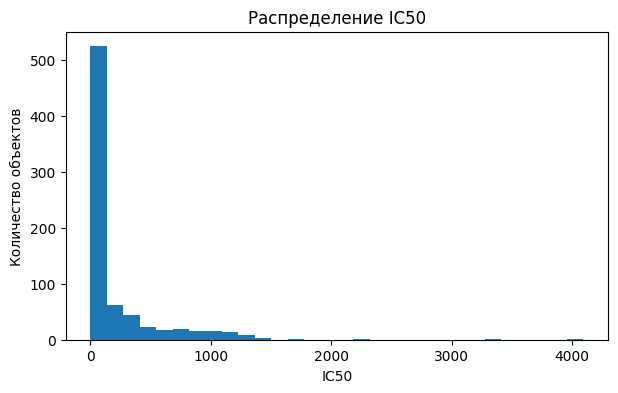

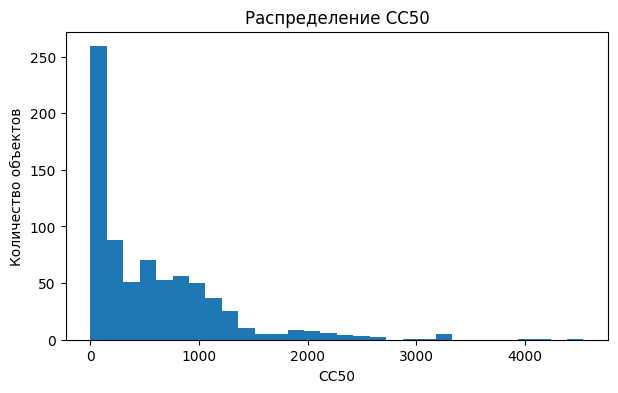

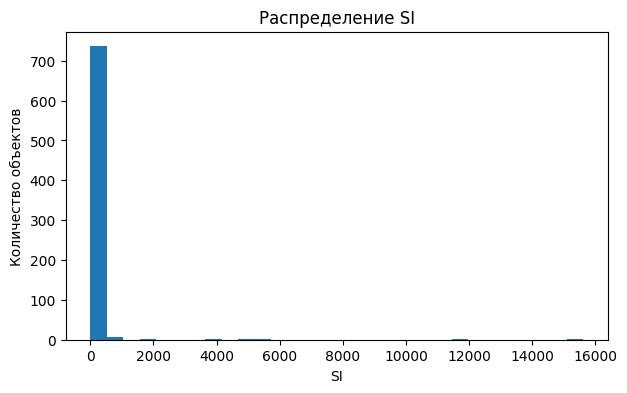

In [18]:
for target_column in TARGET_COLUMNS:
    plt.figure(figsize=(7, 4))
    plt.hist(train_data[target_column], bins=30)
    plt.title(f"Распределение {target_column}")
    plt.xlabel(target_column)
    plt.ylabel("Количество объектов")
    plt.show()

#### Проверка точности формулы `SI = CC50 / IC50`

In [19]:
si_formula_difference = (
    train_data["SI"]
    - train_data["CC50"] / train_data["IC50"]
).abs()

print("Проверка формулы SI = CC50 / IC50")
print(f"Максимальное абсолютное отличие: {si_formula_difference.max():.10f}")
print(f"Среднее абсолютное отличие: {si_formula_difference.mean():.10f}")
print(f"Количество отличий больше 1e-6: {(si_formula_difference > 1e-6).sum()}")

Проверка формулы SI = CC50 / IC50
Максимальное абсолютное отличие: 0.0000000000
Среднее абсолютное отличие: 0.0000000000
Количество отличий больше 1e-6: 0


### Вывод по первичному аудиту данных

На этапе первичного аудита была проверена структура обучающей и тестовой выборок. После переименования целевых переменных в данных выделено 210 числовых признаков и три таргета: `IC50`, `CC50` и `SI`. Признаковое пространство в `train` и `test` совпадает: количество признаков одинаковое, лишних или отсутствующих признаков нет, порядок признаков также совпадает.

Колонка `index` используется только как идентификатор строки и обязательная колонка для submission. Совпадение значений `index` между `train` и `test` не означает пересечение объектов, поэтому `index` не используется как признак при обучении.

В данных есть небольшое количество пропусков: 24 пропуска в `train` и 12 пропусков в `test`. Они сосредоточены в одной группе химических дескрипторов, связанных с частичными зарядами и BCUT2D-признаками. Так как пропуски есть и в тестовой выборке, удалять строки нецелесообразно. На следующих этапах пропуски будут обрабатываться внутри `Pipeline`, чтобы не допустить утечки данных.

Отдельно были проверены константные и дублирующиеся признаки. В `train` найдено 18 константных признаков. Также обнаружено 159 пар полностью одинаковых признаков, но это именно количество пар колонок, а не количество признаков к удалению. Большая часть таких совпадений связана с группами константных признаков, одинаковых между собой.

В обучающей выборке найдены одинаковые feature-векторы: 60 групп дубликатов, которые включают 181 строку. В 53 группах одинаковым признакам соответствуют разные значения таргетов. Это означает, что для модели такие объекты неразличимы по имеющимся признакам, а качество предсказания имеет естественное ограничение.

Между `train` и `test` также есть пересечения по одинаковым признакам: 52 общих feature-hash, которым соответствуют 124 строки `train` и 68 строк `test`. Этот факт не используется напрямую как источник таргетов для тестовой выборки, но позже рассматривается как отдельная диагностическая гипотеза exact-match correction.

Целевые переменные имеют разные масштабы и выраженную асимметрию распределений. Особенно выделяется `SI`: максимальное значение достигает 15620.6, skew равен 15.63, а kurtosis — 271.60. При этом `SI` точно равен отношению `CC50 / IC50`: максимальное абсолютное отличие между исходным `SI` и расчётным отношением равно 0.

Эти наблюдения влияют на дальнейшую стратегию. Из-за одинаковых feature-векторов с разными таргетами в локальной проверке важно использовать `GroupKFold`. Из-за связи `SI = CC50 / IC50` дальше нужно сравнивать два подхода: прямое предсказание `SI` и расчёт/коррекцию `SI` через предсказанные `IC50` и `CC50`.

## 2. Локальная валидация

После первичного аудита данные подготавливаются для моделирования: отдельно выделяются признаки, целевые переменные и тестовая выборка. На этом же этапе задаётся локальная метрика, соответствующая метрике соревнования, и подготавливаются схемы кросс-валидации.

Из-за наличия одинаковых feature-векторов с разными таргетами важно контролировать, чтобы одинаковые объекты не попадали одновременно в обучающую и валидационную части. Поэтому дальше используются две схемы проверки: обычная `KFold` и более строгая `GroupKFold` по одинаковым feature-векторам.

### 2.1 Подготовка `X`, `y`, `X_test`

In [20]:
X = train_data[feature_columns].copy()
y = train_data[TARGET_COLUMNS].copy()
X_test = test_data[feature_columns].copy()

print("Матрицы для моделирования подготовлены.")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"X_test: {X_test.shape}")

Матрицы для моделирования подготовлены.
X: (751, 210)
y: (751, 3)
X_test: (250, 210)


### 2.2 Метрика

In [21]:
def competition_rmse(y_true, y_pred):
    """Считает RMSE отдельно по каждому таргету и усредняет результат."""
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    target_rmse = np.sqrt(
        np.mean((y_true_array - y_pred_array) ** 2, axis=0)
    )

    return target_rmse.mean()


def competition_rmse_by_target(y_true, y_pred, target_columns):
    """Считает RMSE отдельно для каждого таргета."""
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    target_rmse = np.sqrt(
        np.mean((y_true_array - y_pred_array) ** 2, axis=0)
    )

    return pd.Series(target_rmse, index=target_columns)

#### Проверка метрики на прогнозе средним значением

In [22]:
constant_prediction = np.tile(
    y.mean().to_numpy(),
    (len(y), 1),
)

constant_score = competition_rmse(y, constant_prediction)
constant_score_by_target = competition_rmse_by_target(
    y,
    constant_prediction,
    TARGET_COLUMNS,
)

print("Проверка метрики на прогнозе средним значением train:")
print(f"Средний RMSE по трём таргетам: {constant_score:.6f}")

print()
print("RMSE по таргетам:")
print(constant_score_by_target)

Проверка метрики на прогнозе средним значением train:
Средний RMSE по трём таргетам: 599.855329

RMSE по таргетам:
IC50   370.121271
CC50   641.087914
SI     788.356802
dtype: float64


### 2.3 `KFold` и `GroupKFold`

#### Создание групп одинаковых объектов

In [23]:
feature_groups = pd.util.hash_pandas_object(
    X,
    index=False,
).astype(str)

print("Группы одинаковых объектов созданы.")
print(f"Количество строк в train: {len(X)}")
print(f"Количество уникальных feature-групп: {feature_groups.nunique()}")
print(
    "Количество повторяющихся строк по признакам: "
    f"{len(X) - feature_groups.nunique()}"
)

Группы одинаковых объектов созданы.
Количество строк в train: 751
Количество уникальных feature-групп: 630
Количество повторяющихся строк по признакам: 121


#### Настройка схем кросс-валидации

In [24]:
N_SPLITS = 5

standard_cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

group_cv = GroupKFold(
    n_splits=N_SPLITS,
)

print("Схемы кросс-валидации подготовлены.")
print(f"Обычная KFold: {N_SPLITS} folds")
print(f"Групповая GroupKFold: {N_SPLITS} folds")

Схемы кросс-валидации подготовлены.
Обычная KFold: 5 folds
Групповая GroupKFold: 5 folds


#### Проверка размеров folds

In [25]:
def summarize_cv_splits(cv, X, y, groups=None, cv_name="CV"):
    """Выводит размеры train и validation частей для каждого fold."""
    split_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        split_rows.append(
            {
                "cv": cv_name,
                "fold": fold_number,
                "train_size": len(train_index),
                "valid_size": len(valid_index),
            }
        )

    return pd.DataFrame(split_rows)


standard_cv_summary = summarize_cv_splits(
    standard_cv,
    X,
    y,
    cv_name="KFold",
)

group_cv_summary = summarize_cv_splits(
    group_cv,
    X,
    y,
    groups=feature_groups,
    cv_name="GroupKFold",
)

cv_summary = pd.concat(
    [standard_cv_summary, group_cv_summary],
    ignore_index=True,
)

cv_summary

,cv,fold,train_size,valid_size
0,KFold,1,600,151
1,KFold,2,601,150
2,KFold,3,601,150
3,KFold,4,601,150
4,KFold,5,601,150
5,GroupKFold,1,600,151
6,GroupKFold,2,601,150
7,GroupKFold,3,601,150
8,GroupKFold,4,601,150
9,GroupKFold,5,601,150


#### Проверка отсутствия пересечений групп в `GroupKFold`

In [26]:
group_leakage_checks = []

for fold_number, (train_index, valid_index) in enumerate(
    group_cv.split(X, y, feature_groups),
    start=1,
):
    train_groups = set(feature_groups.iloc[train_index])
    valid_groups = set(feature_groups.iloc[valid_index])
    common_groups = train_groups & valid_groups

    group_leakage_checks.append(
        {
            "fold": fold_number,
            "common_groups_count": len(common_groups),
        }
    )

group_leakage_checks = pd.DataFrame(group_leakage_checks)

print("Проверка пересечения групп между train и validation в GroupKFold:")
group_leakage_checks

Проверка пересечения групп между train и validation в GroupKFold:


,fold,common_groups_count
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


### Вывод по локальной валидации

Для моделирования были подготовлены матрицы `X`, `y` и `X_test`: обучающая выборка содержит 751 объект и 210 признаков, тестовая — 250 объектов и те же 210 признаков. Целевые переменные представлены тремя колонками: `IC50`, `CC50` и `SI`.

Локальная метрика реализована в формате соревнования: RMSE считается отдельно по каждому таргету, после чего значения усредняются. На прогнозе средним значением train средний RMSE составил 599.855329. По таргетам ошибка распределилась неравномерно: `IC50` — 370.121271, `CC50` — 641.087914, `SI` — 788.356802. Это подтверждает, что `SI` является одним из наиболее сложных таргетов уже на уровне наивного ориентира.

Для контроля повторяющихся объектов были созданы группы одинаковых feature-векторов. В обучающей выборке получилось 630 уникальных feature-групп при 751 строке, то есть 121 строка повторяет уже встречавшийся набор признаков.

Для дальнейших экспериментов подготовлены две схемы кросс-валидации: обычная `KFold` и более строгая `GroupKFold`. Проверка показала, что в `GroupKFold` одинаковые feature-группы не пересекаются между обучающей и валидационной частями: `common_groups_count = 0` на всех folds. Поэтому `GroupKFold` используется как более осторожная локальная проверка, а `KFold` — как дополнительный ориентир для сравнения устойчивости результатов.

## 3. Baseline и первые модели

### 3.1 Базовые модели

После настройки локальной валидации можно перейти к первым моделям. На этом этапе проверяются простые ориентиры качества: наивный прогноз средним значением, линейные модели с регуляризацией и древесные ансамбли.

Все модели оцениваются на двух схемах валидации:

- `KFold` — обычная кросс-валидация;
- `GroupKFold` — более строгая проверка, при которой одинаковые feature-векторы не попадают одновременно в train и validation.

Так как в данных есть пропуски, заполнение пропусков выполняется внутри `Pipeline`, чтобы не допустить утечки данных.

#### Функция оценки модели на CV

In [27]:
def evaluate_model_cv(model, X, y, cv, cv_name, model_name, groups=None):
    """Оценивает модель на кросс-валидации и возвращает сводную таблицу."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)

        valid_predictions = fold_model.predict(X_valid)
        oof_predictions[valid_index] = valid_predictions

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "model": model_name,
                "cv": cv_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "model": model_name,
        "cv": cv_name,
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

#### Набор базовых моделей

In [28]:
baseline_models = {
    "DummyMean": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyRegressor(strategy="mean")),
        ]
    ),
    "Ridge": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "ElasticNet": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                ElasticNet(
                    alpha=0.01,
                    l1_ratio=0.2,
                    random_state=RANDOM_STATE,
                    max_iter=10_000,
                ),
            ),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "ExtraTrees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

print("Базовые модели подготовлены:")
for model_name in baseline_models:
    print(f"- {model_name}")

Базовые модели подготовлены:
- DummyMean
- Ridge
- ElasticNet
- RandomForest
- ExtraTrees


#### Оценка базовых моделей

In [29]:
baseline_summary_rows = []
baseline_fold_results = []
baseline_oof_predictions = {}

for model_name, model in baseline_models.items():
    print(f"Оценивается модель: {model_name}")

    standard_summary, standard_folds, standard_oof = evaluate_model_cv(
        model=model,
        X=X,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        model_name=model_name,
    )

    group_summary, group_folds, group_oof = evaluate_model_cv(
        model=model,
        X=X,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        model_name=model_name,
        groups=feature_groups,
    )

    baseline_summary_rows.extend([standard_summary, group_summary])
    baseline_fold_results.extend([standard_folds, group_folds])

    baseline_oof_predictions[(model_name, "KFold")] = standard_oof
    baseline_oof_predictions[(model_name, "GroupKFold")] = group_oof

baseline_results = pd.DataFrame(baseline_summary_rows)
baseline_fold_results = pd.concat(
    baseline_fold_results,
    ignore_index=True,
)

baseline_results = baseline_results.sort_values(
    by=["cv", "oof_rmse"],
    ascending=[True, True],
)

baseline_results

Оценивается модель: DummyMean
Оценивается модель: Ridge
Оценивается модель: ElasticNet
Оценивается модель: RandomForest
Оценивается модель: ExtraTrees


,model,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
9,ExtraTrees,GroupKFold,468.886177,137.781731,522.314988,347.158262,459.000473,760.786228
7,RandomForest,GroupKFold,491.294881,132.040005,538.446176,354.718623,511.144817,749.475086
5,ElasticNet,GroupKFold,503.540203,124.799586,550.644952,384.712092,513.582491,753.640273
3,Ridge,GroupKFold,517.849940,113.960578,562.866454,392.862741,536.580539,759.156081
1,DummyMean,GroupKFold,539.953133,151.182105,601.263702,370.710388,643.303456,789.777262
6,RandomForest,KFold,484.088768,155.259727,523.912525,319.138897,458.098869,794.499808
8,ExtraTrees,KFold,486.928212,159.754278,526.336987,325.726343,454.793928,798.490691
4,ElasticNet,KFold,511.226621,154.095091,547.798300,348.921969,502.908471,791.564461
2,Ridge,KFold,537.164356,148.479828,575.710568,369.748979,557.749448,799.633278
0,DummyMean,KFold,541.612128,193.253155,600.741743,370.673910,641.552114,789.999205


#### Сравнение моделей по схемам валидации

In [30]:
baseline_comparison = baseline_results.pivot_table(
    index="model",
    columns="cv",
    values="oof_rmse",
)

baseline_comparison["difference_group_minus_kfold"] = (
    baseline_comparison["GroupKFold"] - baseline_comparison["KFold"]
)

baseline_comparison = baseline_comparison.sort_values(
    by="GroupKFold"
)

baseline_comparison

cv,GroupKFold,KFold,difference_group_minus_kfold
model,,,
ExtraTrees,522.314988,526.336987,-4.021999
RandomForest,538.446176,523.912525,14.533651
ElasticNet,550.644952,547.798300,2.846651
Ridge,562.866454,575.710568,-12.844115
DummyMean,601.263702,600.741743,0.521959


#### Детализация лучшей базовой модели

In [31]:
best_baseline_row = (
    baseline_results
    .query("cv == 'GroupKFold'")
    .sort_values("oof_rmse")
    .iloc[0]
)

best_baseline_model = best_baseline_row["model"]
best_baseline_cv = best_baseline_row["cv"]

print("Лучшая базовая модель по GroupKFold OOF RMSE:")
print(f"Модель: {best_baseline_model}")
print(f"CV: {best_baseline_cv}")
print(f"OOF RMSE: {best_baseline_row['oof_rmse']:.6f}")

print()
print("RMSE по таргетам:")
print(f"IC50: {best_baseline_row['oof_rmse_ic50']:.6f}")
print(f"CC50: {best_baseline_row['oof_rmse_cc50']:.6f}")
print(f"SI: {best_baseline_row['oof_rmse_si']:.6f}")

Лучшая базовая модель по GroupKFold OOF RMSE:
Модель: ExtraTrees
CV: GroupKFold
OOF RMSE: 522.314988

RMSE по таргетам:
IC50: 347.158262
CC50: 459.000473
SI: 760.786228


#### Вывод по базовым моделям

На этапе базового моделирования были проверены несколько простых ориентиров: наивный прогноз средним значением, линейные модели с регуляризацией и древесные ансамбли.

Лучший результат по строгой схеме `GroupKFold` показала модель `ExtraTreesRegressor`: средний OOF RMSE составил 522.314988. По отдельным таргетам ошибка распределилась неравномерно: `IC50` — 347.158262, `CC50` — 459.000473, `SI` — 760.786228.

По сравнению с прогнозом средним значением baseline заметно улучшился: средний RMSE снизился с 599.855329 до 522.314988. При этом ошибка по `SI` остаётся самой высокой, поэтому дальше нужно отдельно проверить, как лучше работать с этим таргетом: предсказывать `SI` напрямую или использовать найденную ранее связь `SI = CC50 / IC50`.

На следующих этапах `ExtraTreesRegressor` используется как первая сильная базовая модель и ориентир для сравнения более сложных подходов.

### 3.2 Отдельные модели по таргетам

На предыдущем этапе лучшей базовой моделью стала `ExtraTreesRegressor`, обученная сразу на три целевые переменные. Однако таргеты имеют разный масштаб и разное поведение, поэтому отдельно проверяется подход с самостоятельной моделью для каждого таргета.

Дополнительно проверяется найденная на этапе аудита связь `SI = CC50 / IC50`. Для `SI` сравниваются две стратегии:

- прямое предсказание `SI` отдельной моделью;
- расчёт `SI` через предсказанные значения `IC50` и `CC50`.

Для отбора подходов используется строгая схема `GroupKFold`.

#### Функция оценки отдельных моделей по таргетам

In [32]:
def evaluate_separate_targets_cv(
    model,
    X,
    y,
    cv,
    cv_name,
    model_name,
    groups=None,
    si_strategy="direct",
):
    """Оценивает отдельные модели для таргетов на кросс-валидации."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        fold_predictions = pd.DataFrame(
            index=y_valid.index,
            columns=TARGET_COLUMNS,
            dtype=float,
        )

        for target_column in ["IC50", "CC50"]:
            target_model = clone(model)
            target_model.fit(X_train, y_train[target_column])
            fold_predictions[target_column] = target_model.predict(X_valid)

        if si_strategy == "direct":
            si_model = clone(model)
            si_model.fit(X_train, y_train["SI"])
            fold_predictions["SI"] = si_model.predict(X_valid)

        elif si_strategy == "ratio":
            ic50_floor = max(float(y_train["IC50"].quantile(0.01)), 1e-9)
            safe_ic50_prediction = np.maximum(
                fold_predictions["IC50"].to_numpy(),
                ic50_floor,
            )
            fold_predictions["SI"] = (
                fold_predictions["CC50"].to_numpy() / safe_ic50_prediction
            )

        else:
            raise ValueError("si_strategy должен быть 'direct' или 'ratio'.")

        valid_predictions = fold_predictions[TARGET_COLUMNS].to_numpy()
        oof_predictions[valid_index] = valid_predictions

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "model": model_name,
                "cv": cv_name,
                "si_strategy": si_strategy,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "model": model_name,
        "cv": cv_name,
        "si_strategy": si_strategy,
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

#### Набор моделей для отдельных таргетов

In [33]:
single_target_models = {
    "Separate_Ridge": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Separate_RandomForest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Separate_ExtraTrees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Separate_HistGradientBoosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.03,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print("Модели для отдельных таргетов подготовлены:")
for model_name in single_target_models:
    print(f"- {model_name}")

Модели для отдельных таргетов подготовлены:
- Separate_Ridge
- Separate_RandomForest
- Separate_ExtraTrees
- Separate_HistGradientBoosting


#### Оценка отдельных моделей

In [34]:
separate_target_summary_rows = []
separate_target_fold_results = []
separate_target_oof_predictions = {}

for model_name, model in single_target_models.items():
    for si_strategy in ["direct", "ratio"]:
        print(f"Оценивается модель: {model_name}, SI strategy: {si_strategy}")

        summary, fold_results, oof_predictions = evaluate_separate_targets_cv(
            model=model,
            X=X,
            y=y,
            cv=group_cv,
            cv_name="GroupKFold",
            model_name=model_name,
            groups=feature_groups,
            si_strategy=si_strategy,
        )

        separate_target_summary_rows.append(summary)
        separate_target_fold_results.append(fold_results)
        separate_target_oof_predictions[(model_name, si_strategy)] = (
            oof_predictions
        )

separate_target_results = pd.DataFrame(separate_target_summary_rows)
separate_target_fold_results = pd.concat(
    separate_target_fold_results,
    ignore_index=True,
)

separate_target_results = separate_target_results.sort_values("oof_rmse")

separate_target_results

Оценивается модель: Separate_Ridge, SI strategy: direct
Оценивается модель: Separate_Ridge, SI strategy: ratio
Оценивается модель: Separate_RandomForest, SI strategy: direct
Оценивается модель: Separate_RandomForest, SI strategy: ratio
Оценивается модель: Separate_ExtraTrees, SI strategy: direct
Оценивается модель: Separate_ExtraTrees, SI strategy: ratio
Оценивается модель: Separate_HistGradientBoosting, SI strategy: direct
Оценивается модель: Separate_HistGradientBoosting, SI strategy: ratio


,model,cv,si_strategy,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
4,Separate_ExtraTrees,GroupKFold,direct,472.547062,135.480915,525.701410,346.215236,462.297818,768.591177
5,Separate_ExtraTrees,GroupKFold,ratio,469.458767,155.582544,533.776556,346.215236,462.297818,792.816613
2,Separate_RandomForest,GroupKFold,direct,493.150055,121.049465,538.601036,362.188536,501.051169,752.563402
6,Separate_HistGradientBoosting,GroupKFold,direct,487.360689,127.558990,540.266315,367.229137,503.522253,750.047554
3,Separate_RandomForest,GroupKFold,ratio,487.059137,159.447733,552.007289,362.188536,501.051169,792.782162
0,Separate_Ridge,GroupKFold,direct,517.849940,113.960578,562.866454,392.862741,536.580539,759.156081
7,Separate_HistGradientBoosting,GroupKFold,ratio,1100.187961,425.045530,1176.193655,367.229137,503.522253,2657.829575
1,Separate_Ridge,GroupKFold,ratio,2083.092475,543.233974,2151.490666,392.862741,536.580539,5525.028719


#### Сравнение прямого и формульного `SI`

In [35]:
si_strategy_comparison = separate_target_results.pivot_table(
    index="model",
    columns="si_strategy",
    values="oof_rmse",
)

si_strategy_comparison["ratio_minus_direct"] = (
    si_strategy_comparison["ratio"] - si_strategy_comparison["direct"]
)

si_strategy_comparison = si_strategy_comparison.sort_values(
    by=si_strategy_comparison.columns.tolist()[0]
)

si_strategy_comparison

si_strategy,direct,ratio,ratio_minus_direct
model,,,
Separate_ExtraTrees,525.701410,533.776556,8.075145
Separate_RandomForest,538.601036,552.007289,13.406253
Separate_HistGradientBoosting,540.266315,1176.193655,635.927340
Separate_Ridge,562.866454,2151.490666,1588.624213


#### Лучшая модель среди отдельных моделей по таргетам

In [36]:
best_separate_target_row = separate_target_results.iloc[0]

print("Лучший вариант среди отдельных моделей по таргетам:")
print(f"Модель: {best_separate_target_row['model']}")
print(f"CV: {best_separate_target_row['cv']}")
print(f"SI strategy: {best_separate_target_row['si_strategy']}")
print(f"OOF RMSE: {best_separate_target_row['oof_rmse']:.6f}")

print()
print("RMSE по таргетам:")
print(f"IC50: {best_separate_target_row['oof_rmse_ic50']:.6f}")
print(f"CC50: {best_separate_target_row['oof_rmse_cc50']:.6f}")
print(f"SI: {best_separate_target_row['oof_rmse_si']:.6f}")

Лучший вариант среди отдельных моделей по таргетам:
Модель: Separate_ExtraTrees
CV: GroupKFold
SI strategy: direct
OOF RMSE: 525.701410

RMSE по таргетам:
IC50: 346.215236
CC50: 462.297818
SI: 768.591177


#### Вывод по отдельным моделям по таргетам

На этом этапе были проверены отдельные модели для каждого таргета. Лучший результат показала связка `Separate_ExtraTrees` с прямым предсказанием `SI`: средний OOF RMSE по `GroupKFold` составил 525.701410.

Этот результат оказался немного хуже, чем у multi-target `ExtraTreesRegressor` из предыдущего блока: 525.701410 против 522.314988. Поэтому на текущем этапе основной baseline остаётся за multi-target `ExtraTreesRegressor`.

Отдельно была проверена стратегия расчёта `SI` через отношение `CC50_pred / IC50_pred`. На этом этапе она не улучшила качество: для `Separate_ExtraTrees` RMSE ухудшился на 8.075145, для `Separate_RandomForest` — на 13.406253. Для линейной модели и `HistGradientBoosting` ухудшение было значительно сильнее.

Поэтому в первой базовой submission используется прямое предсказание всех трёх таргетов через multi-target `ExtraTreesRegressor`. При этом идея formula-SI не отбрасывается полностью: к ней стоит вернуться позже в виде более осторожного блендинга или постобработки.

### 3.3 Первая проверочная submission

После базовых экспериментов создаётся первая submission на основе лучшей базовой модели. Цель этой загрузки — проверить корректность формата файла, убедиться, что порядок `index` совпадает с `sample_submission`, и получить внешний ориентир качества.

Public leaderboard используется как дополнительная проверка результата, но не заменяет локальную валидацию. Дальше решения сравниваются по совокупности факторов: локальные метрики, стабильность подхода, диагностика таргетов и public score.

#### Обучение baseline-модели на всём train

In [37]:
SUBMISSIONS_DIR.mkdir(exist_ok=True)

baseline_final_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_final_model.fit(X, y)

baseline_test_predictions = baseline_final_model.predict(X_test)

print("Baseline-модель обучена на всём train.")
print(f"Размер предсказаний: {baseline_test_predictions.shape}")

Baseline-модель обучена на всём train.
Размер предсказаний: (250, 3)


#### Проверка диапазона предсказаний

In [38]:
baseline_prediction_summary = pd.DataFrame(
    baseline_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

baseline_prediction_summary

,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,249.843069,338.547090,0.318533,62.996499,136.638656,303.656811,2309.680872
CC50,250.000000,653.636626,559.014075,24.011131,274.667307,495.665211,891.883774,3305.241533
SI,250.000000,78.563107,331.031709,1.248864,8.449287,17.425206,32.050490,2693.734720


#### Создание submission-файла

In [39]:
baseline_submission = sample_submission.copy()

baseline_submission[TARGET_COLUMNS] = baseline_test_predictions

submission_path = SUBMISSIONS_DIR / "submission_01_extratrees_baseline.csv"
baseline_submission.to_csv(submission_path, index=False)

print(f"Submission сохранён: {submission_path}")
print(f"Размер submission: {baseline_submission.shape}")
print(f"Колонки submission: {list(baseline_submission.columns)}")
print(f"Пропуски в submission: {baseline_submission.isna().sum().sum()}")

Submission сохранён: ../submissions/submission_01_extratrees_baseline.csv
Размер submission: (250, 4)
Колонки submission: ['index', 'IC50', 'CC50', 'SI']
Пропуски в submission: 0


#### Проверка submission перед загрузкой

In [40]:
print("Проверка submission")

print(f"Количество строк: {len(baseline_submission)}")
print(f"Количество строк в sample_submission: {len(sample_submission)}")

print()
print("Совпадает ли порядок index с sample_submission:")
print(
    baseline_submission[ID_COLUMN].equals(
        sample_submission[ID_COLUMN]
    )
)

print()
print("Первые строки submission:")
print(baseline_submission.head())

Проверка submission
Количество строк: 250
Количество строк в sample_submission: 250

Совпадает ли порядок index с sample_submission:
True

Первые строки submission:
   index       IC50       CC50        SI
0      0  92.612918 273.315526 10.681270
1      1 140.428732 350.832142 10.129348
2      2  57.940126 309.035606  7.206273
3      3 250.945323 452.876164  8.074734
4      4 219.853391 323.524780  8.083477


#### Вывод по первой проверочной submission

Первая проверочная submission была построена на основе baseline-модели `ExtraTreesRegressor`, обученной на всём `train`. Перед загрузкой файл прошёл базовые проверки: количество строк совпало с `sample_submission`, порядок `index` сохранился, пропусков в предсказаниях нет.

Public score первой submission составил `362.84474`. Этот результат используется как первый внешний ориентир качества и показывает, что полный технический цикл — обучение модели, формирование предсказаний и загрузка submission — работает корректно.

При этом public score численно сильно отличался от оценки на `GroupKFold`. Поэтому локальная валидация дальше используется не как точный прогноз leaderboard, а как единый инструмент для сравнения гипотез: по общему RMSE, по отдельным таргетам и по устойчивости результата.

## 4. Первая сильная ветка: Direct-blend / hybrid-best

### 4.1 Усиление baseline: `SI`-blend, настройка `ExtraTrees` и clipping

После первой baseline submission основная проблема осталась связана с таргетом `SI`: он имеет сильный хвост и даёт самую большую ошибку. Поэтому первым направлением улучшения стала проверка нескольких осторожных модификаций baseline-ветки: смешивание прямого прогноза `SI` с расчётным `SI = CC50 / IC50`, настройка `ExtraTreesRegressor` и ограничение экстремальных значений `SI`.

#### Проверка blend для `SI`

In [41]:
def evaluate_si_blend(oof_predictions, y, target_columns, weights):
    """Проверяет блендинг прямого прогноза SI и SI через отношение CC50 / IC50."""
    blend_rows = []

    direct_predictions = np.asarray(oof_predictions).copy()

    ic50_floor = max(float(y["IC50"].quantile(0.01)), 1e-9)
    si_ratio_prediction = (
        direct_predictions[:, 1]
        / np.maximum(direct_predictions[:, 0], ic50_floor)
    )

    for ratio_weight in weights:
        blended_predictions = direct_predictions.copy()
        blended_predictions[:, 2] = (
            (1 - ratio_weight) * direct_predictions[:, 2]
            + ratio_weight * si_ratio_prediction
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            target_columns,
        )

        blend_rows.append(
            {
                "ratio_weight": ratio_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(blend_rows).sort_values("oof_rmse")


extra_trees_group_oof = baseline_oof_predictions[
    ("ExtraTrees", "GroupKFold")
]

si_blend_results = evaluate_si_blend(
    oof_predictions=extra_trees_group_oof,
    y=y,
    target_columns=TARGET_COLUMNS,
    weights=np.linspace(0, 1, 21),
)

si_blend_results.head(10)

,ratio_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,0.000000,522.314988,347.158262,459.000473,760.786228
1,0.050000,522.596579,347.158262,459.000473,761.631003
2,0.100000,522.905668,347.158262,459.000473,762.558269
3,0.150000,523.242154,347.158262,459.000473,763.567725
4,0.200000,523.605927,347.158262,459.000473,764.659046
5,0.250000,523.996873,347.158262,459.000473,765.831883
6,0.300000,524.414865,347.158262,459.000473,767.085860
7,0.350000,524.859772,347.158262,459.000473,768.420581
8,0.400000,525.331454,347.158262,459.000473,769.835625
9,0.450000,525.829762,347.158262,459.000473,771.330552


#### Настройка `ExtraTrees`

##### Кандидаты `ExtraTrees`

In [42]:
def make_extratrees_model(n_estimators, min_samples_leaf, max_features):
    """Создаёт Pipeline с заполнением пропусков и ExtraTreesRegressor."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=n_estimators,
                    max_depth=None,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


extratrees_candidates = {
    "ExtraTrees_300_leaf2_features1": make_extratrees_model(
        n_estimators=300,
        min_samples_leaf=2,
        max_features=1.0,
    ),
    "ExtraTrees_600_leaf1_features1": make_extratrees_model(
        n_estimators=600,
        min_samples_leaf=1,
        max_features=1.0,
    ),
    "ExtraTrees_600_leaf2_features1": make_extratrees_model(
        n_estimators=600,
        min_samples_leaf=2,
        max_features=1.0,
    ),
    "ExtraTrees_600_leaf3_features1": make_extratrees_model(
        n_estimators=600,
        min_samples_leaf=3,
        max_features=1.0,
    ),
    "ExtraTrees_600_leaf2_features07": make_extratrees_model(
        n_estimators=600,
        min_samples_leaf=2,
        max_features=0.7,
    ),
}

print("Кандидаты ExtraTrees подготовлены:")
for model_name in extratrees_candidates:
    print(f"- {model_name}")

Кандидаты ExtraTrees подготовлены:
- ExtraTrees_300_leaf2_features1
- ExtraTrees_600_leaf1_features1
- ExtraTrees_600_leaf2_features1
- ExtraTrees_600_leaf3_features1
- ExtraTrees_600_leaf2_features07


##### Оценка вариантов ExtraTrees на GroupKFold

In [43]:
extratrees_tuning_rows = []
extratrees_tuning_fold_results = []
extratrees_tuning_oof_predictions = {}

for model_name, model in extratrees_candidates.items():
    print(f"Оценивается модель: {model_name}")

    summary, fold_results, oof_predictions = evaluate_model_cv(
        model=model,
        X=X,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        model_name=model_name,
        groups=feature_groups,
    )

    extratrees_tuning_rows.append(summary)
    extratrees_tuning_fold_results.append(fold_results)
    extratrees_tuning_oof_predictions[model_name] = oof_predictions

extratrees_tuning_results = pd.DataFrame(extratrees_tuning_rows)
extratrees_tuning_fold_results = pd.concat(
    extratrees_tuning_fold_results,
    ignore_index=True,
)

extratrees_tuning_results = extratrees_tuning_results.sort_values("oof_rmse")

extratrees_tuning_results

Оценивается модель: ExtraTrees_300_leaf2_features1
Оценивается модель: ExtraTrees_600_leaf1_features1
Оценивается модель: ExtraTrees_600_leaf2_features1
Оценивается модель: ExtraTrees_600_leaf3_features1
Оценивается модель: ExtraTrees_600_leaf2_features07


,model,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,ExtraTrees_600_leaf1_features1,GroupKFold,468.127120,144.515134,521.550819,344.708443,458.248607,761.695407
0,ExtraTrees_300_leaf2_features1,GroupKFold,468.886177,137.781731,522.314988,347.158262,459.000473,760.786228
2,ExtraTrees_600_leaf2_features1,GroupKFold,469.769530,139.071909,522.847967,346.861200,459.994878,761.687822
3,ExtraTrees_600_leaf3_features1,GroupKFold,470.820620,138.991420,522.965711,339.913859,466.943049,762.040224
4,ExtraTrees_600_leaf2_features07,GroupKFold,469.689504,142.240450,523.226740,345.924913,459.056227,764.699080


#### Промежуточный вывод по `SI`-blend и настройке `ExtraTrees`

Блендинг прямого прогноза `SI` с расчётным вариантом `CC50_pred / IC50_pred` не улучшил локальное качество baseline-модели. Лучший результат остался при нулевом весе формульного `SI`, то есть на этом этапе прямое предсказание `SI` было устойчивее.

Дополнительно была проверена настройка `ExtraTreesRegressor`. Более гибкий вариант с 600 деревьями и `min_samples_leaf=1` немного улучшил локальную оценку, но требовал проверки на public leaderboard, так как более гибкие древесные модели могут давать менее устойчивые экстремальные предсказания.

#### Обучение более гибкой `ExtraTrees`-модели

In [44]:
extratrees_tuned_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=600,
                max_depth=None,
                min_samples_leaf=1,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

extratrees_tuned_model.fit(X, y)

extratrees_tuned_predictions = extratrees_tuned_model.predict(X_test)

print("Улучшенная ExtraTrees-модель обучена на всём train.")
print(f"Размер предсказаний: {extratrees_tuned_predictions.shape}")

Улучшенная ExtraTrees-модель обучена на всём train.
Размер предсказаний: (250, 3)


#### Проверка диапазона предсказаний

In [45]:
extratrees_tuned_prediction_summary = pd.DataFrame(
    extratrees_tuned_predictions,
    columns=TARGET_COLUMNS,
).describe().T

extratrees_tuned_prediction_summary

,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,268.365110,497.628251,0.298932,48.982292,110.555704,294.499056,4095.188563
CC50,250.000000,668.516801,641.763782,9.778881,255.135484,513.001380,895.534081,4095.188563
SI,250.000000,76.397388,332.552613,1.000000,7.238342,14.282243,31.265383,2694.841865


#### Конвертка эксперимента: tuned ExtraTrees

| Параметр | Значение |
|---|---|
| Гипотеза | Более гибкая `ExtraTreesRegressor` может улучшить baseline |
| Входная ветка | Baseline `ExtraTreesRegressor` |
| Параметры | `n_estimators=600`, `min_samples_leaf=1`, `max_features=1.0` |
| Локальная проверка | Небольшое улучшение на `GroupKFold` относительно baseline |
| Тип проверки | Внешняя проверка на public leaderboard |
| Public score baseline | `362.84474` |
| Public score эксперимента | `396.98388` |
| Изменение относительно baseline | хуже на `34.13914` |
| Решение | Не использовать как основной baseline |
| Причина | Несмотря на небольшое локальное улучшение, public score ухудшился. Более гибкая модель с `min_samples_leaf=1` дала менее устойчивые предсказания на тестовой части. |

#### Проверка сильных табличных моделей и первого `SI` clipping

После baseline-моделей проверяются более сильные алгоритмы для табличных данных: `CatBoost`, `LightGBM` и `XGBoost`. Цель этого блока — понять, могут ли бустинговые модели улучшить текущую ExtraTrees-ветку полностью или хотя бы дать полезный сигнал для отдельных таргетов, прежде всего для `SI`.

Эта проверка также помогает оценить, есть ли смысл переходить от одного baseline-подхода к target-wise схеме, где разные таргеты могут получать прогнозы из разных моделей.

##### Модели-кандидаты

In [46]:
boosting_models = {
    "CatBoost": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                MultiOutputRegressor(
                    LGBMRegressor(
                        n_estimators=800,
                        learning_rate=0.03,
                        num_leaves=15,
                        min_child_samples=10,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        verbose=-1,
                    )
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                MultiOutputRegressor(
                    XGBRegressor(
                        n_estimators=800,
                        learning_rate=0.03,
                        max_depth=3,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        objective="reg:squarederror",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    )
                ),
            ),
        ]
    ),
}

print("Модели бустинга подготовлены:")
for model_name in boosting_models:
    print(f"- {model_name}")

Модели бустинга подготовлены:
- CatBoost
- LightGBM
- XGBoost


##### Оценка бустингов

In [47]:
boosting_summary_rows = []
boosting_fold_results = []
boosting_oof_predictions = {}

for model_name, model in boosting_models.items():
    print(f"Оценивается модель: {model_name}")

    summary, fold_results, oof_predictions = evaluate_model_cv(
        model=model,
        X=X,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        model_name=model_name,
        groups=feature_groups,
    )

    boosting_summary_rows.append(summary)
    boosting_fold_results.append(fold_results)
    boosting_oof_predictions[model_name] = oof_predictions

boosting_results = pd.DataFrame(boosting_summary_rows)
boosting_fold_results = pd.concat(
    boosting_fold_results,
    ignore_index=True,
)

boosting_results = boosting_results.sort_values("oof_rmse")

boosting_results

Оценивается модель: CatBoost
Оценивается модель: LightGBM
Оценивается модель: XGBoost


,model,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,CatBoost,GroupKFold,476.020587,136.075760,527.862562,355.347845,472.499348,755.740493
1,LightGBM,GroupKFold,485.501066,137.687907,540.493340,380.298567,497.060161,744.121293
2,XGBoost,GroupKFold,496.184547,140.320841,547.817467,362.170085,487.409747,793.872568


##### Эксперимент: `SI` от бустингов + `IC50`/`CC50` от ExtraTrees`

In [48]:
def evaluate_si_target_blend(
    base_oof_predictions,
    candidate_oof_predictions,
    y,
    candidate_name,
    weights,
):
    """Проверяет замену или блендинг SI поверх базовых предсказаний."""
    blend_rows = []

    base_predictions = np.asarray(base_oof_predictions)
    candidate_predictions = np.asarray(candidate_oof_predictions)

    for si_weight in weights:
        blended_predictions = base_predictions.copy()
        blended_predictions[:, 2] = (
            (1 - si_weight) * base_predictions[:, 2]
            + si_weight * candidate_predictions[:, 2]
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        blend_rows.append(
            {
                "candidate": candidate_name,
                "si_weight": si_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(blend_rows)


extra_trees_oof = baseline_oof_predictions[
    ("ExtraTrees", "GroupKFold")
]

si_blend_with_boosting_rows = []

for candidate_name, candidate_oof in boosting_oof_predictions.items():
    candidate_results = evaluate_si_target_blend(
        base_oof_predictions=extra_trees_oof,
        candidate_oof_predictions=candidate_oof,
        y=y,
        candidate_name=candidate_name,
        weights=np.linspace(0, 1, 21),
    )
    si_blend_with_boosting_rows.append(candidate_results)

si_blend_with_boosting_results = pd.concat(
    si_blend_with_boosting_rows,
    ignore_index=True,
)

si_blend_with_boosting_results = si_blend_with_boosting_results.sort_values(
    "oof_rmse"
)

si_blend_with_boosting_results.head(15)

,candidate,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
36,LightGBM,0.750000,516.187540,347.158262,459.000473,742.403885
37,LightGBM,0.800000,516.196530,347.158262,459.000473,742.430855
35,LightGBM,0.700000,516.231364,347.158262,459.000473,742.535357
38,LightGBM,0.850000,516.258329,347.158262,459.000473,742.616250
34,LightGBM,0.650000,516.327974,347.158262,459.000473,742.825186
39,LightGBM,0.900000,516.372896,347.158262,459.000473,742.959952
33,LightGBM,0.600000,516.477308,347.158262,459.000473,743.273188
40,LightGBM,0.950000,516.540158,347.158262,459.000473,743.461739
32,LightGBM,0.550000,516.679271,347.158262,459.000473,743.879076
41,LightGBM,1.000000,516.760010,347.158262,459.000473,744.121293


In [49]:
def evaluate_full_prediction_blend(
    base_oof_predictions,
    candidate_oof_predictions,
    y,
    candidate_name,
    weights,
):
    """Проверяет блендинг всех трёх таргетов между двумя моделями."""
    blend_rows = []

    base_predictions = np.asarray(base_oof_predictions)
    candidate_predictions = np.asarray(candidate_oof_predictions)

    for candidate_weight in weights:
        blended_predictions = (
            (1 - candidate_weight) * base_predictions
            + candidate_weight * candidate_predictions
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        blend_rows.append(
            {
                "candidate": candidate_name,
                "candidate_weight": candidate_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(blend_rows)


full_blend_rows = []

for candidate_name, candidate_oof in boosting_oof_predictions.items():
    candidate_results = evaluate_full_prediction_blend(
        base_oof_predictions=extra_trees_oof,
        candidate_oof_predictions=candidate_oof,
        y=y,
        candidate_name=candidate_name,
        weights=np.linspace(0, 1, 21),
    )
    full_blend_rows.append(candidate_results)

full_blend_results = pd.concat(
    full_blend_rows,
    ignore_index=True,
)

full_blend_results = full_blend_results.sort_values("oof_rmse")

full_blend_results.head(15)

,candidate,candidate_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
25,LightGBM,0.200000,520.806768,350.671454,459.252280,752.496569
26,LightGBM,0.250000,520.841079,351.807516,459.914069,750.801652
24,LightGBM,0.150000,520.936940,349.637629,458.829552,754.343639
6,CatBoost,0.300000,520.987097,346.849713,457.127867,758.983712
7,CatBoost,0.350000,521.017942,347.031280,457.315295,758.707250
5,CatBoost,0.250000,521.028338,346.734668,457.083314,759.267032
27,LightGBM,0.300000,521.039546,353.044829,460.813888,749.259922
8,CatBoost,0.400000,521.120781,347.279266,457.645424,758.437654
4,CatBoost,0.200000,521.141698,346.686213,457.181679,759.557203
23,LightGBM,0.100000,521.231748,348.706951,458.646547,756.341747


In [50]:
fine_si_blend_with_lightgbm = evaluate_si_target_blend(
    base_oof_predictions=extra_trees_oof,
    candidate_oof_predictions=boosting_oof_predictions["LightGBM"],
    y=y,
    candidate_name="LightGBM",
    weights=np.arange(0.65, 0.86, 0.01),
)

fine_si_blend_with_lightgbm = fine_si_blend_with_lightgbm.sort_values(
    "oof_rmse"
)

fine_si_blend_with_lightgbm.head(10)

,candidate,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
12,LightGBM,0.770000,516.184798,347.158262,459.000473,742.395659
11,LightGBM,0.760000,516.185113,347.158262,459.000473,742.396603
13,LightGBM,0.780000,516.186596,347.158262,459.000473,742.401053
10,LightGBM,0.750000,516.187540,347.158262,459.000473,742.403885
14,LightGBM,0.790000,516.190507,347.158262,459.000473,742.412785
9,LightGBM,0.740000,516.192080,347.158262,459.000473,742.417505
15,LightGBM,0.800000,516.196530,347.158262,459.000473,742.430855
8,LightGBM,0.730000,516.198733,347.158262,459.000473,742.437463
16,LightGBM,0.810000,516.204666,347.158262,459.000473,742.455263
7,LightGBM,0.720000,516.207498,347.158262,459.000473,742.463758


#### Вывод по бустинговому сигналу для `SI`

Отдельные модели `CatBoost`, `LightGBM` и `XGBoost` не стали самостоятельным улучшением относительно baseline `ExtraTreesRegressor`. Однако проверка по таргетам показала, что бустинговые модели могут быть полезны как отдельный источник сигнала для `SI`.

Первый вариант с заменой `SI` на сигнал от `LightGBM` без дополнительной постобработки не улучшил public score: результат составил `367.46177` против `362.84474` у baseline `ExtraTrees`. Значит, одного бустингового сигнала для `SI` недостаточно.

Дальше проверяется, поможет ли ограничение экстремальных значений `SI`, так как именно этот таргет имеет наиболее выраженный хвост распределения и сильнее всего влияет на итоговую RMSE-метрику.

#### Проверка clipping для `SI`

In [51]:
BEST_SI_LIGHTGBM_WEIGHT = 0.77

base_predictions = extra_trees_oof.copy()
lightgbm_predictions = boosting_oof_predictions["LightGBM"]

si_blended_oof = base_predictions.copy()
si_blended_oof[:, 2] = (
    (1 - BEST_SI_LIGHTGBM_WEIGHT) * base_predictions[:, 2]
    + BEST_SI_LIGHTGBM_WEIGHT * lightgbm_predictions[:, 2]
)

si_lower_bounds = [
    0,
    float(y["SI"].min()),
    float(y["SI"].quantile(0.001)),
    float(y["SI"].quantile(0.005)),
    float(y["SI"].quantile(0.01)),
    1,
]

si_upper_bounds = [
    None,
    float(y["SI"].max()),
    float(y["SI"].quantile(0.995)),
    float(y["SI"].quantile(0.99)),
]

clipping_rows = []

for lower_bound in si_lower_bounds:
    for upper_bound in si_upper_bounds:
        clipped_predictions = si_blended_oof.copy()

        if upper_bound is None:
            clipped_predictions[:, 2] = np.maximum(
                clipped_predictions[:, 2],
                lower_bound,
            )
            upper_bound_label = "None"
        else:
            clipped_predictions[:, 2] = np.clip(
                clipped_predictions[:, 2],
                lower_bound,
                upper_bound,
            )
            upper_bound_label = upper_bound

        score = competition_rmse(y, clipped_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            clipped_predictions,
            TARGET_COLUMNS,
        )

        clipping_rows.append(
            {
                "si_lower_bound": lower_bound,
                "si_upper_bound": upper_bound_label,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

si_clipping_results = pd.DataFrame(clipping_rows).sort_values("oof_rmse")

si_clipping_results.head(15)

,si_lower_bound,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
23,1.000000,1281.250000,516.051753,347.158262,459.000473,741.996523
19,0.229697,1281.250000,516.052222,347.158262,459.000473,741.997931
15,0.055955,1281.250000,516.052332,347.158262,459.000473,741.998262
11,0.023568,1281.250000,516.052353,347.158262,459.000473,741.998324
7,0.011489,1281.250000,516.052361,347.158262,459.000473,741.998347
3,0.000000,1281.250000,516.052368,347.158262,459.000473,741.998369
21,1.000000,15620.600000,516.146034,347.158262,459.000473,742.279367
20,1.000000,None,516.146034,347.158262,459.000473,742.279367
22,1.000000,4251.275000,516.146034,347.158262,459.000473,742.279367
18,0.229697,4251.275000,516.146503,347.158262,459.000473,742.280774


#### Вывод по `LightGBM` для `SI` с clipping

Добавление clipping для `SI` заметно улучшило public score: результат снизился до `321.56472`. Это всё ещё хуже следующих вариантов на `ExtraTrees`, но проверка показала, что качество зависит не только от выбора модели для `SI`, но и от ограничения экстремальных значений этого таргета.

После этого отдельно проверяется, может ли clipping `SI` улучшить baseline-модель `ExtraTreesRegressor` без добавления `LightGBM`.

#### Clipping только для baseline-модели `ExtraTrees`

In [52]:
baseline_clipping_rows = []

si_lower_bounds = [
    0,
    float(y["SI"].min()),
    float(y["SI"].quantile(0.001)),
    float(y["SI"].quantile(0.005)),
    float(y["SI"].quantile(0.01)),
    1,
]

si_upper_bounds = [
    None,
    float(y["SI"].max()),
    float(y["SI"].quantile(0.995)),
    float(y["SI"].quantile(0.99)),
]

for lower_bound in si_lower_bounds:
    for upper_bound in si_upper_bounds:
        clipped_predictions = extra_trees_oof.copy()

        if upper_bound is None:
            clipped_predictions[:, 2] = np.maximum(
                clipped_predictions[:, 2],
                lower_bound,
            )
            upper_bound_label = "None"
        else:
            clipped_predictions[:, 2] = np.clip(
                clipped_predictions[:, 2],
                lower_bound,
                upper_bound,
            )
            upper_bound_label = upper_bound

        score = competition_rmse(y, clipped_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            clipped_predictions,
            TARGET_COLUMNS,
        )

        baseline_clipping_rows.append(
            {
                "si_lower_bound": lower_bound,
                "si_upper_bound": upper_bound_label,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

baseline_si_clipping_results = pd.DataFrame(
    baseline_clipping_rows
).sort_values("oof_rmse")

baseline_si_clipping_results.head(15)

,si_lower_bound,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
11,0.023568,1281.250000,522.009969,347.158262,459.000473,759.871170
19,0.229697,1281.250000,522.009969,347.158262,459.000473,759.871170
15,0.055955,1281.250000,522.009969,347.158262,459.000473,759.871170
7,0.011489,1281.250000,522.009969,347.158262,459.000473,759.871170
23,1.000000,1281.250000,522.009969,347.158262,459.000473,759.871170
3,0.000000,1281.250000,522.009969,347.158262,459.000473,759.871170
5,0.011489,15620.600000,522.314988,347.158262,459.000473,760.786228
21,1.000000,15620.600000,522.314988,347.158262,459.000473,760.786228
20,1.000000,None,522.314988,347.158262,459.000473,760.786228
1,0.000000,15620.600000,522.314988,347.158262,459.000473,760.786228


#### Вывод по clipping для baseline `ExtraTrees`

Отдельно был проверен clipping `SI` для базовой модели `ExtraTreesRegressor` без добавления `LightGBM`. Локально этот вариант дал небольшое улучшение по `GroupKFold`: средний RMSE снизился с `522.314988` до `522.009969`.

На public leaderboard эффект оказался заметно сильнее: score улучшился с `362.84474` до `313.72358`. Это подтвердило, что экстремальные значения `SI` существенно влияли на итоговую RMSE-метрику.

После этого фокус смещается с замены всей модели на более аккуратную постобработку `SI`.

#### Более подробный подбор верхней границы `SI`

In [53]:
si_quantile_grid = [
    0.900,
    0.925,
    0.950,
    0.960,
    0.970,
    0.975,
    0.980,
    0.985,
    0.990,
    0.995,
    1.000,
]

fine_baseline_clipping_rows = []

for quantile in si_quantile_grid:
    upper_bound = float(y["SI"].quantile(quantile))

    clipped_predictions = extra_trees_oof.copy()
    clipped_predictions[:, 2] = np.clip(
        clipped_predictions[:, 2],
        1.0,
        upper_bound,
    )

    score = competition_rmse(y, clipped_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        clipped_predictions,
        TARGET_COLUMNS,
    )

    fine_baseline_clipping_rows.append(
        {
            "si_upper_quantile": quantile,
            "si_upper_bound": upper_bound,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

fine_baseline_si_clipping_results = pd.DataFrame(
    fine_baseline_clipping_rows
).sort_values("oof_rmse")

fine_baseline_si_clipping_results

,si_upper_quantile,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
7,0.985000,635.678571,521.777821,347.158262,459.000473,759.174726
8,0.990000,1281.250000,522.009969,347.158262,459.000473,759.871170
9,0.995000,4251.275000,522.314988,347.158262,459.000473,760.786228
10,1.000000,15620.600000,522.314988,347.158262,459.000473,760.786228
6,0.980000,500.000000,522.752645,347.158262,459.000473,762.099201
5,0.975000,392.857143,524.537293,347.158262,459.000473,767.453142
4,0.970000,295.138889,526.398191,347.158262,459.000473,773.035838
3,0.960000,170.875000,528.898235,347.158262,459.000473,780.535969
2,0.950000,138.433453,529.593067,347.158262,459.000473,782.620465
1,0.925000,73.831958,531.031131,347.158262,459.000473,786.934658


#### Вывод по подбору верхней границы `SI`

Для базовой модели `ExtraTreesRegressor` был дополнительно проверен clipping `SI` по разным квантилям распределения таргета в train. Все границы рассчитывались только по обучающей выборке, без использования target-значений из test.

Лучший локальный результат по `GroupKFold` показала верхняя граница на уровне 0.985-квантиля `SI` в train. На внешней проверке этот вариант также оказался лучшим среди проверенных clipping-настроек: score улучшился с `313.72358` до `287.02277`.

На этом этапе лучшим вариантом стала baseline-модель `ExtraTreesRegressor` с clipping `SI` по 0.985-квантилю train. Результат показывает, что для `SI` важно ограничивать экстремальные значения, но clipping не должен быть слишком жёстким: иначе можно обрезать полезные высокие значения.

#### Эксперимент: ExtraTrees-варианты + `SI` clipping q0.985

In [54]:
def evaluate_si_clipping_for_oof_predictions(
    oof_predictions_by_model,
    y,
    si_lower_bound,
    si_upper_bound,
):
    """Оценивает OOF-предсказания после clipping для SI."""
    clipping_rows = []

    for model_name, oof_predictions in oof_predictions_by_model.items():
        clipped_predictions = np.asarray(oof_predictions).copy()

        clipped_predictions[:, 2] = np.clip(
            clipped_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        score = competition_rmse(y, clipped_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            clipped_predictions,
            TARGET_COLUMNS,
        )

        clipping_rows.append(
            {
                "model": model_name,
                "si_lower_bound": si_lower_bound,
                "si_upper_bound": si_upper_bound,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(clipping_rows).sort_values("oof_rmse")


SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

extratrees_tuning_clipped_results = evaluate_si_clipping_for_oof_predictions(
    oof_predictions_by_model=extratrees_tuning_oof_predictions,
    y=y,
    si_lower_bound=SI_LOWER_BOUND,
    si_upper_bound=SI_UPPER_BOUND_Q0985,
)

extratrees_tuning_clipped_results

,model,si_lower_bound,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,ExtraTrees_600_leaf1_features1,1.000000,635.678571,520.570733,344.708443,458.248607,758.755150
3,ExtraTrees_600_leaf3_features1,1.000000,635.678571,521.545064,339.913859,466.943049,757.778283
0,ExtraTrees_300_leaf2_features1,1.000000,635.678571,521.777821,347.158262,459.000473,759.174726
2,ExtraTrees_600_leaf2_features1,1.000000,635.678571,521.884752,346.861200,459.994878,758.798176
4,ExtraTrees_600_leaf2_features07,1.000000,635.678571,522.156506,345.924913,459.056227,761.488376


#### Вывод по tuned `ExtraTrees` с clipping `SI`

Более гибкая версия `ExtraTreesRegressor` с тем же clipping `SI` по 0.985-квантилю не дала улучшения на внешней проверке. Public score составил `320.89900`, что хуже результата baseline `ExtraTrees` с тем же clipping (`287.02277`).

Поэтому в текущей ветке сохраняется более регуляризованная baseline-модель, а tuned-вариант не используется дальше как основной кандидат.

#### Full blend + `SI` clipping q0.985

In [55]:
def evaluate_full_blend_with_si_clipping(
    base_oof_predictions,
    candidate_oof_predictions,
    y,
    candidate_name,
    weights,
    si_lower_bound,
    si_upper_bound,
):
    """Проверяет блендинг всех таргетов с последующим clipping для SI."""
    blend_rows = []

    base_predictions = np.asarray(base_oof_predictions)
    candidate_predictions = np.asarray(candidate_oof_predictions)

    for candidate_weight in weights:
        blended_predictions = (
            (1 - candidate_weight) * base_predictions
            + candidate_weight * candidate_predictions
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        blend_rows.append(
            {
                "candidate": candidate_name,
                "candidate_weight": candidate_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(blend_rows)


SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

full_blend_clipped_rows = []

for candidate_name, candidate_oof in boosting_oof_predictions.items():
    candidate_results = evaluate_full_blend_with_si_clipping(
        base_oof_predictions=extra_trees_oof,
        candidate_oof_predictions=candidate_oof,
        y=y,
        candidate_name=candidate_name,
        weights=np.linspace(0, 1, 21),
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )
    full_blend_clipped_rows.append(candidate_results)

full_blend_clipped_results = pd.concat(
    full_blend_clipped_rows,
    ignore_index=True,
).sort_values("oof_rmse")

full_blend_clipped_results.head(15)

,candidate,candidate_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
6,CatBoost,0.300000,520.549971,346.849713,457.127867,757.672334
5,CatBoost,0.250000,520.575830,346.734668,457.083314,757.909509
7,CatBoost,0.350000,520.595661,347.031280,457.315295,757.440408
4,CatBoost,0.200000,520.673290,346.686213,457.181679,758.151978
8,CatBoost,0.400000,520.712762,347.279266,457.645424,757.213595
3,CatBoost,0.150000,520.842328,346.704374,457.422869,758.399740
9,CatBoost,0.450000,520.901031,347.593528,458.117944,756.991621
2,CatBoost,0.100000,521.082849,346.789141,457.806659,758.652748
10,CatBoost,0.500000,521.160354,347.973887,458.732416,756.774760
1,CatBoost,0.050000,521.394745,346.940467,458.332690,758.911077


#### SI-only blend + `SI` clipping q0.985

In [56]:
def evaluate_si_blend_with_clipping(
    base_oof_predictions,
    candidate_oof_predictions,
    y,
    candidate_name,
    weights,
    si_lower_bound,
    si_upper_bound,
):
    """Проверяет блендинг только SI с последующим clipping."""
    blend_rows = []

    base_predictions = np.asarray(base_oof_predictions)
    candidate_predictions = np.asarray(candidate_oof_predictions)

    for si_weight in weights:
        blended_predictions = base_predictions.copy()
        blended_predictions[:, 2] = (
            (1 - si_weight) * base_predictions[:, 2]
            + si_weight * candidate_predictions[:, 2]
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        blend_rows.append(
            {
                "candidate": candidate_name,
                "si_weight": si_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

    return pd.DataFrame(blend_rows)


si_blend_clipped_rows = []

for candidate_name, candidate_oof in boosting_oof_predictions.items():
    candidate_results = evaluate_si_blend_with_clipping(
        base_oof_predictions=extra_trees_oof,
        candidate_oof_predictions=candidate_oof,
        y=y,
        candidate_name=candidate_name,
        weights=np.linspace(0, 1, 21),
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )
    si_blend_clipped_rows.append(candidate_results)

si_blend_clipped_results = pd.concat(
    si_blend_clipped_rows,
    ignore_index=True,
).sort_values("oof_rmse")

si_blend_clipped_results.head(15)

,candidate,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
20,CatBoost,1.000000,520.347346,347.158262,459.000473,754.883301
19,CatBoost,0.950000,520.403008,347.158262,459.000473,755.050288
26,LightGBM,0.250000,520.416741,347.158262,459.000473,755.091488
27,LightGBM,0.300000,520.429617,347.158262,459.000473,755.130115
28,LightGBM,0.350000,520.453886,347.158262,459.000473,755.202924
18,CatBoost,0.900000,520.460285,347.158262,459.000473,755.222119
29,LightGBM,0.400000,520.475219,347.158262,459.000473,755.266922
30,LightGBM,0.450000,520.487422,347.158262,459.000473,755.303532
31,LightGBM,0.500000,520.493115,347.158262,459.000473,755.320609
32,LightGBM,0.550000,520.504193,347.158262,459.000473,755.353843


#### Промежуточный вывод по ансамблям с clipping

После фиксации clipping для `SI` по 0.985-квантилю были повторно проверены ансамбли с бустингами. Полный блендинг всех трёх таргетов улучшил локальный результат относительно baseline, но лучший результат показала более точечная стратегия: оставить `IC50` и `CC50` от `ExtraTreesRegressor`, а для `SI` использовать прогноз `CatBoost`.

Это подтверждает, что разные модели могут быть полезны для разных целевых переменных. В текущем эксперименте `CatBoost` оказался наиболее полезен именно для `SI`, тогда как для `IC50` и `CC50` лучше оставить предсказания базовой `ExtraTreesRegressor`.

Следующим кандидатом для внешней проверки становится target-wise ансамбль: `IC50` и `CC50` от `ExtraTreesRegressor`, `SI` от `CatBoostRegressor` с clipping по 0.985-квантилю.

#### Итог эксперимента: target-wise ансамбль с `CatBoost`-сигналом для `SI`

После локальных проверок был проверен target-wise вариант: `IC50` и `CC50` оставлены из `ExtraTreesRegressor`, а `SI` заменён на прогноз из multi-target `CatBoostRegressor`.

Параметры эксперимента:

| Параметр | Значение |
|---|---|
| `IC50`, `CC50` | прогноз `ExtraTreesRegressor` |
| `SI` | прогноз из multi-target `CatBoostRegressor` |
| Нижняя граница `SI` | `1.0` |
| Верхняя граница `SI` | 0.985-квантиль `SI` в train |
| Предыдущий лучший public score | `287.02277` |
| Public score эксперимента | `286.83580` |

Эксперимент дал небольшое улучшение score: с `287.02277` до `286.83580`. Улучшение небольшое, но оно согласуется с локальной проверкой: `SI` ведёт себя иначе, чем `IC50` и `CC50`, поэтому для него может быть полезен отдельный модельный сигнал.

На этом этапе текущим лучшим кандидатом становится связка `ExtraTrees` для `IC50`/`CC50` и CatBoost-сигнал для `SI` с clipping `SI`.

#### Локальная проверка clipping для `CatBoost`-`SI` ансамбля

In [57]:
catboost_si_oof = extra_trees_oof.copy()
catboost_si_oof[:, 2] = boosting_oof_predictions["CatBoost"][:, 2]

catboost_si_clipping_rows = []

si_quantile_grid = [
    0.900,
    0.925,
    0.950,
    0.960,
    0.970,
    0.975,
    0.980,
    0.985,
    0.990,
    0.995,
    1.000,
]

for quantile in si_quantile_grid:
    upper_bound = float(y["SI"].quantile(quantile))

    clipped_predictions = catboost_si_oof.copy()
    clipped_predictions[:, 2] = np.clip(
        clipped_predictions[:, 2],
        1.0,
        upper_bound,
    )

    score = competition_rmse(y, clipped_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        clipped_predictions,
        TARGET_COLUMNS,
    )

    catboost_si_clipping_rows.append(
        {
            "si_upper_quantile": quantile,
            "si_upper_bound": upper_bound,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

catboost_si_clipping_results = pd.DataFrame(
    catboost_si_clipping_rows
).sort_values("oof_rmse")

catboost_si_clipping_results

,si_upper_quantile,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
7,0.985000,635.678571,520.347346,347.158262,459.000473,754.883301
8,0.990000,1281.250000,520.416877,347.158262,459.000473,755.091896
9,0.995000,4251.275000,520.621196,347.158262,459.000473,755.704851
10,1.000000,15620.600000,520.621196,347.158262,459.000473,755.704851
6,0.980000,500.000000,522.483783,347.158262,459.000473,761.292613
5,0.975000,392.857143,524.394891,347.158262,459.000473,767.025939
4,0.970000,295.138889,526.283115,347.158262,459.000473,772.690608
3,0.960000,170.875000,528.855900,347.158262,459.000473,780.408964
2,0.950000,138.433453,529.530301,347.158262,459.000473,782.432166
1,0.925000,73.831958,531.011910,347.158262,459.000473,786.876994


#### Вывод по clipping для `CatBoost`-`SI`

Для ансамбля, где `SI` берётся из `CatBoostRegressor`, была отдельно проверена верхняя граница clipping. Лучший локальный результат снова показала граница на уровне 0.985-квантиля `SI` в train.

Так как этот вариант уже был проверен на public leaderboard в target-wise ансамбле, дополнительную Kaggle-проверку для той же границы clipping делать не нужно.

#### Проверка clipping для `IC50` и `CC50`

In [58]:
best_ensemble_oof = extra_trees_oof.copy()
best_ensemble_oof[:, 2] = boosting_oof_predictions["CatBoost"][:, 2]

best_ensemble_oof[:, 2] = np.clip(
    best_ensemble_oof[:, 2],
    1.0,
    float(y["SI"].quantile(0.985)),
)

ic50_upper_options = [
    None,
    float(y["IC50"].quantile(0.990)),
    float(y["IC50"].quantile(0.995)),
    float(y["IC50"].max()),
]

cc50_upper_options = [
    None,
    float(y["CC50"].quantile(0.990)),
    float(y["CC50"].quantile(0.995)),
    float(y["CC50"].max()),
]

target_clipping_rows = []

for ic50_upper_bound in ic50_upper_options:
    for cc50_upper_bound in cc50_upper_options:
        clipped_predictions = best_ensemble_oof.copy()

        if ic50_upper_bound is not None:
            clipped_predictions[:, 0] = np.clip(
                clipped_predictions[:, 0],
                0,
                ic50_upper_bound,
            )

        if cc50_upper_bound is not None:
            clipped_predictions[:, 1] = np.clip(
                clipped_predictions[:, 1],
                0,
                cc50_upper_bound,
            )

        score = competition_rmse(y, clipped_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            clipped_predictions,
            TARGET_COLUMNS,
        )

        target_clipping_rows.append(
            {
                "ic50_upper_bound": ic50_upper_bound
                if ic50_upper_bound is not None
                else "None",
                "cc50_upper_bound": cc50_upper_bound
                if cc50_upper_bound is not None
                else "None",
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

target_clipping_results = pd.DataFrame(
    target_clipping_rows
).sort_values("oof_rmse")

target_clipping_results

,ic50_upper_bound,cc50_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
4,1334.274334,None,519.671357,345.130297,459.000473,754.883301
6,1334.274334,3295.350157,519.671357,345.130297,459.000473,754.883301
7,1334.274334,4538.976189,519.671357,345.130297,459.000473,754.883301
5,1334.274334,3162.007168,519.837769,345.130297,459.499708,754.883301
8,1488.545439,None,520.090761,346.388509,459.000473,754.883301
10,1488.545439,3295.350157,520.090761,346.388509,459.000473,754.883301
11,1488.545439,4538.976189,520.090761,346.388509,459.000473,754.883301
9,1488.545439,3162.007168,520.257173,346.388509,459.499708,754.883301
0,None,None,520.347346,347.158262,459.000473,754.883301
2,None,3295.350157,520.347346,347.158262,459.000473,754.883301


#### Локальный вывод по clipping для `IC50` и `CC50`

После фиксации лучшего варианта для `SI` была дополнительно проверена постобработка для `IC50` и `CC50`. Локально лучший результат дал clipping только для `IC50` по верхней границе около 0.990-квантиля train. Ограничение `CC50` не улучшило качество.

Этот результат был оставлен как локальная гипотеза для отдельной public-проверки: улучшение на `GroupKFold` само по себе ещё не означает, что такую постобработку нужно включать в основную ветку.

#### Итог эксперимента: дополнительный clipping для `IC50`

После фиксации target-wise варианта с `CatBoost` для `SI` была проверена дополнительная постобработка для `IC50`.

Параметры эксперимента:

| Параметр | Значение |
|---|---|
| Входная ветка | `ExtraTrees` для `IC50`/`CC50` + `CatBoost` для `SI` |
| Clipping для `IC50` | верхняя граница 0.990-квантиль `IC50` в train |
| Clipping для `CC50` | не используется |
| Нижняя граница `SI` | `1.0` |
| Верхняя граница `SI` | 0.985-квантиль `SI` в train |
| Предыдущий public score | `286.83580` |
| Public score эксперимента | `290.08947` |

Локальный сигнал не перенёсся на public leaderboard: score ухудшился с `286.83580` до `290.08947`. Поэтому clipping для `IC50` не включается в текущую Direct-blend ветку.

#### Проверка лучших стратегий на `KFold`

In [59]:
def evaluate_custom_oof_strategy(
    base_model,
    si_model,
    X,
    y,
    cv,
    cv_name,
    strategy_name,
    si_lower_bound,
    si_upper_bound,
    groups=None,
):
    """Оценивает стратегию: IC50/CC50 от base_model, SI от si_model."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        fold_base_model = clone(base_model)
        fold_si_model = clone(si_model)

        fold_base_model.fit(X_train, y_train)
        fold_si_model.fit(X_train, y_train)

        base_predictions = fold_base_model.predict(X_valid)
        si_predictions = fold_si_model.predict(X_valid)

        valid_predictions = base_predictions.copy()
        valid_predictions[:, 2] = si_predictions[:, 2]

        valid_predictions[:, 2] = np.clip(
            valid_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        oof_predictions[valid_index] = valid_predictions

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "strategy": strategy_name,
                "cv": cv_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "strategy": strategy_name,
        "cv": cv_name,
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

In [60]:
extratrees_base_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

catboost_si_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            CatBoostRegressor(
                iterations=800,
                learning_rate=0.03,
                depth=4,
                loss_function="MultiRMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

lightgbm_si_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            MultiOutputRegressor(
                LGBMRegressor(
                    n_estimators=800,
                    learning_rate=0.03,
                    num_leaves=15,
                    min_child_samples=10,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                )
            ),
        ),
    ]
)

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

In [61]:
strategy_summary_rows = []
strategy_fold_results = []

strategies = {
    "ExtraTrees_all_targets_si_clipped": (
        extratrees_base_model,
        extratrees_base_model,
    ),
    "ExtraTrees_with_CatBoost_SI_clipped": (
        extratrees_base_model,
        catboost_si_model,
    ),
    "ExtraTrees_with_LightGBM_SI_clipped": (
        extratrees_base_model,
        lightgbm_si_model,
    ),
}

for strategy_name, (base_model, si_model) in strategies.items():
    print(f"Оценивается стратегия: {strategy_name}")

    summary, fold_results, _ = evaluate_custom_oof_strategy(
        base_model=base_model,
        si_model=si_model,
        X=X,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        strategy_name=strategy_name,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )

    strategy_summary_rows.append(summary)
    strategy_fold_results.append(fold_results)

strategy_kfold_results = pd.DataFrame(strategy_summary_rows).sort_values(
    "oof_rmse"
)

strategy_kfold_results

Оценивается стратегия: ExtraTrees_all_targets_si_clipped
Оценивается стратегия: ExtraTrees_with_CatBoost_SI_clipped
Оценивается стратегия: ExtraTrees_with_LightGBM_SI_clipped


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,ExtraTrees_all_targets_si_clipped,KFold,454.908804,186.911638,514.306416,325.726343,454.793928,762.398978
2,ExtraTrees_with_LightGBM_SI_clipped,KFold,455.749847,186.739603,514.791294,325.726343,454.793928,763.853611
1,ExtraTrees_with_CatBoost_SI_clipped,KFold,456.131153,186.187582,515.103222,325.726343,454.793928,764.789394


#### Вывод по проверке лучших стратегий на `KFold`

Для контроля устойчивости лучшие стратегии были дополнительно проверены на обычной `KFold`-валидации. В отличие от `GroupKFold`, на этой схеме лучший результат показала базовая стратегия `ExtraTreesRegressor` с clipping для `SI`: OOF RMSE `514.306416`.

Target-wise вариант с заменой `SI` на прогноз `CatBoostRegressor` оказался слабее на `KFold`: OOF RMSE `515.103222`. При этом ранее он дал небольшой прирост на public leaderboard.

Поэтому преимущество target-wise варианта нельзя считать полностью устойчивым по всем проверкам. На этом этапе он остаётся рабочим public-кандидатом, но дальнейшие улучшения требуют дополнительных проверок.

#### Итог по ранним Direct-blend экспериментам

На этом этапе основное улучшение было связано не с усложнением всей модели, а с более аккуратной работой с `SI`. Более гибкая версия `ExtraTreesRegressor` ухудшила внешний score, поэтому основной baseline остался более регуляризованным.

Проверки с `CatBoost`, `LightGBM` и `XGBoost` показали, что дополнительный модельный сигнал может быть полезен именно для `SI`, но только вместе с clipping экстремальных значений. Лучший результат в этом блоке дал target-wise вариант: `ExtraTrees` для `IC50`/`CC50` и `SI`-прогноз из multi-target `CatBoostRegressor` с clipping по 0.985-квантилю.

Дополнительный clipping для `IC50` локально выглядел перспективно, но на внешней проверке ухудшил результат. Поэтому текущая рабочая ветка перед feature reduction — `ExtraTrees` для `IC50`/`CC50`, отдельный CatBoost-сигнал для `SI` и clipping только для `SI`.

### 4.2 Feature reduction и сравнение наборов признаков

В данных есть константные признаки, полностью дублирующиеся признаки и группы сильно коррелированных дескрипторов. На этом этапе проверяется, помогает ли сокращение признакового пространства сделать модель более устойчивой.

Этот шаг не использует информацию о тестовых таргетах: все решения по удалению признаков принимаются только на основе структуры `train`/`test` и локальной валидации.

В качестве рабочей стратегии для сравнения используется текущая лучшая ветка из раздела 4.1: `ExtraTreesRegressor` для `IC50` и `CC50`, `SI`-прогноз из multi-target `CatBoostRegressor` и clipping `SI` по 0.985-квантилю train.

#### Удаление константных и дублирующихся признаков

In [62]:
def get_reduced_feature_columns(X):
    """Возвращает список признаков без константных и полностью дублирующихся колонок."""
    constant_features = [
        column for column in X.columns
        if X[column].nunique(dropna=False) <= 1
    ]

    columns_without_constants = [
        column for column in X.columns
        if column not in constant_features
    ]

    X_without_constants = X[columns_without_constants]

    duplicated_feature_mask = X_without_constants.T.duplicated(keep="first")
    duplicated_features = X_without_constants.columns[
        duplicated_feature_mask
    ].tolist()

    reduced_columns = [
        column for column in columns_without_constants
        if column not in duplicated_features
    ]

    return reduced_columns, constant_features, duplicated_features


reduced_feature_columns, removed_constant_features, removed_duplicate_features = (
    get_reduced_feature_columns(X)
)

X_reduced = train_data[reduced_feature_columns].copy()
X_test_reduced = test_data[reduced_feature_columns].copy()

feature_groups_reduced = pd.util.hash_pandas_object(
    X_reduced,
    index=False,
).astype(str)

print("Feature reduction выполнен.")
print(f"Исходное количество признаков: {X.shape[1]}")
print(f"После удаления: {X_reduced.shape[1]}")
print(f"Удалено константных признаков: {len(removed_constant_features)}")
print(f"Удалено дублирующихся признаков: {len(removed_duplicate_features)}")
print(f"Уникальных feature-групп после удаления: {feature_groups_reduced.nunique()}")

Feature reduction выполнен.
Исходное количество признаков: 210
После удаления: 186
Удалено константных признаков: 18
Удалено дублирующихся признаков: 6
Уникальных feature-групп после удаления: 630


#### Проверка лучших стратегий на reduced features

In [63]:
reduced_extratrees_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

reduced_catboost_si_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            CatBoostRegressor(
                iterations=800,
                learning_rate=0.03,
                depth=4,
                loss_function="MultiRMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

reduced_strategy_summary_rows = []
reduced_strategy_fold_results = []

reduced_strategies = {
    "Reduced_ExtraTrees_all_targets_si_clipped": (
        reduced_extratrees_model,
        reduced_extratrees_model,
    ),
    "Reduced_ExtraTrees_with_CatBoost_SI_clipped": (
        reduced_extratrees_model,
        reduced_catboost_si_model,
    ),
}

for strategy_name, (base_model, si_model) in reduced_strategies.items():
    print(f"Оценивается стратегия: {strategy_name}")

    summary, fold_results, _ = evaluate_custom_oof_strategy(
        base_model=base_model,
        si_model=si_model,
        X=X_reduced,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        strategy_name=strategy_name,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
        groups=feature_groups_reduced,
    )

    reduced_strategy_summary_rows.append(summary)
    reduced_strategy_fold_results.append(fold_results)

reduced_strategy_results = pd.DataFrame(
    reduced_strategy_summary_rows
).sort_values("oof_rmse")

reduced_strategy_results

Оценивается стратегия: Reduced_ExtraTrees_all_targets_si_clipped
Оценивается стратегия: Reduced_ExtraTrees_with_CatBoost_SI_clipped


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,Reduced_ExtraTrees_with_CatBoost_SI_clipped,GroupKFold,448.321295,168.081431,511.057714,329.354272,449.134624,754.684246
0,Reduced_ExtraTrees_all_targets_si_clipped,GroupKFold,449.896212,168.008520,512.215195,329.354272,449.134624,758.156690


#### Дополнительная проверка на `KFold`

In [64]:
reduced_strategy_kfold_rows = []

for strategy_name, (base_model, si_model) in reduced_strategies.items():
    print(f"Оценивается стратегия на KFold: {strategy_name}")

    summary, _, _ = evaluate_custom_oof_strategy(
        base_model=base_model,
        si_model=si_model,
        X=X_reduced,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        strategy_name=strategy_name,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )

    reduced_strategy_kfold_rows.append(summary)

reduced_strategy_kfold_results = pd.DataFrame(
    reduced_strategy_kfold_rows
).sort_values("oof_rmse")

reduced_strategy_kfold_results

Оценивается стратегия на KFold: Reduced_ExtraTrees_all_targets_si_clipped
Оценивается стратегия на KFold: Reduced_ExtraTrees_with_CatBoost_SI_clipped


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,Reduced_ExtraTrees_all_targets_si_clipped,KFold,454.900003,187.552876,514.190342,323.829231,455.851911,762.889884
1,Reduced_ExtraTrees_with_CatBoost_SI_clipped,KFold,456.000362,186.872314,514.921111,323.829231,455.851911,765.082191


#### Вывод по базовой feature reduction

На этом этапе были удалены константные и полностью дублирующиеся признаки. Исходно в данных было 210 признаков, после удаления осталось 186 признаков: было удалено 18 константных и 6 полностью дублирующихся признаков среди оставшихся колонок.

После feature reduction качество заметно улучшилось по `GroupKFold`. Лучший результат показала стратегия, где `IC50` и `CC50` предсказываются `ExtraTreesRegressor`, а `SI` берётся из multi-target `CatBoostRegressor` с clipping по 0.985-квантилю train.

На обычной `KFold`-валидации результаты двух reduced-стратегий оказались близкими. При этом преимущество `CatBoost`-сигнала для `SI` не было таким выраженным, как на `GroupKFold`. Поэтому reduced feature set был выбран как обоснованный кандидат для внешней проверки, но не как окончательное решение.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Reduced features + ExtraTrees/CatBoost SI |
| Гипотеза | Удаление константных и полностью дублирующихся признаков может повысить устойчивость модели |
| Feature set | `no_constant_no_duplicate` |
| Количество признаков | 186 из 210 |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor` |
| Модель для `SI` | multi-target `CatBoostRegressor` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `287.22011` |
| Решение | Не выбирать как текущий лучший вариант |

Локальное улучшение не перенеслось на public leaderboard: score ухудшился с `286.83580` до `287.22011`.

Это показывает, что простое удаление константных и полностью дублирующихся признаков не гарантирует улучшения на тестовой части. Вероятно, часть формально избыточных признаков всё равно влияет на поведение древесных моделей и бустинга при построении разбиений. Поэтому текущим лучшим решением остаётся вариант из раздела 4.1, а работу с признаками нужно продолжить более точечно.

#### Подготовка разных наборов признаков

In [65]:
def get_columns_without_constants(X):
    """Удаляет константные признаки."""
    return [
        column for column in X.columns
        if X[column].nunique(dropna=False) > 1
    ]


def get_columns_without_duplicates(X):
    """Удаляет полностью дублирующиеся признаки, оставляя первое вхождение."""
    duplicated_feature_mask = X.T.duplicated(keep="first")
    duplicated_features = X.columns[duplicated_feature_mask].tolist()

    return [
        column for column in X.columns
        if column not in duplicated_features
    ]


def get_columns_without_high_correlation(X, threshold):
    """Удаляет один признак из пары с корреляцией выше заданного порога."""
    numeric_data = X.copy()

    correlation_matrix = numeric_data.corr().abs()
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    columns_to_drop = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]

    selected_columns = [
        column for column in X.columns
        if column not in columns_to_drop
    ]

    return selected_columns, columns_to_drop


no_constant_columns = get_columns_without_constants(X)
no_duplicate_columns = get_columns_without_duplicates(X)

no_constant_no_duplicate_columns = get_columns_without_duplicates(
    X[no_constant_columns]
)

corr_0995_columns, corr_0995_removed_columns = (
    get_columns_without_high_correlation(X[no_constant_columns], threshold=0.995)
)

corr_0990_columns, corr_0990_removed_columns = (
    get_columns_without_high_correlation(X[no_constant_columns], threshold=0.990)
)

feature_sets = {
    "original": feature_columns,
    "no_constant": no_constant_columns,
    "no_duplicate": no_duplicate_columns,
    "no_constant_no_duplicate": no_constant_no_duplicate_columns,
    "corr_0995": corr_0995_columns,
    "corr_0990": corr_0990_columns,
}

feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(columns),
            "removed_features": len(feature_columns) - len(columns),
        }
        for feature_set_name, columns in feature_sets.items()
    ]
).sort_values("n_features", ascending=False)

feature_set_summary

,feature_set,n_features,removed_features
0,original,210,0
1,no_constant,192,18
2,no_duplicate,187,23
3,no_constant_no_duplicate,186,24
4,corr_0995,183,27
5,corr_0990,179,31


#### Оценка feature sets на `GroupKFold`

In [66]:
feature_set_group_rows = []

for feature_set_name, columns in feature_sets.items():
    print(f"Оценивается feature set: {feature_set_name}")

    X_current = train_data[columns].copy()

    current_feature_groups = pd.util.hash_pandas_object(
        X_current,
        index=False,
    ).astype(str)

    extratrees_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    catboost_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    )

    summary, _, _ = evaluate_custom_oof_strategy(
        base_model=extratrees_model,
        si_model=catboost_model,
        X=X_current,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        strategy_name=f"{feature_set_name}_ExtraTrees_CatBoost_SI",
        si_lower_bound=1.0,
        si_upper_bound=float(y["SI"].quantile(0.985)),
        groups=current_feature_groups,
    )

    summary["feature_set"] = feature_set_name
    summary["n_features"] = len(columns)

    feature_set_group_rows.append(summary)

feature_set_group_results = pd.DataFrame(feature_set_group_rows).sort_values(
    "oof_rmse"
)

feature_set_group_results

Оценивается feature set: original
Оценивается feature set: no_constant
Оценивается feature set: no_duplicate
Оценивается feature set: no_constant_no_duplicate
Оценивается feature set: corr_0995
Оценивается feature set: corr_0990


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,feature_set,n_features
3,no_constant_no_duplicate_ExtraTrees_CatBoost_SI,GroupKFold,448.321295,168.081431,511.057714,329.354272,449.134624,754.684246,no_constant_no_duplicate,186
1,no_constant_ExtraTrees_CatBoost_SI,GroupKFold,439.148105,183.330888,516.466356,342.083414,452.371424,754.944232,no_constant,192
5,corr_0990_ExtraTrees_CatBoost_SI,GroupKFold,452.121575,178.061180,517.543887,346.025699,451.768998,754.836964,corr_0990,179
4,corr_0995_ExtraTrees_CatBoost_SI,GroupKFold,442.234826,205.631742,518.576238,339.137656,456.403903,760.187153,corr_0995,183
0,original_ExtraTrees_CatBoost_SI,GroupKFold,462.326636,144.117066,520.347346,347.158262,459.000473,754.883301,original,210
2,no_duplicate_ExtraTrees_CatBoost_SI,GroupKFold,446.879578,206.898288,522.966705,346.884039,467.082774,754.933303,no_duplicate,187


#### Проверка лучших feature sets на `KFold`

In [67]:
top_feature_sets = (
    feature_set_group_results["feature_set"]
    .head(3)
    .tolist()
)

feature_set_kfold_rows = []

for feature_set_name in top_feature_sets:
    print(f"Оценивается feature set на KFold: {feature_set_name}")

    columns = feature_sets[feature_set_name]
    X_current = train_data[columns].copy()

    extratrees_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    catboost_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    )

    summary, _, _ = evaluate_custom_oof_strategy(
        base_model=extratrees_model,
        si_model=catboost_model,
        X=X_current,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        strategy_name=f"{feature_set_name}_ExtraTrees_CatBoost_SI",
        si_lower_bound=1.0,
        si_upper_bound=float(y["SI"].quantile(0.985)),
    )

    summary["feature_set"] = feature_set_name
    summary["n_features"] = len(columns)

    feature_set_kfold_rows.append(summary)

feature_set_kfold_results = pd.DataFrame(feature_set_kfold_rows).sort_values(
    "oof_rmse"
)

feature_set_kfold_results

Оценивается feature set на KFold: no_constant_no_duplicate
Оценивается feature set на KFold: no_constant
Оценивается feature set на KFold: corr_0990


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,feature_set,n_features
2,corr_0990_ExtraTrees_CatBoost_SI,KFold,455.323264,186.663085,514.175078,322.757124,454.671854,765.096258,corr_0990,179
0,no_constant_no_duplicate_ExtraTrees_CatBoost_SI,KFold,456.000362,186.872314,514.921111,323.829231,455.851911,765.082191,no_constant_no_duplicate,186
1,no_constant_ExtraTrees_CatBoost_SI,KFold,456.455186,186.330873,515.503821,325.082659,456.293145,765.135659,no_constant,192


#### Вывод по сравнению наборов признаков

Были проверены несколько вариантов сокращения признакового пространства: удаление константных признаков, удаление полностью дублирующихся признаков, их комбинация, а также удаление сильно коррелированных признаков.

Лучший результат по `GroupKFold` показал вариант `no_constant_no_duplicate`, однако этот подход уже был проверен на public leaderboard и не улучшил результат. Поэтому дополнительно был рассмотрен вариант `corr_0990`, где после удаления константных признаков также удаляются признаки с корреляцией выше `0.990`.

Вариант `corr_0990` оказался наиболее сбалансированным среди проверенных кандидатов: он улучшил результат относительно исходного набора признаков на `GroupKFold`, а среди top-3 feature sets показал лучший результат на обычной `KFold`-валидации.

Поэтому для внешней проверки был выбран именно `corr_0990`: это компромисс между сокращением количества признаков и сохранением устойчивости модели.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | `corr_0990` + ExtraTrees/CatBoost SI |
| Гипотеза | Удаление сильно коррелированных признаков может улучшить переносимость решения на test |
| Feature set | `corr_0990` |
| Количество признаков | 179 из 210 |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor` |
| Модель для `SI` | multi-target `CatBoostRegressor` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `286.09439` |
| Решение | Выбрать как текущий лучший вариант |

На внешней проверке `corr_0990` улучшил score с `286.83580` до `286.09439`. В отличие от простого удаления константных и дублирующихся признаков, отбор по высокой корреляции оказался полезнее для тестовой части.

Текущим лучшим решением становится ансамбль на признаках `corr_0990`: `IC50` и `CC50` предсказываются `ExtraTreesRegressor`, а `SI` берётся из multi-target `CatBoostRegressor` с clipping по 0.985-квантилю.

#### Локальная проверка `SI`-blend на `corr_0990`

In [68]:
corr_0990_feature_columns = feature_sets["corr_0990"]
X_corr_0990 = train_data[corr_0990_feature_columns].copy()

corr_0990_feature_groups = pd.util.hash_pandas_object(
    X_corr_0990,
    index=False,
).astype(str)

corr_0990_extratrees_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

corr_0990_catboost_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            CatBoostRegressor(
                iterations=800,
                learning_rate=0.03,
                depth=4,
                loss_function="MultiRMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

corr_0990_extratrees_summary, _, corr_0990_extratrees_oof = evaluate_model_cv(
    model=corr_0990_extratrees_model,
    X=X_corr_0990,
    y=y,
    cv=group_cv,
    cv_name="GroupKFold",
    model_name="corr_0990_ExtraTrees",
    groups=corr_0990_feature_groups,
)

corr_0990_catboost_summary, _, corr_0990_catboost_oof = evaluate_model_cv(
    model=corr_0990_catboost_model,
    X=X_corr_0990,
    y=y,
    cv=group_cv,
    cv_name="GroupKFold",
    model_name="corr_0990_CatBoost",
    groups=corr_0990_feature_groups,
)

print("OOF-предсказания для corr_0990 подготовлены.")
print("ExtraTrees OOF RMSE:", corr_0990_extratrees_summary["oof_rmse"])
print("CatBoost OOF RMSE:", corr_0990_catboost_summary["oof_rmse"])

OOF-предсказания для corr_0990 подготовлены.
ExtraTrees OOF RMSE: 524.0850559893369
CatBoost OOF RMSE: 531.1515779872279


#### Проверка весов для `SI`

In [69]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

corr_0990_si_blend_rows = []

for catboost_si_weight in np.linspace(0, 1, 21):
    blended_predictions = corr_0990_extratrees_oof.copy()

    blended_predictions[:, 2] = (
        (1 - catboost_si_weight) * corr_0990_extratrees_oof[:, 2]
        + catboost_si_weight * corr_0990_catboost_oof[:, 2]
    )

    blended_predictions[:, 2] = np.clip(
        blended_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    corr_0990_si_blend_rows.append(
        {
            "catboost_si_weight": catboost_si_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

corr_0990_si_blend_results = pd.DataFrame(
    corr_0990_si_blend_rows
).sort_values("oof_rmse")

corr_0990_si_blend_results.head(15)

,catboost_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
18,0.900000,517.534450,346.025699,451.768998,754.808652
19,0.950000,517.538280,346.025699,451.768998,754.820142
20,1.000000,517.543887,346.025699,451.768998,754.836964
17,0.850000,517.561860,346.025699,451.768998,754.890884
16,0.800000,517.634765,346.025699,451.768998,755.109598
15,0.750000,517.710245,346.025699,451.768998,755.336038
14,0.700000,517.788301,346.025699,451.768998,755.570207
13,0.650000,517.868891,346.025699,451.768998,755.811977
12,0.600000,518.067746,346.025699,451.768998,756.408542
11,0.550000,518.289065,346.025699,451.768998,757.072499


#### Вывод по `SI`-blend на `corr_0990`

Для набора признаков `corr_0990` был отдельно проверен блендинг `SI` между `ExtraTreesRegressor` и multi-target `CatBoostRegressor`. Лучший локальный результат получился при весе `CatBoost = 0.90`, однако отличие от варианта с полным использованием `CatBoost` для `SI` оказалось минимальным.

Так как локальное улучшение было очень небольшим, отдельная внешняя проверка для этого варианта не проводилась. На этом этапе более перспективно было продолжить анализ отбора признаков и проверить соседние пороги корреляции.

#### Сетка порогов корреляции

In [70]:
correlation_thresholds = [
    0.980,
    0.985,
    0.988,
    0.990,
    0.992,
    0.995,
    0.998,
]

correlation_feature_sets = {}

for threshold in correlation_thresholds:
    selected_columns, removed_columns = get_columns_without_high_correlation(
        X[no_constant_columns],
        threshold=threshold,
    )
    feature_set_name = f"corr_{threshold:.3f}".replace(".", "")
    correlation_feature_sets[feature_set_name] = selected_columns

correlation_feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(columns),
            "removed_features": len(feature_columns) - len(columns),
        }
        for feature_set_name, columns in correlation_feature_sets.items()
    ]
).sort_values("n_features", ascending=False)

correlation_feature_set_summary

,feature_set,n_features,removed_features
6,corr_0998,184,26
5,corr_0995,183,27
4,corr_0992,180,30
3,corr_0990,179,31
2,corr_0988,174,36
1,corr_0985,173,37
0,corr_0980,172,38


#### Оценка порогов на `GroupKFold`

In [71]:
correlation_threshold_group_rows = []

for feature_set_name, columns in correlation_feature_sets.items():
    print(f"Оценивается feature set: {feature_set_name}")

    X_current = train_data[columns].copy()

    current_feature_groups = pd.util.hash_pandas_object(
        X_current,
        index=False,
    ).astype(str)

    extratrees_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    catboost_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    )

    summary, _, _ = evaluate_custom_oof_strategy(
        base_model=extratrees_model,
        si_model=catboost_model,
        X=X_current,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        strategy_name=f"{feature_set_name}_ExtraTrees_CatBoost_SI",
        si_lower_bound=1.0,
        si_upper_bound=float(y["SI"].quantile(0.985)),
        groups=current_feature_groups,
    )

    summary["feature_set"] = feature_set_name
    summary["n_features"] = len(columns)

    correlation_threshold_group_rows.append(summary)

correlation_threshold_group_results = pd.DataFrame(
    correlation_threshold_group_rows
).sort_values("oof_rmse")

correlation_threshold_group_results

Оценивается feature set: corr_0980
Оценивается feature set: corr_0985
Оценивается feature set: corr_0988
Оценивается feature set: corr_0990
Оценивается feature set: corr_0992
Оценивается feature set: corr_0995
Оценивается feature set: corr_0998


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,feature_set,n_features
4,corr_0992_ExtraTrees_CatBoost_SI,GroupKFold,455.263079,155.946148,514.327328,335.344302,447.295970,760.341712,corr_0992,180
1,corr_0985_ExtraTrees_CatBoost_SI,GroupKFold,459.583401,164.263137,515.965007,330.936397,461.785942,755.172683,corr_0985,173
3,corr_0990_ExtraTrees_CatBoost_SI,GroupKFold,452.121575,178.061180,517.543887,346.025699,451.768998,754.836964,corr_0990,179
5,corr_0995_ExtraTrees_CatBoost_SI,GroupKFold,442.234826,205.631742,518.576238,339.137656,456.403903,760.187153,corr_0995,183
6,corr_0998_ExtraTrees_CatBoost_SI,GroupKFold,444.090245,192.274722,519.473108,338.816399,464.705729,754.897197,corr_0998,184
2,corr_0988_ExtraTrees_CatBoost_SI,GroupKFold,441.629181,199.387121,522.660424,339.835829,471.507146,756.638296,corr_0988,174
0,corr_0980_ExtraTrees_CatBoost_SI,GroupKFold,453.715630,185.227260,528.772183,348.749445,482.801499,754.765604,corr_0980,172


#### Проверка топ-3 порогов на `KFold`

In [72]:
top_correlation_feature_sets = (
    correlation_threshold_group_results["feature_set"]
    .head(3)
    .tolist()
)

correlation_threshold_kfold_rows = []

for feature_set_name in top_correlation_feature_sets:
    print(f"Оценивается feature set на KFold: {feature_set_name}")

    columns = correlation_feature_sets[feature_set_name]
    X_current = train_data[columns].copy()

    extratrees_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    catboost_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    )

    summary, _, _ = evaluate_custom_oof_strategy(
        base_model=extratrees_model,
        si_model=catboost_model,
        X=X_current,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        strategy_name=f"{feature_set_name}_ExtraTrees_CatBoost_SI",
        si_lower_bound=1.0,
        si_upper_bound=float(y["SI"].quantile(0.985)),
    )

    summary["feature_set"] = feature_set_name
    summary["n_features"] = len(columns)

    correlation_threshold_kfold_rows.append(summary)

correlation_threshold_kfold_results = pd.DataFrame(
    correlation_threshold_kfold_rows
).sort_values("oof_rmse")

correlation_threshold_kfold_results

Оценивается feature set на KFold: corr_0992
Оценивается feature set на KFold: corr_0985
Оценивается feature set на KFold: corr_0990


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,feature_set,n_features
2,corr_0990_ExtraTrees_CatBoost_SI,KFold,455.323264,186.663085,514.175078,322.757124,454.671854,765.096258,corr_0990,179
1,corr_0985_ExtraTrees_CatBoost_SI,KFold,456.295420,186.889704,515.254547,323.484487,457.539097,764.740057,corr_0985,173
0,corr_0992_ExtraTrees_CatBoost_SI,KFold,456.657801,185.840425,515.463728,325.123659,456.162894,765.104631,corr_0992,180


#### Вывод по подбору порога корреляции

После успешной внешней проверки с набором признаков `corr_0990` были проверены соседние пороги удаления сильно коррелированных признаков. Лучший результат по `GroupKFold` показал вариант `corr_0992`, где остаётся 180 признаков.

При этом по обычной `KFold`-валидации лучшим остаётся вариант `corr_0990`, который уже дал лучший внешний score. Поэтому `corr_0992` нельзя считать однозначно более устойчивым, но он является обоснованным кандидатом для одной дополнительной проверки: он близок к текущей рабочей ветке и заметно улучшает строгую групповую валидацию.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | `corr_0992` + ExtraTrees/CatBoost SI |
| Гипотеза | Соседний порог корреляции может лучше перенести локальное улучшение на test |
| Feature set | `corr_0992` |
| Количество признаков | 180 из 210 |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor` |
| Модель для `SI` | multi-target `CatBoostRegressor` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `288.37483` |
| Решение | Не выбирать как текущий лучший вариант |

Преимущество `corr_0992` не перенеслось на public leaderboard: score ухудшился с `286.09439` до `288.37483`.

Этот результат показывает, что улучшение на одной схеме локальной валидации не всегда переносится на внешнюю проверку. Вариант `corr_0992` оказался менее удачным, чем `corr_0990`, несмотря на более сильный результат по строгой групповой валидации.

Поэтому текущим лучшим решением остаётся набор признаков `corr_0990`: `ExtraTreesRegressor` для `IC50` и `CC50`, `SI`-прогноз из multi-target `CatBoostRegressor` и clipping `SI` по 0.985-квантилю.

#### Итог по feature reduction

В разделе были проверены несколько способов сократить признаковое пространство: удаление константных признаков, удаление полностью дублирующихся признаков и отбор по высокой корреляции.

Простое удаление константных и полностью дублирующихся признаков улучшило локальную валидацию, но не перенеслось на public leaderboard. Это показало, что формально избыточные признаки могут всё ещё влиять на поведение древесных моделей и бустинга.

Лучшим вариантом стал более точечный отбор по высокой корреляции. Набор `corr_0990` сократил признаковое пространство с 210 до 179 признаков и улучшил score с `286.83580` до `286.09439`.

Соседний порог `corr_0992` дополнительно проверялся как кандидат с лучшим результатом по `GroupKFold`, но ухудшил public score до `288.37483`. Поэтому текущей рабочей веткой остаётся `corr_0990`.

Дальше эта ветка используется как основа для target-specific экспериментов и target-wise blend: `IC50`, `CC50` и `SI` будут рассматриваться отдельно, так как предыдущие блоки уже показали разное поведение таргетов.

### 4.3 Target-specific models и target-wise blend

После feature reduction текущей рабочей веткой стал набор признаков `corr_0990`: `ExtraTreesRegressor` используется для `IC50` и `CC50`, `SI` берётся из multi-target `CatBoostRegressor`, а значения `SI` ограничиваются по 0.985-квантилю train.

На этом этапе проверяются более точечные варианты работы с таргетами:

- отдельная single-target модель для `SI`;
- дополнительная настройка clipping для `SI`;
- блендинг моделей на исходном наборе признаков и на `corr_0990`;
- разные веса blend для `IC50`, `CC50` и `SI`;
- seed ensemble для текущей лучшей схемы.

Цель раздела — понять, можно ли улучшить текущую ветку за счёт target-specific решений, не уходя в ручную подгонку под public leaderboard.

#### Функция оценки target-specific стратегии

In [73]:
def evaluate_target_specific_strategy(
    base_model,
    si_model,
    X,
    y,
    cv,
    cv_name,
    strategy_name,
    si_lower_bound,
    si_upper_bound,
    groups=None,
):
    """Оценивает стратегию с отдельными моделями для IC50/CC50 и SI."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    base_target_columns = ["IC50", "CC50"]

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        fold_base_model = clone(base_model)
        fold_si_model = clone(si_model)

        fold_base_model.fit(X_train, y_train[base_target_columns])
        fold_si_model.fit(X_train, y_train["SI"])

        base_predictions = fold_base_model.predict(X_valid)
        si_predictions = fold_si_model.predict(X_valid)

        valid_predictions = np.zeros((len(X_valid), len(TARGET_COLUMNS)))
        valid_predictions[:, 0] = base_predictions[:, 0]
        valid_predictions[:, 1] = base_predictions[:, 1]
        valid_predictions[:, 2] = si_predictions

        valid_predictions[:, 2] = np.clip(
            valid_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        oof_predictions[valid_index] = valid_predictions

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "strategy": strategy_name,
                "cv": cv_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "strategy": strategy_name,
        "cv": cv_name,
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

#### Кандидаты для single-target `SI`

In [74]:
X_corr_0990 = train_data[feature_sets["corr_0990"]].copy()

corr_0990_feature_groups = pd.util.hash_pandas_object(
    X_corr_0990,
    index=False,
).astype(str)

base_extratrees_ic50_cc50_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

single_target_si_models = {
    "CatBoost_SI_depth3": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=3,
                    loss_function="RMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    ),
    "CatBoost_SI_depth4": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="RMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    ),
    "CatBoost_SI_depth5": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=5,
                    loss_function="RMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                ),
            ),
        ]
    ),
    "ExtraTrees_SI": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

print("Single-target модели для SI подготовлены:")
for model_name in single_target_si_models:
    print(f"- {model_name}")

Single-target модели для SI подготовлены:
- CatBoost_SI_depth3
- CatBoost_SI_depth4
- CatBoost_SI_depth5
- ExtraTrees_SI


#### Проверка target-specific моделей на `GroupKFold`

In [75]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

single_target_group_rows = []
single_target_group_fold_results = []
single_target_group_oof_predictions = {}

for si_model_name, si_model in single_target_si_models.items():
    strategy_name = f"corr0990_ExtraTrees_IC50_CC50_{si_model_name}"

    print(f"Оценивается стратегия: {strategy_name}")

    summary, fold_results, oof_predictions = evaluate_target_specific_strategy(
        base_model=base_extratrees_ic50_cc50_model,
        si_model=si_model,
        X=X_corr_0990,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        strategy_name=strategy_name,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
        groups=corr_0990_feature_groups,
    )

    single_target_group_rows.append(summary)
    single_target_group_fold_results.append(fold_results)
    single_target_group_oof_predictions[si_model_name] = oof_predictions

single_target_group_results = pd.DataFrame(
    single_target_group_rows
).sort_values("oof_rmse")

single_target_group_results

Оценивается стратегия: corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth3
Оценивается стратегия: corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth4
Оценивается стратегия: corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth5
Оценивается стратегия: corr0990_ExtraTrees_IC50_CC50_ExtraTrees_SI


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth4,GroupKFold,451.449234,174.651432,517.069751,344.494740,452.169668,754.544843
2,corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth5,GroupKFold,451.567711,174.426065,517.102277,344.494740,452.169668,754.642424
0,corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth3,GroupKFold,451.883559,174.467912,517.238903,344.494740,452.169668,755.052301
3,corr0990_ExtraTrees_IC50_CC50_ExtraTrees_SI,GroupKFold,455.345266,175.942591,520.711470,344.494740,452.169668,765.470003


#### Проверка top-2 target-specific моделей на `KFold`

In [76]:
top_single_target_si_models = (
    single_target_group_results["strategy"]
    .head(2)
    .tolist()
)

single_target_kfold_rows = []

for strategy_name in top_single_target_si_models:
    si_model_name = strategy_name.replace(
        "corr0990_ExtraTrees_IC50_CC50_",
        "",
    )

    print(f"Оценивается стратегия на KFold: {strategy_name}")

    summary, _, _ = evaluate_target_specific_strategy(
        base_model=base_extratrees_ic50_cc50_model,
        si_model=single_target_si_models[si_model_name],
        X=X_corr_0990,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        strategy_name=strategy_name,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )

    single_target_kfold_rows.append(summary)

single_target_kfold_results = pd.DataFrame(
    single_target_kfold_rows
).sort_values("oof_rmse")

single_target_kfold_results

Оценивается стратегия на KFold: corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth4
Оценивается стратегия на KFold: corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth5


,strategy,cv,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth5,KFold,455.610939,188.101409,515.132943,324.333646,458.430073,762.635110
0,corr0990_ExtraTrees_IC50_CC50_CatBoost_SI_depth4,KFold,456.474748,187.393618,515.391476,324.333646,458.430073,763.410708


#### Вывод по target-specific models

Была проверена стратегия с отдельным обучением моделей для разных таргетов: `ExtraTreesRegressor` обучался только на `IC50` и `CC50`, а отдельный `CatBoostRegressor` обучался только на `SI`.

На `GroupKFold` лучший вариант — single-target `CatBoostRegressor` для `SI` с глубиной `4` — дал OOF RMSE `517.069751`. Это немного лучше варианта с `ExtraTrees` для `SI`, у которого OOF RMSE составил `520.711470`.

Однако на обычной `KFold`-валидации target-specific подход оказался слабее текущей рабочей схемы: лучший вариант с глубиной `5` дал OOF RMSE `515.132943`.

Вывод: отдельная модель для `SI` может давать локальный сигнал, но эффект зависит от схемы валидации. Поэтому target-specific подход не фиксируется как самостоятельный лучший вариант, а дальше рассматривается как часть общей target-wise логики.

Так как гипотеза методологически понятна и дала локальное улучшение на строгой групповой валидации, для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | `corr_0990` + target-specific `CatBoost` для `SI` |
| Гипотеза | Отдельная single-target модель для `SI` может лучше учитывать особенности распределения этого таргета |
| Feature set | `corr_0990` |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor`, обученный на двух таргетах |
| Модель для `SI` | single-target `CatBoostRegressor`, `depth=4`, `loss_function="RMSE"` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `286.25804` |
| Решение | Не выбирать как текущий лучший вариант |

Преимущество target-specific подхода не перенеслось на public leaderboard: score ухудшился с `286.09439` до `286.25804`. Разница небольшая, но она показывает, что отдельное обучение модели для `SI` не дало устойчивого улучшения на тестовой части.

Поэтому в качестве текущей рабочей ветки сохраняется вариант `corr_0990`: `ExtraTreesRegressor` для `IC50` и `CC50`, `SI`-прогноз из multi-target `CatBoostRegressor` и clipping по 0.985-квантилю.

#### Проверка clipping для текущего лучшего решения

In [77]:
corr_0990_best_oof = corr_0990_extratrees_oof.copy()
corr_0990_best_oof[:, 2] = corr_0990_catboost_oof[:, 2]

si_quantile_grid = [
    0.975,
    0.980,
    0.9825,
    0.985,
    0.9875,
    0.990,
    0.9925,
    0.995,
]

corr_0990_clipping_rows = []

for quantile in si_quantile_grid:
    upper_bound = float(y["SI"].quantile(quantile))

    clipped_predictions = corr_0990_best_oof.copy()
    clipped_predictions[:, 2] = np.clip(
        clipped_predictions[:, 2],
        1.0,
        upper_bound,
    )

    score = competition_rmse(y, clipped_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        clipped_predictions,
        TARGET_COLUMNS,
    )

    corr_0990_clipping_rows.append(
        {
            "si_upper_quantile": quantile,
            "si_upper_bound": upper_bound,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

corr_0990_clipping_results = pd.DataFrame(
    corr_0990_clipping_rows
).sort_values("oof_rmse")

corr_0990_clipping_results

,si_upper_quantile,si_upper_bound,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
4,0.987500,820.981855,516.756443,346.025699,451.768998,752.474632
5,0.990000,1281.250000,517.428658,346.025699,451.768998,754.491276
3,0.985000,635.678571,517.543887,346.025699,451.768998,754.836964
6,0.992500,1744.016493,518.459938,346.025699,451.768998,757.585117
2,0.982500,557.316993,518.756060,346.025699,451.768998,758.473483
7,0.995000,4251.275000,518.849057,346.025699,451.768998,758.752475
1,0.980000,500.000000,519.704777,346.025699,451.768998,761.319634
0,0.975000,392.857143,521.616657,346.025699,451.768998,767.055275


#### Вывод по clipping для текущего лучшего решения

Для текущей конфигурации `corr_0990 + ExtraTrees/CatBoost SI` была отдельно проверена верхняя граница clipping для `SI`. Ранее использовалась граница по 0.985-квантилю, найденная на более ранних экспериментах.

На текущей конфигурации лучший локальный результат показала более мягкая граница — 0.9875-квантиль. Это означает, что для модели на признаках `corr_0990` слишком жёсткий clipping по 0.985-квантилю может обрезать часть полезных высоких значений `SI`.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | `corr_0990` + ExtraTrees/CatBoost SI + clipping q0.9875 |
| Гипотеза | Более мягкая верхняя граница clipping может сохранить полезные высокие значения `SI` |
| Feature set | `corr_0990` |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor` |
| Модель для `SI` | multi-target `CatBoostRegressor` |
| Postprocessing `SI` | clipping от `1.0` до 0.9875-квантиля train |
| Public score | `293.24390` |
| Решение | Не выбирать как текущий лучший вариант |

Локальное улучшение не перенеслось на public leaderboard: score заметно ухудшился с `286.09439` до `293.24390`.

Поэтому в текущей рабочей ветке сохраняется clipping `SI` по 0.985-квантилю. Дальнейший подбор границы clipping в этом разделе не продолжается, чтобы не уходить в ручную настройку под public leaderboard.

#### Ансамбль разных наборов признаков

После выбора рабочей ветки на `corr_0990` был проверен блендинг с моделью на исходном наборе признаков. Идея в том, что модели, обученные на разных feature sets, могут ошибаться по-разному. Если ошибки частично независимы, усреднение предсказаний может улучшить итоговый RMSE.

Clipping для `SI` остаётся фиксированным: нижняя граница `1.0`, верхняя граница — 0.985-квантиль `SI` в train.

#### Локальная проверка общего blend по OOF

In [78]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

original_best_oof = extra_trees_oof.copy()
original_best_oof[:, 2] = boosting_oof_predictions["CatBoost"][:, 2]
original_best_oof[:, 2] = np.clip(
    original_best_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

corr_0990_best_oof = corr_0990_extratrees_oof.copy()
corr_0990_best_oof[:, 2] = corr_0990_catboost_oof[:, 2]
corr_0990_best_oof[:, 2] = np.clip(
    corr_0990_best_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

feature_set_blend_rows = []

for corr_weight in np.linspace(0, 1, 21):
    blended_predictions = (
        (1 - corr_weight) * original_best_oof
        + corr_weight * corr_0990_best_oof
    )

    blended_predictions[:, 2] = np.clip(
        blended_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    feature_set_blend_rows.append(
        {
            "corr_0990_weight": corr_weight,
            "original_weight": 1 - corr_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

feature_set_blend_results = pd.DataFrame(
    feature_set_blend_rows
).sort_values("oof_rmse")

feature_set_blend_results.head(15)

,corr_0990_weight,original_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
13,0.650000,0.350000,516.045260,343.773236,449.665648,754.696898
12,0.600000,0.400000,516.049983,343.684191,449.775132,754.690628
14,0.700000,0.300000,516.095370,343.920688,449.658819,754.706604
11,0.550000,0.450000,516.109530,343.653599,449.987198,754.687792
15,0.750000,0.250000,516.200290,344.126472,449.754652,754.719745
10,0.500000,0.500000,516.223856,343.681474,450.301701,754.688392
16,0.800000,0.200000,516.359961,344.390484,449.953081,754.736320
9,0.450000,0.550000,516.392886,343.767804,450.718426,754.692427
17,0.850000,0.150000,516.574296,344.712589,450.253969,754.756330
8,0.400000,0.600000,516.616510,343.912544,451.237089,754.699897


#### Локальная проверка blend только для `IC50` и `CC50`

In [79]:
feature_set_base_blend_rows = []

for corr_weight in np.linspace(0, 1, 21):
    blended_predictions = corr_0990_best_oof.copy()

    blended_predictions[:, 0] = (
        (1 - corr_weight) * original_best_oof[:, 0]
        + corr_weight * corr_0990_best_oof[:, 0]
    )

    blended_predictions[:, 1] = (
        (1 - corr_weight) * original_best_oof[:, 1]
        + corr_weight * corr_0990_best_oof[:, 1]
    )

    blended_predictions[:, 2] = corr_0990_best_oof[:, 2]

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    feature_set_base_blend_rows.append(
        {
            "corr_0990_weight_for_ic50_cc50": corr_weight,
            "original_weight_for_ic50_cc50": 1 - corr_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

feature_set_base_blend_results = pd.DataFrame(
    feature_set_base_blend_rows
).sort_values("oof_rmse")

feature_set_base_blend_results.head(15)

,corr_0990_weight_for_ic50_cc50,original_weight_for_ic50_cc50,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
13,0.650000,0.350000,516.091949,343.773236,449.665648,754.836964
12,0.600000,0.400000,516.098762,343.684191,449.775132,754.836964
14,0.700000,0.300000,516.138824,343.920688,449.658819,754.836964
11,0.550000,0.450000,516.159254,343.653599,449.987198,754.836964
15,0.750000,0.250000,516.239363,344.126472,449.754652,754.836964
10,0.500000,0.500000,516.273380,343.681474,450.301701,754.836964
16,0.800000,0.200000,516.393510,344.390484,449.953081,754.836964
9,0.450000,0.550000,516.441065,343.767804,450.718426,754.836964
17,0.850000,0.150000,516.601174,344.712589,450.253969,754.836964
8,0.400000,0.600000,516.662199,343.912544,451.237089,754.836964


#### Вывод по блендингу разных наборов признаков

Был проверен блендинг двух сильных решений: модели на исходном наборе признаков и модели на наборе `corr_0990`. Оба варианта используют одну и ту же общую стратегию: `ExtraTreesRegressor` для `IC50` и `CC50`, multi-target `CatBoostRegressor` для `SI`, а также clipping `SI`.

Лучший локальный результат показал общий blend всех трёх таргетов с весами: 65% для `corr_0990` и 35% для исходного набора признаков. Блендинг только `IC50` и `CC50` оказался немного хуже.

Такой результат говорит о том, что модели на разных наборах признаков дают не полностью одинаковые ошибки, и их усреднение может сделать предсказания устойчивее.

#### Подготовка test-предсказаний для blend original + `corr_0990`

In [80]:
ORIGINAL_WEIGHT = 0.35
CORR_0990_WEIGHT = 0.65

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

original_feature_columns = feature_columns
corr_0990_feature_columns = feature_sets["corr_0990"]

X_original = train_data[original_feature_columns].copy()
X_test_original = test_data[original_feature_columns].copy()

X_corr_0990 = train_data[corr_0990_feature_columns].copy()
X_test_corr_0990 = test_data[corr_0990_feature_columns].copy()


original_extratrees_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

original_catboost_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            CatBoostRegressor(
                iterations=800,
                learning_rate=0.03,
                depth=4,
                loss_function="MultiRMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

corr_0990_extratrees_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

corr_0990_catboost_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            CatBoostRegressor(
                iterations=800,
                learning_rate=0.03,
                depth=4,
                loss_function="MultiRMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

original_extratrees_model.fit(X_original, y)
original_catboost_model.fit(X_original, y)

corr_0990_extratrees_model.fit(X_corr_0990, y)
corr_0990_catboost_model.fit(X_corr_0990, y)

original_extratrees_predictions = original_extratrees_model.predict(
    X_test_original
)
original_catboost_predictions = original_catboost_model.predict(
    X_test_original
)

corr_0990_extratrees_predictions = corr_0990_extratrees_model.predict(
    X_test_corr_0990
)
corr_0990_catboost_predictions = corr_0990_catboost_model.predict(
    X_test_corr_0990
)

original_predictions = original_extratrees_predictions.copy()
original_predictions[:, 2] = original_catboost_predictions[:, 2]
original_predictions[:, 2] = np.clip(
    original_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

corr_0990_predictions = corr_0990_extratrees_predictions.copy()
corr_0990_predictions[:, 2] = corr_0990_catboost_predictions[:, 2]
corr_0990_predictions[:, 2] = np.clip(
    corr_0990_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

feature_set_blend_predictions = (
    ORIGINAL_WEIGHT * original_predictions
    + CORR_0990_WEIGHT * corr_0990_predictions
)

feature_set_blend_predictions[:, 2] = np.clip(
    feature_set_blend_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

feature_set_blend_summary = pd.DataFrame(
    feature_set_blend_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print(f"Вес original: {ORIGINAL_WEIGHT}")
print(f"Вес corr_0990: {CORR_0990_WEIGHT}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

feature_set_blend_summary

Вес original: 0.35
Вес corr_0990: 0.65
Верхняя граница SI: 635.678571


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,249.381389,337.203537,0.345778,58.388726,133.847184,293.161936,2309.582645
CC50,250.000000,656.719165,565.090804,29.632069,279.413777,505.018292,909.848356,3313.480293
SI,250.000000,48.047579,96.998906,1.000000,7.592514,21.251528,40.135537,635.678571


Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Blend original + `corr_0990` |
| Гипотеза | Усреднение моделей на разных feature sets может снизить ошибку за счёт частично разных ошибок |
| Feature sets | `original`, `corr_0990` |
| Вес `original` | `0.35` |
| Вес `corr_0990` | `0.65` |
| Модель для `IC50`, `CC50` | `ExtraTreesRegressor` |
| Модель для `SI` | multi-target `CatBoostRegressor` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `285.93274` |
| Решение | Использовать как новый рабочий вариант перед target-wise blend |

На внешней проверке вариант также дал небольшой прирост: score улучшился с `286.09439` до `285.93274`.

Это показывает, что ансамбль моделей, обученных на разных наборах признаков, даёт немного более устойчивые предсказания. Следующим шагом проверяются разные веса blend отдельно по таргетам.

#### Проверка разных весов blend отдельно по таргетам

In [81]:
target_weight_grid = np.linspace(0.3, 0.9, 13)

target_weight_rows = []

for ic50_corr_weight in target_weight_grid:
    for cc50_corr_weight in target_weight_grid:
        for si_corr_weight in target_weight_grid:
            blended_predictions = np.zeros_like(corr_0990_best_oof)

            blended_predictions[:, 0] = (
                (1 - ic50_corr_weight) * original_best_oof[:, 0]
                + ic50_corr_weight * corr_0990_best_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_corr_weight) * original_best_oof[:, 1]
                + cc50_corr_weight * corr_0990_best_oof[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_corr_weight) * original_best_oof[:, 2]
                + si_corr_weight * corr_0990_best_oof[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            target_weight_rows.append(
                {
                    "ic50_corr_weight": ic50_corr_weight,
                    "cc50_corr_weight": cc50_corr_weight,
                    "si_corr_weight": si_corr_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

target_weight_blend_results = pd.DataFrame(
    target_weight_rows
).sort_values("oof_rmse")

target_weight_blend_results.head(15)

,ic50_corr_weight,cc50_corr_weight,si_corr_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
954,0.550000,0.700000,0.550000,516.000070,343.653599,449.658819,754.687792
953,0.550000,0.700000,0.500000,516.000270,343.653599,449.658819,754.688392
955,0.550000,0.700000,0.600000,516.001015,343.653599,449.658819,754.690628
952,0.550000,0.700000,0.450000,516.001615,343.653599,449.658819,754.692427
941,0.550000,0.650000,0.550000,516.002346,343.653599,449.665648,754.687792
940,0.550000,0.650000,0.500000,516.002546,343.653599,449.665648,754.688392
956,0.550000,0.700000,0.650000,516.003105,343.653599,449.658819,754.696898
942,0.550000,0.650000,0.600000,516.003291,343.653599,449.665648,754.690628
939,0.550000,0.650000,0.450000,516.003891,343.653599,449.665648,754.692427
951,0.550000,0.700000,0.400000,516.004105,343.653599,449.658819,754.699897


#### Подготовка test-предсказаний для target-wise blend

In [82]:
IC50_CORR_WEIGHT = 0.55
CC50_CORR_WEIGHT = 0.70
SI_CORR_WEIGHT = 0.55

targetwise_blend_predictions = np.zeros_like(corr_0990_predictions)

targetwise_blend_predictions[:, 0] = (
    (1 - IC50_CORR_WEIGHT) * original_predictions[:, 0]
    + IC50_CORR_WEIGHT * corr_0990_predictions[:, 0]
)

targetwise_blend_predictions[:, 1] = (
    (1 - CC50_CORR_WEIGHT) * original_predictions[:, 1]
    + CC50_CORR_WEIGHT * corr_0990_predictions[:, 1]
)

targetwise_blend_predictions[:, 2] = (
    (1 - SI_CORR_WEIGHT) * original_predictions[:, 2]
    + SI_CORR_WEIGHT * corr_0990_predictions[:, 2]
)

targetwise_blend_predictions[:, 2] = np.clip(
    targetwise_blend_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

targetwise_blend_summary = pd.DataFrame(
    targetwise_blend_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print(f"Вес corr_0990 для IC50: {IC50_CORR_WEIGHT}")
print(f"Вес corr_0990 для CC50: {CC50_CORR_WEIGHT}")
print(f"Вес corr_0990 для SI: {SI_CORR_WEIGHT}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

targetwise_blend_summary

Вес corr_0990 для IC50: 0.55
Вес corr_0990 для CC50: 0.7
Вес corr_0990 для SI: 0.55
Верхняя граница SI: 635.678571


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,249.452416,337.361196,0.341586,59.734199,134.827315,292.761317,2309.597757
CC50,250.000000,656.956284,565.638627,30.064449,279.982460,505.371008,909.542020,3314.114044
SI,250.000000,48.084596,97.021278,1.000000,7.949150,21.137523,40.003032,635.678571


#### Вывод по target-wise blend

Был проверен target-wise blend двух решений: модели на исходном наборе признаков и модели на наборе `corr_0990`. В отличие от общего blend, здесь для каждого таргета использовался свой вес:

- `IC50`: 55% `corr_0990` и 45% original;
- `CC50`: 70% `corr_0990` и 30% original;
- `SI`: 55% `corr_0990` и 45% original.

Локально этот вариант давал небольшое улучшение относительно общего blend. Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Target-wise blend original + `corr_0990` |
| Гипотеза | Разные таргеты могут выигрывать от разных весов между `original` и `corr_0990` |
| Feature sets | `original`, `corr_0990` |
| Вес `corr_0990` для `IC50` | `0.55` |
| Вес `corr_0990` для `CC50` | `0.70` |
| Вес `corr_0990` для `SI` | `0.55` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `285.83563` |
| Решение | Выбрать как текущий лучший вариант |

На внешней проверке score снизился с `285.93274` до `285.83563`.

Текущим лучшим решением становится target-wise blend моделей на двух наборах признаков: original и `corr_0990`. Эта ветка дальше используется как база для следующих экспериментов.

#### Seed ensemble текущего лучшего решения

После выбора target-wise blend была проверена стабилизация через seed ensemble: одна и та же схема обучалась с несколькими `random_state`, после чего предсказания усреднялись.

Такой подход не меняет логику решения, а используется для уменьшения случайности моделей. В качестве базовой схемы использовался текущий лучший вариант: blend моделей на `original` и `corr_0990` с разными весами по таргетам.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Seed ensemble target-wise blend |
| Гипотеза | Усреднение нескольких запусков с разными seed может стабилизировать предсказания |
| Seeds | `42`, `2024`, `2025` |
| Базовая схема | Target-wise blend original + `corr_0990` |
| Public score | `286.13508` |
| Решение | Не использовать в текущей рабочей ветке |

Seed ensemble не дал улучшения на public leaderboard: score ухудшился с `285.83563` до `286.13508`.

Это означает, что для текущего решения усреднение по seed не дало полезного прироста и, вероятно, сгладило часть удачных предсказаний. Поэтому текущим лучшим вариантом остаётся target-wise blend моделей на `original` и `corr_0990`.

#### Итог по target-specific models и target-wise blend

В разделе были проверены несколько способов точечно улучшить рабочую ветку `corr_0990`.

Target-specific модель для `SI` выглядела немного лучше по `GroupKFold`, но не подтвердилась на public leaderboard. Дополнительная настройка верхней границы clipping для `SI` также не перенеслась на тестовую часть: более мягкий clipping по 0.9875-квантилю заметно ухудшил public score.

Наиболее полезной оказалась идея блендинга моделей на разных наборах признаков. Общий blend `original + corr_0990` улучшил public score до `285.93274`, а target-wise blend с отдельными весами по таргетам дополнительно улучшил результат до `285.83563`.

Seed ensemble для этой схемы не дал прироста и был закрыт как дополнительная проверка.

Текущей рабочей веткой становится target-wise blend моделей на `original` и `corr_0990`:

- для `IC50`: 55% `corr_0990` и 45% original;
- для `CC50`: 70% `corr_0990` и 30% original;
- для `SI`: 55% `corr_0990` и 45% original;
- для `SI` сохраняется clipping от `1.0` до 0.985-квантиля train.

Дальше эта ветка используется как база для экспериментов с агрегацией дублей, KNN-сигналом и meta-blend.

### 4.4 Агрегация дублей, KNN-сигнал и meta-blend

На первичном аудите было выявлено, что в train есть одинаковые feature-векторы с разными значениями таргетов. Для модели такие объекты неразличимы по признакам, поэтому различия в таргетах внутри таких групп могут добавлять шум в обучение.

В этом разделе проверяются три связанные идеи:

- агрегация одинаковых feature-векторов в train;
- добавление KNN-сигнала для `SI`;
- meta-blend двух сильных pipeline.

Текущая рабочая ветка после раздела 4.3 — target-wise blend моделей на `original` и `corr_0990`. В этом разделе она используется как baseline для дальнейших улучшений.

#### Агрегация одинаковых feature-векторов в train

Сначала проверяется, помогает ли схлопывание одинаковых feature-векторов в одну строку. Для каждой группы одинаковых объектов таргеты агрегируются одним из трёх способов:

- среднее значение таргетов;
- медиана таргетов;
- среднее для `IC50` и `CC50` с пересчётом `SI = CC50 / IC50`.

Агрегация выполняется только внутри train-части каждого fold, чтобы не допустить утечки из validation.

In [83]:
def aggregate_training_data(X_train, y_train, method):
    """Агрегирует одинаковые feature-векторы в train."""
    feature_hashes = pd.util.hash_pandas_object(
        X_train,
        index=False,
    ).astype(str)

    feature_hash_table = pd.DataFrame(
        {
            "feature_hash": feature_hashes.to_numpy(),
        }
    )

    train_table = pd.concat(
        [
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
            feature_hash_table,
        ],
        axis=1,
    ).copy()

    current_feature_columns = X_train.columns.tolist()
    grouped = train_table.groupby("feature_hash", sort=False)

    X_aggregated = grouped[current_feature_columns].first()

    if method == "mean":
        y_aggregated = grouped[TARGET_COLUMNS].mean()

    elif method == "median":
        y_aggregated = grouped[TARGET_COLUMNS].median()

    elif method == "mean_ratio_si":
        y_aggregated = grouped[["IC50", "CC50"]].mean()
        y_aggregated["SI"] = (
            y_aggregated["CC50"]
            / np.maximum(y_aggregated["IC50"], 1e-9)
        )
        y_aggregated = y_aggregated[TARGET_COLUMNS]

    else:
        raise ValueError(
            "method должен быть одним из: 'mean', 'median', 'mean_ratio_si'."
        )

    group_sizes = grouped.size()

    return (
        X_aggregated.reset_index(drop=True),
        y_aggregated.reset_index(drop=True),
        group_sizes.reset_index(drop=True),
    )

#### Модели для проверки агрегации

In [84]:
def make_extratrees_model(random_state):
    """Создаёт ExtraTreesRegressor для multi-target задачи."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=random_state,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_catboost_model(random_state):
    """Создаёт CatBoostRegressor для multi-target задачи."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                CatBoostRegressor(
                    iterations=800,
                    learning_rate=0.03,
                    depth=4,
                    loss_function="MultiRMSE",
                    random_seed=random_state,
                    verbose=False,
                ),
            ),
        ]
    )


def fit_predict_feature_set_with_aggregation(
    X_train,
    y_train,
    X_valid,
    aggregation_method,
):
    """Обучает ExtraTrees и CatBoost на агрегированном train."""
    X_train_aggregated, y_train_aggregated, group_sizes = (
        aggregate_training_data(
            X_train=X_train,
            y_train=y_train,
            method=aggregation_method,
        )
    )

    extratrees_model = make_extratrees_model(RANDOM_STATE)
    catboost_model = make_catboost_model(RANDOM_STATE)

    extratrees_model.fit(X_train_aggregated, y_train_aggregated)
    catboost_model.fit(X_train_aggregated, y_train_aggregated)

    extratrees_predictions = extratrees_model.predict(X_valid)
    catboost_predictions = catboost_model.predict(X_valid)

    predictions = extratrees_predictions.copy()
    predictions[:, 2] = catboost_predictions[:, 2]

    return predictions, len(X_train_aggregated), group_sizes.mean()

#### Оценка target-wise blend с агрегацией

In [85]:
def evaluate_aggregated_targetwise_blend_cv(
    aggregation_method,
    cv,
    cv_name,
    groups=None,
):
    """Оценивает target-wise blend с агрегацией train внутри каждого fold."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    original_columns = feature_columns
    corr_0990_columns = feature_sets["corr_0990"]

    ic50_corr_weight = 0.55
    cc50_corr_weight = 0.70
    si_corr_weight = 0.55

    si_lower_bound = 1.0
    si_upper_bound = float(y["SI"].quantile(0.985))

    original_aggregated_sizes = []
    corr_0990_aggregated_sizes = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(train_data[original_columns], y, groups),
        start=1,
    ):
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        X_original_train = train_data.iloc[train_index][original_columns]
        X_original_valid = train_data.iloc[valid_index][original_columns]

        X_corr_0990_train = train_data.iloc[train_index][corr_0990_columns]
        X_corr_0990_valid = train_data.iloc[valid_index][corr_0990_columns]

        original_predictions, original_size, original_mean_group_size = (
            fit_predict_feature_set_with_aggregation(
                X_train=X_original_train,
                y_train=y_train,
                X_valid=X_original_valid,
                aggregation_method=aggregation_method,
            )
        )

        corr_0990_predictions, corr_size, corr_mean_group_size = (
            fit_predict_feature_set_with_aggregation(
                X_train=X_corr_0990_train,
                y_train=y_train,
                X_valid=X_corr_0990_valid,
                aggregation_method=aggregation_method,
            )
        )

        original_aggregated_sizes.append(original_size)
        corr_0990_aggregated_sizes.append(corr_size)

        blended_predictions = np.zeros_like(corr_0990_predictions)

        blended_predictions[:, 0] = (
            (1 - ic50_corr_weight) * original_predictions[:, 0]
            + ic50_corr_weight * corr_0990_predictions[:, 0]
        )

        blended_predictions[:, 1] = (
            (1 - cc50_corr_weight) * original_predictions[:, 1]
            + cc50_corr_weight * corr_0990_predictions[:, 1]
        )

        blended_predictions[:, 2] = (
            (1 - si_corr_weight) * original_predictions[:, 2]
            + si_corr_weight * corr_0990_predictions[:, 2]
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            si_lower_bound,
            si_upper_bound,
        )

        oof_predictions[valid_index] = blended_predictions

        fold_score = competition_rmse(y_valid, blended_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            blended_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "aggregation_method": aggregation_method,
                "cv": cv_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
                "original_aggregated_size": original_size,
                "corr_0990_aggregated_size": corr_size,
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "aggregation_method": aggregation_method,
        "cv": cv_name,
        "mean_original_aggregated_size": np.mean(original_aggregated_sizes),
        "mean_corr_0990_aggregated_size": np.mean(corr_0990_aggregated_sizes),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

#### Проверка способов агрегации на `GroupKFold`

In [86]:
aggregation_methods = [
    "mean",
    "median",
    "mean_ratio_si",
]

aggregation_summary_rows = []
aggregation_fold_results = []
aggregation_oof_predictions = {}

for aggregation_method in aggregation_methods:
    print(f"Оценивается агрегация: {aggregation_method}")

    summary, fold_results, oof_predictions = (
        evaluate_aggregated_targetwise_blend_cv(
            aggregation_method=aggregation_method,
            cv=group_cv,
            cv_name="GroupKFold",
            groups=feature_groups,
        )
    )

    aggregation_summary_rows.append(summary)
    aggregation_fold_results.append(fold_results)
    aggregation_oof_predictions[aggregation_method] = oof_predictions

aggregation_results = pd.DataFrame(
    aggregation_summary_rows
).sort_values("oof_rmse")

aggregation_fold_results = pd.concat(
    aggregation_fold_results,
    ignore_index=True,
)

aggregation_results

Оценивается агрегация: mean
Оценивается агрегация: median
Оценивается агрегация: mean_ratio_si


,aggregation_method,cv,mean_original_aggregated_size,mean_corr_0990_aggregated_size,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,mean,GroupKFold,504.000000,504.000000,523.497235,346.912566,464.503587,759.075552
1,median,GroupKFold,504.000000,504.000000,532.443787,348.494331,464.753862,784.083168
2,mean_ratio_si,GroupKFold,504.000000,504.000000,532.996303,347.616778,465.228334,786.143798


#### Вывод по агрегации одинаковых feature-векторов

Проверили, поможет ли схлопывание одинаковых feature-векторов снизить шум в таргетах. Для этого одинаковые строки по признакам агрегировались в одну строку, а значения целевых переменных объединялись тремя способами: средним, медианой и средним для `IC50`/`CC50` с пересчётом `SI` как `CC50 / IC50`.

На `GroupKFold` все варианты агрегации ухудшили метрику относительно текущего лучшего решения. Лучшим из них оказался вариант со средним значением таргетов: OOF RMSE `523.497235`.

При этом на внешней проверке mean-aggregation pipeline дал небольшой прирост: score улучшился с `285.83563` до `285.69867`.

Вывод: агрегация дублей не стала самостоятельной сильной веткой, но дала полезный дополнительный сигнал. Поэтому mean-aggregation pipeline дальше используется как кандидат для смешивания с основной веткой.

#### Подготовка test-предсказаний для mean-aggregation pipeline

In [87]:
AGGREGATION_METHOD = "mean"

IC50_CORR_WEIGHT = 0.55
CC50_CORR_WEIGHT = 0.70
SI_CORR_WEIGHT = 0.55

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

original_feature_columns = feature_columns
corr_0990_feature_columns = feature_sets["corr_0990"]

X_original = train_data[original_feature_columns].copy()
X_test_original = test_data[original_feature_columns].copy()

X_corr_0990 = train_data[corr_0990_feature_columns].copy()
X_test_corr_0990 = test_data[corr_0990_feature_columns].copy()


def fit_predict_full_aggregated_feature_set(
    X_train,
    y_train,
    X_test,
    aggregation_method,
):
    """Обучает ExtraTrees и CatBoost на агрегированном train и делает прогноз."""
    X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
        X_train=X_train,
        y_train=y_train,
        method=aggregation_method,
    )

    extratrees_model = make_extratrees_model(RANDOM_STATE)
    catboost_model = make_catboost_model(RANDOM_STATE)

    extratrees_model.fit(X_aggregated, y_aggregated)
    catboost_model.fit(X_aggregated, y_aggregated)

    extratrees_predictions = extratrees_model.predict(X_test)
    catboost_predictions = catboost_model.predict(X_test)

    predictions = extratrees_predictions.copy()
    predictions[:, 2] = catboost_predictions[:, 2]

    print(f"Размер train после агрегации: {len(X_aggregated)}")
    print(f"Средний размер группы дублей: {group_sizes.mean():.3f}")

    return predictions


print("Original features:")
original_aggregated_predictions = fit_predict_full_aggregated_feature_set(
    X_train=X_original,
    y_train=y,
    X_test=X_test_original,
    aggregation_method=AGGREGATION_METHOD,
)

print()
print("corr_0990 features:")
corr_0990_aggregated_predictions = fit_predict_full_aggregated_feature_set(
    X_train=X_corr_0990,
    y_train=y,
    X_test=X_test_corr_0990,
    aggregation_method=AGGREGATION_METHOD,
)


aggregated_blend_predictions = np.zeros_like(corr_0990_aggregated_predictions)

aggregated_blend_predictions[:, 0] = (
    (1 - IC50_CORR_WEIGHT) * original_aggregated_predictions[:, 0]
    + IC50_CORR_WEIGHT * corr_0990_aggregated_predictions[:, 0]
)

aggregated_blend_predictions[:, 1] = (
    (1 - CC50_CORR_WEIGHT) * original_aggregated_predictions[:, 1]
    + CC50_CORR_WEIGHT * corr_0990_aggregated_predictions[:, 1]
)

aggregated_blend_predictions[:, 2] = (
    (1 - SI_CORR_WEIGHT) * original_aggregated_predictions[:, 2]
    + SI_CORR_WEIGHT * corr_0990_aggregated_predictions[:, 2]
)

aggregated_blend_predictions[:, 2] = np.clip(
    aggregated_blend_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

aggregated_blend_summary = pd.DataFrame(
    aggregated_blend_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print()
print(f"Метод агрегации: {AGGREGATION_METHOD}")
print(f"Вес corr_0990 для IC50: {IC50_CORR_WEIGHT}")
print(f"Вес corr_0990 для CC50: {CC50_CORR_WEIGHT}")
print(f"Вес corr_0990 для SI: {SI_CORR_WEIGHT}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

aggregated_blend_summary

Original features:
Размер train после агрегации: 630
Средний размер группы дублей: 1.192

corr_0990 features:
Размер train после агрегации: 630
Средний размер группы дублей: 1.192

Метод агрегации: mean
Вес corr_0990 для IC50: 0.55
Вес corr_0990 для CC50: 0.7
Вес corr_0990 для SI: 0.55
Верхняя граница SI: 635.678571


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,248.658473,327.446892,4.611389,73.169150,139.212449,273.966051,2261.799868
CC50,250.000000,649.183086,551.252119,28.494120,277.970845,499.026423,896.811753,3251.542111
SI,250.000000,48.269716,99.891914,1.000000,5.551181,18.629074,43.860393,635.678571


Так как гипотеза методологически связана с проблемой дубликатов, обнаруженной на первичном аудите, для внешней проверки была зафиксирована конфигурация с mean-агрегацией:

| Параметр | Значение |
|---|---|
| Проверка | Mean-aggregation + target-wise blend |
| Гипотеза | Агрегация одинаковых feature-векторов может снизить target-шум |
| Метод агрегации | Среднее значение таргетов |
| Feature sets | `original`, `corr_0990` |
| Вес `corr_0990` для `IC50` | `0.55` |
| Вес `corr_0990` для `CC50` | `0.70` |
| Вес `corr_0990` для `SI` | `0.55` |
| Postprocessing `SI` | clipping от `1.0` до 0.985-квантиля train |
| Public score | `285.69867` |
| Решение | Использовать как кандидат для дальнейшего KNN/meta-blend |

Несмотря на ухудшение локальной метрики, внешняя проверка дала небольшой прирост: score улучшился с `285.83563` до `285.69867`.

Это показывает, что одинаковые feature-векторы с разными таргетами действительно могут добавлять шум в обучение. На этом этапе mean-aggregation pipeline становится дополнительной сильной веткой, но не заменяет полностью предыдущий target-wise blend.

#### KNN-сигнал для `SI`

После mean-агрегации проверяется дополнительный nearest-neighbor сигнал для `SI`. Идея заключается в том, что похожие химические соединения по дескрипторам могут иметь похожий индекс селективности, а KNN может добавить локальный сигнал, который не полностью улавливается деревьями и бустингом.

KNN не используется как самостоятельная модель для всех таргетов. Он проверяется только как добавка к `SI` внутри mean-aggregation pipeline.

#### Функция для KNN OOF-прогнозов по `SI`

In [88]:
def evaluate_knn_si_oof(
    X,
    y,
    cv,
    cv_name,
    feature_set_name,
    scaler_name,
    n_neighbors,
    knn_weights,
    groups=None,
):
    """Строит OOF-прогноз SI через KNN с mean-агрегацией train внутри fold."""
    oof_si_predictions = np.zeros(len(y))
    fold_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]

        X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
            X_train=X_train,
            y_train=y_train,
            method="mean",
        )

        if scaler_name == "standard":
            scaler = StandardScaler()
        elif scaler_name == "robust":
            scaler = RobustScaler()
        else:
            raise ValueError("scaler_name должен быть 'standard' или 'robust'.")

        knn_model = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", scaler),
                (
                    "model",
                    KNeighborsRegressor(
                        n_neighbors=n_neighbors,
                        weights=knn_weights,
                        metric="minkowski",
                        p=2,
                    ),
                ),
            ]
        )

        knn_model.fit(X_aggregated, y_aggregated["SI"])

        valid_si_predictions = knn_model.predict(X_valid)
        oof_si_predictions[valid_index] = valid_si_predictions

        fold_rows.append(
            {
                "feature_set": feature_set_name,
                "cv": cv_name,
                "fold": fold_number,
                "scaler": scaler_name,
                "n_neighbors": n_neighbors,
                "weights": knn_weights,
                "aggregated_size": len(X_aggregated),
                "mean_group_size": group_sizes.mean(),
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    return oof_si_predictions, fold_results

#### Проверка KNN как добавки к mean-aggregation pipeline

In [89]:
base_aggregation_oof = aggregation_oof_predictions["mean"]

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

knn_feature_sets = {
    "original": train_data[feature_columns].copy(),
    "corr_0990": train_data[feature_sets["corr_0990"]].copy(),
}

knn_configs = []

for feature_set_name in knn_feature_sets:
    for scaler_name in ["standard", "robust"]:
        for n_neighbors in [3, 5, 10, 15, 25]:
            for knn_weights in ["uniform", "distance"]:
                knn_configs.append(
                    {
                        "feature_set": feature_set_name,
                        "scaler": scaler_name,
                        "n_neighbors": n_neighbors,
                        "weights": knn_weights,
                    }
                )

knn_blend_rows = []
knn_oof_predictions = {}

for config in knn_configs:
    feature_set_name = config["feature_set"]
    scaler_name = config["scaler"]
    n_neighbors = config["n_neighbors"]
    knn_weights = config["weights"]

    print(
        "Оценивается KNN:",
        feature_set_name,
        scaler_name,
        n_neighbors,
        knn_weights,
    )

    X_current = knn_feature_sets[feature_set_name]

    if feature_set_name == "original":
        current_groups = feature_groups
    else:
        current_groups = pd.util.hash_pandas_object(
            X_current,
            index=False,
        ).astype(str)

    knn_si_oof, knn_fold_results = evaluate_knn_si_oof(
        X=X_current,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        feature_set_name=feature_set_name,
        scaler_name=scaler_name,
        n_neighbors=n_neighbors,
        knn_weights=knn_weights,
        groups=current_groups,
    )

    config_key = (
        feature_set_name,
        scaler_name,
        n_neighbors,
        knn_weights,
    )
    knn_oof_predictions[config_key] = knn_si_oof

    for knn_si_weight in np.linspace(0, 0.5, 11):
        blended_predictions = base_aggregation_oof.copy()

        blended_predictions[:, 2] = (
            (1 - knn_si_weight) * base_aggregation_oof[:, 2]
            + knn_si_weight * knn_si_oof
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        knn_blend_rows.append(
            {
                "feature_set": feature_set_name,
                "scaler": scaler_name,
                "n_neighbors": n_neighbors,
                "weights": knn_weights,
                "knn_si_weight": knn_si_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

knn_blend_results = pd.DataFrame(knn_blend_rows).sort_values("oof_rmse")

knn_blend_results.head(20)

Оценивается KNN: original standard 3 uniform
Оценивается KNN: original standard 3 distance
Оценивается KNN: original standard 5 uniform
Оценивается KNN: original standard 5 distance
Оценивается KNN: original standard 10 uniform
Оценивается KNN: original standard 10 distance
Оценивается KNN: original standard 15 uniform
Оценивается KNN: original standard 15 distance
Оценивается KNN: original standard 25 uniform
Оценивается KNN: original standard 25 distance
Оценивается KNN: original robust 3 uniform
Оценивается KNN: original robust 3 distance
Оценивается KNN: original robust 5 uniform
Оценивается KNN: original robust 5 distance
Оценивается KNN: original robust 10 uniform
Оценивается KNN: original robust 10 distance
Оценивается KNN: original robust 15 uniform
Оценивается KNN: original robust 15 distance
Оценивается KNN: original robust 25 uniform
Оценивается KNN: original robust 25 distance
Оценивается KNN: corr_0990 standard 3 uniform
Оценивается KNN: corr_0990 standard 3 distance
Оцени

,feature_set,scaler,n_neighbors,weights,knn_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
17,original,standard,3,distance,0.300000,521.947319,346.912566,464.503587,754.425803
237,corr_0990,standard,3,distance,0.300000,521.960430,346.912566,464.503587,754.465138
18,original,standard,3,distance,0.350000,521.968622,346.912566,464.503587,754.489714
238,corr_0990,standard,3,distance,0.350000,521.983253,346.912566,464.503587,754.533606
6,original,standard,3,uniform,0.300000,521.994006,346.912566,464.503587,754.565866
19,original,standard,3,distance,0.400000,521.997697,346.912566,464.503587,754.576938
236,corr_0990,standard,3,distance,0.250000,522.009366,346.912566,464.503587,754.611946
239,corr_0990,standard,3,distance,0.400000,522.013657,346.912566,464.503587,754.624817
7,original,standard,3,uniform,0.350000,522.018412,346.912566,464.503587,754.639081
226,corr_0990,standard,3,uniform,0.300000,522.019293,346.912566,464.503587,754.641726


#### Вывод по KNN-сигналу для `SI`

KNN-модель проверялась как дополнительный источник прогноза для `SI`. KNN обучался на mean-агрегированном train и использовался только для блендинга с текущим прогнозом `SI`.

Лучший локальный вариант использовал исходный набор признаков, `StandardScaler`, `n_neighbors=3`, `weights="distance"` и вес KNN для `SI` `0.30`. Этот вариант дал OOF RMSE `521.947319`.

На внешней проверке вариант также дал небольшой прирост: score улучшился с `285.69867` до `285.65412`.

Вывод: KNN даёт слабый, но полезный дополнительный сигнал именно для `SI`. Поэтому mean-aggregation pipeline с KNN дальше используется как отдельный кандидат для meta-blending, а не как самостоятельное финальное решение.

#### Подготовка test-предсказаний для mean-aggregation pipeline с KNN-сигналом

In [90]:
KNN_SI_WEIGHT = 0.30

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

original_feature_columns = feature_columns

X_original = train_data[original_feature_columns].copy()
X_test_original = test_data[original_feature_columns].copy()


def fit_predict_knn_si_full_train(
    X_train,
    y_train,
    X_test,
    aggregation_method,
):
    """Обучает KNN для SI на агрегированном train и делает прогноз для test."""
    X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
        X_train=X_train,
        y_train=y_train,
        method=aggregation_method,
    )

    knn_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                KNeighborsRegressor(
                    n_neighbors=3,
                    weights="distance",
                    metric="minkowski",
                    p=2,
                ),
            ),
        ]
    )

    knn_model.fit(X_aggregated, y_aggregated["SI"])

    knn_si_predictions = knn_model.predict(X_test)

    print(f"Размер train после агрегации: {len(X_aggregated)}")
    print(f"Средний размер группы дублей: {group_sizes.mean():.3f}")

    return knn_si_predictions


knn_si_predictions = fit_predict_knn_si_full_train(
    X_train=X_original,
    y_train=y,
    X_test=X_test_original,
    aggregation_method="mean",
)

aggregation_knn_predictions = aggregated_blend_predictions.copy()

aggregation_knn_predictions[:, 2] = (
    (1 - KNN_SI_WEIGHT) * aggregated_blend_predictions[:, 2]
    + KNN_SI_WEIGHT * knn_si_predictions
)

aggregation_knn_predictions[:, 2] = np.clip(
    aggregation_knn_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

aggregation_knn_summary = pd.DataFrame(
    aggregation_knn_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print(f"Вес KNN для SI: {KNN_SI_WEIGHT}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

aggregation_knn_summary

Размер train после агрегации: 630
Средний размер группы дублей: 1.192
Вес KNN для SI: 0.3
Верхняя граница SI: 635.678571


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,248.658473,327.446892,4.611389,73.169150,139.212449,273.966051,2261.799868
CC50,250.000000,649.183086,551.252119,28.494120,277.970845,499.026423,896.811753,3251.542111
SI,250.000000,46.985968,102.676355,1.000000,6.717154,16.937488,37.069974,635.678571


Для внешней проверки была проверена следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Mean-aggregation + KNN-сигнал для `SI` |
| Гипотеза | KNN может добавить локальный сигнал для `SI`, не полностью улавливаемый деревьями и бустингом |
| Feature set для KNN | `original` |
| Scaler | `StandardScaler` |
| `n_neighbors` | `3` |
| KNN weights | `distance` |
| Вес KNN для `SI` | `0.30` |
| Базовый pipeline | Mean-aggregation target-wise blend |
| Public score | `285.65412` |
| Решение | Использовать как вторую сильную ветку для meta-blend |

Внешняя проверка дала небольшой прирост: score улучшился с `285.69867` до `285.65412`.

Это показывает, что nearest-neighbor логика даёт дополнительный сигнал именно для `SI`. Mean-aggregation pipeline с KNN не становится единственной основной веткой, но используется дальше как отдельный сильный кандидат для meta-blending.

#### Meta-blending сильных pipeline

После KNN-проверки есть две сильные ветки:

1. non-aggregated target-wise blend моделей на `original` и `corr_0990`;
2. mean-aggregation pipeline с KNN-сигналом для `SI`.

Эти решения построены по разной логике и могут ошибаться по-разному. Поэтому дальше проверяется их общий и target-wise blend.

#### Подготовка OOF-прогнозов двух pipeline

In [91]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

# Pipeline 1: target-wise blend original + corr_0990 без агрегации
non_aggregated_targetwise_oof = np.zeros_like(corr_0990_best_oof)

non_aggregated_targetwise_oof[:, 0] = (
    0.45 * original_best_oof[:, 0]
    + 0.55 * corr_0990_best_oof[:, 0]
)

non_aggregated_targetwise_oof[:, 1] = (
    0.30 * original_best_oof[:, 1]
    + 0.70 * corr_0990_best_oof[:, 1]
)

non_aggregated_targetwise_oof[:, 2] = (
    0.45 * original_best_oof[:, 2]
    + 0.55 * corr_0990_best_oof[:, 2]
)

non_aggregated_targetwise_oof[:, 2] = np.clip(
    non_aggregated_targetwise_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

# Pipeline 2: mean aggregation + KNN для SI
base_aggregation_oof = aggregation_oof_predictions["mean"]

best_knn_key = (
    "original",
    "standard",
    3,
    "distance",
)

best_knn_si_oof = knn_oof_predictions[best_knn_key]

aggregation_knn_oof = base_aggregation_oof.copy()
aggregation_knn_oof[:, 2] = (
    0.70 * base_aggregation_oof[:, 2]
    + 0.30 * best_knn_si_oof
)

aggregation_knn_oof[:, 2] = np.clip(
    aggregation_knn_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

pipeline_comparison_rows = []

for pipeline_name, predictions in {
    "non_aggregated_targetwise": non_aggregated_targetwise_oof,
    "aggregation_knn": aggregation_knn_oof,
}.items():
    score = competition_rmse(y, predictions)
    score_by_target = competition_rmse_by_target(
        y,
        predictions,
        TARGET_COLUMNS,
    )

    pipeline_comparison_rows.append(
        {
            "pipeline": pipeline_name,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

pipeline_comparison = pd.DataFrame(pipeline_comparison_rows).sort_values(
    "oof_rmse"
)

pipeline_comparison

,pipeline,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,non_aggregated_targetwise,516.000070,343.653599,449.658819,754.687792
1,aggregation_knn,521.947319,346.912566,464.503587,754.425803


#### Общий blend двух pipeline

In [92]:
pipeline_blend_rows = []

for aggregation_weight in np.linspace(0, 1, 21):
    blended_predictions = (
        (1 - aggregation_weight) * non_aggregated_targetwise_oof
        + aggregation_weight * aggregation_knn_oof
    )

    blended_predictions[:, 2] = np.clip(
        blended_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    pipeline_blend_rows.append(
        {
            "aggregation_pipeline_weight": aggregation_weight,
            "non_aggregated_pipeline_weight": 1 - aggregation_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

pipeline_blend_results = pd.DataFrame(pipeline_blend_rows).sort_values(
    "oof_rmse"
)

pipeline_blend_results.head(15)

,aggregation_pipeline_weight,non_aggregated_pipeline_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1,0.050000,0.950000,515.991425,343.595793,449.741517,754.636964
0,0.000000,1.000000,516.000070,343.653599,449.658819,754.687792
2,0.100000,0.900000,516.015430,343.561304,449.894882,754.590105
3,0.150000,0.850000,516.072064,343.550136,450.118842,754.547214
4,0.200000,0.800000,516.161293,343.562293,450.413292,754.508294
5,0.250000,0.750000,516.283071,343.597773,450.778094,754.473345
6,0.300000,0.700000,516.437337,343.656567,451.213077,754.442366
7,0.350000,0.650000,516.624021,343.738665,451.718039,754.415360
8,0.400000,0.600000,516.843039,343.844048,452.292744,754.392325
9,0.450000,0.550000,517.094296,343.972697,452.936928,754.373263


#### Target-wise blend двух pipeline

In [93]:
pipeline_targetwise_blend_rows = []

weight_grid = np.linspace(0, 1, 11)

for ic50_aggregation_weight in weight_grid:
    for cc50_aggregation_weight in weight_grid:
        for si_aggregation_weight in weight_grid:
            blended_predictions = np.zeros_like(aggregation_knn_oof)

            blended_predictions[:, 0] = (
                (1 - ic50_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 0]
                + ic50_aggregation_weight
                * aggregation_knn_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 1]
                + cc50_aggregation_weight
                * aggregation_knn_oof[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 2]
                + si_aggregation_weight
                * aggregation_knn_oof[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            pipeline_targetwise_blend_rows.append(
                {
                    "ic50_aggregation_weight": ic50_aggregation_weight,
                    "cc50_aggregation_weight": cc50_aggregation_weight,
                    "si_aggregation_weight": si_aggregation_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

pipeline_targetwise_blend_results = pd.DataFrame(
    pipeline_targetwise_blend_rows
).sort_values("oof_rmse")

pipeline_targetwise_blend_results.head(15)

,ic50_aggregation_weight,cc50_aggregation_weight,si_aggregation_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
128,0.100000,0.000000,0.700000,515.852557,343.561304,449.658819,754.337548
249,0.200000,0.000000,0.700000,515.852887,343.562293,449.658819,754.337548
127,0.100000,0.000000,0.600000,515.853346,343.561304,449.658819,754.339914
248,0.200000,0.000000,0.600000,515.853676,343.562293,449.658819,754.339914
129,0.100000,0.000000,0.800000,515.857066,343.561304,449.658819,754.351074
250,0.200000,0.000000,0.800000,515.857396,343.562293,449.658819,754.351074
126,0.100000,0.000000,0.500000,515.859432,343.561304,449.658819,754.358174
247,0.200000,0.000000,0.500000,515.859762,343.562293,449.658819,754.358174
130,0.100000,0.000000,0.900000,515.866872,343.561304,449.658819,754.380494
251,0.200000,0.000000,0.900000,515.867202,343.562293,449.658819,754.380494


#### Вывод по meta-blending сильных pipeline

Был проверен блендинг двух сильных решений: non-aggregated target-wise blend и mean-aggregation pipeline с KNN для `SI`.

Обычный общий blend дал только небольшое локальное улучшение. Лучший результат показал target-wise blend, где для каждого таргета используется свой вес. Локально лучший вариант использовал веса aggregation/KNN pipeline: `0.10` для `IC50`, `0.00` для `CC50` и `0.70` для `SI`. Его OOF RMSE составил `515.852557`.

Такой результат согласуется с предыдущими экспериментами: KNN и агрегация дают основной дополнительный сигнал именно для `SI`, а не для всех таргетов сразу.

Дальше эта ветка проверяется на public leaderboard как meta target-wise blend.

Для внешней проверки была проверена следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Meta target-wise blend двух pipeline |
| Гипотеза | Две сильные ветки могут давать частично независимые ошибки |
| Pipeline 1 | Non-aggregated target-wise blend |
| Pipeline 2 | Mean-aggregation + KNN для `SI` |
| Вес aggregation/KNN pipeline для `IC50` | `0.10` |
| Вес aggregation/KNN pipeline для `CC50` | `0.00` |
| Вес aggregation/KNN pipeline для `SI` | `0.70` |
| Public score | `285.43104` |
| Решение | Использовать как новый рабочий вариант |

Внешняя проверка дала улучшение: score снизился с `285.65412` до `285.43104`.

Лучший blend использует aggregation/KNN pipeline в основном для `SI`, немного для `IC50` и не использует его для `CC50`. Это согласуется с локальными экспериментами: KNN и агрегация дают дополнительный сигнал прежде всего для `SI`, тогда как `CC50` лучше предсказывается старым non-aggregated pipeline.

#### Уточнение весов meta-blend

После успешного meta target-wise blend была проверена небольшая сетка весов вокруг лучшего локального варианта. Цель — не перебирать public leaderboard, а проверить, насколько чувствителен blend к небольшому изменению весов вокруг локально найденной конфигурации.

In [94]:
fine_meta_blend_rows = []

ic50_weight_grid = [0.00, 0.05, 0.10, 0.15, 0.20]
cc50_weight_grid = [0.00, 0.05, 0.10]
si_weight_grid = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for ic50_aggregation_weight in ic50_weight_grid:
    for cc50_aggregation_weight in cc50_weight_grid:
        for si_aggregation_weight in si_weight_grid:
            blended_predictions = np.zeros_like(aggregation_knn_oof)

            blended_predictions[:, 0] = (
                (1 - ic50_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 0]
                + ic50_aggregation_weight
                * aggregation_knn_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 1]
                + cc50_aggregation_weight
                * aggregation_knn_oof[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_aggregation_weight)
                * non_aggregated_targetwise_oof[:, 2]
                + si_aggregation_weight
                * aggregation_knn_oof[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            fine_meta_blend_rows.append(
                {
                    "ic50_aggregation_weight": ic50_aggregation_weight,
                    "cc50_aggregation_weight": cc50_aggregation_weight,
                    "si_aggregation_weight": si_aggregation_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

fine_meta_blend_results = pd.DataFrame(
    fine_meta_blend_rows
).sort_values("oof_rmse")

fine_meta_blend_results.head(20)

,ic50_aggregation_weight,cc50_aggregation_weight,si_aggregation_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
56,0.150000,0.000000,0.650000,515.848567,343.550136,449.658819,754.336744
57,0.150000,0.000000,0.700000,515.848834,343.550136,449.658819,754.337548
55,0.150000,0.000000,0.600000,515.849623,343.550136,449.658819,754.339914
58,0.150000,0.000000,0.750000,515.850427,343.550136,449.658819,754.342324
54,0.150000,0.000000,0.550000,515.852004,343.550136,449.658819,754.347057
38,0.100000,0.000000,0.650000,515.852289,343.561304,449.658819,754.336744
39,0.100000,0.000000,0.700000,515.852557,343.561304,449.658819,754.337548
74,0.200000,0.000000,0.650000,515.852619,343.562293,449.658819,754.336744
75,0.200000,0.000000,0.700000,515.852887,343.562293,449.658819,754.337548
59,0.150000,0.000000,0.800000,515.853343,343.550136,449.658819,754.351074


#### Вывод по уточнению весов meta-blend

После успешного meta target-wise blend была проверена небольшая сетка весов вокруг лучшего варианта. Локально лучший результат получился при весах: `0.15` для aggregation/KNN pipeline по `IC50`, `0.00` по `CC50` и `0.65` по `SI`.

Улучшение относительно предыдущего варианта было небольшим, но проверка оставалась в пределах узкой локальной сетки вокруг уже найденного решения.

#### Подготовка test-предсказаний для fine meta target-wise blend

In [95]:
IC50_AGGREGATION_WEIGHT = 0.15
CC50_AGGREGATION_WEIGHT = 0.00
SI_AGGREGATION_WEIGHT = 0.65

SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

fine_meta_targetwise_predictions = np.zeros_like(aggregation_knn_predictions)

fine_meta_targetwise_predictions[:, 0] = (
    (1 - IC50_AGGREGATION_WEIGHT) * targetwise_blend_predictions[:, 0]
    + IC50_AGGREGATION_WEIGHT * aggregation_knn_predictions[:, 0]
)

fine_meta_targetwise_predictions[:, 1] = (
    (1 - CC50_AGGREGATION_WEIGHT) * targetwise_blend_predictions[:, 1]
    + CC50_AGGREGATION_WEIGHT * aggregation_knn_predictions[:, 1]
)

fine_meta_targetwise_predictions[:, 2] = (
    (1 - SI_AGGREGATION_WEIGHT) * targetwise_blend_predictions[:, 2]
    + SI_AGGREGATION_WEIGHT * aggregation_knn_predictions[:, 2]
)

fine_meta_targetwise_predictions[:, 2] = np.clip(
    fine_meta_targetwise_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

fine_meta_targetwise_summary = pd.DataFrame(
    fine_meta_targetwise_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print(f"Вес aggregation pipeline для IC50: {IC50_AGGREGATION_WEIGHT}")
print(f"Вес aggregation pipeline для CC50: {CC50_AGGREGATION_WEIGHT}")
print(f"Вес aggregation pipeline для SI: {SI_AGGREGATION_WEIGHT}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

fine_meta_targetwise_summary

Вес aggregation pipeline для IC50: 0.15
Вес aggregation pipeline для CC50: 0.0
Вес aggregation pipeline для SI: 0.65
Верхняя граница SI: 635.678571


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,249.333325,335.392010,4.110939,66.180049,134.719575,290.081545,2302.428073
CC50,250.000000,656.956284,565.638627,30.064449,279.982460,505.371008,909.542020,3314.114044
SI,250.000000,47.370488,99.964692,1.000000,6.862403,18.806363,38.399287,635.678571


Для внешней проверки была проверена следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Fine meta target-wise blend |
| Гипотеза | Небольшая локальная настройка весов может улучшить meta-blend |
| Pipeline 1 | Non-aggregated target-wise blend |
| Pipeline 2 | Mean-aggregation + KNN для `SI` |
| Вес aggregation/KNN pipeline для `IC50` | `0.15` |
| Вес aggregation/KNN pipeline для `CC50` | `0.00` |
| Вес aggregation/KNN pipeline для `SI` | `0.65` |
| Public score | `285.32030` |
| Решение | Выбрать как текущий лучший вариант |

Внешняя проверка дала небольшой прирост: score снизился с `285.43104` до `285.32030`.

Текущим лучшим решением становится fine meta target-wise blend. В нём aggregation/KNN pipeline используется немного для `IC50`, не используется для `CC50` и активно используется для `SI`.

In [96]:
current_best_oof = np.zeros_like(aggregation_knn_oof)

current_best_oof[:, 0] = (
    (1 - IC50_AGGREGATION_WEIGHT) * non_aggregated_targetwise_oof[:, 0]
    + IC50_AGGREGATION_WEIGHT * aggregation_knn_oof[:, 0]
)

current_best_oof[:, 1] = (
    (1 - CC50_AGGREGATION_WEIGHT) * non_aggregated_targetwise_oof[:, 1]
    + CC50_AGGREGATION_WEIGHT * aggregation_knn_oof[:, 1]
)

current_best_oof[:, 2] = (
    (1 - SI_AGGREGATION_WEIGHT) * non_aggregated_targetwise_oof[:, 2]
    + SI_AGGREGATION_WEIGHT * aggregation_knn_oof[:, 2]
)

current_best_oof[:, 2] = np.clip(
    current_best_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

current_best_test_predictions = fine_meta_targetwise_predictions.copy()

current_best_oof_score = competition_rmse(y, current_best_oof)
current_best_oof_by_target = competition_rmse_by_target(
    y,
    current_best_oof,
    TARGET_COLUMNS,
)

print(f"OOF RMSE current hybrid-best: {current_best_oof_score:.6f}")
print("OOF RMSE по таргетам:")
print(current_best_oof_by_target)

OOF RMSE current hybrid-best: 515.848567
OOF RMSE по таргетам:
IC50   343.550136
CC50   449.658819
SI     754.336744
dtype: float64


#### Итог по агрегации дублей, KNN-сигналу и meta-blend

В разделе были проверены три связанные идеи: агрегация одинаковых feature-векторов, добавление KNN-сигнала для `SI` и meta-blend двух сильных pipeline.

Mean-агрегация ухудшила строгую локальную валидацию, но улучшила public score с `285.83563` до `285.69867`. Это показывает, что работа с дубликатами может быть полезна, хотя локальная схема не всегда полностью отражает поведение public leaderboard.

KNN-сигнал для `SI` дал небольшой дополнительный прирост до `285.65412`. Это подтвердило, что для `SI` полезны не только древесные и бустинговые модели, но и локальная nearest-neighbor логика.

Лучший результат в разделе дал meta-blend двух веток: non-aggregated target-wise blend и mean-aggregation pipeline с KNN для `SI`. После небольшой локальной настройки весов public score улучшился до `285.32030`.

Текущей рабочей веткой становится fine meta target-wise blend:

- для `IC50`: 15% aggregation/KNN pipeline и 85% non-aggregated target-wise blend;
- для `CC50`: 100% non-aggregated target-wise blend;
- для `SI`: 65% aggregation/KNN pipeline и 35% non-aggregated target-wise blend.

Дальше эта ветка используется как текущий hybrid-best перед переходом к калиброванной ветке для `IC50`/`CC50`.

### 4.5 Калиброванная ветка для `IC50`/`CC50`

После meta-blend текущей рабочей веткой стал fine meta target-wise blend с public score `285.32030`. Эта ветка хорошо использует разные источники сигнала для `SI`, но связь `SI = CC50 / IC50` показывает, что отдельное улучшение `IC50` и `CC50` может дополнительно повлиять на качество итогового решения.

В этом разделе проверяется отдельная расчётная ветка:

- модель напрямую предсказывает `IC50` и `CC50`;
- `SI` рассчитывается как отношение `CC50 / IC50`;
- затем проверяется, можно ли использовать эту ветку не как самостоятельное решение, а как дополнительный сигнал для `IC50` и `CC50`;
- отдельно проверяется калибровка предсказаний `IC50` и `CC50`.

Основная цель раздела — улучшить `IC50` и `CC50`, не ухудшая устойчивый direct-прогноз `SI`.

#### Baseline с расчётом `SI` через `IC50` и `CC50`

Сначала проверяется простая версия ratio-подхода: модель обучается предсказывать `IC50` и `CC50`, а `SI` рассчитывается как `CC50 / IC50`.

Такая схема согласуется с формальной связью между таргетами, но может быть нестабильной: небольшая ошибка в `IC50` способна сильно повлиять на расчётный `SI`.

#### Отбор признаков по важности CatBoost

In [97]:
N_TOP_FEATURES_PER_TARGET = 40

base_feature_columns = feature_sets["no_constant"]
X_feature_selection = train_data[base_feature_columns].copy()
X_test_feature_selection = test_data[base_feature_columns].copy()

feature_importance_targets = TARGET_COLUMNS
important_feature_candidates = []

for target_column in feature_importance_targets:
    print(f"Отбор признаков для таргета: {target_column}")

    feature_selection_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
    )

    feature_selection_model.fit(
        X_feature_selection,
        np.log1p(y[target_column]),
    )

    feature_importance = pd.DataFrame(
        {
            "feature": X_feature_selection.columns,
            "importance": feature_selection_model.get_feature_importance(),
        }
    )

    top_features = (
        feature_importance
        .sort_values("importance", ascending=False)
        .head(N_TOP_FEATURES_PER_TARGET)["feature"]
        .tolist()
    )

    important_feature_candidates.extend(top_features)

calculated_si_feature_columns = list(
    dict.fromkeys(important_feature_candidates)
)

calculated_si_feature_summary = pd.DataFrame(
    {
        "feature": calculated_si_feature_columns,
    }
)

print(f"Всего признаков до отбора: {len(base_feature_columns)}")
print(f"Отобрано признаков: {len(calculated_si_feature_columns)}")

display(calculated_si_feature_summary.head(20))

Отбор признаков для таргета: IC50
Отбор признаков для таргета: CC50
Отбор признаков для таргета: SI
Всего признаков до отбора: 192
Отобрано признаков: 68


,feature
0,BCUT2D_MRLOW
1,VSA_EState6
2,VSA_EState8
3,FpDensityMorgan3
4,PEOE_VSA6
5,MinAbsEStateIndex
6,EState_VSA8
7,BCUT2D_MWLOW
8,NumHDonors
9,FpDensityMorgan1


#### Функция оценки baseline с расчётным SI

In [98]:
def evaluate_calculated_si_baseline_cv(
    X,
    X_test,
    y,
    cv,
    stratification_target,
    feature_columns,
    strategy_name,
):
    """Оценивает baseline с предсказанием IC50/CC50 и расчётом SI."""
    target_columns_for_model = ["IC50", "CC50"]

    X_selected = X[feature_columns].copy()
    X_test_selected = X_test[feature_columns].copy()
    y_log = np.log1p(y[target_columns_for_model])

    fold_rows = []
    oof_predictions = np.zeros((len(X_selected), len(TARGET_COLUMNS)))
    test_predictions = np.zeros((len(X_test_selected), 2))

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X_selected, stratification_target),
        start=1,
    ):
        print(f"Обучается fold {fold_number}")

        X_train = X_selected.iloc[train_index]
        X_valid = X_selected.iloc[valid_index]

        y_train_log = y_log.iloc[train_index]
        y_valid = y.iloc[valid_index]

        train_pool = Pool(X_train, y_train_log)
        valid_pool = Pool(X_valid, np.log1p(y_valid[target_columns_for_model]))

        model = CatBoostRegressor(
            iterations=2500,
            learning_rate=0.02,
            depth=6,
            l2_leaf_reg=10,
            loss_function="MultiRMSE",
            random_seed=RANDOM_STATE + fold_number - 1,
            verbose=False,
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=200,
        )

        valid_predictions_log = model.predict(X_valid)
        valid_base_predictions = np.expm1(valid_predictions_log)

        valid_ic50 = valid_base_predictions[:, 0]
        valid_cc50 = valid_base_predictions[:, 1]

        safe_valid_ic50 = np.maximum(valid_ic50, 1e-9)
        valid_si = valid_cc50 / safe_valid_ic50

        valid_si = np.clip(
            valid_si,
            y.iloc[train_index]["SI"].min(),
            y.iloc[train_index]["SI"].max(),
        )

        valid_predictions = np.column_stack(
            [
                valid_ic50,
                valid_cc50,
                valid_si,
            ]
        )

        oof_predictions[valid_index] = valid_predictions

        test_predictions_log = model.predict(X_test_selected)
        test_predictions += np.expm1(test_predictions_log) / cv.n_splits

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "strategy": strategy_name,
                "fold": fold_number,
                "best_iteration": model.get_best_iteration(),
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    test_ic50 = test_predictions[:, 0]
    test_cc50 = test_predictions[:, 1]
    safe_test_ic50 = np.maximum(test_ic50, 1e-9)

    test_si = test_cc50 / safe_test_ic50
    test_si = np.clip(
        test_si,
        y["SI"].min(),
        y["SI"].max(),
    )

    full_test_predictions = np.column_stack(
        [
            test_ic50,
            test_cc50,
            test_si,
        ]
    )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "strategy": strategy_name,
        "cv": "StratifiedKFold_SI_gt_8",
        "n_features": len(feature_columns),
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
        "mean_best_iteration": fold_results["best_iteration"].mean(),
    }

    return summary, fold_results, oof_predictions, full_test_predictions

#### Запуск baseline с расчётным SI

In [99]:
calculated_si_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

si_stratification_target = (y["SI"] > 8).astype(int)

calculated_si_summary, calculated_si_fold_results, calculated_si_oof, (
    calculated_si_test_predictions
) = evaluate_calculated_si_baseline_cv(
    X=X,
    X_test=X_test,
    y=y,
    cv=calculated_si_cv,
    stratification_target=si_stratification_target,
    feature_columns=calculated_si_feature_columns,
    strategy_name="calculated_si_baseline",
)

calculated_si_results = pd.DataFrame([calculated_si_summary])

display(calculated_si_results)
display(calculated_si_fold_results)

Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5


,strategy,cv,n_features,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,mean_best_iteration
0,calculated_si_baseline,StratifiedKFold_SI_gt_8,68,457.895957,243.099253,554.375989,354.106935,520.281199,788.739833,1064.400000


,strategy,fold,best_iteration,rmse_mean,rmse_ic50,rmse_cc50,rmse_si
0,calculated_si_baseline,1,1823,431.812752,330.666648,539.874943,424.896665
1,calculated_si_baseline,2,1071,878.430308,421.301329,521.459713,1692.529881
2,calculated_si_baseline,3,688,394.668488,421.737295,655.498260,106.769910
3,calculated_si_baseline,4,653,290.381643,272.040051,443.225824,155.879053
4,calculated_si_baseline,5,1087,294.186596,297.257864,404.736780,180.565145


#### Проверка диапазона предсказаний

In [100]:
calculated_si_prediction_summary = pd.DataFrame(
    calculated_si_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print("Диапазон предсказаний baseline с расчётным SI:")
display(calculated_si_prediction_summary)

print("Диапазон таргетов в train:")
display(y.describe().T)

Диапазон предсказаний baseline с расчётным SI:


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,118.906257,178.613128,0.478521,24.842130,55.312507,122.833077,1539.138228
CC50,250.000000,453.065742,424.885471,14.421020,167.251849,310.492276,588.121554,2727.600510
SI,250.000000,9.003994,15.973447,1.307433,2.948358,4.621268,8.810302,124.462379


Диапазон таргетов в train:


,count,mean,std,min,25%,50%,75%,max
IC50,751.000000,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563
CC50,751.000000,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189
SI,751.000000,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000


#### Вывод по baseline с расчётным `SI`

В baseline-версии модель предсказывала `IC50` и `CC50` в логарифмической шкале, а `SI` рассчитывался через отношение предсказанных значений.

Для внешней проверки была проверена следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Baseline с расчётным `SI` |
| Гипотеза | Расчёт `SI = CC50 / IC50` может быть устойчивее прямого прогноза `SI` |
| Модель | `CatBoostRegressor` для `IC50` и `CC50` |
| Шкала обучения | `log1p(IC50)`, `log1p(CC50)` |
| `SI` | рассчитывается как `CC50 / IC50` |
| Public score | `313.70161` |
| Решение | Не использовать как самостоятельное решение |

Результат оказался заметно хуже текущего лучшего решения `285.32030`. Внутренняя проверка также показала нестабильность: особенно выделялся один fold с большой ошибкой по `SI`.

Дополнительно test-предсказания `SI` получились сильно сжатыми по сравнению с train: максимальное предсказанное значение было около `124`, тогда как в train максимум превышает `15000`.

Вывод: сама идея расчёта `SI` через `IC50` и `CC50` остаётся полезной для анализа, но простая baseline-реализация не подходит как самостоятельная ветка.

#### Диагностическая проверка baseline с расчётным `SI`

После слабого результата baseline-версии была проверена возможная причина ухудшения: набор признаков и способ отбора top-признаков. Для диагностики признаки берутся из исходного train после удаления `index` и таргетов, а остальная логика остаётся прежней.

#### Подготовка исходного набора признаков

In [101]:
raw_feature_columns = train_data.drop(
    columns=[ID_COLUMN, *TARGET_COLUMNS],
    errors="ignore",
).columns.tolist()

raw_train_features = train_data[raw_feature_columns].copy()
raw_test_features = test_data[raw_feature_columns].copy()

print(f"Количество исходных признаков: {len(raw_feature_columns)}")
print(f"Пропуски в raw_train_features: {raw_train_features.isna().sum().sum()}")
print(f"Пропуски в raw_test_features: {raw_test_features.isna().sum().sum()}")

Количество исходных признаков: 210
Пропуски в raw_train_features: 24
Пропуски в raw_test_features: 12


#### Отбор признаков из исходного признакового пространства

In [102]:
raw_important_feature_candidates = []

for target_column in TARGET_COLUMNS:
    print(f"Отбор признаков для таргета: {target_column}")

    feature_selection_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
    )

    feature_selection_model.fit(
        raw_train_features,
        np.log1p(y[target_column]),
    )

    feature_importance = pd.DataFrame(
        {
            "feature": raw_train_features.columns,
            "importance": feature_selection_model.get_feature_importance(),
        }
    )

    top_features = (
        feature_importance
        .sort_values("importance", ascending=False)
        .head(N_TOP_FEATURES_PER_TARGET)["feature"]
        .tolist()
    )

    raw_important_feature_candidates.extend(top_features)

raw_calculated_si_feature_columns = list(
    dict.fromkeys(raw_important_feature_candidates)
)

print(f"Отобрано признаков: {len(raw_calculated_si_feature_columns)}")

raw_calculated_si_features_df = pd.DataFrame(
    {"feature": raw_calculated_si_feature_columns}
)

display(raw_calculated_si_features_df.head(25))

Отбор признаков для таргета: IC50
Отбор признаков для таргета: CC50
Отбор признаков для таргета: SI
Отобрано признаков: 74


,feature
0,BCUT2D_MRLOW
1,VSA_EState8
2,NHOHCount
3,FpDensityMorgan3
4,NumHDonors
5,MinAbsEStateIndex
6,NumSaturatedHeterocycles
7,VSA_EState6
8,MolLogP
9,PEOE_VSA6


#### Запуск диагностического baseline

In [103]:
raw_calculated_si_summary, raw_calculated_si_fold_results, (
    raw_calculated_si_oof
), raw_calculated_si_test_predictions = evaluate_calculated_si_baseline_cv(
    X=train_data,
    X_test=test_data,
    y=y,
    cv=calculated_si_cv,
    stratification_target=si_stratification_target,
    feature_columns=raw_calculated_si_feature_columns,
    strategy_name="raw_features_calculated_si_baseline",
)

raw_calculated_si_results = pd.DataFrame([raw_calculated_si_summary])

display(raw_calculated_si_results)
display(raw_calculated_si_fold_results)

Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5


,strategy,cv,n_features,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,mean_best_iteration
0,raw_features_calculated_si_baseline,StratifiedKFold_SI_gt_8,74,457.076337,244.355269,553.636079,353.185963,519.043509,788.678767,1064.200000


,strategy,fold,best_iteration,rmse_mean,rmse_ic50,rmse_cc50,rmse_si
0,raw_features_calculated_si_baseline,1,1316,433.956910,331.390231,543.116582,427.363918
1,raw_features_calculated_si_baseline,2,1211,879.061475,422.929241,522.328947,1691.926236
2,raw_features_calculated_si_baseline,3,727,393.168777,418.521185,654.081234,106.903911
3,raw_features_calculated_si_baseline,4,808,284.629009,269.240992,429.424909,155.221125
4,raw_features_calculated_si_baseline,5,1259,294.565514,295.739363,408.447297,179.509883


#### Проверка диапазона предсказаний

In [104]:
raw_calculated_si_prediction_summary = pd.DataFrame(
    raw_calculated_si_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print("Диапазон предсказаний диагностического baseline:")
display(raw_calculated_si_prediction_summary)

print("Диапазон таргетов в train:")
display(y.describe().T)

Диапазон предсказаний диагностического baseline:


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,120.015564,183.259393,0.423031,25.041110,58.503111,121.969377,1596.796965
CC50,250.000000,454.653719,432.057054,14.732717,175.681741,309.194401,586.714250,2811.207552
SI,250.000000,9.269302,17.336182,1.268291,3.030291,4.589594,8.668051,131.850181


Диапазон таргетов в train:


,count,mean,std,min,25%,50%,75%,max
IC50,751.000000,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563
CC50,751.000000,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189
SI,751.000000,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000


#### Вывод по диагностической проверке baseline

В диагностической версии отбор признаков выполнялся из исходного признакового пространства. После удаления `index` и таргетов получилось 210 признаков, из них по важности CatBoost было отобрано 74 признака.

Для внешней проверки была проверена следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Raw-features baseline с расчётным `SI` |
| Гипотеза | Ухудшение baseline может быть связано с предыдущим набором признаков |
| Feature set | Top-признаки из исходного признакового пространства |
| Модель | `CatBoostRegressor` для `IC50` и `CC50` |
| `SI` | рассчитывается как `CC50 / IC50` |
| Public score | `311.64632` |
| Решение | Не использовать как самостоятельное решение |

Результат немного улучшился относительно первой baseline-версии, но остался значительно хуже текущей рабочей ветки: `311.64632` против `285.32030`.

Значит, проблема не объясняется только набором признаков. Простая ratio-схема остаётся нестабильной, поэтому дальше проверяется, можно ли использовать расчётную ветку как дополнительный сигнал, а не как самостоятельное решение.

#### Проверка наборов признаков для ratio-ветки

Так как самостоятельная ratio-ветка оказалась нестабильной, дополнительно проверяется зависимость результата от набора признаков. Отдельно рассматривается вариант, где признаки отбираются только по `IC50` и `CC50`, без учёта `SI`, потому что `SI` в этой ветке напрямую не предсказывается.

#### Отбор признаков только по IC50 и CC50

In [105]:
ic50_cc50_feature_candidates = []

for target_column in ["IC50", "CC50"]:
    print(f"Отбор признаков для таргета: {target_column}")

    feature_selection_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
    )

    feature_selection_model.fit(
        raw_train_features,
        np.log1p(y[target_column]),
    )

    feature_importance = pd.DataFrame(
        {
            "feature": raw_train_features.columns,
            "importance": feature_selection_model.get_feature_importance(),
        }
    )

    top_features = (
        feature_importance
        .sort_values("importance", ascending=False)
        .head(N_TOP_FEATURES_PER_TARGET)["feature"]
        .tolist()
    )

    ic50_cc50_feature_candidates.extend(top_features)

ic50_cc50_feature_columns = list(dict.fromkeys(ic50_cc50_feature_candidates))

print(f"Отобрано признаков только по IC50 и CC50: {len(ic50_cc50_feature_columns)}")

display(
    pd.DataFrame({"feature": ic50_cc50_feature_columns}).head(25)
)

Отбор признаков для таргета: IC50
Отбор признаков для таргета: CC50
Отобрано признаков только по IC50 и CC50: 60


,feature
0,BCUT2D_MRLOW
1,VSA_EState8
2,NHOHCount
3,FpDensityMorgan3
4,NumHDonors
5,MinAbsEStateIndex
6,NumSaturatedHeterocycles
7,VSA_EState6
8,MolLogP
9,PEOE_VSA6


#### Подготовка наборов признаков для сравнения

In [106]:
calculated_si_feature_sets = {
    "no_constant": feature_sets["no_constant"],
    "corr_0990": feature_sets["corr_0990"],
    "raw_top_ic50_cc50_si": raw_calculated_si_feature_columns,
    "raw_top_ic50_cc50": ic50_cc50_feature_columns,
}

feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(feature_columns),
        }
        for feature_set_name, feature_columns in calculated_si_feature_sets.items()
    ]
)

display(feature_set_summary)

,feature_set,n_features
0,no_constant,192
1,corr_0990,179
2,raw_top_ic50_cc50_si,74
3,raw_top_ic50_cc50,60


#### Сравнение baseline с расчётным SI на разных наборах признаков

In [107]:
calculated_si_feature_set_summaries = []
calculated_si_feature_set_fold_results = {}

for feature_set_name, feature_columns in calculated_si_feature_sets.items():
    print(f"\nПроверяется набор признаков: {feature_set_name}")
    print(f"Количество признаков: {len(feature_columns)}")

    summary, fold_results, oof_predictions, test_predictions = (
        evaluate_calculated_si_baseline_cv(
            X=train_data,
            X_test=test_data,
            y=y,
            cv=calculated_si_cv,
            stratification_target=si_stratification_target,
            feature_columns=feature_columns,
            strategy_name=f"calculated_si_{feature_set_name}",
        )
    )

    calculated_si_feature_set_summaries.append(summary)
    calculated_si_feature_set_fold_results[feature_set_name] = fold_results

calculated_si_feature_set_results = pd.DataFrame(
    calculated_si_feature_set_summaries
).sort_values("oof_rmse")

display(calculated_si_feature_set_results)


Проверяется набор признаков: no_constant
Количество признаков: 192
Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5

Проверяется набор признаков: corr_0990
Количество признаков: 179
Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5

Проверяется набор признаков: raw_top_ic50_cc50_si
Количество признаков: 74
Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5

Проверяется набор признаков: raw_top_ic50_cc50
Количество признаков: 60
Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5


,strategy,cv,n_features,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,mean_best_iteration
1,calculated_si_corr_0990,StratifiedKFold_SI_gt_8,179,456.020871,241.969043,551.882420,353.746262,513.536474,788.364525,1032.000000
0,calculated_si_no_constant,StratifiedKFold_SI_gt_8,192,455.999241,242.875464,552.219802,354.716911,512.932112,789.010383,1156.600000
3,calculated_si_raw_top_ic50_cc50,StratifiedKFold_SI_gt_8,60,455.995019,244.339781,552.528367,351.238771,517.299441,789.046889,1130.800000
2,calculated_si_raw_top_ic50_cc50_si,StratifiedKFold_SI_gt_8,74,457.076337,244.355269,553.636079,353.185963,519.043509,788.678767,1064.200000


#### Детализация fold-результатов для лучшего набора признаков

In [108]:
best_calculated_si_feature_set = calculated_si_feature_set_results.iloc[0][
    "strategy"
].replace("calculated_si_", "")

print(f"Лучший набор признаков по OOF RMSE: {best_calculated_si_feature_set}")

display(
    calculated_si_feature_set_fold_results[
        best_calculated_si_feature_set
    ]
)

Лучший набор признаков по OOF RMSE: corr_0990


,strategy,fold,best_iteration,rmse_mean,rmse_ic50,rmse_cc50,rmse_si
0,calculated_si_corr_0990,1,1361,433.927506,333.456236,540.965148,427.361134
1,calculated_si_corr_0990,2,1515,874.661982,420.687912,512.391066,1690.906968
2,calculated_si_corr_0990,3,736,386.983993,416.436630,637.812279,106.703070
3,calculated_si_corr_0990,4,702,287.275424,270.361090,435.825885,155.639298
4,calculated_si_corr_0990,5,846,297.255451,301.809671,408.006281,181.950400


#### Вывод по наборам признаков для ratio-ветки

Были проверены разные наборы признаков для baseline с расчётным `SI`: все признаки после удаления константных, `corr_0990`, top-признаки по всем трём таргетам, а также top-признаки только по `IC50` и `CC50`.

Лучший результат по OOF RMSE показал набор `corr_0990`, но разница между вариантами оказалась небольшой. Все варианты остались в диапазоне OOF RMSE около `552–554`, то есть заметного улучшения относительно предыдущих baseline не произошло.

Главная проблема также сохранилась: во втором fold ошибка по `SI` значительно выше, чем в остальных fold. Это говорит о том, что нестабильность связана не столько с набором признаков, сколько с самой простой схемой расчёта `SI` через отношение предсказанных `CC50` и `IC50`.

Дальше для ratio-ветки используется `corr_0990`, но уже не как standalone-решение, а как дополнительный сигнал для текущей сильной ветки.

#### Смешивание расчётной ветки с текущим лучшим прогнозом

Простая ratio-ветка не подошла как самостоятельное решение, но её предсказания `IC50` и `CC50` могут содержать полезный дополнительный сигнал. Поэтому дальше проверяется target-wise смешивание ratio-ветки с текущим лучшим прогнозом.

Отдельно проверяется, помогает ли расчётный `SI`. Если его лучший вес остаётся равным нулю, это означает, что direct-прогноз `SI` устойчивее.

#### Повторный расчёт OOF-прогноза для лучшего ratio-варианта

In [109]:
best_calculated_si_summary, best_calculated_si_fold_results, (
    best_calculated_si_oof
), best_calculated_si_test_predictions = evaluate_calculated_si_baseline_cv(
    X=train_data,
    X_test=test_data,
    y=y,
    cv=calculated_si_cv,
    stratification_target=si_stratification_target,
    feature_columns=feature_sets["corr_0990"],
    strategy_name="calculated_si_corr_0990_for_blend",
)

best_calculated_si_results = pd.DataFrame([best_calculated_si_summary])

display(best_calculated_si_results)
display(best_calculated_si_fold_results)

Обучается fold 1
Обучается fold 2
Обучается fold 3
Обучается fold 4
Обучается fold 5


,strategy,cv,n_features,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,mean_best_iteration
0,calculated_si_corr_0990_for_blend,StratifiedKFold_SI_gt_8,179,456.020871,241.969043,551.882420,353.746262,513.536474,788.364525,1032.000000


,strategy,fold,best_iteration,rmse_mean,rmse_ic50,rmse_cc50,rmse_si
0,calculated_si_corr_0990_for_blend,1,1361,433.927506,333.456236,540.965148,427.361134
1,calculated_si_corr_0990_for_blend,2,1515,874.661982,420.687912,512.391066,1690.906968
2,calculated_si_corr_0990_for_blend,3,736,386.983993,416.436630,637.812279,106.703070
3,calculated_si_corr_0990_for_blend,4,702,287.275424,270.361090,435.825885,155.639298
4,calculated_si_corr_0990_for_blend,5,846,297.255451,301.809671,408.006281,181.950400


#### Проверка смешивания только для SI

In [110]:
si_blend_rows = []

for calculated_si_weight in np.linspace(0, 0.3, 13):
    blended_predictions = current_best_oof.copy()

    blended_predictions[:, 2] = (
        (1 - calculated_si_weight) * current_best_oof[:, 2]
        + calculated_si_weight * best_calculated_si_oof[:, 2]
    )

    blended_predictions[:, 2] = np.clip(
        blended_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    si_blend_rows.append(
        {
            "calculated_si_weight": calculated_si_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

calculated_si_blend_results = pd.DataFrame(
    si_blend_rows
).sort_values("oof_rmse")

display(calculated_si_blend_results)

,calculated_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,0.000000,515.848567,343.550136,449.658819,754.336744
1,0.025000,516.055099,343.550136,449.658819,754.956340
2,0.050000,516.265728,343.550136,449.658819,755.588229
3,0.075000,516.480445,343.550136,449.658819,756.232380
4,0.100000,516.699239,343.550136,449.658819,756.888762
5,0.125000,516.922099,343.550136,449.658819,757.557343
6,0.150000,517.149015,343.550136,449.658819,758.238090
7,0.175000,517.379976,343.550136,449.658819,758.930971
8,0.200000,517.614970,343.550136,449.658819,759.635954
9,0.225000,517.853986,343.550136,449.658819,760.353003


#### Проверка target-wise смешивания

In [111]:
targetwise_calculated_si_blend_rows = []

ic50_weight_grid = [0.00, 0.05, 0.10, 0.15]
cc50_weight_grid = [0.00, 0.05, 0.10, 0.15]
si_weight_grid = np.linspace(0, 0.3, 13)

for ic50_weight in ic50_weight_grid:
    for cc50_weight in cc50_weight_grid:
        for si_weight in si_weight_grid:
            blended_predictions = current_best_oof.copy()

            blended_predictions[:, 0] = (
                (1 - ic50_weight) * current_best_oof[:, 0]
                + ic50_weight * best_calculated_si_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_weight) * current_best_oof[:, 1]
                + cc50_weight * best_calculated_si_oof[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_weight) * current_best_oof[:, 2]
                + si_weight * best_calculated_si_oof[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            targetwise_calculated_si_blend_rows.append(
                {
                    "ic50_weight": ic50_weight,
                    "cc50_weight": cc50_weight,
                    "si_weight": si_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

targetwise_calculated_si_blend_results = pd.DataFrame(
    targetwise_calculated_si_blend_rows
).sort_values("oof_rmse")

display(targetwise_calculated_si_blend_results.head(20))

,ic50_weight,cc50_weight,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
195,0.150000,0.150000,0.000000,513.232838,337.729682,447.632088,754.336744
182,0.150000,0.100000,0.000000,513.297219,337.729682,447.825231,754.336744
196,0.150000,0.150000,0.025000,513.439370,337.729682,447.632088,754.956340
183,0.150000,0.100000,0.025000,513.503751,337.729682,447.825231,754.956340
169,0.150000,0.050000,0.000000,513.522654,337.729682,448.501535,754.336744
197,0.150000,0.150000,0.050000,513.650000,337.729682,447.632088,755.588229
184,0.150000,0.100000,0.050000,513.714381,337.729682,447.825231,755.588229
170,0.150000,0.050000,0.025000,513.729186,337.729682,448.501535,754.956340
143,0.100000,0.150000,0.000000,513.786388,339.390332,447.632088,754.336744
130,0.100000,0.100000,0.000000,513.850769,339.390332,447.825231,754.336744


#### Локальная сводка по смешиванию ratio-ветки

In [112]:
current_best_oof_score = competition_rmse(y, current_best_oof)

best_targetwise_calculated_si_blend = (
    targetwise_calculated_si_blend_results.iloc[0]
)

print("OOF RMSE текущего прогноза в этом блоке:")
print(current_best_oof_score)

print("Лучший OOF RMSE после смешивания:")
print(best_targetwise_calculated_si_blend["oof_rmse"])

display(best_targetwise_calculated_si_blend.to_frame().T)

OOF RMSE текущего прогноза в этом блоке:
515.8485666022243
Лучший OOF RMSE после смешивания:
513.2328379116931


,ic50_weight,cc50_weight,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
195,0.150000,0.150000,0.000000,513.232838,337.729682,447.632088,754.336744


#### Вывод по смешиванию расчётной ветки

Проверили, может ли ratio-ветка быть полезной не как самостоятельный pipeline, а как дополнительный сигнал для текущего лучшего решения.

Прямое смешивание расчётного `SI` с текущим direct-прогнозом `SI` не улучшило результат: при увеличении веса расчётного `SI` ошибка по `SI` росла. Лучший вес для `SI` оказался равен `0`.

При target-wise смешивании лучший локальный результат получился при весах `0.15` для `IC50`, `0.15` для `CC50` и `0.00` для `SI`. OOF RMSE улучшился с `515.848567` до `513.232838`.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Добавление ratio-ветки к текущему best |
| Гипотеза | Ratio-ветка может дать полезный сигнал для `IC50` и `CC50` |
| Базовая ветка | Fine meta target-wise blend |
| Добавляемая ветка | `corr_0990` ratio-ветка |
| Вес ratio-ветки для `IC50` | `0.15` |
| Вес ratio-ветки для `CC50` | `0.15` |
| Вес ratio-ветки для `SI` | `0.00` |
| Public score | `283.09663` |
| Решение | Развивать направление через калибровку `IC50` и `CC50` |

На внешней проверке ratio-ветка дала полезный сигнал для `IC50` и `CC50`: score улучшился с `285.32030` до `283.09663`.

При этом `SI` оставляется из direct-прогноза текущей лучшей ветки. Дальше фокус переносится на калибровку `IC50` и `CC50`.

#### Калибровка `IC50` и `CC50`

Ratio-ветка дала полезный сигнал для `IC50` и `CC50`, но её предсказания могут быть смещены по масштабу. Поэтому проверяется калибровка: на OOF-предсказаниях подбирается преобразование `prediction -> true target`, после чего такое же преобразование применяется к test-предсказаниям.

Сравниваются несколько вариантов: без калибровки, линейная калибровка, линейная калибровка в log-шкале и isotonic-калибровка.

#### Функции для калибровки предсказаний

In [113]:
def apply_linear_calibration(
    train_predictions,
    train_target,
    test_predictions,
):
    """Применяет линейную калибровку в исходной шкале."""
    calibration_model = LinearRegression()

    calibration_model.fit(
        train_predictions.reshape(-1, 1),
        train_target,
    )

    calibrated_train_predictions = calibration_model.predict(
        train_predictions.reshape(-1, 1)
    )
    calibrated_test_predictions = calibration_model.predict(
        test_predictions.reshape(-1, 1)
    )

    return calibrated_train_predictions, calibrated_test_predictions


def apply_log_linear_calibration(
    train_predictions,
    train_target,
    test_predictions,
):
    """Применяет линейную калибровку в log1p-шкале."""
    calibration_model = LinearRegression()

    safe_train_predictions = np.maximum(train_predictions, 0)
    safe_test_predictions = np.maximum(test_predictions, 0)

    calibration_model.fit(
        np.log1p(safe_train_predictions).reshape(-1, 1),
        np.log1p(train_target),
    )

    calibrated_train_predictions = np.expm1(
        calibration_model.predict(
            np.log1p(safe_train_predictions).reshape(-1, 1)
        )
    )

    calibrated_test_predictions = np.expm1(
        calibration_model.predict(
            np.log1p(safe_test_predictions).reshape(-1, 1)
        )
    )

    return calibrated_train_predictions, calibrated_test_predictions


def apply_isotonic_calibration(
    train_predictions,
    train_target,
    test_predictions,
):
    """Применяет монотонную isotonic-калибровку."""
    calibration_model = IsotonicRegression(
        out_of_bounds="clip",
    )

    calibration_model.fit(
        train_predictions,
        train_target,
    )

    calibrated_train_predictions = calibration_model.predict(
        train_predictions
    )
    calibrated_test_predictions = calibration_model.predict(
        test_predictions
    )

    return calibrated_train_predictions, calibrated_test_predictions


def clip_to_train_target_range(predictions, target_values):
    """Ограничивает предсказания диапазоном train-таргета."""
    return np.clip(
        predictions,
        target_values.min(),
        target_values.max(),
    )

#### Подготовка калиброванных вариантов расчётной ветки

In [114]:
calibration_methods = {
    "none": None,
    "linear": apply_linear_calibration,
    "log_linear": apply_log_linear_calibration,
    "isotonic": apply_isotonic_calibration,
}

calibrated_branch_predictions = {}

for calibration_name, calibration_function in calibration_methods.items():
    print(f"Готовится вариант калибровки: {calibration_name}")

    calibrated_oof = best_calculated_si_oof.copy()
    calibrated_test = best_calculated_si_test_predictions.copy()

    if calibration_function is not None:
        for target_index, target_column in enumerate(["IC50", "CC50"]):
            calibrated_train_target, calibrated_test_target = (
                calibration_function(
                    train_predictions=best_calculated_si_oof[
                        :,
                        target_index,
                    ],
                    train_target=y[target_column].values,
                    test_predictions=best_calculated_si_test_predictions[
                        :,
                        target_index,
                    ],
                )
            )

            calibrated_oof[:, target_index] = clip_to_train_target_range(
                calibrated_train_target,
                y[target_column],
            )
            calibrated_test[:, target_index] = clip_to_train_target_range(
                calibrated_test_target,
                y[target_column],
            )

    safe_oof_ic50 = np.maximum(calibrated_oof[:, 0], 1e-9)
    safe_test_ic50 = np.maximum(calibrated_test[:, 0], 1e-9)

    calibrated_oof[:, 2] = calibrated_oof[:, 1] / safe_oof_ic50
    calibrated_test[:, 2] = calibrated_test[:, 1] / safe_test_ic50

    calibrated_oof[:, 2] = np.clip(
        calibrated_oof[:, 2],
        y["SI"].min(),
        y["SI"].max(),
    )
    calibrated_test[:, 2] = np.clip(
        calibrated_test[:, 2],
        y["SI"].min(),
        y["SI"].max(),
    )

    calibrated_branch_predictions[calibration_name] = {
        "oof": calibrated_oof,
        "test": calibrated_test,
    }

Готовится вариант калибровки: none
Готовится вариант калибровки: linear
Готовится вариант калибровки: log_linear
Готовится вариант калибровки: isotonic


#### Оценка калиброванных вариантов как самостоятельной ветки

In [115]:
calibrated_branch_rows = []

for calibration_name, predictions in calibrated_branch_predictions.items():
    score = competition_rmse(y, predictions["oof"])
    score_by_target = competition_rmse_by_target(
        y,
        predictions["oof"],
        TARGET_COLUMNS,
    )

    calibrated_branch_rows.append(
        {
            "calibration": calibration_name,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

calibrated_branch_results = pd.DataFrame(
    calibrated_branch_rows
).sort_values("oof_rmse")

display(calibrated_branch_results)

,calibration,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
3,isotonic,476.325257,319.494399,454.968857,654.512514
1,linear,533.932831,333.721946,475.091288,792.985259
2,log_linear,548.804957,352.047234,506.496061,787.871577
0,none,551.882420,353.746262,513.536474,788.364525


#### Смешивание калиброванных вариантов с текущим лучшим прогнозом

In [116]:
calibrated_blend_rows = []

ic50_weight_grid = np.linspace(0, 0.35, 15)
cc50_weight_grid = np.linspace(0, 0.35, 15)

for calibration_name, predictions in calibrated_branch_predictions.items():
    branch_oof = predictions["oof"]

    for ic50_weight in ic50_weight_grid:
        for cc50_weight in cc50_weight_grid:
            blended_predictions = current_best_oof.copy()

            blended_predictions[:, 0] = (
                (1 - ic50_weight) * current_best_oof[:, 0]
                + ic50_weight * branch_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_weight) * current_best_oof[:, 1]
                + cc50_weight * branch_oof[:, 1]
            )

            blended_predictions[:, 2] = current_best_oof[:, 2]

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            calibrated_blend_rows.append(
                {
                    "calibration": calibration_name,
                    "ic50_weight": ic50_weight,
                    "cc50_weight": cc50_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

calibrated_blend_results = pd.DataFrame(
    calibrated_blend_rows
).sort_values("oof_rmse")

display(calibrated_blend_results.head(30))

,calibration,ic50_weight,cc50_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
899,isotonic,0.350000,0.350000,506.596477,326.634868,438.817818,754.336744
898,isotonic,0.350000,0.325000,506.704285,326.634868,439.141243,754.336744
897,isotonic,0.350000,0.300000,506.835586,326.634868,439.535147,754.336744
884,isotonic,0.325000,0.350000,506.904360,327.558517,438.817818,754.336744
896,isotonic,0.350000,0.275000,506.990318,326.634868,439.999342,754.336744
883,isotonic,0.325000,0.325000,507.012168,327.558517,439.141243,754.336744
882,isotonic,0.325000,0.300000,507.143470,327.558517,439.535147,754.336744
895,isotonic,0.350000,0.250000,507.168406,326.634868,440.533605,754.336744
869,isotonic,0.300000,0.350000,507.227417,328.527688,438.817818,754.336744
881,isotonic,0.325000,0.275000,507.298201,327.558517,439.999342,754.336744


#### Вывод по калибровке `IC50` и `CC50`

Среди проверенных вариантов калибровки лучший результат показала isotonic-калибровка. Как самостоятельная ветка она заметно улучшила OOF RMSE относительно некалиброванного ratio-baseline: с `551.882420` до `476.325257`.

При смешивании с текущим лучшим прогнозом лучший локальный результат получился при весах `0.35` для `IC50` и `0.35` для `CC50`. OOF RMSE улучшился с `515.848567` до `506.596477`.

Для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Isotonic-калибровка `IC50`/`CC50` + blend |
| Гипотеза | Калибровка ratio-ветки может улучшить сигнал для `IC50` и `CC50` |
| Базовая ветка | Fine meta target-wise blend |
| Добавляемая ветка | Isotonic-калиброванная ratio-ветка |
| Вес калиброванной ветки для `IC50` | `0.35` |
| Вес калиброванной ветки для `CC50` | `0.35` |
| Вес калиброванной ветки для `SI` | `0.00` |
| Public score | `282.33685` |
| Решение | Использовать калиброванную ветку как дополнительный сигнал |

Внешняя проверка дала улучшение: score снизился с `283.09663` до `282.33685`.

Так как лучшие веса оказались на верхней границе проверенной сетки, дальше проверяется более широкий диапазон весов. При этом `SI` пока не меняется, потому что ratio-`SI` уже несколько раз не подтвердился как полезный сигнал.

#### Расширение весов для калиброванной ветки

После успешной проверки isotonic-калибровки была расширена сетка весов для `IC50` и `CC50`. Также отдельно проверяется, помогает ли добавление калиброванного расчётного `SI`.

Важно, что эта проверка используется как диагностика: если большой вес калиброванной ветки улучшает OOF, но ухудшает public score, значит локальная валидация переоценивает эту ветку.

#### Подготовка isotonic-калиброванной ветки

In [117]:
isotonic_branch_oof = calibrated_branch_predictions["isotonic"]["oof"]
isotonic_branch_test = calibrated_branch_predictions["isotonic"]["test"]

print("OOF RMSE текущего лучшего прогноза:")
print(competition_rmse(y, current_best_oof))

print("OOF RMSE isotonic-калиброванной ветки:")
print(competition_rmse(y, isotonic_branch_oof))

current_best_rmse_by_target = competition_rmse_by_target(
    y,
    current_best_oof,
    TARGET_COLUMNS,
)

isotonic_branch_rmse_by_target = competition_rmse_by_target(
    y,
    isotonic_branch_oof,
    TARGET_COLUMNS,
)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "current_best_rmse": current_best_rmse_by_target.values,
            "isotonic_branch_rmse": isotonic_branch_rmse_by_target.values,
        }
    )
)

OOF RMSE текущего лучшего прогноза:
515.8485666022243
OOF RMSE isotonic-калиброванной ветки:
476.3252568250593


,target,current_best_rmse,isotonic_branch_rmse
0,IC50,343.550136,319.494399
1,CC50,449.658819,454.968857
2,SI,754.336744,654.512514


#### Расширенная сетка весов для `IC50` и `CC50`

In [118]:
extended_ic50_cc50_blend_rows = []

ic50_weight_grid = np.linspace(0, 0.8, 33)
cc50_weight_grid = np.linspace(0, 0.8, 33)

for ic50_weight in ic50_weight_grid:
    for cc50_weight in cc50_weight_grid:
        blended_predictions = current_best_oof.copy()

        blended_predictions[:, 0] = (
            (1 - ic50_weight) * current_best_oof[:, 0]
            + ic50_weight * isotonic_branch_oof[:, 0]
        )

        blended_predictions[:, 1] = (
            (1 - cc50_weight) * current_best_oof[:, 1]
            + cc50_weight * isotonic_branch_oof[:, 1]
        )

        blended_predictions[:, 2] = current_best_oof[:, 2]

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        extended_ic50_cc50_blend_rows.append(
            {
                "ic50_weight": ic50_weight,
                "cc50_weight": cc50_weight,
                "si_weight": 0.0,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

extended_ic50_cc50_blend_results = pd.DataFrame(
    extended_ic50_cc50_blend_rows
).sort_values("oof_rmse")

display(extended_ic50_cc50_blend_results.head(30))

,ic50_weight,cc50_weight,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
1074,0.800000,0.450000,0.000000,503.573064,318.150927,438.231522,754.336744
1075,0.800000,0.475000,0.000000,503.583275,318.150927,438.262155,754.336744
1073,0.800000,0.425000,0.000000,503.586493,318.150927,438.271809,754.336744
1041,0.775000,0.450000,0.000000,503.591494,318.206215,438.231522,754.336744
1042,0.775000,0.475000,0.000000,503.601705,318.206215,438.262155,754.336744
1040,0.775000,0.425000,0.000000,503.604923,318.206215,438.271809,754.336744
1076,0.800000,0.500000,0.000000,503.617121,318.150927,438.363692,754.336744
1072,0.800000,0.400000,0.000000,503.623555,318.150927,438.382996,754.336744
1008,0.750000,0.450000,0.000000,503.626475,318.311157,438.231522,754.336744
1043,0.775000,0.500000,0.000000,503.635550,318.206215,438.363692,754.336744


#### Расширенная target-wise сетка с добавлением `SI`

In [119]:
extended_targetwise_blend_rows = []

ic50_weight_grid = np.linspace(0, 0.8, 17)
cc50_weight_grid = np.linspace(0, 0.8, 17)
si_weight_grid = np.linspace(0, 0.5, 21)

for ic50_weight in ic50_weight_grid:
    for cc50_weight in cc50_weight_grid:
        for si_weight in si_weight_grid:
            blended_predictions = current_best_oof.copy()

            blended_predictions[:, 0] = (
                (1 - ic50_weight) * current_best_oof[:, 0]
                + ic50_weight * isotonic_branch_oof[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_weight) * current_best_oof[:, 1]
                + cc50_weight * isotonic_branch_oof[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_weight) * current_best_oof[:, 2]
                + si_weight * isotonic_branch_oof[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            extended_targetwise_blend_rows.append(
                {
                    "ic50_weight": ic50_weight,
                    "cc50_weight": cc50_weight,
                    "si_weight": si_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

extended_targetwise_blend_results = pd.DataFrame(
    extended_targetwise_blend_rows
).sort_values("oof_rmse")

display(extended_targetwise_blend_results.head(30))

,ic50_weight,cc50_weight,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
5901,0.800000,0.450000,0.000000,503.573064,318.150927,438.231522,754.336744
5922,0.800000,0.500000,0.000000,503.617121,318.150927,438.363692,754.336744
5880,0.800000,0.400000,0.000000,503.623555,318.150927,438.382996,754.336744
5544,0.750000,0.450000,0.000000,503.626475,318.311157,438.231522,754.336744
5902,0.800000,0.450000,0.025000,503.661516,318.150927,438.231522,754.602100
5565,0.750000,0.500000,0.000000,503.670531,318.311157,438.363692,754.336744
5523,0.750000,0.400000,0.000000,503.676966,318.311157,438.382996,754.336744
5923,0.800000,0.500000,0.025000,503.705573,318.150927,438.363692,754.602100
5881,0.800000,0.400000,0.025000,503.712007,318.150927,438.382996,754.602100
5545,0.750000,0.450000,0.025000,503.714926,318.311157,438.231522,754.602100


#### Вывод по расширению весов

Расширенная локальная сетка показала лучший OOF RMSE при весах `0.80` для `IC50`, `0.45` для `CC50` и `0.00` для `SI`. OOF RMSE снизился до `503.573064`, что лучше предыдущего локального результата.

Однако внешний score у этого варианта ухудшился:

| Параметр | Значение |
|---|---|
| Проверка | Расширенный blend с isotonic-веткой |
| Гипотеза | Более высокий вес калиброванной ветки может усилить `IC50` и `CC50` |
| Вес калиброванной ветки для `IC50` | `0.80` |
| Вес калиброванной ветки для `CC50` | `0.45` |
| Вес калиброванной ветки для `SI` | `0.00` |
| Public score | `290.79493` |
| Решение | Не использовать; перейти к более осторожной настройке весов |

Public score ухудшился относительно предыдущего варианта `282.33685`. Значит, локальная валидация переоценила пользу большого веса isotonic-калиброванной ветки.

Также во всех лучших локальных вариантах вес для `SI` остался равным `0`. Поэтому `SI` дальше сохраняется из direct-прогноза, а калиброванная ветка используется только для `IC50` и `CC50`.

#### Осторожная настройка весов калиброванной ветки

После ухудшения на расширенной сетке была проверена более осторожная область весов. Основная идея — не увеличивать вклад калиброванной ветки агрессивно, а найти небольшой полезный вес для `IC50` и более устойчивый вес для `CC50`.

Во всех проверках `SI` оставался из текущего direct-прогноза, так как расчётный `SI` и residual correction не дали улучшения.

| Проверка | Вес `IC50` | Вес `CC50` | Вес `SI` | Public score | Решение |
|---|---:|---:|---:|---:|---|
| Подтверждённый isotonic-blend | `0.35` | `0.35` | `0.00` | `282.33685` | Базовый подтверждённый вариант |
| Более осторожный blend | `0.30` | `0.35` | `0.00` | `281.84903` | Улучшает результат |
| Уточнение вокруг лучшего blend | `0.25` | `0.40` | `0.00` | `281.38811` | Улучшает результат |
| Более низкий вес `IC50` | `0.20` | `0.40` | `0.00` | `281.09418` | Улучшает результат |
| Ещё более низкий вес `IC50` | `0.15` | `0.40` | `0.00` | `280.89851` | Улучшает результат |
| Минимальная зона `IC50` | `0.10` | `0.40` | `0.00` | `280.80162` | Улучшает результат |
| Лучший осторожный вариант | `0.075` | `0.40` | `0.00` | `280.79031` | Выбрать как текущий лучший вариант |

Результаты показали, что большой вклад калиброванной ветки для `IC50` не переносится на public leaderboard. Более устойчивой оказалась зона с небольшим весом `IC50` и умеренным весом `CC50`.

Итоговый вариант этой ветки использует веса:

- `IC50`: `0.075` калиброванной ветки и `0.925` текущего best;
- `CC50`: `0.40` калиброванной ветки и `0.60` текущего best;
- `SI`: `0.00` калиброванной ветки, то есть `SI` полностью остаётся из direct-прогноза текущего best.

Эта настройка выбрана как осторожный компромисс: она использует калиброванную ветку только там, где она давала стабильный дополнительный сигнал, и не добавляет расчётный `SI`.

In [120]:
CALIBRATED_IC50_WEIGHT = 0.075
CALIBRATED_CC50_WEIGHT = 0.40
CALIBRATED_SI_WEIGHT = 0.00

calibrated_hybrid_best_oof = current_best_oof.copy()

calibrated_hybrid_best_oof[:, 0] = (
    (1 - CALIBRATED_IC50_WEIGHT) * current_best_oof[:, 0]
    + CALIBRATED_IC50_WEIGHT * isotonic_branch_oof[:, 0]
)

calibrated_hybrid_best_oof[:, 1] = (
    (1 - CALIBRATED_CC50_WEIGHT) * current_best_oof[:, 1]
    + CALIBRATED_CC50_WEIGHT * isotonic_branch_oof[:, 1]
)

calibrated_hybrid_best_oof[:, 2] = current_best_oof[:, 2]
calibrated_hybrid_best_oof[:, 2] = np.clip(
    calibrated_hybrid_best_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

calibrated_hybrid_best_test_predictions = fine_meta_targetwise_predictions.copy()

calibrated_hybrid_best_test_predictions[:, 0] = (
    (1 - CALIBRATED_IC50_WEIGHT) * fine_meta_targetwise_predictions[:, 0]
    + CALIBRATED_IC50_WEIGHT * isotonic_branch_test[:, 0]
)

calibrated_hybrid_best_test_predictions[:, 1] = (
    (1 - CALIBRATED_CC50_WEIGHT) * fine_meta_targetwise_predictions[:, 1]
    + CALIBRATED_CC50_WEIGHT * isotonic_branch_test[:, 1]
)

calibrated_hybrid_best_test_predictions[:, 2] = (
    fine_meta_targetwise_predictions[:, 2]
)
calibrated_hybrid_best_test_predictions[:, 2] = np.clip(
    calibrated_hybrid_best_test_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

calibrated_hybrid_best_score = competition_rmse(
    y,
    calibrated_hybrid_best_oof,
)
calibrated_hybrid_best_score_by_target = competition_rmse_by_target(
    y,
    calibrated_hybrid_best_oof,
    TARGET_COLUMNS,
)

print(f"OOF RMSE calibrated hybrid-best: {calibrated_hybrid_best_score:.6f}")
print("OOF RMSE по таргетам:")
print(calibrated_hybrid_best_score_by_target)

pd.DataFrame(
    calibrated_hybrid_best_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

OOF RMSE calibrated hybrid-best: 510.649345
OOF RMSE по таргетам:
IC50   339.228295
CC50   438.382996
SI     754.336744
dtype: float64


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,247.835913,323.867007,3.809260,67.463192,136.319914,290.872287,2227.930642
CC50,250.000000,647.368761,514.317197,26.896212,310.398642,524.567703,845.284029,3427.665379
SI,250.000000,47.370488,99.964692,1.000000,6.862403,18.806363,38.399287,635.678571


#### Итог по калиброванной ветке для `IC50`/`CC50`

В разделе была проверена отдельная ratio-ветка, где модель предсказывает `IC50` и `CC50`, а `SI` рассчитывается как `CC50 / IC50`.

Как самостоятельное решение эта ветка оказалась слабой: простые baseline-варианты дали public score `313.70161` и `311.64632`, что заметно хуже текущего best. При этом смешивание ratio-ветки с текущим решением показало, что она всё же содержит полезный дополнительный сигнал для `IC50` и `CC50`.

Лучшим способом стабилизировать ratio-ветку стала isotonic-калибровка. После калибровки и осторожной настройки весов public score улучшился с `285.32030` до `280.79031`.

Ключевой вывод раздела: калиброванная ветка полезна для `IC50` и `CC50`, но не для `SI`. Поэтому итоговая схема использует:

- небольшой вес калиброванной ветки для `IC50`: `0.075`;
- умеренный вес калиброванной ветки для `CC50`: `0.40`;
- direct-прогноз `SI` из текущего best без добавления расчётного `SI`.

Текущей рабочей веткой становится calibrated hybrid-best с public score `280.79031`. В следующем разделе эта ветка кратко фиксируется как итог первой сильной Direct-blend / hybrid-best линии перед переходом к независимой CatBoost MAE ветке.

### 4.6 Итоговый hybrid-best перед CatBoost MAE

В разделах 4.1–4.5 была собрана первая сильная ветка решения. Она развивалась постепенно: от baseline `ExtraTreesRegressor` к target-wise blend, затем к агрегации дублей, KNN-сигналу для `SI`, meta-blend и калиброванной ветке для `IC50`/`CC50`.

Цель этого раздела — зафиксировать итог первой сильной линии перед переходом к независимой CatBoost MAE ветке.

#### Ключевые этапы первой сильной ветки

| Этап | Основная идея | Public score | Решение |
|---|---|---:|---|
| Baseline `ExtraTreesRegressor` | Первая проверочная модель на всех таргетах | `362.84474` | Использовать как стартовую точку |
| `SI` clipping | Ограничение экстремальных значений `SI` | `287.02277` | Оставить clipping для `SI` |
| `ExtraTrees` + CatBoost-сигнал для `SI` | Target-wise замена `SI` на прогноз из multi-target CatBoost | `286.83580` | Использовать как рабочую ветку |
| Feature set `corr_0990` | Удаление сильно коррелированных признаков | `286.09439` | Выбрать как лучший feature set |
| Target-wise blend `original + corr_0990` | Разные веса blend по таргетам | `285.83563` | Использовать как новую рабочую ветку |
| Mean-aggregation | Агрегация одинаковых feature-векторов | `285.69867` | Использовать как дополнительный pipeline |
| KNN-сигнал для `SI` | Добавление nearest-neighbor сигнала для `SI` | `285.65412` | Использовать для meta-blend |
| Fine meta target-wise blend | Blend non-aggregated и aggregation/KNN pipeline | `285.32030` | Зафиксировать как hybrid-best до калибровки |
| Ratio-ветка для `IC50`/`CC50` | Добавление расчётной ветки без изменения `SI` | `283.09663` | Развивать через калибровку |
| Isotonic-калибровка `IC50`/`CC50` | Калиброванная ratio-ветка для двух таргетов | `282.33685` | Использовать как подтверждённый сигнал |
| Осторожная настройка весов | Малый вес калиброванной ветки для `IC50`, умеренный для `CC50` | `280.79031` | Выбрать как итоговый hybrid-best |

#### Итоговая схема hybrid-best

Итоговая схема первой сильной ветки объединяет несколько источников сигнала:

1. **Non-aggregated target-wise blend**  
   Использует модели на двух наборах признаков: `original` и `corr_0990`.

2. **Mean-aggregation pipeline + KNN для `SI`**  
   Добавляет сигнал, связанный с агрегацией одинаковых feature-векторов и nearest-neighbor логикой для `SI`.

3. **Fine meta target-wise blend**  
   Смешивает non-aggregated pipeline и aggregation/KNN pipeline с разными весами по таргетам:
   - `IC50`: 15% aggregation/KNN pipeline и 85% non-aggregated target-wise blend;
   - `CC50`: 100% non-aggregated target-wise blend;
   - `SI`: 65% aggregation/KNN pipeline и 35% non-aggregated target-wise blend.

4. **Калиброванная ratio-ветка для `IC50` и `CC50`**  
   Добавляет isotonic-калиброванный сигнал:
   - `IC50`: 7.5% калиброванной ветки и 92.5% fine meta target-wise blend;
   - `CC50`: 40% калиброванной ветки и 60% fine meta target-wise blend;
   - `SI`: полностью остаётся из direct/meta-прогноза, без добавления расчётного `SI`.

#### Почему `SI` не берётся из ratio-ветки

Связь `SI = CC50 / IC50` была подтверждена на этапе аудита данных, поэтому расчётный `SI` несколько раз проверялся как отдельная гипотеза.

Однако в экспериментах расчётный `SI` не дал устойчивого улучшения:

- standalone ratio-ветка сильно проиграла текущему best;
- смешивание расчётного `SI` с direct-прогнозом ухудшало локальную ошибку;
- в лучших target-wise вариантах вес ratio-ветки для `SI` оставался равным `0`.

Поэтому в итоговом hybrid-best расчётная ветка используется только для `IC50` и `CC50`, а `SI` сохраняется из direct/meta-прогноза.

#### Финальный статус первой сильной ветки

Итоговый hybrid-best достиг public score `280.79031`. Это заметное улучшение относительно первого сильного Direct-blend кандидата и результат нескольких подтверждённых шагов:

- clipping экстремальных значений `SI`;
- отбор признаков через `corr_0990`;
- target-wise blend разных feature sets;
- использование агрегации дублей как дополнительного сигнала;
- KNN-сигнал для `SI`;
- meta-blend двух pipeline;
- калиброванная ratio-ветка для `IC50` и `CC50`.

Эта ветка остаётся основной на текущем этапе исследования. При этом она достаточно сложная и состоит из нескольких зависимых компонентов, поэтому дальше имеет смысл проверить независимую сильную модельную ветку — CatBoost MAE с seed averaging.

In [121]:
current_hybrid_best_public_score = 280.79031

hybrid_best_summary = pd.DataFrame(
    [
        {
            "stage": "Calibrated hybrid-best",
            "public_score": current_hybrid_best_public_score,
            "ic50_calibrated_weight": CALIBRATED_IC50_WEIGHT,
            "cc50_calibrated_weight": CALIBRATED_CC50_WEIGHT,
            "si_calibrated_weight": CALIBRATED_SI_WEIGHT,
        }
    ]
)

hybrid_best_summary

,stage,public_score,ic50_calibrated_weight,cc50_calibrated_weight,si_calibrated_weight
0,Calibrated hybrid-best,280.790310,0.075000,0.400000,0.000000


## 5. Вторая сильная ветка: CatBoost MAE

После завершения первой сильной ветки Direct-blend / hybrid-best была проверена независимая модельная линия на CatBoost.

В отличие от предыдущей hybrid-ветки, здесь не используется смешивание большого числа разных pipeline. Основная идея — построить отдельные CatBoost-модели для каждого таргета, использовать функцию потерь `MAE`, отобрать признаки через CatBoost importance и стабилизировать предсказания через seed averaging.

Эта ветка проверяется как самостоятельный сильный кандидат, который затем можно будет сравнить и смешать с текущим calibrated hybrid-best.

### 5.1 CatBoost MAE + seed averaging

На этом этапе строится самостоятельная CatBoost MAE ветка. Для каждого таргета обучается отдельная модель, а предсказания усредняются по нескольким seed.

Основные элементы ветки:

- заполнение пропусков медианами train;
- удаление константных признаков;
- supervised-отбор признаков через CatBoost importance;
- отдельное обучение моделей для `IC50`, `CC50` и `SI`;
- seed averaging для стабилизации результата;
- postprocessing предсказаний через clipping по квантилям train.

#### Подготовка признаков с заполнением пропусков

In [122]:
mae_train_data = train_data.copy()
mae_test_data = test_data.copy()

numeric_train_medians = mae_train_data.median(numeric_only=True)

mae_train_data = mae_train_data.fillna(numeric_train_medians)
mae_test_data = mae_test_data.fillna(numeric_train_medians)

mae_constant_columns = [
    column
    for column in mae_train_data.columns
    if mae_train_data[column].nunique() <= 1
]

mae_feature_columns = mae_train_data.drop(
    columns=[ID_COLUMN, *TARGET_COLUMNS, *mae_constant_columns],
    errors="ignore",
).columns.tolist()

mae_train_features = mae_train_data[mae_feature_columns].copy()
mae_test_features = mae_test_data[mae_feature_columns].copy()

print(f"Количество признаков до отбора: {len(mae_feature_columns)}")
print(f"Количество константных признаков: {len(mae_constant_columns)}")
print(f"Пропуски в train-признаках: {mae_train_features.isna().sum().sum()}")
print(f"Пропуски в test-признаках: {mae_test_features.isna().sum().sum()}")

Количество признаков до отбора: 192
Количество константных признаков: 18
Пропуски в train-признаках: 0
Пропуски в test-признаках: 0


#### Отбор признаков через CatBoost importance

In [123]:
MAE_TOP_FEATURES_PER_TARGET = 30

mae_important_feature_candidates = []
mae_feature_importance_tables = {}

for target_column in TARGET_COLUMNS:
    print(f"Отбор признаков для таргета: {target_column}")

    feature_selection_model = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )

    feature_selection_model.fit(
        mae_train_features,
        mae_train_data[target_column],
    )

    feature_importance = pd.DataFrame(
        {
            "feature": mae_train_features.columns,
            "importance": feature_selection_model.get_feature_importance(),
        }
    ).sort_values("importance", ascending=False)

    mae_feature_importance_tables[target_column] = feature_importance

    top_features = (
        feature_importance
        .head(MAE_TOP_FEATURES_PER_TARGET)["feature"]
        .tolist()
    )

    mae_important_feature_candidates.extend(top_features)

mae_selected_feature_columns = list(
    dict.fromkeys(mae_important_feature_candidates)
)

print(f"Отобрано признаков: {len(mae_selected_feature_columns)}")

mae_selected_features_df = pd.DataFrame(
    {"feature": mae_selected_feature_columns}
)

display(mae_selected_features_df.head(30))

Отбор признаков для таргета: IC50
Отбор признаков для таргета: CC50
Отбор признаков для таргета: SI
Отобрано признаков: 68


,feature
0,BCUT2D_MRLOW
1,MinAbsEStateIndex
2,NumSaturatedHeterocycles
3,NumHDonors
4,LabuteASA
5,EState_VSA8
6,Chi2n
7,PEOE_VSA7
8,VSA_EState8
9,Chi0v


#### Функция обучения CatBoost MAE с несколькими seed

In [124]:
def train_catboost_mae_seed_ensemble(
    train_features,
    test_features,
    y,
    feature_columns,
    cv,
    stratification_target,
    n_seeds,
):
    """Обучает CatBoost MAE отдельно по таргетам и усредняет по seed."""
    selected_train_features = train_features[feature_columns].copy()
    selected_test_features = test_features[feature_columns].copy()

    oof_direct_predictions = np.zeros((len(selected_train_features), 3))
    test_direct_predictions = np.zeros((len(selected_test_features), 3))

    fold_rows = []

    for seed_number in range(n_seeds):
        print(f"Seed {seed_number + 1} из {n_seeds}")

        for target_index, target_column in enumerate(TARGET_COLUMNS):
            target_values = y[target_column].values

            for fold_number, (train_index, valid_index) in enumerate(
                cv.split(selected_train_features, stratification_target),
                start=1,
            ):
                print(f"{target_column}: fold {fold_number}")

                X_train = selected_train_features.iloc[train_index]
                X_valid = selected_train_features.iloc[valid_index]

                y_train = target_values[train_index]
                y_valid = target_values[valid_index]

                model = CatBoostRegressor(
                    iterations=1500,
                    learning_rate=0.03,
                    depth=6,
                    l2_leaf_reg=7,
                    loss_function="MAE",
                    eval_metric="RMSE",
                    random_seed=seed_number * 100 + fold_number - 1,
                    verbose=False,
                    allow_writing_files=False,
                )

                model.fit(
                    X_train,
                    y_train,
                    eval_set=(X_valid, y_valid),
                    early_stopping_rounds=150,
                )

                valid_predictions = model.predict(X_valid)
                test_predictions = model.predict(selected_test_features)

                oof_direct_predictions[valid_index, target_index] += (
                    valid_predictions / n_seeds
                )

                test_direct_predictions[:, target_index] += (
                    test_predictions / (cv.n_splits * n_seeds)
                )

                fold_rmse = np.sqrt(
                    mean_squared_error(
                        y_valid,
                        valid_predictions,
                    )
                )

                fold_rows.append(
                    {
                        "target": target_column,
                        "seed": seed_number,
                        "fold": fold_number,
                        "best_iteration": model.get_best_iteration(),
                        "rmse": fold_rmse,
                    }
                )

    fold_results = pd.DataFrame(fold_rows)

    return oof_direct_predictions, test_direct_predictions, fold_results

#### Обучение CatBoost MAE seed averaging

In [125]:
MAE_N_SEEDS = 5

mae_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

mae_stratification_target = (y["SI"] > 8).astype(int)

mae_oof_direct_predictions, mae_test_direct_predictions, (
    mae_fold_results
) = train_catboost_mae_seed_ensemble(
    train_features=mae_train_features,
    test_features=mae_test_features,
    y=y,
    feature_columns=mae_selected_feature_columns,
    cv=mae_cv,
    stratification_target=mae_stratification_target,
    n_seeds=MAE_N_SEEDS,
)

display(mae_fold_results.head(20))
display(
    mae_fold_results
    .groupby("target", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_best_iteration=("best_iteration", "mean"),
    )
)

Seed 1 из 5
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
SI: fold 1
SI: fold 2
SI: fold 3
SI: fold 4
SI: fold 5
Seed 2 из 5
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
SI: fold 1
SI: fold 2
SI: fold 3
SI: fold 4
SI: fold 5
Seed 3 из 5
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
SI: fold 1
SI: fold 2
SI: fold 3
SI: fold 4
SI: fold 5
Seed 4 из 5
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
SI: fold 1
SI: fold 2
SI: fold 3
SI: fold 4
SI: fold 5
Seed 5 из 5
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
SI: fold 1
SI: fold 2
SI: fold 3
SI: fold 4
SI: fold 5


,target,seed,fold,best_iteration,rmse
0,IC50,0,1,822,287.666818
1,IC50,0,2,285,412.909429
2,IC50,0,3,424,374.518445
3,IC50,0,4,287,257.201675
4,IC50,0,5,524,276.929215
5,CC50,0,1,261,520.080547
6,CC50,0,2,1175,454.688492
7,CC50,0,3,479,588.278676
8,CC50,0,4,773,396.268348
9,CC50,0,5,131,392.342048


,target,mean_rmse,std_rmse,mean_best_iteration
0,CC50,467.003793,76.301730,557.000000
1,IC50,323.748531,61.437209,550.280000
2,SI,506.087338,613.881672,670.560000


#### Постобработка предсказаний и расчёт `SI`

В postprocessing применяются три шага: нижнее ограничение `IC50` и `CC50`, расчёт formula-SI как `CC50 / IC50`, смешивание direct-`SI` и formula-`SI`, затем clipping всех таргетов по верхним квантилям train.

In [126]:
def make_mae_final_predictions(
    direct_predictions,
    y_train,
    si_formula_weight=0.5,
    clip_quantile=0.995,
):
    """Готовит финальные предсказания для CatBoost MAE ветки."""
    final_predictions = direct_predictions.copy()

    final_predictions[:, 0] = np.maximum(0.001, final_predictions[:, 0])
    final_predictions[:, 1] = np.maximum(0.001, final_predictions[:, 1])

    calculated_si = final_predictions[:, 1] / np.maximum(
        final_predictions[:, 0],
        0.001,
    )

    final_predictions[:, 2] = (
        (1 - si_formula_weight) * final_predictions[:, 2]
        + si_formula_weight * calculated_si
    )

    for target_index, target_column in enumerate(TARGET_COLUMNS):
        upper_limit = y_train[target_column].quantile(clip_quantile)

        final_predictions[:, target_index] = np.clip(
            final_predictions[:, target_index],
            0.001,
            upper_limit,
        )

    return final_predictions


mae_oof_predictions = make_mae_final_predictions(
    direct_predictions=mae_oof_direct_predictions,
    y_train=y,
    si_formula_weight=0.5,
    clip_quantile=0.995,
)

mae_test_predictions = make_mae_final_predictions(
    direct_predictions=mae_test_direct_predictions,
    y_train=y,
    si_formula_weight=0.5,
    clip_quantile=0.995,
)

mae_oof_score = competition_rmse(y, mae_oof_predictions)
mae_oof_score_by_target = competition_rmse_by_target(
    y,
    mae_oof_predictions,
    TARGET_COLUMNS,
)

print("OOF RMSE CatBoost MAE seed averaging:")
print(mae_oof_score)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "rmse": mae_oof_score_by_target.values,
        }
    )
)

print("Диапазон test-предсказаний:")
display(
    pd.DataFrame(
        mae_test_predictions,
        columns=TARGET_COLUMNS,
    ).describe().T
)

OOF RMSE CatBoost MAE seed averaging:
532.6353105778248


,target,rmse
0,IC50,327.909456
1,CC50,470.236947
2,SI,799.759530


Диапазон test-предсказаний:


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,177.956468,248.337404,0.542931,39.838308,87.421584,217.343309,1488.545439
CC50,250.000000,583.551342,457.336003,22.169839,270.928795,460.232612,788.050155,2857.502223
SI,250.000000,13.749050,27.806036,1.311152,3.661830,6.120948,12.850790,241.475087


#### Вывод по CatBoost MAE seed averaging

Была проверена самостоятельная CatBoost MAE ветка. Для каждого таргета обучалась отдельная модель `CatBoostRegressor` с `loss_function="MAE"` и `eval_metric="RMSE"`. Для стабилизации использовался seed averaging по 5 seed и 5 fold.

Перед обучением были удалены 18 константных признаков, а пропуски заполнены медианами train. Затем для каждого таргета было отобрано по 30 наиболее важных признаков через CatBoost importance. После объединения списков получилось 68 уникальных признаков.

Первый вариант CatBoost MAE использовал postprocessing с весом formula-SI `0.50`: финальный `SI` считался как смесь прямого прогноза модели и расчётного `CC50 / IC50`. После этого предсказания ограничивались по 0.995-квантилю train.

| Параметр | Значение |
|---|---|
| Проверка | CatBoost MAE + seed averaging |
| Модели | Отдельный `CatBoostRegressor` для каждого таргета |
| Loss function | `MAE` |
| Seeds | `5` |
| CV | `StratifiedKFold`, стратификация по `SI > 8` |
| Отбор признаков | Top-30 признаков по каждому таргету через CatBoost importance |
| Итоговое число признаков | `68` |
| Formula-SI weight | `0.50` |
| Clipping | 0.995-квантиль train по каждому таргету |
| OOF RMSE | `532.635311` |
| OOF RMSE `IC50` | `327.909456` |
| OOF RMSE `CC50` | `470.236947` |
| OOF RMSE `SI` | `799.759530` |
| Public score | `275.36130` |
| Решение | Использовать как новую самостоятельную сильную ветку |

Public leaderboard показал сильное улучшение относительно calibrated hybrid-best из раздела 4.6: score снизился с `280.79031` до `275.36130`.

При этом OOF RMSE у CatBoost MAE ветки хуже, чем у calibrated hybrid-best. Это ещё раз показывает, что локальная валидация в этой задаче не всегда точно отражает public leaderboard, особенно из-за нестабильности `SI`.

CatBoost MAE seed averaging становится второй сильной веткой решения. Дальше проверяется, насколько результат зависит от postprocessing для `SI`: веса formula-SI и clipping.

### 5.2 `SI`: direct-прогноз, formula-SI и clipping

После первой проверки CatBoost MAE ветки отдельно анализируется postprocessing для `SI`.

В baseline-варианте `SI` был смешан из двух источников:

- direct-прогноз CatBoost MAE модели для `SI`;
- formula-SI, рассчитанный как `CC50 / IC50`.

Так как связь `SI = CC50 / IC50` выполняется в train, formula-SI может добавлять согласованный сигнал. Но слишком большой вес formula-SI может быть нестабильным: ошибки в `IC50` и `CC50` усиливаются при делении.

#### Локальная проверка веса formula-SI

In [127]:
si_formula_weight_rows = []

si_formula_weight_grid = [0.0, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0]

for si_formula_weight in si_formula_weight_grid:
    oof_predictions = make_mae_final_predictions(
        direct_predictions=mae_oof_direct_predictions,
        y_train=y,
        si_formula_weight=si_formula_weight,
        clip_quantile=0.995,
    )

    score = competition_rmse(y, oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    si_formula_weight_rows.append(
        {
            "si_formula_weight": si_formula_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

si_formula_weight_results = pd.DataFrame(
    si_formula_weight_rows
).sort_values("oof_rmse")

display(si_formula_weight_results)

,si_formula_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,0.000000,527.929057,327.909456,470.236947,785.640770
6,1.000000,532.427423,327.909456,470.236947,799.135866
5,0.750000,532.514592,327.909456,470.236947,799.397373
4,0.600000,532.583000,327.909456,470.236947,799.602597
3,0.500000,532.635311,327.909456,470.236947,799.759530
2,0.400000,532.692982,327.909456,470.236947,799.932544
1,0.250000,532.789533,327.909456,470.236947,800.222198


In [128]:
BEST_MAE_SI_FORMULA_WEIGHT = 0.40
MAE_CLIP_QUANTILE = 0.995

mae_best_oof_predictions = make_mae_final_predictions(
    direct_predictions=mae_oof_direct_predictions,
    y_train=y,
    si_formula_weight=BEST_MAE_SI_FORMULA_WEIGHT,
    clip_quantile=MAE_CLIP_QUANTILE,
)

mae_best_test_predictions = make_mae_final_predictions(
    direct_predictions=mae_test_direct_predictions,
    y_train=y,
    si_formula_weight=BEST_MAE_SI_FORMULA_WEIGHT,
    clip_quantile=MAE_CLIP_QUANTILE,
)

mae_best_oof_score = competition_rmse(y, mae_best_oof_predictions)
mae_best_oof_score_by_target = competition_rmse_by_target(
    y,
    mae_best_oof_predictions,
    TARGET_COLUMNS,
)

print(f"OOF RMSE CatBoost MAE best: {mae_best_oof_score:.6f}")
print("OOF RMSE по таргетам:")
print(mae_best_oof_score_by_target)

pd.DataFrame(
    mae_best_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

OOF RMSE CatBoost MAE best: 532.692982
OOF RMSE по таргетам:
IC50   327.909456
CC50   470.236947
SI     799.932544
dtype: float64


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,177.956468,248.337404,0.542931,39.838308,87.421584,217.343309,1488.545439
CC50,250.000000,583.551342,457.336003,22.169839,270.928795,460.232612,788.050155,2857.502223
SI,250.000000,14.467613,28.665825,1.333562,3.867970,6.455990,13.917248,251.911744


#### Вывод по postprocessing `SI` в CatBoost MAE ветке

Был проверен вес formula-SI внутри CatBoost MAE ветки. Базовый вариант использовал вес `0.50`, то есть прямой прогноз `SI` и расчётный `SI = CC50 / IC50` смешивались поровну.

Локальная OOF-проверка показала, что лучший результат даёт direct-прогноз `SI` без formula-SI:

| Formula-SI weight | OOF RMSE |
|---:|---:|
| `0.00` | `527.929057` |
| `1.00` | `532.427423` |
| `0.75` | `532.514592` |
| `0.60` | `532.583000` |
| `0.50` | `532.635311` |
| `0.40` | `532.692982` |
| `0.25` | `532.789533` |

Однако public leaderboard повёл себя иначе. Внешняя проверка показала, что небольшая доля formula-SI полезна:

| Formula-SI weight | Public score | Решение |
|---:|---:|---|
| `0.50` | `275.36130` | Базовый вариант CatBoost MAE |
| `0.60` | `275.57482` | Хуже baseline |
| `0.40` | `275.16242` | Лучший проверенный вариант |
| `0.25` | Не выбран как лучший | Не использовать |
| `0.75` | Не выбран как лучший | Не использовать |
| `0.00` | Не выбран как лучший | Не использовать |

Лучший public score в этом блоке дал вариант с formula-SI weight `0.40`: score улучшился с `275.36130` до `275.16242`.

Разница между OOF и public показывает, что локальная валидация плохо оценивает вклад formula-SI для `SI`. Поэтому для дальнейшего объединения веток фиксируется public-подтверждённый вариант CatBoost MAE:

- formula-SI weight: `0.40`;
- clipping quantile: `0.995`;
- public score: `275.16242`.

Эта ветка дальше используется в разделе 6 для объединения с calibrated hybrid-best.

## 6. Объединение CatBoost MAE и Direct-blend / hybrid-best

После раздела 5 есть две сильные независимые ветки:

1. calibrated hybrid-best из раздела 4;
2. CatBoost MAE seed averaging из раздела 5.

CatBoost MAE показал лучший standalone public score, но hybrid-best строился по другой логике и может содержать полезный дополнительный сигнал, особенно для `IC50` и `CC50`.

В этом разделе проверяется объединение двух веток. Основная идея — сохранить сильный `SI` из CatBoost MAE, а для `IC50` и `CC50` добавить долю calibrated hybrid-best.

### 6.1 Подготовка двух веток

Сначала фиксируются две ветки, которые будут смешиваться:

- `CatBoost MAE` — самостоятельная сильная ветка из раздела 5;
- `calibrated hybrid-best` — итоговая Direct-blend / hybrid-best ветка из раздела 4.6.

Сравнение OOF-метрик показывает, что hybrid-best выглядит лучше локально, но CatBoost MAE значительно лучше переносится на public leaderboard. Поэтому дальше проверяется их blend, а не замена одной ветки другой.

In [129]:
best_mae_si_formula_weight = 0.40

mae_best_oof_predictions = make_mae_final_predictions(
    direct_predictions=mae_oof_direct_predictions,
    y_train=y,
    si_formula_weight=best_mae_si_formula_weight,
    clip_quantile=0.995,
)

mae_best_test_predictions = make_mae_final_predictions(
    direct_predictions=mae_test_direct_predictions,
    y_train=y,
    si_formula_weight=best_mae_si_formula_weight,
    clip_quantile=0.995,
)

hybrid_best_ic50_weight = 0.075
hybrid_best_cc50_weight = 0.40

hybrid_best_oof_predictions = current_best_oof.copy()

hybrid_best_oof_predictions[:, 0] = (
    (1 - hybrid_best_ic50_weight) * current_best_oof[:, 0]
    + hybrid_best_ic50_weight * isotonic_branch_oof[:, 0]
)

hybrid_best_oof_predictions[:, 1] = (
    (1 - hybrid_best_cc50_weight) * current_best_oof[:, 1]
    + hybrid_best_cc50_weight * isotonic_branch_oof[:, 1]
)

hybrid_best_oof_predictions[:, 2] = current_best_oof[:, 2]
hybrid_best_oof_predictions[:, 2] = np.clip(
    hybrid_best_oof_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

hybrid_best_test_predictions = fine_meta_targetwise_predictions.copy()

hybrid_best_test_predictions[:, 0] = (
    (1 - hybrid_best_ic50_weight) * fine_meta_targetwise_predictions[:, 0]
    + hybrid_best_ic50_weight * isotonic_branch_test[:, 0]
)

hybrid_best_test_predictions[:, 1] = (
    (1 - hybrid_best_cc50_weight) * fine_meta_targetwise_predictions[:, 1]
    + hybrid_best_cc50_weight * isotonic_branch_test[:, 1]
)

hybrid_best_test_predictions[:, 2] = fine_meta_targetwise_predictions[:, 2]
hybrid_best_test_predictions[:, 2] = np.clip(
    hybrid_best_test_predictions[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

branch_comparison_rows = []

for branch_name, branch_predictions in [
    ("catboost_mae", mae_best_oof_predictions),
    ("hybrid_best", hybrid_best_oof_predictions),
]:
    score = competition_rmse(y, branch_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        branch_predictions,
        TARGET_COLUMNS,
    )

    branch_comparison_rows.append(
        {
            "branch": branch_name,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

branch_comparison_df = pd.DataFrame(branch_comparison_rows)

display(branch_comparison_df)

,branch,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,catboost_mae,532.692982,327.909456,470.236947,799.932544
1,hybrid_best,510.649345,339.228295,438.382996,754.336744


### 6.2 Blend по `IC50` и `CC50`

Сначала проверяется простой blend двух веток, а затем target-wise blend.

Ранние проверки показали, что добавка hybrid-best к `SI` не переносится на public leaderboard. Поэтому основное внимание переносится на `IC50` и `CC50`, а `SI` дальше сохраняется из CatBoost MAE ветки.

In [130]:
simple_branch_blend_rows = []

hybrid_weight_grid = [0.00, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20]

for hybrid_weight in hybrid_weight_grid:
    blended_predictions = (
        (1 - hybrid_weight) * mae_best_oof_predictions
        + hybrid_weight * hybrid_best_oof_predictions
    )

    blended_predictions[:, 2] = np.clip(
        blended_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, blended_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        blended_predictions,
        TARGET_COLUMNS,
    )

    simple_branch_blend_rows.append(
        {
            "hybrid_weight": hybrid_weight,
            "mae_weight": 1 - hybrid_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
        }
    )

simple_branch_blend_results = pd.DataFrame(
    simple_branch_blend_rows
).sort_values("oof_rmse")

display(simple_branch_blend_results)

,hybrid_weight,mae_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
6,0.200000,0.800000,520.632763,324.282847,459.836973,777.778470
5,0.150000,0.850000,522.243653,324.913854,462.262004,779.555103
4,0.100000,0.900000,523.968022,325.729596,464.804966,781.369505
3,0.075000,0.925000,524.872394,326.206321,466.120072,782.290787
2,0.050000,0.950000,525.804680,326.728688,467.463937,783.221414
1,0.025000,0.975000,526.764713,327.296478,468.836311,784.161351
0,0.000000,1.000000,527.752322,327.909456,470.236947,785.110563


#### Локальная проверка target-wise blend двух веток

In [131]:
targetwise_branch_blend_rows = []

ic50_hybrid_weight_grid = [0.00, 0.025, 0.05, 0.075, 0.10]
cc50_hybrid_weight_grid = [0.00, 0.025, 0.05, 0.075, 0.10]
si_hybrid_weight_grid = [0.00, 0.025, 0.05, 0.075, 0.10, 0.15]

for ic50_hybrid_weight in ic50_hybrid_weight_grid:
    for cc50_hybrid_weight in cc50_hybrid_weight_grid:
        for si_hybrid_weight in si_hybrid_weight_grid:
            blended_predictions = mae_best_oof_predictions.copy()

            blended_predictions[:, 0] = (
                (1 - ic50_hybrid_weight) * mae_best_oof_predictions[:, 0]
                + ic50_hybrid_weight * hybrid_best_oof_predictions[:, 0]
            )

            blended_predictions[:, 1] = (
                (1 - cc50_hybrid_weight) * mae_best_oof_predictions[:, 1]
                + cc50_hybrid_weight * hybrid_best_oof_predictions[:, 1]
            )

            blended_predictions[:, 2] = (
                (1 - si_hybrid_weight) * mae_best_oof_predictions[:, 2]
                + si_hybrid_weight * hybrid_best_oof_predictions[:, 2]
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            targetwise_branch_blend_rows.append(
                {
                    "ic50_hybrid_weight": ic50_hybrid_weight,
                    "cc50_hybrid_weight": cc50_hybrid_weight,
                    "si_hybrid_weight": si_hybrid_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

targetwise_branch_blend_results = pd.DataFrame(
    targetwise_branch_blend_rows
).sort_values("oof_rmse")

display(targetwise_branch_blend_results.head(30))

,ic50_hybrid_weight,cc50_hybrid_weight,si_hybrid_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
149,0.100000,0.100000,0.150000,523.363222,325.729596,464.804966,779.555103
119,0.075000,0.100000,0.150000,523.522130,326.206321,464.804966,779.555103
89,0.050000,0.100000,0.150000,523.696252,326.728688,464.804966,779.555103
143,0.100000,0.075000,0.150000,523.801590,325.729596,466.120072,779.555103
59,0.025000,0.100000,0.150000,523.885516,327.296478,464.804966,779.555103
113,0.075000,0.075000,0.150000,523.960499,326.206321,466.120072,779.555103
148,0.100000,0.100000,0.100000,523.968022,325.729596,464.804966,781.369505
29,0.000000,0.100000,0.150000,524.089842,327.909456,464.804966,779.555103
118,0.075000,0.100000,0.100000,524.126931,326.206321,464.804966,781.369505
83,0.050000,0.075000,0.150000,524.134621,326.728688,466.120072,779.555103


#### Вывод по первым blend-проверкам

Проверили, могут ли CatBoost MAE ветка и calibrated hybrid-best дополнять друг друга.

Первая внешняя проверка показала важную особенность: добавка hybrid-best ко всем трём таргетам дала public score `273.99351`, а вариант, где hybrid-best добавлялся только к `IC50` и `CC50`, оказался немного лучше: `273.96129`.

| Проверка | Вес hybrid-best для `IC50` | Вес hybrid-best для `CC50` | Вес hybrid-best для `SI` | Public score | Решение |
|---|---:|---:|---:|---:|---|
| Blend всех трёх таргетов | `0.05` | `0.05` | `0.05` | `273.99351` | Не использовать |
| Blend только `IC50`/`CC50` | `0.05` | `0.05` | `0.00` | `273.96129` | Развивать дальше |

Вывод: hybrid-best даёт полезный дополнительный сигнал для `IC50` и `CC50`, но не для `SI`. Поэтому дальше `SI` фиксируется из CatBoost MAE ветки, а веса подбираются только для `IC50` и `CC50`.

### 6.3 Почему `SI` оставлен из CatBoost MAE

Для `SI` были доступны два источника:

- прогноз из CatBoost MAE ветки;
- прогноз из calibrated hybrid-best.

Public leaderboard не подтвердил пользу добавления hybrid-best к `SI`: вариант с добавкой только к `IC50` и `CC50` оказался лучше, чем blend всех трёх таргетов.

Это согласуется с предыдущими разделами: `SI` оказался наиболее чувствительным таргетом, и попытки заменить его на formula-SI или дополнительные standalone-сигналы часто ухудшали результат.

Поэтому в объединённой ветке `SI` полностью сохраняется из CatBoost MAE.

### 6.4 Локальная и public-проверка весов blend

После фиксации `SI` из CatBoost MAE ветки была проверена сетка весов для `IC50` и `CC50`.

Локальные проверки показали, что добавление calibrated hybrid-best к `IC50` и `CC50` может улучшать результат. После проверки одинаковых и асимметричных весов для public leaderboard были зафиксированы несколько ключевых кандидатов.

#### Локальная проверка одинаковых весов для `IC50` и `CC50`

##### Функция для локальной проверки blend

In [132]:
def make_ic50_cc50_blend_predictions(
    mae_predictions,
    hybrid_predictions,
    ic50_hybrid_weight,
    cc50_hybrid_weight,
):
    """Смешивает только IC50 и CC50, оставляя SI из CatBoost MAE ветки."""
    blend_predictions = mae_predictions.copy()

    blend_predictions[:, 0] = (
        (1 - ic50_hybrid_weight) * mae_predictions[:, 0]
        + ic50_hybrid_weight * hybrid_predictions[:, 0]
    )

    blend_predictions[:, 1] = (
        (1 - cc50_hybrid_weight) * mae_predictions[:, 1]
        + cc50_hybrid_weight * hybrid_predictions[:, 1]
    )

    blend_predictions[:, 2] = mae_predictions[:, 2]

    return blend_predictions

##### Локальная сетка весов

In [133]:
local_weight_grid = np.round(np.arange(0.0, 1.001, 0.025), 3)

local_blend_rows = []

for hybrid_weight in local_weight_grid:
    oof_predictions = make_ic50_cc50_blend_predictions(
        mae_predictions=mae_best_oof_predictions,
        hybrid_predictions=hybrid_best_oof_predictions,
        ic50_hybrid_weight=hybrid_weight,
        cc50_hybrid_weight=hybrid_weight,
    )

    test_predictions = make_ic50_cc50_blend_predictions(
        mae_predictions=mae_best_test_predictions,
        hybrid_predictions=hybrid_best_test_predictions,
        ic50_hybrid_weight=hybrid_weight,
        cc50_hybrid_weight=hybrid_weight,
    )

    score = competition_rmse(y, oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    test_summary = pd.DataFrame(
        test_predictions,
        columns=TARGET_COLUMNS,
    ).describe().T

    local_blend_rows.append(
        {
            "hybrid_weight": hybrid_weight,
            "mae_weight": 1 - hybrid_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
            "test_ic50_mean": test_summary.loc["IC50", "mean"],
            "test_ic50_std": test_summary.loc["IC50", "std"],
            "test_ic50_max": test_summary.loc["IC50", "max"],
            "test_cc50_mean": test_summary.loc["CC50", "mean"],
            "test_cc50_std": test_summary.loc["CC50", "std"],
            "test_cc50_max": test_summary.loc["CC50", "max"],
            "test_si_mean": test_summary.loc["SI", "mean"],
            "test_si_std": test_summary.loc["SI", "std"],
            "test_si_max": test_summary.loc["SI", "max"],
        }
    )

local_blend_results = pd.DataFrame(local_blend_rows)

display(
    local_blend_results
    .sort_values("oof_rmse")
    .head(20)
)

print("Зона вокруг текущего лучшего public-веса:")
display(
    local_blend_results[
        local_blend_results["hybrid_weight"].between(0.35, 0.70)
    ]
)

,hybrid_weight,mae_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_si_mean,test_si_std,test_si_max
27,0.675000,0.325000,523.508255,327.579038,443.013184,799.932544,225.125093,296.428167,1987.630451,626.628100,493.081974,3242.362354,14.467613,28.665825,251.911744
26,0.650000,0.350000,523.509783,326.989974,443.606830,799.932544,223.378107,294.413048,1969.145821,625.032664,491.548388,3228.108275,14.467613,28.665825,251.911744
28,0.700000,0.300000,523.532917,328.213172,442.453035,799.932544,226.872079,298.458071,2006.115081,628.223535,494.630381,3256.616432,14.467613,28.665825,251.911744
25,0.625000,0.375000,523.537535,326.446224,444.233837,799.932544,221.631121,292.413021,1950.661191,623.437229,490.029760,3213.854196,14.467613,28.665825,251.911744
29,0.725000,0.275000,523.583723,328.892115,441.926509,799.932544,228.619066,300.502462,2024.599711,629.818971,496.193468,3270.870511,14.467613,28.665825,251.911744
24,0.600000,0.400000,523.591542,325.948016,444.894066,799.932544,219.884135,290.428397,1932.176561,621.841793,488.526230,3199.600117,14.467613,28.665825,251.911744
30,0.750000,0.250000,523.660621,329.615592,441.433727,799.932544,230.366052,302.561045,2043.084341,631.414406,497.771098,3285.124590,14.467613,28.665825,251.911744
23,0.575000,0.425000,523.671823,325.495557,445.587367,799.932544,218.137149,288.459494,1913.691931,620.246358,487.037939,3185.346038,14.467613,28.665825,251.911744
31,0.775000,0.225000,523.763551,330.383308,440.974802,799.932544,232.113038,304.633533,2061.568972,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
22,0.550000,0.450000,523.778391,325.089040,446.313588,799.932544,216.390163,286.506636,1895.207301,618.650922,485.565026,3171.091959,14.467613,28.665825,251.911744


Зона вокруг текущего лучшего public-веса:


,hybrid_weight,mae_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_si_mean,test_si_std,test_si_max
14,0.350000,0.650000,525.575982,323.507458,453.287944,799.932544,202.414274,271.502359,1747.330260,605.887438,474.352221,3057.059328,14.467613,28.665825,251.911744
15,0.375000,0.625000,525.259679,323.541854,452.304639,799.932544,204.161260,273.314437,1765.814890,607.482874,475.697042,3071.313407,14.467613,28.665825,251.911744
16,0.400000,0.600000,524.969460,323.623027,451.352807,799.932544,205.908246,275.145378,1784.299520,609.078309,477.058367,3085.567486,14.467613,28.665825,251.911744
17,0.425000,0.575000,524.705380,323.750944,450.432650,799.932544,207.655232,276.994808,1802.784150,610.673745,478.436057,3099.821564,14.467613,28.665825,251.911744
18,0.450000,0.550000,524.467485,323.925549,449.544360,799.932544,209.402218,278.862359,1821.268781,612.269180,479.829969,3114.075643,14.467613,28.665825,251.911744
19,0.475000,0.525000,524.255813,324.146766,448.688128,799.932544,211.149204,280.747670,1839.753411,613.864616,481.239963,3128.329722,14.467613,28.665825,251.911744
20,0.500000,0.500000,524.070394,324.414501,447.864138,799.932544,212.896191,282.650384,1858.238041,615.460051,482.665897,3142.583801,14.467613,28.665825,251.911744
21,0.525000,0.475000,523.911249,324.728637,447.072567,799.932544,214.643177,284.570154,1876.722671,617.055487,484.107632,3156.837880,14.467613,28.665825,251.911744
22,0.550000,0.450000,523.778391,325.089040,446.313588,799.932544,216.390163,286.506636,1895.207301,618.650922,485.565026,3171.091959,14.467613,28.665825,251.911744
23,0.575000,0.425000,523.671823,325.495557,445.587367,799.932544,218.137149,288.459494,1913.691931,620.246358,487.037939,3185.346038,14.467613,28.665825,251.911744


#### Локальная проверка асимметричных весов

In [134]:
ic50_weight_grid = [0.55, 0.60, 0.65, 0.675, 0.70, 0.725, 0.75]
cc50_weight_grid = [0.65, 0.675, 0.70, 0.725, 0.75, 0.775, 0.80]

current_best_ic50_weight = 0.725
current_best_cc50_weight = 0.725

current_best_oof_predictions_asymmetric = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_oof_predictions,
    hybrid_predictions=hybrid_best_oof_predictions,
    ic50_hybrid_weight=current_best_ic50_weight,
    cc50_hybrid_weight=current_best_cc50_weight,
)

current_best_oof_score = competition_rmse(
    y,
    current_best_oof_predictions_asymmetric,
)

asymmetric_blend_rows = []

for ic50_hybrid_weight in ic50_weight_grid:
    for cc50_hybrid_weight in cc50_weight_grid:
        oof_predictions = make_ic50_cc50_blend_predictions(
            mae_predictions=mae_best_oof_predictions,
            hybrid_predictions=hybrid_best_oof_predictions,
            ic50_hybrid_weight=ic50_hybrid_weight,
            cc50_hybrid_weight=cc50_hybrid_weight,
        )

        test_predictions = make_ic50_cc50_blend_predictions(
            mae_predictions=mae_best_test_predictions,
            hybrid_predictions=hybrid_best_test_predictions,
            ic50_hybrid_weight=ic50_hybrid_weight,
            cc50_hybrid_weight=cc50_hybrid_weight,
        )

        score = competition_rmse(y, oof_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            oof_predictions,
            TARGET_COLUMNS,
        )

        test_summary = pd.DataFrame(
            test_predictions,
            columns=TARGET_COLUMNS,
        ).describe().T

        asymmetric_blend_rows.append(
            {
                "ic50_hybrid_weight": ic50_hybrid_weight,
                "cc50_hybrid_weight": cc50_hybrid_weight,
                "oof_rmse": score,
                "oof_delta_from_0725_0725": (
                    score - current_best_oof_score
                ),
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
                "test_ic50_mean": test_summary.loc["IC50", "mean"],
                "test_ic50_std": test_summary.loc["IC50", "std"],
                "test_ic50_max": test_summary.loc["IC50", "max"],
                "test_cc50_mean": test_summary.loc["CC50", "mean"],
                "test_cc50_std": test_summary.loc["CC50", "std"],
                "test_cc50_max": test_summary.loc["CC50", "max"],
                "test_si_mean": test_summary.loc["SI", "mean"],
                "test_si_std": test_summary.loc["SI", "std"],
                "test_si_max": test_summary.loc["SI", "max"],
            }
        )

asymmetric_blend_results = pd.DataFrame(asymmetric_blend_rows)

print("Лучшие варианты по OOF RMSE:")
display(
    asymmetric_blend_results
    .sort_values("oof_rmse")
    .head(20)
)

print("Варианты рядом с текущим лучшим public-весом 0.725 / 0.725:")
display(
    asymmetric_blend_results[
        (
            asymmetric_blend_results["ic50_hybrid_weight"]
            .between(0.65, 0.75)
        )
        & (
            asymmetric_blend_results["cc50_hybrid_weight"]
            .between(0.70, 0.80)
        )
    ].sort_values("oof_rmse")
)

Лучшие варианты по OOF RMSE:


,ic50_hybrid_weight,cc50_hybrid_weight,oof_rmse,oof_delta_from_0725_0725,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_si_mean,test_si_std,test_si_max
6,0.550000,0.800000,521.857141,-1.726582,325.089040,440.549839,799.932544,216.390163,286.506636,1895.207301,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
5,0.550000,0.775000,521.998795,-1.584927,325.089040,440.974802,799.932544,216.390163,286.506636,1895.207301,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
13,0.600000,0.800000,522.143467,-1.440256,325.948016,440.549839,799.932544,219.884135,290.428397,1932.176561,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
4,0.550000,0.750000,522.151770,-1.431952,325.089040,441.433727,799.932544,216.390163,286.506636,1895.207301,631.414406,497.771098,3285.124590,14.467613,28.665825,251.911744
12,0.600000,0.775000,522.285121,-1.298602,325.948016,440.974802,799.932544,219.884135,290.428397,1932.176561,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
3,0.550000,0.725000,522.316031,-1.267692,325.089040,441.926509,799.932544,216.390163,286.506636,1895.207301,629.818971,496.193468,3270.870511,14.467613,28.665825,251.911744
11,0.600000,0.750000,522.438096,-1.145627,325.948016,441.433727,799.932544,219.884135,290.428397,1932.176561,631.414406,497.771098,3285.124590,14.467613,28.665825,251.911744
20,0.650000,0.800000,522.490786,-1.092937,326.989974,440.549839,799.932544,223.378107,294.413048,1969.145821,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
2,0.550000,0.700000,522.491540,-1.092183,325.089040,442.453035,799.932544,216.390163,286.506636,1895.207301,628.223535,494.630381,3256.616432,14.467613,28.665825,251.911744
10,0.600000,0.725000,522.602356,-0.981367,325.948016,441.926509,799.932544,219.884135,290.428397,1932.176561,629.818971,496.193468,3270.870511,14.467613,28.665825,251.911744


Варианты рядом с текущим лучшим public-весом 0.725 / 0.725:


,ic50_hybrid_weight,cc50_hybrid_weight,oof_rmse,oof_delta_from_0725_0725,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_si_mean,test_si_std,test_si_max
20,0.650000,0.800000,522.490786,-1.092937,326.989974,440.549839,799.932544,223.378107,294.413048,1969.145821,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
19,0.650000,0.775000,522.632440,-0.951283,326.989974,440.974802,799.932544,223.378107,294.413048,1969.145821,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
27,0.675000,0.800000,522.687140,-0.896582,327.579038,440.549839,799.932544,225.125093,296.428167,1987.630451,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
18,0.650000,0.750000,522.785415,-0.798308,326.989974,441.433727,799.932544,223.378107,294.413048,1969.145821,631.414406,497.771098,3285.124590,14.467613,28.665825,251.911744
26,0.675000,0.775000,522.828795,-0.754928,327.579038,440.974802,799.932544,225.125093,296.428167,1987.630451,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
34,0.700000,0.800000,522.898519,-0.685204,328.213172,440.549839,799.932544,226.872079,298.458071,2006.115081,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744
17,0.650000,0.725000,522.949676,-0.634047,326.989974,441.926509,799.932544,223.378107,294.413048,1969.145821,629.818971,496.193468,3270.870511,14.467613,28.665825,251.911744
25,0.675000,0.750000,522.981770,-0.601953,327.579038,441.433727,799.932544,225.125093,296.428167,1987.630451,631.414406,497.771098,3285.124590,14.467613,28.665825,251.911744
33,0.700000,0.775000,523.040173,-0.543550,328.213172,440.974802,799.932544,226.872079,298.458071,2006.115081,633.009842,499.363133,3299.378669,14.467613,28.665825,251.911744
41,0.725000,0.800000,523.124833,-0.458890,328.892115,440.549839,799.932544,228.619066,300.502462,2024.599711,634.605277,500.969436,3313.632748,14.467613,28.665825,251.911744


#### Внешняя проверка ключевых blend-кандидатов

Локальная проверка показала, что добавление calibrated hybrid-best к `IC50` и `CC50` может улучшать результат. Для public leaderboard были проверены несколько ключевых кандидатов из найденной области весов.

| Конфигурация | Вес hybrid-best для `IC50` | Вес hybrid-best для `CC50` | Вес hybrid-best для `SI` | Public score | Решение |
|---|---:|---:|---:|---:|---|
| CatBoost MAE standalone | `0.00` | `0.00` | `0.00` | `275.16242` | Базовая ветка |
| Небольшая добавка hybrid-best | `0.05` | `0.05` | `0.00` | `273.96129` | Подтвердила пользу blend |
| Средняя добавка hybrid-best | `0.50` | `0.50` | `0.00` | `266.74586` | Существенно лучше standalone |
| Высокая добавка hybrid-best | `0.65` | `0.65` | `0.00` | `265.84085` | Близко к лучшей зоне |
| Финальный симметричный blend | `0.725` | `0.725` | `0.00` | `265.67756` | Выбрать как рабочий вариант |
| Асимметричный вариант | `0.725` | `0.775` | `0.00` | `265.79649` | Не улучшил финальный blend |

Внешняя проверка подтвердила основную гипотезу: CatBoost MAE лучше оставить источником `SI`, а calibrated hybrid-best полезен для `IC50` и `CC50`.

При этом асимметричные веса не дали улучшения относительно простого симметричного blend. Поэтому итоговая объединённая ветка фиксируется с одинаковыми весами для `IC50` и `CC50`:

- `IC50`: 72.5% calibrated hybrid-best и 27.5% CatBoost MAE;
- `CC50`: 72.5% calibrated hybrid-best и 27.5% CatBoost MAE;
- `SI`: 100% CatBoost MAE.

In [135]:
best_ic50_weight = 0.725
best_cc50_weight = 0.725

current_best_oof_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_oof_predictions,
    hybrid_predictions=hybrid_best_oof_predictions,
    ic50_hybrid_weight=best_ic50_weight,
    cc50_hybrid_weight=best_cc50_weight,
)

current_best_test_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_test_predictions,
    hybrid_predictions=hybrid_best_test_predictions,
    ic50_hybrid_weight=best_ic50_weight,
    cc50_hybrid_weight=best_cc50_weight,
)

current_best_oof_score = competition_rmse(
    y,
    current_best_oof_predictions,
)

current_best_oof_score_by_target = competition_rmse_by_target(
    y,
    current_best_oof_predictions,
    TARGET_COLUMNS,
)

print(f"OOF RMSE объединённой ветки: {current_best_oof_score:.6f}")
print("OOF RMSE по таргетам:")
print(current_best_oof_score_by_target)

pd.DataFrame(
    current_best_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

OOF RMSE объединённой ветки: 523.583723
OOF RMSE по таргетам:
IC50   328.892115
CC50   441.926509
SI     799.932544
dtype: float64


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,228.619066,300.502462,2.911020,58.955089,121.859591,270.523259,2024.599711
CC50,250.000000,629.818971,496.193468,25.596459,303.670671,510.714727,813.097856,3270.870511
SI,250.000000,14.467613,28.665825,1.333562,3.867970,6.455990,13.917248,251.911744


#### Итог по объединению CatBoost MAE и Direct-blend / hybrid-best

В разделе была проверена комбинация двух сильных веток: CatBoost MAE и calibrated hybrid-best.

CatBoost MAE оказался сильнее как standalone public-решение, но calibrated hybrid-best добавил полезный сигнал для `IC50` и `CC50`. При этом добавка hybrid-best к `SI` не подтвердилась, поэтому `SI` оставлен полностью из CatBoost MAE ветки.

Финальная объединённая ветка использует простую симметричную схему:

- `IC50`: 72.5% calibrated hybrid-best и 27.5% CatBoost MAE;
- `CC50`: 72.5% calibrated hybrid-best и 27.5% CatBoost MAE;
- `SI`: 100% CatBoost MAE.

Public score улучшился с `275.16242` у standalone CatBoost MAE до `265.67756` у объединённой ветки.

Асимметричные веса для `IC50` и `CC50` локально выглядели перспективно, но внешняя проверка не дала улучшения относительно симметричного варианта. Поэтому текущей рабочей веткой становится blend CatBoost MAE и calibrated hybrid-best с весами `0.725 / 0.725 / 0.00`.

Дальше эта ветка используется как база для анализа ошибок `IC50` и postprocessing.

## 7. Анализ ошибок `IC50` и postprocessing

После объединения CatBoost MAE и calibrated hybrid-best текущей рабочей веткой стал blend с весами `0.725 / 0.725 / 0.00`: `IC50` и `CC50` смешиваются между двумя ветками, а `SI` полностью остаётся из CatBoost MAE.

На этом этапе проводится анализ ошибок `IC50` и проверяется, можно ли аккуратно улучшить результат через postprocessing. Основная цель — не подбирать submission под public leaderboard, а найти интерпретируемые зоны ошибки:

- слишком высокий верхний хвост `IC50`/`CC50`;
- зона малых значений `IC50`;
- зона больших значений `IC50`.

`SI` в этом разделе не меняется.

### 7.1 Cap-aware проверка для `IC50` и `CC50`

Сначала проверяется простая cap-aware гипотеза: возможно, часть ошибок связана со слишком высокими предсказаниями `IC50` и `CC50`. Для этого значения верхнего хвоста ограничиваются по квантилям train.

Такая коррекция должна быть осторожной: если ограничение затрагивает слишком много объектов или ухудшает OOF RMSE, оно не включается в основную ветку.

#### Функция для ограничения верхнего хвоста `IC50` и `CC50`

In [136]:
def apply_ic50_cc50_upper_caps(
    predictions,
    y_train,
    ic50_cap_quantile=None,
    cc50_cap_quantile=None,
):
    """Ограничивает верхний хвост IC50 и CC50 по квантилям train."""
    capped_predictions = predictions.copy()

    if ic50_cap_quantile is not None:
        ic50_upper_limit = y_train["IC50"].quantile(ic50_cap_quantile)
        capped_predictions[:, 0] = np.clip(
            capped_predictions[:, 0],
            0.001,
            ic50_upper_limit,
        )

    if cc50_cap_quantile is not None:
        cc50_upper_limit = y_train["CC50"].quantile(cc50_cap_quantile)
        capped_predictions[:, 1] = np.clip(
            capped_predictions[:, 1],
            0.001,
            cc50_upper_limit,
        )

    return capped_predictions

#### Локальная проверка одинаковых cap-квантилей для `IC50` и `CC50`

In [137]:
cap_quantile_grid = [
    None,
    0.995,
    0.990,
    0.985,
    0.975,
    0.950,
]

same_cap_rows = []

for cap_quantile in cap_quantile_grid:
    oof_predictions = apply_ic50_cc50_upper_caps(
        predictions=current_best_oof_predictions,
        y_train=y,
        ic50_cap_quantile=cap_quantile,
        cc50_cap_quantile=cap_quantile,
    )

    test_predictions = apply_ic50_cc50_upper_caps(
        predictions=current_best_test_predictions,
        y_train=y,
        ic50_cap_quantile=cap_quantile,
        cc50_cap_quantile=cap_quantile,
    )

    score = competition_rmse(y, oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    test_predictions_df = pd.DataFrame(
        test_predictions,
        columns=TARGET_COLUMNS,
    )

    original_test_predictions_df = pd.DataFrame(
        current_best_test_predictions,
        columns=TARGET_COLUMNS,
    )

    same_cap_rows.append(
        {
            "cap_quantile": cap_quantile,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
            "test_ic50_mean": test_predictions_df["IC50"].mean(),
            "test_ic50_std": test_predictions_df["IC50"].std(),
            "test_ic50_max": test_predictions_df["IC50"].max(),
            "test_cc50_mean": test_predictions_df["CC50"].mean(),
            "test_cc50_std": test_predictions_df["CC50"].std(),
            "test_cc50_max": test_predictions_df["CC50"].max(),
            "test_ic50_changed_count": (
                test_predictions_df["IC50"]
                != original_test_predictions_df["IC50"]
            ).sum(),
            "test_cc50_changed_count": (
                test_predictions_df["CC50"]
                != original_test_predictions_df["CC50"]
            ).sum(),
        }
    )

same_cap_results = pd.DataFrame(same_cap_rows).sort_values("oof_rmse")

display(same_cap_results)

,cap_quantile,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_ic50_changed_count,test_cc50_changed_count
0,NaN,523.583723,328.892115,441.926509,799.932544,228.619066,300.502462,2024.599711,629.818971,496.193468,3270.870511,0,0
1,0.995000,523.583723,328.892115,441.926509,799.932544,224.274479,278.749821,1488.545439,629.818971,496.193468,3270.870511,4,0
2,0.990000,523.590319,328.892115,441.946296,799.932544,221.747462,267.730010,1334.274334,629.331082,493.638183,3162.007168,5,2
3,0.985000,525.468577,328.892115,447.581073,799.932544,220.795503,263.812955,1286.676389,624.314475,470.372920,2579.656474,5,3
4,0.975000,527.153909,328.647284,452.881897,799.932544,219.026197,256.835348,1198.211077,620.460617,455.353355,2258.501587,5,3
5,0.950000,529.448991,327.907482,460.506947,799.932544,213.655479,237.835582,1002.304418,614.431242,436.022368,1883.480370,10,6


#### Локальная проверка разных cap-квантилей для `IC50` и `CC50`

In [138]:
ic50_cap_quantile_grid = [
    None,
    0.995,
    0.990,
    0.985,
    0.975,
]

cc50_cap_quantile_grid = [
    None,
    0.995,
    0.990,
    0.985,
    0.975,
]

targetwise_cap_rows = []

for ic50_cap_quantile in ic50_cap_quantile_grid:
    for cc50_cap_quantile in cc50_cap_quantile_grid:
        oof_predictions = apply_ic50_cc50_upper_caps(
            predictions=current_best_oof_predictions,
            y_train=y,
            ic50_cap_quantile=ic50_cap_quantile,
            cc50_cap_quantile=cc50_cap_quantile,
        )

        test_predictions = apply_ic50_cc50_upper_caps(
            predictions=current_best_test_predictions,
            y_train=y,
            ic50_cap_quantile=ic50_cap_quantile,
            cc50_cap_quantile=cc50_cap_quantile,
        )

        score = competition_rmse(y, oof_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            oof_predictions,
            TARGET_COLUMNS,
        )

        test_predictions_df = pd.DataFrame(
            test_predictions,
            columns=TARGET_COLUMNS,
        )

        original_test_predictions_df = pd.DataFrame(
            current_best_test_predictions,
            columns=TARGET_COLUMNS,
        )

        targetwise_cap_rows.append(
            {
                "ic50_cap_quantile": ic50_cap_quantile,
                "cc50_cap_quantile": cc50_cap_quantile,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
                "test_ic50_mean": test_predictions_df["IC50"].mean(),
                "test_ic50_std": test_predictions_df["IC50"].std(),
                "test_ic50_max": test_predictions_df["IC50"].max(),
                "test_cc50_mean": test_predictions_df["CC50"].mean(),
                "test_cc50_std": test_predictions_df["CC50"].std(),
                "test_cc50_max": test_predictions_df["CC50"].max(),
                "test_ic50_changed_count": (
                    test_predictions_df["IC50"]
                    != original_test_predictions_df["IC50"]
                ).sum(),
                "test_cc50_changed_count": (
                    test_predictions_df["CC50"]
                    != original_test_predictions_df["CC50"]
                ).sum(),
            }
        )

targetwise_cap_results = pd.DataFrame(
    targetwise_cap_rows
).sort_values("oof_rmse")

display(targetwise_cap_results.head(25))

,ic50_cap_quantile,cc50_cap_quantile,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_ic50_changed_count,test_cc50_changed_count
21,0.975000,0.995000,523.502113,328.647284,441.926509,799.932544,219.026197,256.835348,1198.211077,629.818971,496.193468,3270.870511,5,0
20,0.975000,NaN,523.502113,328.647284,441.926509,799.932544,219.026197,256.835348,1198.211077,629.818971,496.193468,3270.870511,5,0
22,0.975000,0.990000,523.508708,328.647284,441.946296,799.932544,219.026197,256.835348,1198.211077,629.331082,493.638183,3162.007168,5,2
0,NaN,NaN,523.583723,328.892115,441.926509,799.932544,228.619066,300.502462,2024.599711,629.818971,496.193468,3270.870511,0,0
1,NaN,0.995000,523.583723,328.892115,441.926509,799.932544,228.619066,300.502462,2024.599711,629.818971,496.193468,3270.870511,0,0
5,0.995000,NaN,523.583723,328.892115,441.926509,799.932544,224.274479,278.749821,1488.545439,629.818971,496.193468,3270.870511,4,0
6,0.995000,0.995000,523.583723,328.892115,441.926509,799.932544,224.274479,278.749821,1488.545439,629.818971,496.193468,3270.870511,4,0
16,0.985000,0.995000,523.583723,328.892115,441.926509,799.932544,220.795503,263.812955,1286.676389,629.818971,496.193468,3270.870511,5,0
15,0.985000,NaN,523.583723,328.892115,441.926509,799.932544,220.795503,263.812955,1286.676389,629.818971,496.193468,3270.870511,5,0
10,0.990000,NaN,523.583723,328.892115,441.926509,799.932544,221.747462,267.730010,1334.274334,629.818971,496.193468,3270.870511,5,0


#### Квантили train и диапазон текущего лучшего прогноза

In [139]:
cap_reference_rows = []

for target_column in ["IC50", "CC50"]:
    target_values = y[target_column]

    cap_reference_rows.append(
        {
            "target": target_column,
            "train_q0950": target_values.quantile(0.950),
            "train_q0975": target_values.quantile(0.975),
            "train_q0985": target_values.quantile(0.985),
            "train_q0990": target_values.quantile(0.990),
            "train_q0995": target_values.quantile(0.995),
            "train_max": target_values.max(),
            "current_test_max": pd.DataFrame(
                current_best_test_predictions,
                columns=TARGET_COLUMNS,
            )[target_column].max(),
        }
    )

cap_reference_df = pd.DataFrame(cap_reference_rows)

display(cap_reference_df)

,target,train_q0950,train_q0975,train_q0985,train_q0990,train_q0995,train_max,current_test_max
0,IC50,1002.304418,1198.211077,1286.676389,1334.274334,1488.545439,4095.188563,2024.599711
1,CC50,1883.480370,2258.501587,2579.656474,3162.007168,3295.350157,4538.976189,3270.870511


#### Вывод по cap-aware проверке

Проверили, может ли верхний хвост предсказаний `IC50` и `CC50` ухудшать качество. Для этого значения `IC50` и `CC50` ограничивались по верхним квантилям train.

Одинаковое ограничение обоих таргетов не улучшило результат. При ограничении `CC50` качество ухудшалось, поэтому этот таргет лучше не трогать.

Единственный вариант с небольшим локальным улучшением — ограничение только `IC50` по квантилю `0.975`:

| Проверка | OOF RMSE | `IC50` RMSE | `CC50` RMSE | `SI` RMSE | Решение |
|---|---:|---:|---:|---:|---|
| Без cap | `523.583723` | `328.892115` | `441.926509` | `799.932544` | Базовый вариант |
| `IC50` cap по `0.975` | `523.502113` | `328.647284` | `441.926509` | `799.932544` | Локальное улучшение, но не использовать |

Улучшение слишком маленькое, а в test при этом меняется 5 объектов и максимум `IC50` снижается с `2024.60` до `1198.21`.

Вывод: cap-aware ограничение верхнего хвоста не даёт достаточно сильного и устойчивого сигнала. В текущую рабочую ветку эта постобработка не включается.

### 7.2 Диагностика low-IC50 зоны

После cap-aware проверки анализируется зона малых значений `IC50`. На OOF-предсказаниях сравнивается качество разных веток по диапазонам реального `IC50`.

Цель блока — понять, есть ли зона, где текущий blend проигрывает одной из исходных веток. На этом этапе submission не создаётся.

#### Подготовка текущего лучшего OOF-прогноза

In [140]:
BEST_IC50_HYBRID_WEIGHT = 0.725
BEST_CC50_HYBRID_WEIGHT = 0.725

current_best_oof_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_oof_predictions,
    hybrid_predictions=hybrid_best_oof_predictions,
    ic50_hybrid_weight=BEST_IC50_HYBRID_WEIGHT,
    cc50_hybrid_weight=BEST_CC50_HYBRID_WEIGHT,
)

current_best_test_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_test_predictions,
    hybrid_predictions=hybrid_best_test_predictions,
    ic50_hybrid_weight=BEST_IC50_HYBRID_WEIGHT,
    cc50_hybrid_weight=BEST_CC50_HYBRID_WEIGHT,
)

current_best_score = competition_rmse(
    y,
    current_best_oof_predictions,
)

current_best_score_by_target = competition_rmse_by_target(
    y,
    current_best_oof_predictions,
    TARGET_COLUMNS,
)

print("OOF RMSE текущего лучшего решения:")
print(current_best_score)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "rmse": current_best_score_by_target.values,
        }
    )
)

OOF RMSE текущего лучшего решения:
523.5837228924406


,target,rmse
0,IC50,328.892115
1,CC50,441.926509
2,SI,799.932544


#### Ошибки IC50 по диапазонам реального значения

In [141]:
def calculate_rmse(values):
    """Считает RMSE для массива ошибок."""
    return np.sqrt(np.mean(np.square(values)))


ic50_error_analysis = pd.DataFrame(
    {
        "ic50_true": y["IC50"].values,
        "ic50_pred": current_best_oof_predictions[:, 0],
    }
)

ic50_error_analysis["error"] = (
    ic50_error_analysis["ic50_pred"]
    - ic50_error_analysis["ic50_true"]
)
ic50_error_analysis["abs_error"] = ic50_error_analysis["error"].abs()
ic50_error_analysis["squared_error"] = (
    ic50_error_analysis["error"] ** 2
)

ic50_bins = [
    -np.inf,
    1,
    5,
    10,
    20,
    50,
    100,
    250,
    500,
    np.inf,
]

ic50_bin_labels = [
    "<=1",
    "1-5",
    "5-10",
    "10-20",
    "20-50",
    "50-100",
    "100-250",
    "250-500",
    ">500",
]

ic50_error_analysis["ic50_true_bin"] = pd.cut(
    ic50_error_analysis["ic50_true"],
    bins=ic50_bins,
    labels=ic50_bin_labels,
)

ic50_error_by_bin = (
    ic50_error_analysis
    .groupby("ic50_true_bin", observed=True)
    .agg(
        count=("ic50_true", "size"),
        true_mean=("ic50_true", "mean"),
        pred_mean=("ic50_pred", "mean"),
        bias_mean=("error", "mean"),
        mae=("abs_error", "mean"),
        rmse=("error", calculate_rmse),
        max_abs_error=("abs_error", "max"),
    )
    .reset_index()
)

display(ic50_error_by_bin)

,ic50_true_bin,count,true_mean,pred_mean,bias_mean,mae,rmse,max_abs_error
0,<=1,35,0.258478,90.887915,90.629437,90.629437,106.728331,177.389630
1,1-5,53,2.799192,113.868675,111.069483,111.069483,142.538484,496.273849
2,5-10,73,7.151191,117.171379,110.020188,110.020188,165.774115,851.408442
3,10-20,76,14.638867,129.026048,114.387180,114.387180,158.345192,490.095799
4,20-50,148,31.756832,166.952940,135.196108,135.332341,203.064719,1223.487530
5,50-100,103,77.609457,170.156705,92.547248,109.274365,176.001858,795.237793
6,100-250,92,157.279340,244.326667,87.047327,142.944083,217.346661,802.724604
7,250-500,69,353.429562,243.190359,-110.239203,168.210178,202.375882,407.501626
8,>500,102,983.043539,383.394788,-599.648751,610.374264,763.011902,3344.551341


#### Сравнение веток по IC50 в разных диапазонах

In [142]:
branch_predictions_for_ic50 = {
    "catboost_mae": mae_best_oof_predictions[:, 0],
    "direct_blend": hybrid_best_oof_predictions[:, 0],
    "current_best": current_best_oof_predictions[:, 0],
}

branch_ic50_rows = []

for branch_name, branch_predictions in branch_predictions_for_ic50.items():
    branch_error_df = pd.DataFrame(
        {
            "ic50_true": y["IC50"].values,
            "ic50_pred": branch_predictions,
        }
    )

    branch_error_df["error"] = (
        branch_error_df["ic50_pred"]
        - branch_error_df["ic50_true"]
    )
    branch_error_df["abs_error"] = branch_error_df["error"].abs()

    branch_error_df["ic50_true_bin"] = pd.cut(
        branch_error_df["ic50_true"],
        bins=ic50_bins,
        labels=ic50_bin_labels,
    )

    branch_summary = (
        branch_error_df
        .groupby("ic50_true_bin", observed=True)
        .agg(
            count=("ic50_true", "size"),
            bias_mean=("error", "mean"),
            mae=("abs_error", "mean"),
            rmse=("error", calculate_rmse),
        )
        .reset_index()
    )

    branch_summary["branch"] = branch_name
    branch_ic50_rows.append(branch_summary)

branch_ic50_comparison = pd.concat(
    branch_ic50_rows,
    ignore_index=True,
)

display(
    branch_ic50_comparison[
        branch_ic50_comparison["ic50_true_bin"].isin(
            ["<=1", "1-5", "5-10", "10-20", "20-50"]
        )
    ].sort_values(["ic50_true_bin", "rmse"])
)

,ic50_true_bin,count,bias_mean,mae,rmse,branch
0,<=1,35,25.077366,25.078161,40.828656,catboost_mae
18,<=1,35,90.629437,90.629437,106.728331,current_best
9,<=1,35,115.494016,115.494016,139.392800,direct_blend
1,1-5,53,60.541152,60.554228,84.654423,catboost_mae
19,1-5,53,111.069483,111.069483,142.538484,current_best
10,1-5,53,130.235401,130.235401,172.699676,direct_blend
2,5-10,73,66.153508,66.401472,124.891387,catboost_mae
20,5-10,73,110.020188,110.020188,165.774115,current_best
11,5-10,73,126.659273,126.659273,191.845228,direct_blend
3,10-20,76,67.214113,69.060475,126.283140,catboost_mae


#### Проверка распределения IC50 в test

In [143]:
test_ic50_distribution = pd.DataFrame(
    {
        "ic50_pred": current_best_test_predictions[:, 0],
    }
)

test_ic50_distribution["ic50_pred_bin"] = pd.cut(
    test_ic50_distribution["ic50_pred"],
    bins=ic50_bins,
    labels=ic50_bin_labels,
)

test_ic50_bin_summary = (
    test_ic50_distribution
    .groupby("ic50_pred_bin", observed=True)
    .agg(
        count=("ic50_pred", "size"),
        pred_min=("ic50_pred", "min"),
        pred_mean=("ic50_pred", "mean"),
        pred_max=("ic50_pred", "max"),
    )
    .reset_index()
)

display(test_ic50_bin_summary)

print("Диапазон IC50 в текущем test-прогнозе:")
display(test_ic50_distribution.describe().T)

,ic50_pred_bin,count,pred_min,pred_mean,pred_max
0,1-5,3,2.911020,2.911020,2.911020
1,5-10,3,6.175205,8.423354,9.599234
2,10-20,6,11.896369,14.780676,19.563648
3,20-50,35,20.307033,34.210329,49.344741
4,50-100,61,51.697071,71.854057,99.046875
5,100-250,74,102.630028,164.668293,249.551428
6,250-500,40,257.678391,335.567326,475.713518
7,>500,28,530.735222,922.981195,2024.599711


Диапазон IC50 в текущем test-прогнозе:


,count,mean,std,min,25%,50%,75%,max
ic50_pred,250.000000,228.619066,300.502462,2.911020,58.955089,121.859591,270.523259,2024.599711


#### Объекты с наибольшими ошибками IC50 на OOF

In [144]:
largest_ic50_errors = (
    ic50_error_analysis
    .sort_values("abs_error", ascending=False)
    .head(20)
)

display(largest_ic50_errors)

,ic50_true,ic50_pred,error,abs_error,squared_error,ic50_true_bin
604,4095.188563,750.637222,-3344.551341,3344.551341,11186023.672338,>500
387,3284.331113,404.553560,-2879.777553,2879.777553,8293118.757281,>500
12,2200.501846,404.553560,-1795.948286,1795.948286,3225430.246367,>500
331,25.171788,1248.659318,1223.487530,1223.487530,1496921.735618,20-50
672,1331.215222,148.969063,-1182.246159,1182.246159,1397705.980173,>500
505,1297.501327,197.306601,-1100.194726,1100.194726,1210428.434169,>500
650,1077.427534,63.654435,-1013.773099,1013.773099,1027735.896539,>500
453,1113.476781,112.390612,-1001.086169,1001.086169,1002173.517210,>500
476,1400.218964,403.825790,-996.393174,996.393174,992799.356794,>500
98,1198.159627,205.119992,-993.039635,993.039635,986127.716816,>500


#### Вывод по диагностике low-IC50 зоны

Диагностика показала, что в зоне малых значений `IC50` CatBoost MAE ветка ошибается заметно меньше, чем текущий blend.

Например, для объектов с `IC50 <= 1` RMSE у текущего best составляет `106.73`, а у CatBoost MAE — `40.83`. Для диапазона `1–5` разница также заметная: `142.54` против `84.65`.

Это означает, что calibrated hybrid-best помогает общему public score, но в low-IC50 зоне может завышать прогнозы. Поэтому дальше проверяется условная коррекция: для объектов, которые сама CatBoost MAE ветка считает low-IC50, итоговый `IC50` частично сдвигается в сторону CatBoost MAE.

### 7.3 Low-IC50 correction

Диагностика показала, что в зоне малых реальных `IC50` CatBoost MAE ветка ошибается меньше, чем текущий лучший blend.

Проверяется условная коррекция: если CatBoost MAE предсказывает низкий `IC50`, итоговый `IC50` частично сдвигается в сторону CatBoost MAE. `CC50` и `SI` не меняются.

In [145]:
def apply_low_ic50_correction(
    base_predictions,
    mae_predictions,
    low_ic50_threshold,
    mae_weight_for_low_zone,
):
    """Корректирует IC50 в зоне low-IC50 по маске из CatBoost MAE прогноза."""
    corrected_predictions = base_predictions.copy()

    low_ic50_mask = mae_predictions[:, 0] <= low_ic50_threshold

    corrected_predictions[low_ic50_mask, 0] = (
        (1 - mae_weight_for_low_zone) * base_predictions[low_ic50_mask, 0]
        + mae_weight_for_low_zone * mae_predictions[low_ic50_mask, 0]
    )

    return corrected_predictions, low_ic50_mask

#### Локальная сетка low-IC50 correction

In [146]:
low_ic50_threshold_grid = [
    20,
    30,
    50,
    75,
    100,
    150,
    200,
]

mae_weight_for_low_zone_grid = [
    0.25,
    0.50,
    0.75,
    1.00,
]

low_ic50_correction_rows = []

for low_ic50_threshold in low_ic50_threshold_grid:
    for mae_weight_for_low_zone in mae_weight_for_low_zone_grid:
        oof_predictions, oof_mask = apply_low_ic50_correction(
            base_predictions=current_best_oof_predictions,
            mae_predictions=mae_best_oof_predictions,
            low_ic50_threshold=low_ic50_threshold,
            mae_weight_for_low_zone=mae_weight_for_low_zone,
        )

        test_predictions, test_mask = apply_low_ic50_correction(
            base_predictions=current_best_test_predictions,
            mae_predictions=mae_best_test_predictions,
            low_ic50_threshold=low_ic50_threshold,
            mae_weight_for_low_zone=mae_weight_for_low_zone,
        )

        score = competition_rmse(y, oof_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            oof_predictions,
            TARGET_COLUMNS,
        )

        test_summary = pd.DataFrame(
            test_predictions,
            columns=TARGET_COLUMNS,
        ).describe().T

        low_ic50_correction_rows.append(
            {
                "low_ic50_threshold": low_ic50_threshold,
                "mae_weight_for_low_zone": mae_weight_for_low_zone,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
                "oof_changed_count": int(oof_mask.sum()),
                "test_changed_count": int(test_mask.sum()),
                "test_ic50_mean": test_summary.loc["IC50", "mean"],
                "test_ic50_std": test_summary.loc["IC50", "std"],
                "test_ic50_min": test_summary.loc["IC50", "min"],
                "test_ic50_max": test_summary.loc["IC50", "max"],
                "test_cc50_mean": test_summary.loc["CC50", "mean"],
                "test_si_mean": test_summary.loc["SI", "mean"],
            }
        )

low_ic50_correction_results = pd.DataFrame(
    low_ic50_correction_rows
).sort_values("oof_rmse")

display(low_ic50_correction_results.head(30))

,low_ic50_threshold,mae_weight_for_low_zone,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,oof_changed_count,test_changed_count,test_ic50_mean,test_ic50_std,test_ic50_min,test_ic50_max,test_cc50_mean,test_si_mean
10,50,0.750000,521.662452,323.128303,441.926509,799.932544,253,81,224.542809,302.808784,1.134953,2024.599711,629.818971,14.467613
11,50,1.000000,521.705049,323.256093,441.926509,799.932544,253,81,223.184056,303.650999,0.542931,2024.599711,629.818971,14.467613
6,30,0.750000,521.737844,323.354478,441.926509,799.932544,139,45,226.878827,301.601921,1.134953,2024.599711,629.818971,14.467613
14,75,0.750000,521.739935,323.360752,441.926509,799.932544,351,112,222.191268,303.865471,1.134953,2024.599711,629.818971,14.467613
7,30,1.000000,521.752069,323.397155,441.926509,799.932544,139,45,226.298747,301.994345,0.542931,2024.599711,629.818971,14.467613
15,75,1.000000,521.851398,323.695141,441.926509,799.932544,351,112,220.048669,305.093089,0.542931,2024.599711,629.818971,14.467613
9,50,0.500000,521.963796,324.032333,441.926509,799.932544,253,81,225.901561,302.003096,1.726975,2024.599711,629.818971,14.467613
13,75,0.500000,521.993802,324.122353,441.926509,799.932544,351,112,224.333867,302.690751,1.726975,2024.599711,629.818971,14.467613
5,30,0.500000,522.040586,324.262706,441.926509,799.932544,139,45,227.458906,301.222433,1.726975,2024.599711,629.818971,14.467613
8,50,0.250000,522.606218,325.959600,441.926509,799.932544,253,81,227.260313,301.234227,2.318997,2024.599711,629.818971,14.467613


#### Проверка влияния low-IC50 correction по диапазонам true `IC50`

In [147]:
best_low_ic50_config = low_ic50_correction_results.iloc[0]

best_low_ic50_oof_predictions, best_low_ic50_oof_mask = (
    apply_low_ic50_correction(
        base_predictions=current_best_oof_predictions,
        mae_predictions=mae_best_oof_predictions,
        low_ic50_threshold=best_low_ic50_config["low_ic50_threshold"],
        mae_weight_for_low_zone=best_low_ic50_config["mae_weight_for_low_zone"],
    )
)

low_correction_comparison_rows = []

for branch_name, branch_predictions in [
    ("current_best", current_best_oof_predictions),
    ("low_ic50_corrected", best_low_ic50_oof_predictions),
    ("catboost_mae", mae_best_oof_predictions),
]:
    branch_error_df = pd.DataFrame(
        {
            "ic50_true": y["IC50"].values,
            "ic50_pred": branch_predictions[:, 0],
        }
    )

    branch_error_df["error"] = (
        branch_error_df["ic50_pred"]
        - branch_error_df["ic50_true"]
    )
    branch_error_df["abs_error"] = branch_error_df["error"].abs()

    branch_error_df["ic50_true_bin"] = pd.cut(
        branch_error_df["ic50_true"],
        bins=ic50_bins,
        labels=ic50_bin_labels,
    )

    branch_summary = (
        branch_error_df
        .groupby("ic50_true_bin", observed=True)
        .agg(
            count=("ic50_true", "size"),
            bias_mean=("error", "mean"),
            mae=("abs_error", "mean"),
            rmse=("error", calculate_rmse),
        )
        .reset_index()
    )

    branch_summary["branch"] = branch_name
    low_correction_comparison_rows.append(branch_summary)

low_correction_comparison = pd.concat(
    low_correction_comparison_rows,
    ignore_index=True,
)

display(
    low_correction_comparison
    .sort_values(["ic50_true_bin", "rmse"])
)

,ic50_true_bin,count,bias_mean,mae,rmse,branch
18,<=1,35,25.077366,25.078161,40.828656,catboost_mae
9,<=1,35,43.639859,43.639859,54.259160,low_ic50_corrected
0,<=1,35,90.629437,90.629437,106.728331,current_best
19,1-5,53,60.541152,60.554228,84.654423,catboost_mae
10,1-5,53,84.489594,84.489594,113.917965,low_ic50_corrected
1,1-5,53,111.069483,111.069483,142.538484,current_best
20,5-10,73,66.153508,66.401472,124.891387,catboost_mae
11,5-10,73,85.014338,85.014338,139.709326,low_ic50_corrected
2,5-10,73,110.020188,110.020188,165.774115,current_best
21,10-20,76,67.214113,69.060475,126.283140,catboost_mae


#### Test-объекты, которые попадают под low-IC50 correction

In [148]:
best_low_ic50_test_predictions, best_low_ic50_test_mask = (
    apply_low_ic50_correction(
        base_predictions=current_best_test_predictions,
        mae_predictions=mae_best_test_predictions,
        low_ic50_threshold=best_low_ic50_config["low_ic50_threshold"],
        mae_weight_for_low_zone=best_low_ic50_config["mae_weight_for_low_zone"],
    )
)

low_ic50_test_candidates = pd.DataFrame(
    {
        ID_COLUMN: sample_submission[ID_COLUMN],
        "current_best_ic50": current_best_test_predictions[:, 0],
        "mae_ic50": mae_best_test_predictions[:, 0],
        "corrected_ic50": best_low_ic50_test_predictions[:, 0],
        "is_corrected": best_low_ic50_test_mask,
    }
)

display(
    low_ic50_test_candidates[
        low_ic50_test_candidates["is_corrected"]
    ].sort_values("mae_ic50")
)

print("Количество test-объектов под коррекцией:")
print(int(best_low_ic50_test_mask.sum()))

print("Лучшая low-IC50 конфигурация по OOF:")
display(best_low_ic50_config.to_frame().T)

,index,current_best_ic50,mae_ic50,corrected_ic50,is_corrected
66,66,2.911020,0.542931,1.134953,True
196,196,2.911020,0.542931,1.134953,True
200,200,2.911020,0.542931,1.134953,True
90,90,9.495623,2.263991,4.071899,True
237,237,9.599234,5.887914,6.815744,True
...,...,...,...,...,...
184,184,75.267621,47.570945,54.495114,True
32,32,111.908840,48.174664,64.108208,True
142,142,134.485068,48.734608,70.172223,True
6,6,61.273569,49.005619,52.072606,True


Количество test-объектов под коррекцией:
81
Лучшая low-IC50 конфигурация по OOF:


,low_ic50_threshold,mae_weight_for_low_zone,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,oof_changed_count,test_changed_count,test_ic50_mean,test_ic50_std,test_ic50_min,test_ic50_max,test_cc50_mean,test_si_mean
10,50.000000,0.750000,521.662452,323.128303,441.926509,799.932544,253.000000,81.000000,224.542809,302.808784,1.134953,2024.599711,629.818971,14.467613


#### Вывод по low-IC50 correction

Была проверена условная коррекция `IC50` в зоне малых значений. Маска строилась по прогнозу CatBoost MAE: если CatBoost MAE предсказывает `IC50` ниже заданного порога, итоговый прогноз частично сдвигается в сторону CatBoost MAE.

Лучшая локальная конфигурация:

| Параметр | Значение |
|---|---|
| Low-IC50 threshold | `50` |
| Вес CatBoost MAE в low-IC50 зоне | `0.75` |
| OOF RMSE до коррекции | `523.583723` |
| OOF RMSE после коррекции | `521.662452` |
| Изменённых OOF-объектов | `253` |
| Изменённых test-объектов | `81` |

Внешняя проверка подтвердила небольшой полезный сигнал:

| Конфигурация | Изменённых test-объектов | Public score | Решение |
|---|---:|---:|---|
| Без low-IC50 correction | — | `265.67756` | Базовый вариант |
| Threshold `30`, weight `0.75` | `45` | `265.66564` | Улучшает результат |
| Threshold `50`, weight `0.75` | `81` | `265.64975` | Выбрать как текущий вариант |

Low-IC50 correction даёт небольшой, но устойчивый прирост. При этом расширять threshold дальше без сильного основания не стоит: варианты с более широкими масками меняют больше объектов и локально выглядят менее устойчивыми.

Текущая рабочая ветка обновляется: для `IC50` применяется low-IC50 correction с threshold `50` и весом CatBoost MAE `0.75`. `CC50` и `SI` не меняются.

### 7.4 Диагностика high-IC50 зоны

После low-IC50 correction проверяется противоположная зона: большие значения `IC50`.

В OOF top-ошибках видно, что для объектов с реальным `IC50 > 500` модель часто сильно занижает прогноз. В этом блоке проверяется, можно ли найти такие объекты по самим предсказаниям и аккуратно поднять `IC50`.

#### Подготовка текущего прогноза с low-IC50 correction

In [149]:
CURRENT_BEST_IC50_WEIGHT = 0.725
CURRENT_BEST_CC50_WEIGHT = 0.725
LOW_IC50_THRESHOLD = 50
LOW_IC50_MAE_WEIGHT = 0.75

base_best_oof_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_oof_predictions,
    hybrid_predictions=hybrid_best_oof_predictions,
    ic50_hybrid_weight=CURRENT_BEST_IC50_WEIGHT,
    cc50_hybrid_weight=CURRENT_BEST_CC50_WEIGHT,
)

base_best_test_predictions = make_ic50_cc50_blend_predictions(
    mae_predictions=mae_best_test_predictions,
    hybrid_predictions=hybrid_best_test_predictions,
    ic50_hybrid_weight=CURRENT_BEST_IC50_WEIGHT,
    cc50_hybrid_weight=CURRENT_BEST_CC50_WEIGHT,
)

current_best_oof_predictions, current_best_low_ic50_oof_mask = (
    apply_low_ic50_correction(
        base_predictions=base_best_oof_predictions,
        mae_predictions=mae_best_oof_predictions,
        low_ic50_threshold=LOW_IC50_THRESHOLD,
        mae_weight_for_low_zone=LOW_IC50_MAE_WEIGHT,
    )
)

current_best_test_predictions, current_best_low_ic50_test_mask = (
    apply_low_ic50_correction(
        base_predictions=base_best_test_predictions,
        mae_predictions=mae_best_test_predictions,
        low_ic50_threshold=LOW_IC50_THRESHOLD,
        mae_weight_for_low_zone=LOW_IC50_MAE_WEIGHT,
    )
)

current_best_score = competition_rmse(
    y,
    current_best_oof_predictions,
)

current_best_score_by_target = competition_rmse_by_target(
    y,
    current_best_oof_predictions,
    TARGET_COLUMNS,
)

print("OOF RMSE текущего лучшего решения с low-IC50 correction:")
print(current_best_score)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "rmse": current_best_score_by_target.values,
        }
    )
)

print("Количество OOF-объектов с low-IC50 correction:")
print(int(current_best_low_ic50_oof_mask.sum()))

print("Количество test-объектов с low-IC50 correction:")
print(int(current_best_low_ic50_test_mask.sum()))

OOF RMSE текущего лучшего решения с low-IC50 correction:
521.6624520097106


,target,rmse
0,IC50,323.128303
1,CC50,441.926509
2,SI,799.932544


Количество OOF-объектов с low-IC50 correction:
253
Количество test-объектов с low-IC50 correction:
81


#### Сравнение веток в high-IC50 зоне

In [150]:
high_ic50_branch_predictions = {
    "catboost_mae": mae_best_oof_predictions[:, 0],
    "direct_blend": hybrid_best_oof_predictions[:, 0],
    "base_best_without_low_correction": base_best_oof_predictions[:, 0],
    "current_best_with_low_correction": current_best_oof_predictions[:, 0],
}

high_ic50_branch_rows = []

for branch_name, branch_predictions in high_ic50_branch_predictions.items():
    branch_error_df = pd.DataFrame(
        {
            "ic50_true": y["IC50"].values,
            "ic50_pred": branch_predictions,
        }
    )

    branch_error_df["error"] = (
        branch_error_df["ic50_pred"]
        - branch_error_df["ic50_true"]
    )
    branch_error_df["abs_error"] = branch_error_df["error"].abs()

    branch_error_df["ic50_true_bin"] = pd.cut(
        branch_error_df["ic50_true"],
        bins=ic50_bins,
        labels=ic50_bin_labels,
    )

    branch_summary = (
        branch_error_df
        .groupby("ic50_true_bin", observed=True)
        .agg(
            count=("ic50_true", "size"),
            pred_mean=("ic50_pred", "mean"),
            bias_mean=("error", "mean"),
            mae=("abs_error", "mean"),
            rmse=("error", calculate_rmse),
        )
        .reset_index()
    )

    branch_summary["branch"] = branch_name
    high_ic50_branch_rows.append(branch_summary)

high_ic50_branch_comparison = pd.concat(
    high_ic50_branch_rows,
    ignore_index=True,
)

display(
    high_ic50_branch_comparison[
        high_ic50_branch_comparison["ic50_true_bin"].isin(
            ["250-500", ">500"]
        )
    ].sort_values(["ic50_true_bin", "rmse"])
)

,ic50_true_bin,count,pred_mean,bias_mean,mae,rmse,branch
25,250-500,69,243.190359,-110.239203,168.210178,202.375882,base_best_without_low_correction
34,250-500,69,236.056398,-117.373163,168.313865,203.504627,current_best_with_low_correction
16,250-500,69,261.229065,-92.200497,171.589101,205.499060,direct_blend
7,250-500,69,195.633770,-157.795792,190.336667,225.382448,catboost_mae
17,>500,102,407.665241,-575.378298,596.857941,751.398669,direct_blend
26,>500,102,383.394788,-599.648751,610.374264,763.011902,base_best_without_low_correction
35,>500,102,381.524550,-601.518989,612.244502,765.600174,current_best_with_low_correction
8,>500,102,319.409050,-663.634489,671.259604,813.664325,catboost_mae


#### Проверка масок для поиска high-IC50 объектов

In [151]:
def summarize_high_ic50_mask(mask, mask_name, predictions):
    """Считает качество IC50 внутри выбранной маски."""
    mask = np.asarray(mask)

    if mask.sum() == 0:
        return {
            "mask_name": mask_name,
            "selected_count": 0,
            "high_true_count": 0,
            "high_true_share": np.nan,
            "selected_rmse": np.nan,
            "selected_bias": np.nan,
            "selected_true_mean": np.nan,
            "selected_pred_mean": np.nan,
        }

    selected_true = y["IC50"].values[mask]
    selected_pred = predictions[mask, 0]
    selected_error = selected_pred - selected_true

    high_true_mask = selected_true > 500

    return {
        "mask_name": mask_name,
        "selected_count": int(mask.sum()),
        "high_true_count": int(high_true_mask.sum()),
        "high_true_share": high_true_mask.mean(),
        "selected_rmse": calculate_rmse(selected_error),
        "selected_bias": selected_error.mean(),
        "selected_true_mean": selected_true.mean(),
        "selected_pred_mean": selected_pred.mean(),
    }


high_ic50_mask_rows = []

prediction_sources_for_masks = {
    "current_best": current_best_oof_predictions[:, 0],
    "catboost_mae": mae_best_oof_predictions[:, 0],
    "direct_blend": hybrid_best_oof_predictions[:, 0],
    "max_mae_direct": np.maximum(
        mae_best_oof_predictions[:, 0],
        hybrid_best_oof_predictions[:, 0],
    ),
}

high_ic50_threshold_grid = [
    250,
    300,
    400,
    500,
    750,
]

for source_name, source_predictions in prediction_sources_for_masks.items():
    for threshold in high_ic50_threshold_grid:
        mask = source_predictions >= threshold
        mask_name = f"{source_name} >= {threshold}"

        high_ic50_mask_rows.append(
            summarize_high_ic50_mask(
                mask=mask,
                mask_name=mask_name,
                predictions=current_best_oof_predictions,
            )
        )

direct_minus_mae = (
    hybrid_best_oof_predictions[:, 0]
    - mae_best_oof_predictions[:, 0]
)

for threshold in [100, 200, 300, 500]:
    mask = direct_minus_mae >= threshold
    mask_name = f"direct_minus_mae >= {threshold}"

    high_ic50_mask_rows.append(
        summarize_high_ic50_mask(
            mask=mask,
            mask_name=mask_name,
            predictions=current_best_oof_predictions,
        )
    )

high_ic50_mask_results = pd.DataFrame(high_ic50_mask_rows)

display(
    high_ic50_mask_results.sort_values(
        ["high_true_share", "selected_count"],
        ascending=[False, False],
    )
)

,mask_name,selected_count,high_true_count,high_true_share,selected_rmse,selected_bias,selected_true_mean,selected_pred_mean
9,catboost_mae >= 750,8,5,0.625000,1318.933128,-297.901037,1205.023663,907.122627
4,current_best >= 750,14,8,0.571429,1091.045484,15.799916,906.234825,922.034741
8,catboost_mae >= 500,32,18,0.562500,823.221296,-51.300442,759.059389,707.758947
2,current_best >= 400,85,45,0.529412,710.433003,-80.054821,674.526894,594.472074
3,current_best >= 500,50,26,0.520000,686.713545,35.393910,659.071185,694.465095
7,catboost_mae >= 400,60,31,0.516667,672.041626,-51.928680,665.705601,613.776922
19,max_mae_direct >= 750,21,10,0.476190,931.384107,78.420092,765.113112,843.533203
6,catboost_mae >= 300,105,49,0.466667,574.026202,-65.302403,586.385567,521.083165
18,max_mae_direct >= 500,88,41,0.465909,675.445630,-56.598001,602.223644,545.625643
13,direct_blend >= 500,81,37,0.456790,685.535304,-43.013584,595.073263,552.059679


#### Локальная проверка uplift для high-IC50 зоны

In [152]:
def apply_high_ic50_uplift(
    base_predictions,
    mask,
    uplift_factor,
    upper_limit=None,
):
    """Увеличивает IC50 для объектов, выбранных маской."""
    uplifted_predictions = base_predictions.copy()

    uplifted_predictions[mask, 0] = (
        uplifted_predictions[mask, 0] * uplift_factor
    )

    if upper_limit is not None:
        uplifted_predictions[:, 0] = np.clip(
            uplifted_predictions[:, 0],
            0.001,
            upper_limit,
        )

    return uplifted_predictions


high_ic50_uplift_rows = []

uplift_mask_configs = []

for source_name, source_predictions in prediction_sources_for_masks.items():
    for threshold in [250, 300, 400, 500]:
        uplift_mask_configs.append(
            {
                "mask_name": f"{source_name}_ge_{threshold}",
                "oof_mask": source_predictions >= threshold,
                "test_mask": {
                    "current_best": current_best_test_predictions[:, 0],
                    "catboost_mae": mae_best_test_predictions[:, 0],
                    "direct_blend": hybrid_best_test_predictions[:, 0],
                    "max_mae_direct": np.maximum(
                        mae_best_test_predictions[:, 0],
                        hybrid_best_test_predictions[:, 0],
                    ),
                }[source_name] >= threshold,
            }
        )

test_direct_minus_mae = (
    hybrid_best_test_predictions[:, 0]
    - mae_best_test_predictions[:, 0]
)

for threshold in [100, 200, 300, 500]:
    uplift_mask_configs.append(
        {
            "mask_name": f"direct_minus_mae_ge_{threshold}",
            "oof_mask": direct_minus_mae >= threshold,
            "test_mask": test_direct_minus_mae >= threshold,
        }
    )

uplift_factor_grid = [
    1.05,
    1.10,
    1.15,
    1.20,
    1.30,
]

ic50_train_max = y["IC50"].max()

for mask_config in uplift_mask_configs:
    for uplift_factor in uplift_factor_grid:
        oof_predictions = apply_high_ic50_uplift(
            base_predictions=current_best_oof_predictions,
            mask=mask_config["oof_mask"],
            uplift_factor=uplift_factor,
            upper_limit=ic50_train_max,
        )

        test_predictions = apply_high_ic50_uplift(
            base_predictions=current_best_test_predictions,
            mask=mask_config["test_mask"],
            uplift_factor=uplift_factor,
            upper_limit=ic50_train_max,
        )

        score = competition_rmse(y, oof_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            oof_predictions,
            TARGET_COLUMNS,
        )

        test_summary = pd.DataFrame(
            test_predictions,
            columns=TARGET_COLUMNS,
        ).describe().T

        high_ic50_uplift_rows.append(
            {
                "mask_name": mask_config["mask_name"],
                "uplift_factor": uplift_factor,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
                "oof_changed_count": int(mask_config["oof_mask"].sum()),
                "test_changed_count": int(mask_config["test_mask"].sum()),
                "test_ic50_mean": test_summary.loc["IC50", "mean"],
                "test_ic50_std": test_summary.loc["IC50", "std"],
                "test_ic50_max": test_summary.loc["IC50", "max"],
                "test_cc50_mean": test_summary.loc["CC50", "mean"],
                "test_si_mean": test_summary.loc["SI", "mean"],
            }
        )

high_ic50_uplift_results = pd.DataFrame(
    high_ic50_uplift_rows
).sort_values("oof_rmse")

display(high_ic50_uplift_results.head(30))

,mask_name,uplift_factor,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,oof_changed_count,test_changed_count,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_si_mean
5,current_best_ge_300,1.050000,521.578099,322.875244,441.926509,799.932544,138,56,231.732526,318.780600,2125.829697,629.818971,14.467613
0,current_best_ge_250,1.050000,521.580172,322.881463,441.926509,799.932544,173,68,232.396042,318.889428,2125.829697,629.818971,14.467613
45,direct_blend_ge_300,1.050000,521.584852,322.895502,441.926509,799.932544,166,62,232.079030,318.850879,2125.829697,629.818971,14.467613
60,max_mae_direct_ge_250,1.050000,521.584972,322.895863,441.926509,799.932544,210,77,232.809530,318.894589,2125.829697,629.818971,14.467613
25,catboost_mae_ge_300,1.050000,521.585066,322.896146,441.926509,799.932544,105,42,230.637201,318.138062,2125.829697,629.818971,14.467613
40,direct_blend_ge_250,1.050000,521.586176,322.899475,441.926509,799.932544,199,74,232.665734,318.888252,2125.829697,629.818971,14.467613
65,max_mae_direct_ge_300,1.050000,521.592437,322.918258,441.926509,799.932544,176,65,232.222826,318.857483,2125.829697,629.818971,14.467613
10,current_best_ge_400,1.050000,521.602048,322.947090,441.926509,799.932544,85,35,230.314942,318.260270,2125.829697,629.818971,14.467613
26,catboost_mae_ge_300,1.100000,521.619930,323.000737,441.926509,799.932544,105,42,236.731592,333.550745,2227.059683,629.818971,14.467613
70,max_mae_direct_ge_400,1.050000,521.626478,323.020381,441.926509,799.932544,118,37,230.461507,318.327423,2125.829697,629.818971,14.467613


#### Test-объекты для лучшей high-IC50 uplift конфигурации

In [153]:
best_high_ic50_uplift_config = high_ic50_uplift_results.iloc[0]

best_mask_config = next(
    config
    for config in uplift_mask_configs
    if config["mask_name"] == best_high_ic50_uplift_config["mask_name"]
)

best_high_ic50_test_predictions = apply_high_ic50_uplift(
    base_predictions=current_best_test_predictions,
    mask=best_mask_config["test_mask"],
    uplift_factor=best_high_ic50_uplift_config["uplift_factor"],
    upper_limit=ic50_train_max,
)

high_ic50_test_candidates = pd.DataFrame(
    {
        ID_COLUMN: sample_submission[ID_COLUMN],
        "current_best_ic50": current_best_test_predictions[:, 0],
        "mae_ic50": mae_best_test_predictions[:, 0],
        "direct_blend_ic50": hybrid_best_test_predictions[:, 0],
        "uplifted_ic50": best_high_ic50_test_predictions[:, 0],
        "is_uplifted": best_mask_config["test_mask"],
    }
)

display(
    high_ic50_test_candidates[
        high_ic50_test_candidates["is_uplifted"]
    ].sort_values("current_best_ic50", ascending=False)
)

print("Лучшая high-IC50 uplift конфигурация по OOF:")
display(best_high_ic50_uplift_config.to_frame().T)

print("Количество test-объектов под uplift:")
print(int(best_mask_config["test_mask"].sum()))

,index,current_best_ic50,mae_ic50,direct_blend_ic50,uplifted_ic50,is_uplifted
141,141,2024.599711,1488.545439,2227.930642,2125.829697,True
187,187,1729.989341,1488.545439,1821.571510,1816.488808,True
25,25,1678.484155,1488.545439,1750.529875,1762.408363,True
135,135,1607.255162,1488.545439,1652.282988,1687.617921,True
112,112,1348.944094,677.208628,1603.740305,1416.391298,True
153,153,1146.824921,986.006474,1207.825022,1204.166167,True
170,170,1092.075620,948.555617,1146.514242,1146.679401,True
243,243,1092.075620,948.555617,1146.514242,1146.679401,True
53,53,1021.846141,841.605510,1090.213277,1072.938448,True
238,238,1021.846141,841.605510,1090.213277,1072.938448,True


Лучшая high-IC50 uplift конфигурация по OOF:


,mask_name,uplift_factor,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,oof_changed_count,test_changed_count,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_si_mean
5,current_best_ge_300,1.050000,521.578099,322.875244,441.926509,799.932544,138,56,231.732526,318.780600,2125.829697,629.818971,14.467613


Количество test-объектов под uplift:
56


#### Вывод по диагностике high-IC50 зоны

Диагностика подтвердила, что в зоне `IC50 > 500` все основные ветки занижают прогнозы. Для этой группы bias остаётся отрицательным:

| Ветка | RMSE в зоне `IC50 > 500` | Среднее смещение |
|---|---:|---:|
| CatBoost MAE | `813.66` | `-663.63` |
| Calibrated hybrid-best / Direct-blend | `751.40` | `-575.38` |
| Текущий best без low-correction | `763.01` | `-599.65` |
| Текущий best с low-correction | `765.60` | `-601.52` |

Локально лучшая uplift-конфигурация выбирает объекты с текущим прогнозом `IC50 >= 300` и увеличивает их `IC50` на 5%. Такая коррекция изменяет 56 объектов в test и снижает OOF RMSE с `521.662452` до `521.578099`.

Так как улучшение локально небольшое, uplift проверяется осторожно: только для найденной маски и близких значений коэффициента.

### 7.5 High-IC50 uplift

После успешной осторожной проверки high-IC50 uplift была проверена узкая область соседних коэффициентов для той же маски: текущий прогноз `IC50 >= 300`.

`CC50` и `SI` не меняются. Коррекция применяется только к `IC50`.

In [154]:
HIGH_IC50_THRESHOLD = 300
HIGH_IC50_UPLIFT_FACTOR = 1.10

high_ic50_oof_mask = current_best_oof_predictions[:, 0] >= HIGH_IC50_THRESHOLD
high_ic50_test_mask = current_best_test_predictions[:, 0] >= HIGH_IC50_THRESHOLD

postprocessed_best_oof_predictions = apply_high_ic50_uplift(
    base_predictions=current_best_oof_predictions,
    mask=high_ic50_oof_mask,
    uplift_factor=HIGH_IC50_UPLIFT_FACTOR,
    upper_limit=y["IC50"].max(),
)

postprocessed_best_test_predictions = apply_high_ic50_uplift(
    base_predictions=current_best_test_predictions,
    mask=high_ic50_test_mask,
    uplift_factor=HIGH_IC50_UPLIFT_FACTOR,
    upper_limit=y["IC50"].max(),
)

postprocessed_best_oof_score = competition_rmse(
    y,
    postprocessed_best_oof_predictions,
)

postprocessed_best_oof_by_target = competition_rmse_by_target(
    y,
    postprocessed_best_oof_predictions,
    TARGET_COLUMNS,
)

print(f"OOF RMSE после финального postprocessing: {postprocessed_best_oof_score:.6f}")
print("OOF RMSE по таргетам:")
print(postprocessed_best_oof_by_target)
print(f"Количество изменённых OOF-объектов: {int(high_ic50_oof_mask.sum())}")
print(f"Количество изменённых test-объектов: {int(high_ic50_test_mask.sum())}")

pd.DataFrame(
    postprocessed_best_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

OOF RMSE после финального postprocessing: 521.627878
OOF RMSE по таргетам:
IC50   323.024581
CC50   441.926509
SI     799.932544
dtype: float64
Количество изменённых OOF-объектов: 138
Количество изменённых test-объектов: 56


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,238.922243,334.798653,1.134953,45.950877,121.489468,270.523259,2227.059683
CC50,250.000000,629.818971,496.193468,25.596459,303.670671,510.714727,813.097856,3270.870511
SI,250.000000,14.467613,28.665825,1.333562,3.867970,6.455990,13.917248,251.911744


#### Вывод по high-IC50 uplift

High-IC50 uplift проверялся только для одной заранее выбранной маски: объекты, у которых текущий прогноз `IC50 >= 300`. Эта маска появилась не из public leaderboard, а из OOF-диагностики high-IC50 зоны: в ней все основные ветки систематически занижали большие значения `IC50`.

Коррекция меняет только `IC50`, не затрагивая `CC50` и `SI`.

| Uplift factor | Изменённых test-объектов | Public score | Решение |
|---:|---:|---:|---|
| Без high-IC50 uplift | — | `265.64975` | Базовый вариант после low-IC50 correction |
| `1.05` | `56` | `264.47042` | Улучшает результат |
| `1.075` | `56` | `264.00054` | Улучшает результат |
| `1.10` | `56` | `263.61199` | Лучший проверенный вариант |

Внешняя проверка показала, что умеренное увеличение `IC50` для этой группы улучшает score. Это согласуется с OOF-диагностикой: для объектов с большими значениями `IC50` модель была слишком консервативной и чаще занижала прогноз.

Чтобы не превращать postprocessing в подбор под leaderboard, сетка не расширялась дальше. В итоговой версии фиксируется только проверенная коррекция, основанная на диагностике ошибок:

- low-IC50 correction: если CatBoost MAE предсказывает `IC50 < 50`, итоговый прогноз `IC50` сдвигается в сторону CatBoost MAE с весом `0.75`;
- high-IC50 uplift: если текущий прогноз `IC50 >= 300`, значение `IC50` умножается на `1.10`;
- `CC50` не меняется;
- `SI` не меняется.

После postprocessing public score улучшился с `265.67756` до `263.61199`.

#### Итог по анализу ошибок `IC50` и postprocessing

В разделе был проведён анализ ошибок `IC50` по диапазонам значений. Он показал две проблемные зоны:

1. В low-IC50 зоне текущий blend завышает прогнозы относительно CatBoost MAE.
2. В high-IC50 зоне все основные ветки занижают большие значения `IC50`.

На основе этой диагностики были добавлены две осторожные postprocessing-коррекции:

- low-IC50 correction с threshold `50` и весом CatBoost MAE `0.75`;
- high-IC50 uplift для объектов с текущим прогнозом `IC50 >= 300` и factor `1.10`.

Обе коррекции меняют только `IC50`. `CC50` и `SI` остаются из объединённой ветки CatBoost MAE + calibrated hybrid-best.

Public score улучшился:

| Этап | Public score |
|---|---:|
| Объединённая ветка до postprocessing | `265.67756` |
| После low-IC50 correction | `265.64975` |
| После high-IC50 uplift `1.05` | `264.47042` |
| После high-IC50 uplift `1.075` | `264.00054` |
| После high-IC50 uplift `1.10` | `263.61199` |

Итоговая рабочая ветка после раздела 7 использует объединённую модель из раздела 6 и postprocessing только для `IC50`. Следующий раздел фиксирует дополнительные гипотезы, которые проверялись в ходе исследования, но не вошли в финальную схему.

## 8. Проверенные дополнительные гипотезы

В этом разделе собраны дополнительные направления, которые проверялись на разных этапах исследования, но не вошли в финальную рабочую ветку.

К этому моменту уже рассмотрены обе сильные линии решения, их объединение и postprocessing. Поэтому здесь отдельно фиксируются закрытые гипотезы: часть из них была проверена на ранних baseline-ветках, часть — уже после появления сильных CatBoost MAE и hybrid-blend решений.

### 8.1 Exact-match correction, target transformations и top-features

В этом подразделе собраны три ранние проверенные гипотезы:

- exact-match correction для test-объектов, которые полностью совпадают с train по признакам;
- преобразования целевых переменных через `log1p`;
- supervised-отбор top-K признаков по важности модели.

Все три направления методологически связаны с особенностями данных, найденными на первичном аудите: дубликатами feature-векторов, сильной асимметрией таргетов и большим количеством молекулярных дескрипторов.

#### Exact-match correction

На первичном аудите было обнаружено, что часть строк test имеет полные совпадения по feature-векторам с объектами из train. Это даёт понятную гипотезу: для таких test-объектов можно заменить модельный прогноз на средние значения таргетов соответствующих train-групп.

Важно, что это не использует target-значения test. Коррекция строится только по совпадению признаков и известным таргетам train.

In [155]:
def get_feature_hashes(feature_data):
    """Создаёт hash для строк с одинаковым признаковым описанием."""
    return pd.util.hash_pandas_object(
        feature_data,
        index=False,
    ).astype(str)


train_feature_hashes = get_feature_hashes(X)
test_feature_hashes = get_feature_hashes(X_test)

train_group_targets = (
    y
    .assign(feature_hash=train_feature_hashes)
    .groupby("feature_hash")[TARGET_COLUMNS]
    .mean()
)

test_hash_is_known = test_feature_hashes.isin(train_group_targets.index)

print("Проверка exact-match групп")
print(f"Количество строк test: {len(X_test)}")
print(
    "Количество строк test с точным совпадением в train: "
    f"{test_hash_is_known.sum()}"
)

Проверка exact-match групп
Количество строк test: 250
Количество строк test с точным совпадением в train: 68


#### Применение exact-match correction поверх baseline-прогноза

In [156]:
exact_match_predictions = baseline_test_predictions.copy()

known_test_hashes = test_feature_hashes[test_hash_is_known]

exact_match_values = train_group_targets.loc[
    known_test_hashes,
    TARGET_COLUMNS,
].to_numpy()

exact_match_predictions[test_hash_is_known.to_numpy()] = exact_match_values

exact_match_prediction_summary = pd.DataFrame(
    exact_match_predictions,
    columns=TARGET_COLUMNS,
).describe().T

print("Exact-match correction применена.")
print(
    "Количество заменённых строк test: "
    f"{test_hash_is_known.sum()}"
)

exact_match_prediction_summary

Exact-match correction применена.
Количество заменённых строк test: 68


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,250.441216,402.938779,0.298932,51.215350,123.059299,292.784529,4095.188563
CC50,250.000000,655.667377,590.535562,9.778881,270.911716,488.107704,891.883774,4095.188563
SI,250.000000,77.546246,332.265912,1.000000,8.076920,16.606518,30.913702,2694.841865


#### Вывод по exact-match correction

Проверили точные совпадения feature-векторов между `train` и `test`. Для 68 строк тестовой выборки были найдены полные совпадения по признакам в обучающей выборке. Для этих строк предсказания baseline-модели заменялись на средние значения таргетов соответствующих train-групп.

| Параметр | Значение |
|---|---|
| Проверка | Exact-match correction поверх baseline |
| Гипотеза | Для test-объектов с точным совпадением в train можно использовать средние train-таргеты соответствующей группы |
| Количество test-строк с exact-match | `68` |
| Базовый прогноз | Baseline `ExtraTreesRegressor` |
| Коррекция | Замена прогноза на средние таргеты train-группы |
| Решение | Не использовать в основной ветке |

Несмотря на понятную идею, exact-match correction не стала частью основной линии. Вероятная причина связана с тем, что в train есть одинаковые feature-векторы с разными таргетами. В таких группах среднее значение таргета не обязательно является хорошей оценкой для test-объекта.

Поэтому exact-match correction была закрыта как самостоятельное направление. Наблюдение о дубликатах при этом осталось важным и позже использовалось в другой форме — через агрегацию одинаковых feature-векторов в разделе 4.4.

#### Target transformations

Из-за сильной асимметрии таргетов проверили логарифмирование целевых переменных. Основная идея — обучать модель не на исходных значениях таргетов, а на `log1p(target)`, после чего возвращать предсказания в исходный масштаб через `expm1`.

Проверялись несколько вариантов: без преобразования, логарифмирование только `IC50` и `CC50`, логарифмирование только `SI`, а также логарифмирование всех трёх таргетов.

##### Функции для target transformation

In [157]:
def transform_targets(y_data, transformed_columns):
    """Применяет log1p к выбранным целевым переменным."""
    transformed_y = y_data.copy()

    for column in transformed_columns:
        transformed_y[column] = np.log1p(transformed_y[column])

    return transformed_y


def inverse_transform_predictions(predictions, target_columns, transformed_columns):
    """Возвращает предсказания из log1p-пространства в исходный масштаб."""
    inverse_predictions = np.asarray(predictions).copy()

    for column in transformed_columns:
        column_index = target_columns.index(column)
        inverse_predictions[:, column_index] = np.expm1(
            inverse_predictions[:, column_index]
        )

    return inverse_predictions


def evaluate_model_cv_with_target_transform(
    model,
    X,
    y,
    cv,
    cv_name,
    model_name,
    transformed_columns,
    groups=None,
    si_lower_bound=None,
    si_upper_bound=None,
):
    """Оценивает модель с преобразованием выбранных таргетов."""
    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        transformed_y_train = transform_targets(
            y_train,
            transformed_columns,
        )

        fold_model = clone(model)
        fold_model.fit(X_train, transformed_y_train)

        transformed_valid_predictions = fold_model.predict(X_valid)

        valid_predictions = inverse_transform_predictions(
            transformed_valid_predictions,
            TARGET_COLUMNS,
            transformed_columns,
        )

        if si_lower_bound is not None and si_upper_bound is not None:
            valid_predictions[:, 2] = np.clip(
                valid_predictions[:, 2],
                si_lower_bound,
                si_upper_bound,
            )

        oof_predictions[valid_index] = valid_predictions

        fold_score = competition_rmse(y_valid, valid_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "model": model_name,
                "cv": cv_name,
                "transformed_columns": ", ".join(transformed_columns)
                if transformed_columns
                else "none",
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "model": model_name,
        "cv": cv_name,
        "transformed_columns": ", ".join(transformed_columns)
        if transformed_columns
        else "none",
        "mean_fold_rmse": fold_results["rmse_mean"].mean(),
        "std_fold_rmse": fold_results["rmse_mean"].std(),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

##### Модель и границы clipping

In [158]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

extratrees_baseline_for_transform = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

print(f"Нижняя граница SI: {SI_LOWER_BOUND}")
print(f"Верхняя граница SI: {SI_UPPER_BOUND_Q0985:.6f}")

Нижняя граница SI: 1.0
Верхняя граница SI: 635.678571


##### Проверка вариантов target transformation

In [159]:
target_transform_variants = {
    "raw_targets": [],
    "log_ic50_cc50": ["IC50", "CC50"],
    "log_si": ["SI"],
    "log_all_targets": ["IC50", "CC50", "SI"],
}

target_transform_summary_rows = []
target_transform_fold_results = []
target_transform_oof_predictions = {}

for variant_name, transformed_columns in target_transform_variants.items():
    print(f"Оценивается вариант: {variant_name}")

    summary, fold_results, oof_predictions = (
        evaluate_model_cv_with_target_transform(
            model=extratrees_baseline_for_transform,
            X=X,
            y=y,
            cv=group_cv,
            cv_name="GroupKFold",
            model_name=f"ExtraTrees_{variant_name}",
            transformed_columns=transformed_columns,
            groups=feature_groups,
            si_lower_bound=SI_LOWER_BOUND,
            si_upper_bound=SI_UPPER_BOUND_Q0985,
        )
    )

    target_transform_summary_rows.append(summary)
    target_transform_fold_results.append(fold_results)
    target_transform_oof_predictions[variant_name] = oof_predictions

target_transform_results = pd.DataFrame(target_transform_summary_rows)
target_transform_fold_results = pd.concat(
    target_transform_fold_results,
    ignore_index=True,
)

target_transform_results = target_transform_results.sort_values("oof_rmse")

target_transform_results

Оценивается вариант: raw_targets
Оценивается вариант: log_ic50_cc50
Оценивается вариант: log_si
Оценивается вариант: log_all_targets


,model,cv,transformed_columns,mean_fold_rmse,std_fold_rmse,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,ExtraTrees_raw_targets,GroupKFold,none,463.341871,145.510348,521.777821,347.158262,459.000473,759.174726
2,ExtraTrees_log_si,GroupKFold,SI,471.008571,154.284544,535.192571,351.754165,463.244841,790.578705
3,ExtraTrees_log_all_targets,GroupKFold,"IC50, CC50, SI",486.427832,145.863096,552.844860,351.265795,516.642047,790.626739
1,ExtraTrees_log_ic50_cc50,GroupKFold,"IC50, CC50",498.621865,131.679373,558.026532,364.639753,545.184875,764.254968


#### Вывод по target transformations

Проверили, может ли логарифмирование целевых переменных улучшить качество модели, особенно для `SI`, где есть сильная асимметрия распределения и экстремальные значения.

Результаты по `GroupKFold`:

| Вариант | OOF RMSE | `IC50` RMSE | `CC50` RMSE | `SI` RMSE | Решение |
|---|---:|---:|---:|---:|---|
| Без преобразования таргетов | `521.777821` | `347.158262` | `459.000473` | `759.174726` | Лучший вариант в этом блоке |
| `log1p(SI)` | `535.192571` | `351.754165` | `463.244841` | `790.578705` | Хуже baseline |
| `log1p` всех таргетов | `552.844860` | `351.265795` | `516.642047` | `790.626739` | Хуже baseline |
| `log1p(IC50, CC50)` | `558.026532` | `364.639753` | `545.184875` | `764.254968` | Хуже baseline |

Лучший результат остался у модели, обученной на исходных значениях таргетов. Логарифмирование ухудшило качество, особенно для `IC50` и `CC50`.

Поэтому target transformations не используются в основной ветке. Дальнейшая работа с асимметрией `SI` ведётся не через преобразование target, а через clipping предсказаний и отдельные модельные сигналы для `SI`.

#### Feature importance selection / top-K features

После unsupervised feature reduction была проверена supervised-гипотеза: можно ли улучшить качество, если оставить только наиболее важные признаки по `ExtraTreesRegressor`.

Чтобы избежать утечки данных, отбор признаков выполняется внутри каждого fold: selector обучается только на train-части fold, затем выбираются top-K признаков, после чего на них обучаются основные модели и оцениваются на validation-части.

##### Функция отбора top-K признаков внутри CV

In [160]:
def select_top_k_features_by_importance(X_train, y_train, k, random_state):
    """Выбирает top-K признаков по важности ExtraTreesRegressor."""
    selector = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=random_state,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    selector.fit(X_train, y_train)

    feature_importances = selector.named_steps["model"].feature_importances_

    importance_table = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": feature_importances,
        }
    ).sort_values("importance", ascending=False)

    selected_features = importance_table.head(k)["feature"].tolist()

    return selected_features, importance_table

##### Функция оценки top-K стратегии

In [161]:
def evaluate_top_k_feature_strategy_cv(
    X,
    y,
    cv,
    cv_name,
    k_values,
    si_lower_bound,
    si_upper_bound,
    groups=None,
):
    """Оценивает top-K feature selection внутри каждого fold."""
    summary_rows = []
    fold_rows = []

    for k in k_values:
        print(f"Оценивается top-K: {k}")

        oof_predictions = np.zeros(y.shape)
        selected_feature_counts = []

        for fold_number, (train_index, valid_index) in enumerate(
            cv.split(X, y, groups),
            start=1,
        ):
            X_train = X.iloc[train_index]
            X_valid = X.iloc[valid_index]
            y_train = y.iloc[train_index]
            y_valid = y.iloc[valid_index]

            selected_features, _ = select_top_k_features_by_importance(
                X_train=X_train,
                y_train=y_train,
                k=k,
                random_state=RANDOM_STATE + fold_number,
            )

            selected_feature_counts.append(len(selected_features))

            X_train_selected = X_train[selected_features]
            X_valid_selected = X_valid[selected_features]

            extratrees_model = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        ExtraTreesRegressor(
                            n_estimators=300,
                            max_depth=None,
                            min_samples_leaf=2,
                            max_features=1.0,
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

            catboost_model = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        CatBoostRegressor(
                            iterations=800,
                            learning_rate=0.03,
                            depth=4,
                            loss_function="MultiRMSE",
                            random_seed=RANDOM_STATE,
                            verbose=False,
                        ),
                    ),
                ]
            )

            extratrees_model.fit(X_train_selected, y_train)
            catboost_model.fit(X_train_selected, y_train)

            extratrees_predictions = extratrees_model.predict(X_valid_selected)
            catboost_predictions = catboost_model.predict(X_valid_selected)

            valid_predictions = extratrees_predictions.copy()
            valid_predictions[:, 2] = catboost_predictions[:, 2]

            valid_predictions[:, 2] = np.clip(
                valid_predictions[:, 2],
                si_lower_bound,
                si_upper_bound,
            )

            oof_predictions[valid_index] = valid_predictions

            fold_score = competition_rmse(y_valid, valid_predictions)
            fold_score_by_target = competition_rmse_by_target(
                y_valid,
                valid_predictions,
                TARGET_COLUMNS,
            )

            fold_rows.append(
                {
                    "feature_selection": f"top_{k}",
                    "cv": cv_name,
                    "fold": fold_number,
                    "rmse_mean": fold_score,
                    "rmse_ic50": fold_score_by_target["IC50"],
                    "rmse_cc50": fold_score_by_target["CC50"],
                    "rmse_si": fold_score_by_target["SI"],
                    "selected_features_count": len(selected_features),
                }
            )

        oof_score = competition_rmse(y, oof_predictions)
        oof_score_by_target = competition_rmse_by_target(
            y,
            oof_predictions,
            TARGET_COLUMNS,
        )

        summary_rows.append(
            {
                "feature_selection": f"top_{k}",
                "cv": cv_name,
                "mean_selected_features": np.mean(selected_feature_counts),
                "oof_rmse": oof_score,
                "oof_rmse_ic50": oof_score_by_target["IC50"],
                "oof_rmse_cc50": oof_score_by_target["CC50"],
                "oof_rmse_si": oof_score_by_target["SI"],
            }
        )

    summary = pd.DataFrame(summary_rows).sort_values("oof_rmse")
    folds = pd.DataFrame(fold_rows)

    return summary, folds

##### Проверка top-K на `GroupKFold`

In [162]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

top_k_values = [60, 80, 100, 120, 150, 180, 210]

top_k_group_results, top_k_group_fold_results = (
    evaluate_top_k_feature_strategy_cv(
        X=X,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        k_values=top_k_values,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
        groups=feature_groups,
    )
)

top_k_group_results

Оценивается top-K: 60
Оценивается top-K: 80
Оценивается top-K: 100
Оценивается top-K: 120
Оценивается top-K: 150
Оценивается top-K: 180
Оценивается top-K: 210


,feature_selection,cv,mean_selected_features,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
3,top_120,GroupKFold,120.000000,520.175973,347.281560,458.471218,754.775141
1,top_80,GroupKFold,80.000000,520.703910,345.343816,462.126949,754.640966
2,top_100,GroupKFold,100.000000,520.999058,345.618621,462.451826,754.926727
6,top_210,GroupKFold,210.000000,521.468671,346.840823,462.135766,755.429425
5,top_180,GroupKFold,180.000000,521.957101,347.875708,461.885548,756.110045
4,top_150,GroupKFold,150.000000,522.383730,347.223855,464.604994,755.322341
0,top_60,GroupKFold,60.000000,522.504324,347.946994,464.708554,754.857425


##### Проверка лучших top-K на `KFold`

In [163]:
top_k_best_values = (
    top_k_group_results["feature_selection"]
    .head(3)
    .str.replace("top_", "", regex=False)
    .astype(int)
    .tolist()
)

top_k_kfold_results, top_k_kfold_fold_results = (
    evaluate_top_k_feature_strategy_cv(
        X=X,
        y=y,
        cv=standard_cv,
        cv_name="KFold",
        k_values=top_k_best_values,
        si_lower_bound=SI_LOWER_BOUND,
        si_upper_bound=SI_UPPER_BOUND_Q0985,
    )
)

top_k_kfold_results

Оценивается top-K: 120
Оценивается top-K: 80
Оценивается top-K: 100


,feature_selection,cv,mean_selected_features,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,top_120,KFold,120.000000,516.290553,324.669623,459.108909,765.093127
2,top_100,KFold,100.000000,516.571079,325.747642,459.253929,764.711665
1,top_80,KFold,80.000000,516.611701,325.937141,458.813854,765.084108


#### Вывод по feature importance selection

Был проверен supervised-отбор признаков по важности `ExtraTreesRegressor`. В отличие от удаления константных, дублирующихся или коррелированных признаков, этот подход использует связь признаков с таргетами.

Чтобы избежать утечки данных, отбор признаков выполнялся внутри каждого fold: selector обучался только на train-части fold, после чего выбранные top-K признаки использовались для обучения основных моделей.

Лучший результат по `GroupKFold` показал вариант `top_120`:

| Проверка | Лучший вариант | OOF RMSE | `IC50` RMSE | `CC50` RMSE | `SI` RMSE |
|---|---|---:|---:|---:|---:|
| `GroupKFold` | `top_120` | `520.175973` | `347.281560` | `458.471218` | `754.775141` |
| `KFold` среди top-3 | `top_120` | `516.290553` | `324.669623` | `459.108909` | `765.093127` |

Несмотря на небольшое улучшение относительно некоторых ранних baseline-вариантов, top-K feature selection оказался слабее текущей основной ветки. Поэтому отбор признаков по важности не используется в финальном решении.

Результат показывает, что простое удаление признаков по индивидуальной важности не даёт устойчивого прироста. Часть признаков с небольшой отдельной важностью может быть полезна в ансамбле или во взаимодействиях с другими признаками.

#### Итог по exact-match, target transformations и top-features

В подразделе были собраны три дополнительные гипотезы, которые выглядели методологически обоснованными, но не стали частью основной рабочей ветки.

Exact-match correction не была выбрана как самостоятельное направление, несмотря на наличие test-строк с точными совпадениями в train. Основная причина — неоднозначность дубликатов: одинаковым feature-векторам в train часто соответствуют разные значения таргетов.

Target transformations через `log1p` также не подтвердились: лучшим вариантом осталось обучение на исходных значениях таргетов. Для работы с асимметрией `SI` более полезными оказались clipping и отдельные модельные сигналы.

Supervised top-K feature selection не дал устойчивого прироста относительно основной ветки. Отбор по индивидуальной важности оказался менее полезен, чем более мягкое сокращение признаков через `corr_0990`.

Итог: ни одно из направлений в этом подразделе не вошло в основную ветку. Эти проверки помогают объяснить, почему первая сильная линия решения не развивалась через дополнительные standalone-сигналы для `SI`, а в итоге была усилена через meta-blend и калиброванную ветку для `IC50`/`CC50`.

### 8.2 Clipped target, stacking, descriptor groups, PLS и robust-модели

В этом подразделе собраны дополнительные проверки, связанные с альтернативными способами улучшить `SI` или объединить уже построенные pipeline.

Эти эксперименты выполнялись вокруг рабочей ветки fine meta target-wise blend, которая на тот момент была лучшим решением до калиброванной `IC50`/`CC50`-ветки. Основная цель — проверить, можно ли улучшить решение за счёт:

- обучения модели `SI` на заранее ограниченном target;
- Ridge stacking по OOF-предсказаниям двух pipeline;
- отдельных моделей по группам химических дескрипторов;
- PLSRegression как дополнительного сигнала для `SI`;
- robust CatBoost-моделей для `SI`.

Все эти направления не вошли в основную ветку, но важны для полноты исследования.

#### Clipped target для `SI`

В основной ветке clipping применялся после предсказания `SI`: значения ограничивались снизу `1.0` и сверху 0.985-квантилем train.

Здесь проверяется другая стратегия: обучать модель для `SI` сразу на заранее ограниченном target. Гипотеза заключается в том, что экстремальные значения `SI` могут мешать обучению CatBoost, поэтому предварительное ограничение target может дать более устойчивые предсказания.

Проверяются несколько вариантов верхней границы для `SI` target. Финальный clipping предсказаний при этом остаётся прежним.

##### Функции для clipped `SI` target

In [164]:
def prepare_y_for_si_training(y_train, si_target_clip_quantile=None):
    """Готовит target для обучения CatBoost с опциональным clipping для SI."""
    y_prepared = y_train.copy()

    if si_target_clip_quantile is not None:
        si_upper_bound = float(y["SI"].quantile(si_target_clip_quantile))
        y_prepared["SI"] = np.minimum(
            y_prepared["SI"],
            si_upper_bound,
        )

    return y_prepared


def fit_predict_aggregated_feature_set_with_clipped_si(
    X_train,
    y_train,
    X_valid,
    aggregation_method,
    si_target_clip_quantile=None,
):
    """Обучает модели на агрегированном train с опциональным clipping SI target."""
    X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
        X_train=X_train,
        y_train=y_train,
        method=aggregation_method,
    )

    y_for_catboost = prepare_y_for_si_training(
        y_train=y_aggregated,
        si_target_clip_quantile=si_target_clip_quantile,
    )

    extratrees_model = make_extratrees_model(RANDOM_STATE)
    catboost_model = make_catboost_model(RANDOM_STATE)

    extratrees_model.fit(X_aggregated, y_aggregated)
    catboost_model.fit(X_aggregated, y_for_catboost)

    extratrees_predictions = extratrees_model.predict(X_valid)
    catboost_predictions = catboost_model.predict(X_valid)

    predictions = extratrees_predictions.copy()
    predictions[:, 2] = catboost_predictions[:, 2]

    return predictions, len(X_aggregated), group_sizes.mean()

##### Оценка clipped `SI` target на CV

In [165]:
def evaluate_clipped_si_target_with_aggregation_cv(
    si_target_clip_quantile,
    cv,
    cv_name,
    groups=None,
):
    """Оценивает target-wise blend с mean-агрегацией и clipped SI target."""
    aggregation_method = "mean"

    ic50_corr_weight = 0.55
    cc50_corr_weight = 0.70
    si_corr_weight = 0.55

    si_lower_bound = 1.0
    si_prediction_upper_bound = float(y["SI"].quantile(0.985))

    original_columns = feature_columns
    corr_0990_columns = feature_sets["corr_0990"]

    fold_rows = []
    oof_predictions = np.zeros(y.shape)

    original_aggregated_sizes = []
    corr_0990_aggregated_sizes = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(train_data[original_columns], y, groups),
        start=1,
    ):
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        X_original_train = train_data.iloc[train_index][original_columns]
        X_original_valid = train_data.iloc[valid_index][original_columns]

        X_corr_0990_train = train_data.iloc[train_index][corr_0990_columns]
        X_corr_0990_valid = train_data.iloc[valid_index][corr_0990_columns]

        original_predictions, original_size, _ = (
            fit_predict_aggregated_feature_set_with_clipped_si(
                X_train=X_original_train,
                y_train=y_train,
                X_valid=X_original_valid,
                aggregation_method=aggregation_method,
                si_target_clip_quantile=si_target_clip_quantile,
            )
        )

        corr_0990_predictions, corr_size, _ = (
            fit_predict_aggregated_feature_set_with_clipped_si(
                X_train=X_corr_0990_train,
                y_train=y_train,
                X_valid=X_corr_0990_valid,
                aggregation_method=aggregation_method,
                si_target_clip_quantile=si_target_clip_quantile,
            )
        )

        original_aggregated_sizes.append(original_size)
        corr_0990_aggregated_sizes.append(corr_size)

        blended_predictions = np.zeros_like(corr_0990_predictions)

        blended_predictions[:, 0] = (
            (1 - ic50_corr_weight) * original_predictions[:, 0]
            + ic50_corr_weight * corr_0990_predictions[:, 0]
        )

        blended_predictions[:, 1] = (
            (1 - cc50_corr_weight) * original_predictions[:, 1]
            + cc50_corr_weight * corr_0990_predictions[:, 1]
        )

        blended_predictions[:, 2] = (
            (1 - si_corr_weight) * original_predictions[:, 2]
            + si_corr_weight * corr_0990_predictions[:, 2]
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            si_lower_bound,
            si_prediction_upper_bound,
        )

        oof_predictions[valid_index] = blended_predictions

        fold_score = competition_rmse(y_valid, blended_predictions)
        fold_score_by_target = competition_rmse_by_target(
            y_valid,
            blended_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "si_target_clip_quantile": (
                    "raw" if si_target_clip_quantile is None else si_target_clip_quantile
                ),
                "cv": cv_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
                "original_aggregated_size": original_size,
                "corr_0990_aggregated_size": corr_size,
            }
        )

    fold_results = pd.DataFrame(fold_rows)

    oof_score = competition_rmse(y, oof_predictions)
    oof_score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "si_target_clip_quantile": (
            "raw" if si_target_clip_quantile is None else si_target_clip_quantile
        ),
        "cv": cv_name,
        "mean_original_aggregated_size": np.mean(original_aggregated_sizes),
        "mean_corr_0990_aggregated_size": np.mean(corr_0990_aggregated_sizes),
        "oof_rmse": oof_score,
        "oof_rmse_ic50": oof_score_by_target["IC50"],
        "oof_rmse_cc50": oof_score_by_target["CC50"],
        "oof_rmse_si": oof_score_by_target["SI"],
    }

    return summary, fold_results, oof_predictions

##### Запуск эксперимента

In [166]:
si_target_clip_quantiles = [
    None,
    0.98,
    0.985,
    0.99,
]

clipped_si_target_summary_rows = []
clipped_si_target_fold_results = []
clipped_si_target_oof_predictions = {}

for si_target_clip_quantile in si_target_clip_quantiles:
    label = "raw" if si_target_clip_quantile is None else si_target_clip_quantile
    print(f"Оценивается SI target clipping: {label}")

    summary, fold_results, oof_predictions = (
        evaluate_clipped_si_target_with_aggregation_cv(
            si_target_clip_quantile=si_target_clip_quantile,
            cv=group_cv,
            cv_name="GroupKFold",
            groups=feature_groups,
        )
    )

    clipped_si_target_summary_rows.append(summary)
    clipped_si_target_fold_results.append(fold_results)
    clipped_si_target_oof_predictions[label] = oof_predictions

clipped_si_target_results = pd.DataFrame(
    clipped_si_target_summary_rows
).sort_values("oof_rmse")

clipped_si_target_fold_results = pd.concat(
    clipped_si_target_fold_results,
    ignore_index=True,
)

clipped_si_target_results

Оценивается SI target clipping: raw
Оценивается SI target clipping: 0.98
Оценивается SI target clipping: 0.985
Оценивается SI target clipping: 0.99


,si_target_clip_quantile,cv,mean_original_aggregated_size,mean_corr_0990_aggregated_size,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,raw,GroupKFold,504.000000,504.000000,522.842475,345.040289,465.001180,758.485954
3,0.990000,GroupKFold,504.000000,504.000000,525.472151,345.040289,465.001180,766.374983
2,0.985000,GroupKFold,504.000000,504.000000,529.876452,345.040289,465.001180,779.587885
1,0.980000,GroupKFold,504.000000,504.000000,530.727106,345.040289,465.001180,782.139848


#### Вывод по clipped target для `SI`

Отдельно проверили, станет ли CatBoost для `SI` устойчивее, если обучать его не на исходном `SI`, а на заранее ограниченном target.

Результаты по `GroupKFold`:

| Вариант обучения `SI` | OOF RMSE | `IC50` RMSE | `CC50` RMSE | `SI` RMSE | Решение |
|---|---:|---:|---:|---:|---|
| Исходный `SI` без target clipping | `522.842475` | `345.040289` | `465.001180` | `758.485954` | Лучший вариант в этом блоке |
| `SI` clipped по 0.990-квантилю | `525.472151` | `345.040289` | `465.001180` | `766.374983` | Хуже baseline |
| `SI` clipped по 0.985-квантилю | `529.876452` | `345.040289` | `465.001180` | `779.587885` | Хуже baseline |
| `SI` clipped по 0.980-квантилю | `530.727106` | `345.040289` | `465.001180` | `782.139848` | Хуже baseline |

Предварительный clipping target ухудшил качество во всех проверенных вариантах. Лучшим осталось обучение на исходном `SI` с clipping уже после предсказания.

Вероятно, даже экстремальные значения `SI` содержат полезный сигнал для обучения модели, а слишком раннее ограничение target приводит к потере информации. Поэтому обучение на clipped `SI` target не используется дальше.

#### Ridge stacking по OOF-предсказаниям

После ручного target-wise blend была проверена более формальная версия meta-blending: для каждого таргета обучается простая Ridge-модель на OOF-предсказаниях двух pipeline.

Такой подход позволяет подобрать веса через регуляризованную линейную модель, а не вручную. Сложные meta-модели не используются, чтобы снизить риск переобучения на маленьком train.

##### Функция оценки Ridge stacking

In [167]:
def evaluate_ridge_stacking_cv(
    non_aggregated_oof,
    aggregation_oof,
    y,
    cv,
    cv_name,
    groups=None,
    train_si_on_clipped_target=False,
):
    """Оценивает Ridge stacking на OOF-предсказаниях двух pipeline."""
    alphas = np.logspace(-4, 4, 17)

    meta_oof_predictions = np.zeros(y.shape)
    coefficient_rows = []

    si_lower_bound = 1.0
    si_upper_bound = float(y["SI"].quantile(0.985))

    for target_index, target_name in enumerate(TARGET_COLUMNS):
        meta_features = pd.DataFrame(
            {
                "non_aggregated_prediction": non_aggregated_oof[
                    :, target_index
                ],
                "aggregation_prediction": aggregation_oof[:, target_index],
            }
        )

        if target_name == "SI" and train_si_on_clipped_target:
            target_values = np.clip(
                y[target_name],
                si_lower_bound,
                si_upper_bound,
            )
        else:
            target_values = y[target_name]

        for fold_number, (train_index, valid_index) in enumerate(
            cv.split(meta_features, target_values, groups),
            start=1,
        ):
            X_meta_train = meta_features.iloc[train_index]
            X_meta_valid = meta_features.iloc[valid_index]
            y_meta_train = target_values.iloc[train_index]

            meta_model = RidgeCV(alphas=alphas)
            meta_model.fit(X_meta_train, y_meta_train)

            meta_oof_predictions[valid_index, target_index] = (
                meta_model.predict(X_meta_valid)
            )

        final_meta_model = RidgeCV(alphas=alphas)
        final_meta_model.fit(meta_features, target_values)

        coefficient_rows.append(
            {
                "target": target_name,
                "alpha": final_meta_model.alpha_,
                "intercept": final_meta_model.intercept_,
                "coef_non_aggregated": final_meta_model.coef_[0],
                "coef_aggregation": final_meta_model.coef_[1],
            }
        )

    meta_oof_predictions[:, 2] = np.clip(
        meta_oof_predictions[:, 2],
        si_lower_bound,
        si_upper_bound,
    )

    score = competition_rmse(y, meta_oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        meta_oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "model": "Ridge stacking",
        "cv": cv_name,
        "train_si_on_clipped_target": train_si_on_clipped_target,
        "oof_rmse": score,
        "oof_rmse_ic50": score_by_target["IC50"],
        "oof_rmse_cc50": score_by_target["CC50"],
        "oof_rmse_si": score_by_target["SI"],
    }

    coefficients = pd.DataFrame(coefficient_rows)

    return summary, coefficients, meta_oof_predictions

##### Запуск Ridge stacking

In [168]:
ridge_stacking_rows = []
ridge_stacking_coefficients = {}
ridge_stacking_oof_predictions = {}

for train_si_on_clipped_target in [False, True]:
    print(
        "Оценивается Ridge stacking, "
        f"SI clipped target: {train_si_on_clipped_target}"
    )

    summary, coefficients, oof_predictions = evaluate_ridge_stacking_cv(
        non_aggregated_oof=non_aggregated_targetwise_oof,
        aggregation_oof=aggregation_knn_oof,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        groups=feature_groups,
        train_si_on_clipped_target=train_si_on_clipped_target,
    )

    ridge_stacking_rows.append(summary)
    ridge_stacking_coefficients[train_si_on_clipped_target] = coefficients
    ridge_stacking_oof_predictions[train_si_on_clipped_target] = (
        oof_predictions
    )

ridge_stacking_results = pd.DataFrame(
    ridge_stacking_rows
).sort_values("oof_rmse")

ridge_stacking_results

Оценивается Ridge stacking, SI clipped target: False
Оценивается Ridge stacking, SI clipped target: True


,model,cv,train_si_on_clipped_target,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,Ridge stacking,GroupKFold,False,521.215240,350.308500,456.196714,757.140507
1,Ridge stacking,GroupKFold,True,526.731913,350.308500,456.196714,773.690524


##### Коэффициенты лучшего варианта

In [169]:
best_ridge_si_mode = ridge_stacking_results.iloc[0][
    "train_si_on_clipped_target"
]

ridge_stacking_coefficients[best_ridge_si_mode]

,target,alpha,intercept,coef_non_aggregated,coef_aggregation
0,IC50,10000.000000,45.060414,0.648540,0.078725
1,CC50,10000.000000,-47.895421,1.065734,-0.008178
2,SI,10000.000000,-38.796360,0.986995,1.350092


#### Вывод по Ridge stacking

Был проверен Ridge stacking по OOF-предсказаниям двух сильных pipeline: non-aggregated target-wise blend и aggregation/KNN pipeline. Для каждого таргета обучалась отдельная Ridge-модель.

Результаты по `GroupKFold`:

| Вариант | OOF RMSE | `IC50` RMSE | `CC50` RMSE | `SI` RMSE | Решение |
|---|---:|---:|---:|---:|---|
| Ridge stacking | `521.215240` | `350.308500` | `456.196714` | `757.140507` | Хуже ручного meta-blend |
| Ridge stacking + clipped `SI` target | `526.731913` | `350.308500` | `456.196714` | `773.690524` | Хуже baseline |

Ridge stacking оказался слабее ручного meta target-wise blend. Дополнительно вариант с clipped `SI` target также ухудшил качество.

Поэтому Ridge stacking не используется в основной ветке. Для текущих данных ручной target-wise blend оказался устойчивее простой линейной meta-модели.

#### Модели по группам дескрипторов

Проверили, могут ли отдельные группы химических дескрипторов содержать самостоятельный сигнал для `SI`.

Групповые модели не используются как основное решение. Они проверяются только как дополнительный источник прогноза для `SI`, который смешивается с fine meta target-wise blend.

##### Группы признаков

In [170]:
def build_descriptor_feature_groups(columns):
    """Формирует группы признаков по названиям химических дескрипторов."""
    columns = list(columns)

    descriptor_groups = {}

    descriptor_groups["functional_groups_fr"] = [
        column for column in columns
        if column.startswith("fr_")
    ]

    descriptor_groups["without_functional_groups"] = [
        column for column in columns
        if not column.startswith("fr_")
    ]

    descriptor_groups["vsa_estate"] = [
        column for column in columns
        if "VSA" in column or "EState" in column
    ]

    descriptor_groups["bcut_charge_fingerprint"] = [
        column for column in columns
        if (
            column.startswith("BCUT2D")
            or column.startswith("FpDensityMorgan")
            or "PartialCharge" in column
        )
    ]

    descriptor_groups["topological_structure"] = [
        column for column in columns
        if (
            column.startswith("Chi")
            or column.startswith("Kappa")
            or column in [
                "BalabanJ",
                "BertzCT",
                "HallKierAlpha",
                "Ipc",
                "FractionCSP3",
                "RingCount",
            ]
        )
    ]

    basic_keywords = [
        "MolWt",
        "HeavyAtomMolWt",
        "ExactMolWt",
        "NumValenceElectrons",
        "NumRadicalElectrons",
        "MolLogP",
        "MolMR",
        "TPSA",
        "LabuteASA",
        "qed",
        "SPS",
        "HeavyAtomCount",
        "NOCount",
        "NHOHCount",
        "NumHAcceptors",
        "NumHDonors",
        "NumRotatableBonds",
        "NumAromaticRings",
        "NumAliphaticRings",
        "NumSaturatedRings",
        "NumHeteroatoms",
    ]

    descriptor_groups["basic_physchem"] = [
        column for column in columns
        if column in basic_keywords
    ]

    descriptor_groups = {
        group_name: group_columns
        for group_name, group_columns in descriptor_groups.items()
        if len(group_columns) > 0
    }

    return descriptor_groups


descriptor_feature_groups = build_descriptor_feature_groups(feature_columns)

descriptor_group_summary = pd.DataFrame(
    [
        {
            "group": group_name,
            "n_features": len(group_columns),
        }
        for group_name, group_columns in descriptor_feature_groups.items()
    ]
).sort_values("n_features", ascending=False)

descriptor_group_summary

,group,n_features
1,without_functional_groups,54
2,vsa_estate,22
3,bcut_charge_fingerprint,10
4,topological_structure,10
5,basic_physchem,8
0,functional_groups_fr,6


##### Базовый OOF-прогноз для сравнения

In [171]:
SI_LOWER_BOUND = 1.0
SI_UPPER_BOUND_Q0985 = float(y["SI"].quantile(0.985))

current_best_oof = np.zeros_like(aggregation_knn_oof)

current_best_oof[:, 0] = (
    0.85 * non_aggregated_targetwise_oof[:, 0]
    + 0.15 * aggregation_knn_oof[:, 0]
)

current_best_oof[:, 1] = non_aggregated_targetwise_oof[:, 1]

current_best_oof[:, 2] = (
    0.35 * non_aggregated_targetwise_oof[:, 2]
    + 0.65 * aggregation_knn_oof[:, 2]
)

current_best_oof[:, 2] = np.clip(
    current_best_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

current_best_score = competition_rmse(y, current_best_oof)
current_best_score_by_target = competition_rmse_by_target(
    y,
    current_best_oof,
    TARGET_COLUMNS,
)

print(f"Текущий лучший OOF RMSE: {current_best_score:.6f}")
print(current_best_score_by_target)

Текущий лучший OOF RMSE: 515.848567
IC50   343.550136
CC50   449.658819
SI     754.336744
dtype: float64


##### Проверка групповых моделей для `SI`

In [172]:
def evaluate_descriptor_group_si_oof(
    X,
    y,
    cv,
    cv_name,
    group_name,
    groups=None,
):
    """Строит OOF-прогноз SI по одной группе дескрипторов."""
    oof_si_predictions = np.zeros(len(y))
    fold_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]

        X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
            X_train=X_train,
            y_train=y_train,
            method="mean",
        )

        si_model = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    CatBoostRegressor(
                        iterations=800,
                        learning_rate=0.03,
                        depth=4,
                        loss_function="RMSE",
                        random_seed=RANDOM_STATE,
                        verbose=False,
                    ),
                ),
            ]
        )

        si_model.fit(X_aggregated, y_aggregated["SI"])

        valid_si_predictions = si_model.predict(X_valid)
        oof_si_predictions[valid_index] = valid_si_predictions

        fold_rows.append(
            {
                "group": group_name,
                "cv": cv_name,
                "fold": fold_number,
                "n_features": X.shape[1],
                "aggregated_size": len(X_aggregated),
                "mean_group_size": group_sizes.mean(),
            }
        )

    return oof_si_predictions, pd.DataFrame(fold_rows)

##### Блендинг группового `SI` с базовым pipeline

In [173]:
descriptor_group_blend_rows = []
descriptor_group_oof_predictions = {}

for group_name, group_columns in descriptor_feature_groups.items():
    print(f"Оценивается группа: {group_name}")

    X_group = train_data[group_columns].copy()

    current_groups = pd.util.hash_pandas_object(
        X_group,
        index=False,
    ).astype(str)

    group_si_oof, group_fold_results = evaluate_descriptor_group_si_oof(
        X=X_group,
        y=y,
        cv=group_cv,
        cv_name="GroupKFold",
        group_name=group_name,
        groups=current_groups,
    )

    group_si_oof = np.clip(
        group_si_oof,
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    descriptor_group_oof_predictions[group_name] = group_si_oof

    for group_si_weight in np.linspace(0, 0.5, 11):
        blended_predictions = current_best_oof.copy()

        blended_predictions[:, 2] = (
            (1 - group_si_weight) * current_best_oof[:, 2]
            + group_si_weight * group_si_oof
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        descriptor_group_blend_rows.append(
            {
                "group": group_name,
                "n_features": len(group_columns),
                "group_si_weight": group_si_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

descriptor_group_blend_results = pd.DataFrame(
    descriptor_group_blend_rows
).sort_values("oof_rmse")

descriptor_group_blend_results.head(20)

Оценивается группа: functional_groups_fr
Оценивается группа: without_functional_groups
Оценивается группа: vsa_estate
Оценивается группа: bcut_charge_fingerprint
Оценивается группа: topological_structure
Оценивается группа: basic_physchem


,group,n_features,group_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
39,bcut_charge_fingerprint,10,0.300000,515.761123,343.550136,449.658819,754.074413
40,bcut_charge_fingerprint,10,0.350000,515.762251,343.550136,449.658819,754.077797
38,bcut_charge_fingerprint,10,0.250000,515.764482,343.550136,449.658819,754.084490
41,bcut_charge_fingerprint,10,0.400000,515.767866,343.550136,449.658819,754.094641
37,bcut_charge_fingerprint,10,0.200000,515.772328,343.550136,449.658819,754.108028
42,bcut_charge_fingerprint,10,0.450000,515.777967,343.550136,449.658819,754.124945
36,bcut_charge_fingerprint,10,0.150000,515.784660,343.550136,449.658819,754.145024
43,bcut_charge_fingerprint,10,0.500000,515.792554,343.550136,449.658819,754.168707
35,bcut_charge_fingerprint,10,0.100000,515.801478,343.550136,449.658819,754.195478
34,bcut_charge_fingerprint,10,0.050000,515.822780,343.550136,449.658819,754.259385


#### Вывод по моделям на группах дескрипторов

Были проверены модели, обученные на отдельных группах химических дескрипторов. Групповые модели использовались только как дополнительный источник прогноза для `SI` и смешивались с fine meta target-wise blend.

Лучший локальный результат дала группа `bcut_charge_fingerprint`, включающая BCUT2D-дескрипторы, Morgan fingerprint density и признаки частичных зарядов. При весе `0.20` для группового прогноза `SI` OOF RMSE немного улучшился: с `515.848567` до `515.817520`.

Так как гипотеза интерпретируемая, для внешней проверки была зафиксирована следующая конфигурация:

| Параметр | Значение |
|---|---|
| Проверка | Добавление `bcut_charge_fingerprint`-модели к `SI` |
| Гипотеза | Электронные, зарядовые и fingerprint-признаки могут дать отдельный сигнал для `SI` |
| Группа признаков | `bcut_charge_fingerprint` |
| Количество признаков | `15` |
| Вес групповой модели для `SI` | `0.20` |
| Базовый pipeline | Fine meta target-wise blend |
| Public score | `285.53635` |
| Решение | Не использовать |

Локальное улучшение не перенеслось на public leaderboard: score ухудшился с `285.32030` до `285.53635`.

Это показывает, что небольшой локальный прирост мог быть шумом валидации. Поэтому отдельная модель по группе `bcut_charge_fingerprint` не используется дальше.

#### PLSRegression для `SI`

PLSRegression была проверена как дополнительный источник прогноза для `SI`.

Модель может быть полезна в задаче с большим количеством коррелированных химических дескрипторов, так как строит латентные компоненты с учётом целевой переменной. В этом эксперименте PLS используется не как основное решение, а только как дополнительный прогноз для `SI`.

##### Функция для PLS OOF по `SI`

In [174]:
def evaluate_pls_si_oof(
    X,
    y,
    cv,
    cv_name,
    feature_set_name,
    n_components,
    groups=None,
):
    """Строит OOF-прогноз SI через PLSRegression."""
    oof_si_predictions = np.zeros(len(y))
    fold_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]

        X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
            X_train=X_train,
            y_train=y_train,
            method="mean",
        )

        max_components = min(
            n_components,
            X_aggregated.shape[1],
            X_aggregated.shape[0] - 1,
        )

        pls_model = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    PLSRegression(
                        n_components=max_components,
                    ),
                ),
            ]
        )

        pls_model.fit(X_aggregated, y_aggregated["SI"])

        valid_si_predictions = pls_model.predict(X_valid).ravel()
        oof_si_predictions[valid_index] = valid_si_predictions

        fold_rows.append(
            {
                "feature_set": feature_set_name,
                "cv": cv_name,
                "fold": fold_number,
                "n_components": max_components,
                "aggregated_size": len(X_aggregated),
                "mean_group_size": group_sizes.mean(),
            }
        )

    return oof_si_predictions, pd.DataFrame(fold_rows)

##### Проверка PLS как добавки к базовому pipeline

In [175]:
pls_feature_sets = {
    "original": train_data[feature_columns].copy(),
    "corr_0990": train_data[feature_sets["corr_0990"]].copy(),
}

pls_component_grid = [2, 5, 10, 15, 20, 30, 40, 60]

pls_blend_rows = []
pls_oof_predictions = {}

for feature_set_name, X_current in pls_feature_sets.items():
    if feature_set_name == "original":
        current_groups = feature_groups
    else:
        current_groups = pd.util.hash_pandas_object(
            X_current,
            index=False,
        ).astype(str)

    for n_components in pls_component_grid:
        print(
            "Оценивается PLS:",
            feature_set_name,
            f"components={n_components}",
        )

        pls_si_oof, pls_fold_results = evaluate_pls_si_oof(
            X=X_current,
            y=y,
            cv=group_cv,
            cv_name="GroupKFold",
            feature_set_name=feature_set_name,
            n_components=n_components,
            groups=current_groups,
        )

        pls_si_oof = np.clip(
            pls_si_oof,
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        config_key = (feature_set_name, n_components)
        pls_oof_predictions[config_key] = pls_si_oof

        for pls_si_weight in np.linspace(0, 0.5, 11):
            blended_predictions = current_best_oof.copy()

            blended_predictions[:, 2] = (
                (1 - pls_si_weight) * current_best_oof[:, 2]
                + pls_si_weight * pls_si_oof
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            pls_blend_rows.append(
                {
                    "feature_set": feature_set_name,
                    "n_components": n_components,
                    "pls_si_weight": pls_si_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

pls_blend_results = pd.DataFrame(pls_blend_rows).sort_values("oof_rmse")

pls_blend_results.head(20)

Оценивается PLS: original components=2
Оценивается PLS: original components=5
Оценивается PLS: original components=10
Оценивается PLS: original components=15
Оценивается PLS: original components=20
Оценивается PLS: original components=30
Оценивается PLS: original components=40
Оценивается PLS: original components=60
Оценивается PLS: corr_0990 components=2
Оценивается PLS: corr_0990 components=5
Оценивается PLS: corr_0990 components=10
Оценивается PLS: corr_0990 components=15
Оценивается PLS: corr_0990 components=20
Оценивается PLS: corr_0990 components=30
Оценивается PLS: corr_0990 components=40
Оценивается PLS: corr_0990 components=60


,feature_set,n_components,pls_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
166,corr_0990,60,0.050000,515.843664,343.550136,449.658819,754.322036
155,corr_0990,40,0.050000,515.845538,343.550136,449.658819,754.327659
0,original,2,0.000000,515.848567,343.550136,449.658819,754.336744
88,corr_0990,2,0.000000,515.848567,343.550136,449.658819,754.336744
99,corr_0990,5,0.000000,515.848567,343.550136,449.658819,754.336744
110,corr_0990,10,0.000000,515.848567,343.550136,449.658819,754.336744
66,original,40,0.000000,515.848567,343.550136,449.658819,754.336744
121,corr_0990,15,0.000000,515.848567,343.550136,449.658819,754.336744
55,original,30,0.000000,515.848567,343.550136,449.658819,754.336744
132,corr_0990,20,0.000000,515.848567,343.550136,449.658819,754.336744


#### Вывод по PLSRegression для `SI`

Была проверена PLSRegression как дополнительный источник прогноза для `SI`. Модель строилась на латентных компонентах и смешивалась с fine meta target-wise blend.

Лучший локальный результат дал вариант на исходных признаках с 40 компонентами и весом PLS для `SI` `0.05`. OOF RMSE снизился с `515.848567` до `515.840517`.

Улучшение оказалось очень маленьким — около `0.008` RMSE. Такой прирост может быть шумом локальной валидации, поэтому отдельная внешняя проверка для PLS не проводилась.

PLSRegression не используется в основной ветке.

#### Robust-модели для `SI`

Были проверены дополнительные CatBoost-модели для `SI` с разными функциями потерь: `RMSE`, `MAE` и `Quantile`.

Гипотеза заключалась в том, что более робастные функции потерь могут лучше работать с тяжёлым хвостом `SI`. Эти модели проверялись только как дополнительный сигнал для `SI`, а не как самостоятельное решение.

In [176]:
def evaluate_catboost_si_signal_oof(
    X,
    y,
    cv,
    cv_name,
    feature_set_name,
    loss_function,
    groups=None,
):
    """Строит OOF-прогноз SI через CatBoost с заданной функцией потерь."""
    oof_si_predictions = np.zeros(len(y))
    fold_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y, groups),
        start=1,
    ):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]
        y_train = y.iloc[train_index]

        X_aggregated, y_aggregated, group_sizes = aggregate_training_data(
            X_train=X_train,
            y_train=y_train,
            method="mean",
        )

        si_model = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    CatBoostRegressor(
                        iterations=800,
                        learning_rate=0.03,
                        depth=4,
                        loss_function=loss_function,
                        random_seed=RANDOM_STATE,
                        verbose=False,
                    ),
                ),
            ]
        )

        si_model.fit(X_aggregated, y_aggregated["SI"])

        valid_si_predictions = si_model.predict(X_valid)
        oof_si_predictions[valid_index] = valid_si_predictions

        fold_rows.append(
            {
                "feature_set": feature_set_name,
                "cv": cv_name,
                "fold": fold_number,
                "loss_function": loss_function,
                "aggregated_size": len(X_aggregated),
                "mean_group_size": group_sizes.mean(),
            }
        )

    return oof_si_predictions, pd.DataFrame(fold_rows)

##### Проверка CatBoost-сигналов для `SI`

In [177]:
robust_si_feature_sets = {
    "original": train_data[feature_columns].copy(),
    "corr_0990": train_data[feature_sets["corr_0990"]].copy(),
}

robust_si_losses = [
    "RMSE",
    "MAE",
    "Quantile:alpha=0.5",
]

robust_si_blend_rows = []
robust_si_oof_predictions = {}

for feature_set_name, X_current in robust_si_feature_sets.items():
    if feature_set_name == "original":
        current_groups = feature_groups
    else:
        current_groups = pd.util.hash_pandas_object(
            X_current,
            index=False,
        ).astype(str)

    for loss_function in robust_si_losses:
        print(
            "Оценивается CatBoost SI:",
            feature_set_name,
            loss_function,
        )

        si_oof, fold_results = evaluate_catboost_si_signal_oof(
            X=X_current,
            y=y,
            cv=group_cv,
            cv_name="GroupKFold",
            feature_set_name=feature_set_name,
            loss_function=loss_function,
            groups=current_groups,
        )

        si_oof = np.clip(
            si_oof,
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        config_key = (feature_set_name, loss_function)
        robust_si_oof_predictions[config_key] = si_oof

        for si_signal_weight in np.linspace(0, 0.5, 11):
            blended_predictions = current_best_oof.copy()

            blended_predictions[:, 2] = (
                (1 - si_signal_weight) * current_best_oof[:, 2]
                + si_signal_weight * si_oof
            )

            blended_predictions[:, 2] = np.clip(
                blended_predictions[:, 2],
                SI_LOWER_BOUND,
                SI_UPPER_BOUND_Q0985,
            )

            score = competition_rmse(y, blended_predictions)
            score_by_target = competition_rmse_by_target(
                y,
                blended_predictions,
                TARGET_COLUMNS,
            )

            robust_si_blend_rows.append(
                {
                    "feature_set": feature_set_name,
                    "loss_function": loss_function,
                    "si_signal_weight": si_signal_weight,
                    "oof_rmse": score,
                    "oof_rmse_ic50": score_by_target["IC50"],
                    "oof_rmse_cc50": score_by_target["CC50"],
                    "oof_rmse_si": score_by_target["SI"],
                }
            )

robust_si_blend_results = pd.DataFrame(
    robust_si_blend_rows
).sort_values("oof_rmse")

robust_si_blend_results.head(20)

Оценивается CatBoost SI: original RMSE
Оценивается CatBoost SI: original MAE
Оценивается CatBoost SI: original Quantile:alpha=0.5
Оценивается CatBoost SI: corr_0990 RMSE
Оценивается CatBoost SI: corr_0990 MAE
Оценивается CatBoost SI: corr_0990 Quantile:alpha=0.5


,feature_set,loss_function,si_signal_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,original,RMSE,0.000000,515.848567,343.550136,449.658819,754.336744
33,corr_0990,RMSE,0.000000,515.848567,343.550136,449.658819,754.336744
44,corr_0990,MAE,0.000000,515.848567,343.550136,449.658819,754.336744
22,original,Quantile:alpha=0.5,0.000000,515.848567,343.550136,449.658819,754.336744
11,original,MAE,0.000000,515.848567,343.550136,449.658819,754.336744
55,corr_0990,Quantile:alpha=0.5,0.000000,515.848567,343.550136,449.658819,754.336744
1,original,RMSE,0.050000,515.862285,343.550136,449.658819,754.377901
2,original,RMSE,0.100000,515.878771,343.550136,449.658819,754.427357
3,original,RMSE,0.150000,515.898022,343.550136,449.658819,754.485110
4,original,RMSE,0.200000,515.920038,343.550136,449.658819,754.551159


#### Вывод по robust-моделям для `SI`

Были проверены дополнительные CatBoost-модели для `SI` с разными функциями потерь: `RMSE`, `MAE` и `Quantile`. Модели обучались на `original` и `corr_0990` feature sets и смешивались с fine meta target-wise blend.

Лучшие строки соответствуют весу нового CatBoost-сигнала `0.00`, то есть отсутствию добавления robust-модели. Базовый вариант без добавки имел OOF RMSE `515.848567`. При первом положительном весе `0.05` качество уже ухудшалось: например, для `original` + `RMSE` OOF RMSE вырос до `515.862285`.

Поэтому robust CatBoost-модели для `SI` не используются дальше: дополнительный сигнал не улучшил текущий `SI`-прогноз.

#### Итог по clipped target, stacking, descriptor groups, PLS и robust-моделям

В подразделе были проверены несколько дополнительных способов улучшить `SI` или заменить ручной meta-blend более формальной схемой.

Clipped target для `SI` не подтвердился: обучение на заранее ограниченном `SI` ухудшало качество по сравнению с обучением на исходном target и clipping после предсказания.

Ridge stacking по OOF-предсказаниям двух pipeline оказался слабее ручного target-wise blend. Это подтвердило, что простая линейная meta-модель не дала преимуществ на маленьком train.

Модели по группам дескрипторов, PLSRegression и robust CatBoost-модели для `SI` дали либо очень маленькое локальное улучшение, либо ухудшение. Единственный интерпретируемый локальный прирост дала группа `bcut_charge_fingerprint`, но public leaderboard его не подтвердил.

Итог: ни одно из направлений в этом подразделе не вошло в основную ветку. Эти проверки помогают объяснить, почему итоговое решение не развивалось через дополнительные standalone-сигналы для `SI`, а опиралось на более устойчивую комбинацию: meta-blend, CatBoost MAE, калиброванную ветку для `IC50`/`CC50` и postprocessing только для `IC50`.

### 8.3 CatBoost RMSE formula-SI и другие закрытые formula-SI проверки

В этом подразделе собраны дополнительные проверки, связанные с формульным расчётом `SI`.

На этапе аудита было подтверждено, что в train выполняется связь `SI = CC50 / IC50`. Поэтому в ходе исследования несколько раз проверялась идея не предсказывать `SI` напрямую, а рассчитывать его через предсказанные `IC50` и `CC50`.

Основная ветка в итоге не использует расчётный `SI`: в лучших blend-вариантах вес formula-SI оставался равным нулю или ухудшал результат. Тем не менее эти проверки важно зафиксировать отдельно, потому что они объясняют, почему для `SI` был сохранён direct/meta-прогноз.

#### CatBoost RMSE formula-SI

Была проверена отдельная CatBoost RMSE ветка, где модель предсказывает `IC50` и `CC50`, а `SI` рассчитывается как отношение `CC50 / IC50`.

Гипотеза была связана с формальной зависимостью между таргетами: если модель сможет достаточно хорошо предсказать `IC50` и `CC50`, то расчётный `SI` может оказаться более согласованным, чем direct-прогноз.

##### Подготовка признаков для CatBoost RMSE ветки

In [178]:
rmse_train_data = train_data.copy()
rmse_test_data = test_data.copy()

rmse_train_medians = rmse_train_data.median(numeric_only=True)

rmse_train_data = rmse_train_data.fillna(rmse_train_medians)
rmse_test_data = rmse_test_data.fillna(rmse_train_medians)

rmse_constant_columns = [
    column
    for column in rmse_train_data.columns
    if rmse_train_data[column].nunique() <= 1
]

rmse_feature_columns = rmse_train_data.drop(
    columns=[ID_COLUMN, *TARGET_COLUMNS, *rmse_constant_columns],
    errors="ignore",
).columns.tolist()

rmse_train_features = rmse_train_data[rmse_feature_columns].copy()
rmse_test_features = rmse_test_data[rmse_feature_columns].copy()

print(f"Количество признаков до отбора: {len(rmse_feature_columns)}")
print(f"Количество константных признаков: {len(rmse_constant_columns)}")
print(f"Пропуски в train-признаках: {rmse_train_features.isna().sum().sum()}")
print(f"Пропуски в test-признаках: {rmse_test_features.isna().sum().sum()}")

Количество признаков до отбора: 192
Количество константных признаков: 18
Пропуски в train-признаках: 0
Пропуски в test-признаках: 0


##### Отбор признаков для `IC50` и `CC50`

In [179]:
RMSE_TARGET_COLUMNS = ["IC50", "CC50"]
RMSE_TOP_FEATURES_PER_TARGET = 120

rmse_important_feature_candidates = []
rmse_feature_importance_tables = {}

for target_column in RMSE_TARGET_COLUMNS:
    print(f"Отбор признаков для таргета: {target_column}")

    feature_selection_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )

    feature_selection_model.fit(
        rmse_train_features,
        rmse_train_data[target_column],
    )

    feature_importance = pd.DataFrame(
        {
            "feature": rmse_train_features.columns,
            "importance": feature_selection_model.get_feature_importance(),
        }
    ).sort_values("importance", ascending=False)

    rmse_feature_importance_tables[target_column] = feature_importance

    top_features = (
        feature_importance
        .head(RMSE_TOP_FEATURES_PER_TARGET)["feature"]
        .tolist()
    )

    rmse_important_feature_candidates.extend(top_features)

rmse_selected_feature_columns = list(
    dict.fromkeys(rmse_important_feature_candidates)
)

print(f"Отобрано признаков: {len(rmse_selected_feature_columns)}")

display(
    pd.DataFrame({"feature": rmse_selected_feature_columns}).head(40)
)

Отбор признаков для таргета: IC50
Отбор признаков для таргета: CC50
Отобрано признаков: 136


,feature
0,VSA_EState4
1,FpDensityMorgan3
2,Chi4v
3,Chi2v
4,Chi1n
5,MinAbsEStateIndex
6,EState_VSA5
7,BCUT2D_MRLOW
8,Chi3v
9,FpDensityMorgan1


##### Функция обучения CatBoost RMSE seed averaging

In [180]:
def train_catboost_rmse_seed_ensemble(
    train_features,
    test_features,
    y,
    feature_columns,
    cv,
    stratification_target,
    n_seeds,
):
    """Обучает CatBoost RMSE для IC50 и CC50 и усредняет по seed."""
    selected_train_features = train_features[feature_columns].copy()
    selected_test_features = test_features[feature_columns].copy()

    oof_predictions = np.zeros((len(selected_train_features), 2))
    test_predictions = np.zeros((len(selected_test_features), 2))

    fold_rows = []

    for seed_number in range(n_seeds):
        print(f"Seed {seed_number + 1} из {n_seeds}")

        for target_index, target_column in enumerate(RMSE_TARGET_COLUMNS):
            target_values = y[target_column].values

            for fold_number, (train_index, valid_index) in enumerate(
                cv.split(selected_train_features, stratification_target),
                start=1,
            ):
                print(f"{target_column}: fold {fold_number}")

                X_train = selected_train_features.iloc[train_index]
                X_valid = selected_train_features.iloc[valid_index]

                y_train = target_values[train_index]
                y_valid = target_values[valid_index]

                model = CatBoostRegressor(
                    iterations=1500,
                    learning_rate=0.03,
                    depth=6,
                    l2_leaf_reg=7,
                    loss_function="RMSE",
                    eval_metric="RMSE",
                    random_seed=seed_number * 100 + fold_number - 1,
                    verbose=False,
                    allow_writing_files=False,
                )

                model.fit(
                    X_train,
                    y_train,
                    eval_set=(X_valid, y_valid),
                    early_stopping_rounds=150,
                )

                valid_predictions = model.predict(X_valid)
                test_fold_predictions = model.predict(selected_test_features)

                oof_predictions[valid_index, target_index] += (
                    valid_predictions / n_seeds
                )

                test_predictions[:, target_index] += (
                    test_fold_predictions / (cv.n_splits * n_seeds)
                )

                fold_rmse = np.sqrt(
                    mean_squared_error(
                        y_valid,
                        valid_predictions,
                    )
                )

                fold_rows.append(
                    {
                        "target": target_column,
                        "seed": seed_number,
                        "fold": fold_number,
                        "best_iteration": model.get_best_iteration(),
                        "rmse": fold_rmse,
                    }
                )

    fold_results = pd.DataFrame(fold_rows)

    return oof_predictions, test_predictions, fold_results

##### Обучение CatBoost RMSE ветки

In [181]:
RMSE_N_SEEDS = 10

rmse_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rmse_stratification_target = (y["SI"] > 8).astype(int)

rmse_oof_ic50_cc50_predictions, rmse_test_ic50_cc50_predictions, (
    rmse_fold_results
) = train_catboost_rmse_seed_ensemble(
    train_features=rmse_train_features,
    test_features=rmse_test_features,
    y=y,
    feature_columns=rmse_selected_feature_columns,
    cv=rmse_cv,
    stratification_target=rmse_stratification_target,
    n_seeds=RMSE_N_SEEDS,
)

display(rmse_fold_results.head(20))

display(
    rmse_fold_results
    .groupby("target", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_best_iteration=("best_iteration", "mean"),
    )
)

Seed 1 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 2 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 3 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 4 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 5 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 6 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5
Seed 7 из 10
IC50: fold 1
IC50: fold 2
IC50: fold 3
IC50: fold 4
IC50: fold 5
CC50: fold 1
CC50: fold 2
CC50: fold 3
CC50: fold 4
CC50: fold 5

,target,seed,fold,best_iteration,rmse
0,IC50,0,1,378,280.849967
1,IC50,0,2,220,406.673778
2,IC50,0,3,188,388.337879
3,IC50,0,4,52,275.679900
4,IC50,0,5,918,266.645133
5,CC50,0,1,574,447.665831
6,CC50,0,2,554,431.511063
7,CC50,0,3,551,559.074307
8,CC50,0,4,553,401.550616
9,CC50,0,5,323,389.443000


,target,mean_rmse,std_rmse,mean_best_iteration
0,CC50,445.881048,60.212648,529.460000
1,IC50,327.126757,60.859982,351.800000


##### Постобработка и расчёт `SI` для CatBoost RMSE ветки

In [182]:
def make_rmse_formula_si_predictions(
    ic50_cc50_predictions,
    y_train,
    clip_quantile=0.995,
):
    """Готовит IC50, CC50 и formula-SI для CatBoost RMSE ветки."""
    predictions = np.zeros((len(ic50_cc50_predictions), 3))

    predictions[:, 0] = np.maximum(
        0.001,
        ic50_cc50_predictions[:, 0],
    )
    predictions[:, 1] = np.maximum(
        0.001,
        ic50_cc50_predictions[:, 1],
    )

    predictions[:, 2] = predictions[:, 1] / np.maximum(
        predictions[:, 0],
        0.001,
    )

    for target_index, target_column in enumerate(TARGET_COLUMNS):
        upper_limit = y_train[target_column].quantile(clip_quantile)

        predictions[:, target_index] = np.clip(
            predictions[:, target_index],
            0.001,
            upper_limit,
        )

    return predictions


rmse_oof_predictions = make_rmse_formula_si_predictions(
    ic50_cc50_predictions=rmse_oof_ic50_cc50_predictions,
    y_train=y,
    clip_quantile=0.995,
)

rmse_test_predictions = make_rmse_formula_si_predictions(
    ic50_cc50_predictions=rmse_test_ic50_cc50_predictions,
    y_train=y,
    clip_quantile=0.995,
)

rmse_oof_score = competition_rmse(y, rmse_oof_predictions)
rmse_oof_score_by_target = competition_rmse_by_target(
    y,
    rmse_oof_predictions,
    TARGET_COLUMNS,
)

print("OOF RMSE CatBoost RMSE formula-SI ветки:")
print(rmse_oof_score)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "rmse": rmse_oof_score_by_target.values,
        }
    )
)

print("Диапазон test-предсказаний CatBoost RMSE formula-SI ветки:")
display(
    pd.DataFrame(
        rmse_test_predictions,
        columns=TARGET_COLUMNS,
    ).describe().T
)

OOF RMSE CatBoost RMSE formula-SI ветки:
524.4796477505619


,target,rmse
0,IC50,332.055829
1,CC50,448.653885
2,SI,792.729229


Диапазон test-предсказаний CatBoost RMSE formula-SI ветки:


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,225.985205,221.707315,63.038271,107.748057,161.228411,249.857095,1488.545439
CC50,250.000000,640.014578,501.993698,56.249112,329.216092,466.346260,808.233002,3138.397361
SI,250.000000,3.521591,3.126733,0.443480,1.908126,2.411421,3.378170,20.394425


#### Вывод по CatBoost RMSE formula-SI ветке

В этом блоке была проверена дополнительная CatBoost RMSE ветка. Модели обучались только для `IC50` и `CC50`, а `SI` рассчитывался по формуле `CC50 / IC50`.

| Параметр | Значение |
|---|---|
| Модельная ветка | CatBoost RMSE для `IC50` и `CC50` |
| Число отобранных признаков | `136` |
| `SI` | `CC50 / IC50` |
| Public score | `279.23391` |
| Текущий лучший score на момент проверки | `265.67756` |
| Решение | Не использовать как самостоятельную ветку |

Как самостоятельное решение ветка оказалась слабее текущего best. Основная проблема связана с `SI`: расчётный `SI` получился слишком сжатым по диапазону. В test-предсказаниях среднее значение `SI` составило `3.52`, максимум — `20.39`, что заметно ниже диапазона сильных direct/model-прогнозов.

Вывод: CatBoost RMSE formula-SI ветку не стоит использовать целиком. Её можно рассматривать только как дополнительный сигнал для `IC50` и `CC50`, при этом `SI` лучше оставлять из основной модельной ветки.

#### Formula-SI от объединённой ветки

После появления сильных blend-веток была отдельно проверена более мягкая версия formula-SI: не строить отдельную ratio-модель, а взять уже улучшенные предсказания `IC50` и `CC50` из текущего сильного pipeline и рассчитать `SI = CC50 / IC50`.

Эта проверка нужна, чтобы понять, можно ли заменить только `SI`, не меняя модели для `IC50` и `CC50`.

In [183]:
def add_formula_si_from_final_ic50_cc50(
    predictions,
    y_train,
    formula_si_weight,
    clip_quantile=0.995,
):
    """Смешивает текущий SI с formula-SI, рассчитанным от финальных IC50/CC50."""
    updated_predictions = predictions.copy()

    formula_si = (
        updated_predictions[:, 1]
        / np.maximum(updated_predictions[:, 0], 0.001)
    )

    si_upper_limit = y_train["SI"].quantile(clip_quantile)

    updated_predictions[:, 2] = (
        (1 - formula_si_weight) * updated_predictions[:, 2]
        + formula_si_weight * formula_si
    )

    updated_predictions[:, 2] = np.clip(
        updated_predictions[:, 2],
        0.001,
        si_upper_limit,
    )

    return updated_predictions


final_si_formula_weight_grid = [
    0.0,
    0.025,
    0.05,
    0.075,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
]

final_si_formula_rows = []

for formula_si_weight in final_si_formula_weight_grid:
    oof_predictions = add_formula_si_from_final_ic50_cc50(
        predictions=current_best_oof_predictions,
        y_train=y,
        formula_si_weight=formula_si_weight,
        clip_quantile=0.995,
    )

    test_predictions = add_formula_si_from_final_ic50_cc50(
        predictions=current_best_test_predictions,
        y_train=y,
        formula_si_weight=formula_si_weight,
        clip_quantile=0.995,
    )

    score = competition_rmse(y, oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        oof_predictions,
        TARGET_COLUMNS,
    )

    test_summary = pd.DataFrame(
        test_predictions,
        columns=TARGET_COLUMNS,
    ).describe().T

    final_si_formula_rows.append(
        {
            "formula_si_weight": formula_si_weight,
            "oof_rmse": score,
            "oof_rmse_ic50": score_by_target["IC50"],
            "oof_rmse_cc50": score_by_target["CC50"],
            "oof_rmse_si": score_by_target["SI"],
            "test_ic50_mean": test_summary.loc["IC50", "mean"],
            "test_ic50_std": test_summary.loc["IC50", "std"],
            "test_ic50_max": test_summary.loc["IC50", "max"],
            "test_cc50_mean": test_summary.loc["CC50", "mean"],
            "test_cc50_std": test_summary.loc["CC50", "std"],
            "test_cc50_max": test_summary.loc["CC50", "max"],
            "test_si_mean": test_summary.loc["SI", "mean"],
            "test_si_std": test_summary.loc["SI", "std"],
            "test_si_max": test_summary.loc["SI", "max"],
        }
    )

final_si_formula_results = pd.DataFrame(
    final_si_formula_rows
).sort_values("oof_rmse")

display(final_si_formula_results)

,formula_si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si,test_ic50_mean,test_ic50_std,test_ic50_max,test_cc50_mean,test_cc50_std,test_cc50_max,test_si_mean,test_si_std,test_si_max
8,0.400000,519.389431,323.128303,441.926509,793.113481,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,11.787126,23.115054,212.917847
7,0.300000,519.804663,323.128303,441.926509,794.359177,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,12.457248,24.476598,222.666321
6,0.200000,520.322328,323.128303,441.926509,795.912172,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,13.127369,25.857440,232.414796
5,0.150000,520.619390,323.128303,441.926509,796.803358,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,13.462430,26.554159,237.289033
4,0.100000,520.941827,323.128303,441.926509,797.770671,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,13.797491,27.254647,242.163270
3,0.075000,521.112533,323.128303,441.926509,798.282788,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,13.965021,27.606215,244.600388
2,0.050000,521.289548,323.128303,441.926509,798.813832,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,14.132552,27.958621,247.037507
1,0.025000,521.472858,323.128303,441.926509,799.363763,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,14.300082,28.311835,249.474625
0,0.000000,521.662452,323.128303,441.926509,799.932544,224.542809,302.808784,2024.599711,629.818971,496.193468,3270.870511,14.467613,28.665825,251.911744


#### Вывод по formula-SI от объединённой ветки

Была проверена замена direct-прогноза `SI` на расчётный `SI`, полученный из сильных объединённых предсказаний `IC50` и `CC50`.

| Параметр | Значение |
|---|---|
| Проверка | Formula-SI от объединённой ветки |
| Гипотеза | Улучшенные предсказания `IC50` и `CC50` могут дать более точный расчётный `SI` |
| `IC50`, `CC50` | Берутся из текущего сильного pipeline |
| `SI` | рассчитывается как `CC50 / IC50` |
| Решение | Не заменять direct/meta-прогноз `SI` |

Проверка не подтвердила пользу полной замены `SI` на formula-SI. Даже при сильных предсказаниях `IC50` и `CC50` расчёт отношения остаётся чувствительным к ошибкам в знаменателе.

Поэтому в основной ветке `SI` сохраняется из direct/meta-прогноза, а формульная связь используется только как диагностическая проверка.

#### Residual correction для `SI`

Дополнительно была проверена коррекция ошибки для `SI`. Идея заключалась в том, чтобы по OOF-предсказаниям оценить остаточную ошибку direct/meta-прогноза `SI` и обучить модель, которая предсказывает эту ошибку.

Такой подход может помочь, если ошибки `SI` имеют устойчивую структуру, связанную с химическими дескрипторами.

##### Подготовка базового прогноза после калибровки IC50 и CC50

In [184]:
stable_calibrated_blend = calibrated_blend_results.iloc[0]

stable_calibration_name = stable_calibrated_blend["calibration"]
stable_ic50_weight = stable_calibrated_blend["ic50_weight"]
stable_cc50_weight = stable_calibrated_blend["cc50_weight"]

stable_calibrated_branch_oof = calibrated_branch_predictions[
    stable_calibration_name
]["oof"]
stable_calibrated_branch_test = calibrated_branch_predictions[
    stable_calibration_name
]["test"]

stable_blend_oof = current_best_oof.copy()

stable_blend_oof[:, 0] = (
    (1 - stable_ic50_weight) * current_best_oof[:, 0]
    + stable_ic50_weight * stable_calibrated_branch_oof[:, 0]
)

stable_blend_oof[:, 1] = (
    (1 - stable_cc50_weight) * current_best_oof[:, 1]
    + stable_cc50_weight * stable_calibrated_branch_oof[:, 1]
)

stable_blend_oof[:, 2] = current_best_oof[:, 2]
stable_blend_oof[:, 2] = np.clip(
    stable_blend_oof[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

stable_blend_test = fine_meta_targetwise_predictions.copy()

stable_blend_test[:, 0] = (
    (1 - stable_ic50_weight) * fine_meta_targetwise_predictions[:, 0]
    + stable_ic50_weight * stable_calibrated_branch_test[:, 0]
)

stable_blend_test[:, 1] = (
    (1 - stable_cc50_weight) * fine_meta_targetwise_predictions[:, 1]
    + stable_cc50_weight * stable_calibrated_branch_test[:, 1]
)

stable_blend_test[:, 2] = fine_meta_targetwise_predictions[:, 2]
stable_blend_test[:, 2] = np.clip(
    stable_blend_test[:, 2],
    SI_LOWER_BOUND,
    SI_UPPER_BOUND_Q0985,
)

stable_blend_score = competition_rmse(y, stable_blend_oof)
stable_blend_score_by_target = competition_rmse_by_target(
    y,
    stable_blend_oof,
    TARGET_COLUMNS,
)

print("OOF RMSE базового прогноза после калибровки IC50 и CC50:")
print(stable_blend_score)

display(
    pd.DataFrame(
        {
            "target": TARGET_COLUMNS,
            "rmse": stable_blend_score_by_target.values,
        }
    )
)

OOF RMSE базового прогноза после калибровки IC50 и CC50:
506.59647652120674


,target,rmse
0,IC50,326.634868
1,CC50,438.817818
2,SI,754.336744


##### Подготовка признаков для коррекции SI

In [185]:
def make_si_residual_features(
    base_features,
    base_predictions,
    calculated_branch_predictions,
):
    """Готовит признаки для модели коррекции ошибки SI."""
    residual_features = base_features.copy()

    safe_base_ic50 = np.maximum(base_predictions[:, 0], 1e-9)
    safe_branch_ic50 = np.maximum(
        calculated_branch_predictions[:, 0],
        1e-9,
    )

    residual_features["base_ic50_pred"] = base_predictions[:, 0]
    residual_features["base_cc50_pred"] = base_predictions[:, 1]
    residual_features["base_si_pred"] = base_predictions[:, 2]

    residual_features["branch_ic50_pred"] = calculated_branch_predictions[:, 0]
    residual_features["branch_cc50_pred"] = calculated_branch_predictions[:, 1]
    residual_features["branch_si_pred"] = calculated_branch_predictions[:, 2]

    residual_features["base_cc50_to_ic50"] = (
        base_predictions[:, 1] / safe_base_ic50
    )
    residual_features["branch_cc50_to_ic50"] = (
        calculated_branch_predictions[:, 1] / safe_branch_ic50
    )

    residual_features["ic50_pred_diff"] = (
        calculated_branch_predictions[:, 0] - base_predictions[:, 0]
    )
    residual_features["cc50_pred_diff"] = (
        calculated_branch_predictions[:, 1] - base_predictions[:, 1]
    )
    residual_features["si_pred_diff"] = (
        calculated_branch_predictions[:, 2] - base_predictions[:, 2]
    )

    return residual_features


si_residual_base_features = train_data[feature_sets["corr_0990"]].copy()
si_residual_test_base_features = test_data[feature_sets["corr_0990"]].copy()

si_residual_train_features = make_si_residual_features(
    base_features=si_residual_base_features,
    base_predictions=stable_blend_oof,
    calculated_branch_predictions=isotonic_branch_oof,
)

si_residual_test_features = make_si_residual_features(
    base_features=si_residual_test_base_features,
    base_predictions=stable_blend_test,
    calculated_branch_predictions=isotonic_branch_test,
)

si_residual_target = (
    np.log1p(y["SI"].values)
    - np.log1p(np.maximum(stable_blend_oof[:, 2], 0))
)

print(f"Размер train-признаков для residual model: {si_residual_train_features.shape}")
print(f"Размер test-признаков для residual model: {si_residual_test_features.shape}")

display(
    pd.Series(si_residual_target).describe().to_frame("si_residual_target")
)

Размер train-признаков для residual model: (751, 190)
Размер test-признаков для residual model: (250, 190)


,si_residual_target
count,751.000000
mean,-0.955008
std,1.552885
min,-6.429045
25%,-2.043482
50%,-1.010616
75%,0.044717
max,4.561313


##### Функция оценки residual correction для SI

In [186]:
def evaluate_si_residual_model(
    model,
    model_name,
    X_residual,
    X_test_residual,
    residual_target,
    base_oof_predictions,
    base_test_predictions,
    cv,
    stratification_target,
):
    """Оценивает модель коррекции ошибки SI."""
    residual_oof_predictions = np.zeros(len(X_residual))
    residual_test_predictions = np.zeros(len(X_test_residual))

    fold_rows = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X_residual, stratification_target),
        start=1,
    ):
        print(f"{model_name}: fold {fold_number}")

        X_train = X_residual.iloc[train_index]
        X_valid = X_residual.iloc[valid_index]

        y_train = residual_target[train_index]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)

        valid_residual_predictions = fold_model.predict(X_valid)
        test_residual_predictions = fold_model.predict(X_test_residual)

        residual_oof_predictions[valid_index] = valid_residual_predictions
        residual_test_predictions += test_residual_predictions / cv.n_splits

        corrected_valid_predictions = base_oof_predictions[valid_index].copy()

        corrected_si_log = (
            np.log1p(np.maximum(corrected_valid_predictions[:, 2], 0))
            + valid_residual_predictions
        )

        corrected_valid_predictions[:, 2] = np.expm1(corrected_si_log)
        corrected_valid_predictions[:, 2] = np.clip(
            corrected_valid_predictions[:, 2],
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        fold_score = competition_rmse(
            y.iloc[valid_index],
            corrected_valid_predictions,
        )
        fold_score_by_target = competition_rmse_by_target(
            y.iloc[valid_index],
            corrected_valid_predictions,
            TARGET_COLUMNS,
        )

        fold_rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "rmse_mean": fold_score,
                "rmse_ic50": fold_score_by_target["IC50"],
                "rmse_cc50": fold_score_by_target["CC50"],
                "rmse_si": fold_score_by_target["SI"],
            }
        )

    corrected_oof_predictions = base_oof_predictions.copy()

    corrected_oof_si_log = (
        np.log1p(np.maximum(corrected_oof_predictions[:, 2], 0))
        + residual_oof_predictions
    )

    corrected_oof_predictions[:, 2] = np.expm1(corrected_oof_si_log)
    corrected_oof_predictions[:, 2] = np.clip(
        corrected_oof_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    corrected_test_predictions = base_test_predictions.copy()

    corrected_test_si_log = (
        np.log1p(np.maximum(corrected_test_predictions[:, 2], 0))
        + residual_test_predictions
    )

    corrected_test_predictions[:, 2] = np.expm1(corrected_test_si_log)
    corrected_test_predictions[:, 2] = np.clip(
        corrected_test_predictions[:, 2],
        SI_LOWER_BOUND,
        SI_UPPER_BOUND_Q0985,
    )

    score = competition_rmse(y, corrected_oof_predictions)
    score_by_target = competition_rmse_by_target(
        y,
        corrected_oof_predictions,
        TARGET_COLUMNS,
    )

    summary = {
        "model": model_name,
        "oof_rmse": score,
        "oof_rmse_ic50": score_by_target["IC50"],
        "oof_rmse_cc50": score_by_target["CC50"],
        "oof_rmse_si": score_by_target["SI"],
    }

    return (
        summary,
        pd.DataFrame(fold_rows),
        corrected_oof_predictions,
        corrected_test_predictions,
    )

##### Проверка пропусков в признаках для residual correction

In [187]:
print("Пропуски в train-признаках residual model:")
print(si_residual_train_features.isna().sum().sum())

print("Пропуски в test-признаках residual model:")
print(si_residual_test_features.isna().sum().sum())

Пропуски в train-признаках residual model:
24
Пропуски в test-признаках residual model:
12


##### Проверка моделей для residual correction

In [188]:
si_residual_models = {
    "ridge": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "extra_trees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=500,
                    max_depth=None,
                    min_samples_leaf=5,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "catboost_shallow": CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=20,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    ),
}

si_residual_summaries = []
si_residual_fold_results = {}
si_residual_oof_predictions = {}
si_residual_test_predictions = {}

for model_name, model in si_residual_models.items():
    summary, fold_results, corrected_oof, corrected_test = (
        evaluate_si_residual_model(
            model=model,
            model_name=model_name,
            X_residual=si_residual_train_features,
            X_test_residual=si_residual_test_features,
            residual_target=si_residual_target,
            base_oof_predictions=stable_blend_oof,
            base_test_predictions=stable_blend_test,
            cv=calculated_si_cv,
            stratification_target=si_stratification_target,
        )
    )

    si_residual_summaries.append(summary)
    si_residual_fold_results[model_name] = fold_results
    si_residual_oof_predictions[model_name] = corrected_oof
    si_residual_test_predictions[model_name] = corrected_test

si_residual_results = pd.DataFrame(si_residual_summaries).sort_values(
    "oof_rmse"
)

display(si_residual_results)

ridge: fold 1
ridge: fold 2
ridge: fold 3
ridge: fold 4
ridge: fold 5
extra_trees: fold 1
extra_trees: fold 2
extra_trees: fold 3
extra_trees: fold 4
extra_trees: fold 5
catboost_shallow: fold 1
catboost_shallow: fold 2
catboost_shallow: fold 3
catboost_shallow: fold 4
catboost_shallow: fold 5


,model,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,ridge,513.151412,326.634868,438.817818,774.001550
2,catboost_shallow,515.623786,326.634868,438.817818,781.418673
1,extra_trees,517.310951,326.634868,438.817818,786.480168


##### Смешивание corrected SI с текущим SI

In [189]:
si_residual_blend_rows = []

si_weight_grid = np.linspace(0, 1, 21)

for model_name, corrected_oof in si_residual_oof_predictions.items():
    for si_weight in si_weight_grid:
        blended_predictions = stable_blend_oof.copy()

        blended_predictions[:, 2] = (
            (1 - si_weight) * stable_blend_oof[:, 2]
            + si_weight * corrected_oof[:, 2]
        )

        blended_predictions[:, 2] = np.clip(
            blended_predictions[:, 2],
            SI_LOWER_BOUND,
            SI_UPPER_BOUND_Q0985,
        )

        score = competition_rmse(y, blended_predictions)
        score_by_target = competition_rmse_by_target(
            y,
            blended_predictions,
            TARGET_COLUMNS,
        )

        si_residual_blend_rows.append(
            {
                "model": model_name,
                "si_weight": si_weight,
                "oof_rmse": score,
                "oof_rmse_ic50": score_by_target["IC50"],
                "oof_rmse_cc50": score_by_target["CC50"],
                "oof_rmse_si": score_by_target["SI"],
            }
        )

si_residual_blend_results = pd.DataFrame(
    si_residual_blend_rows
).sort_values("oof_rmse")

display(si_residual_blend_results.head(30))

,model,si_weight,oof_rmse,oof_rmse_ic50,oof_rmse_cc50,oof_rmse_si
0,ridge,0.000000,506.596477,326.634868,438.817818,754.336744
21,extra_trees,0.000000,506.596477,326.634868,438.817818,754.336744
42,catboost_shallow,0.000000,506.596477,326.634868,438.817818,754.336744
1,ridge,0.050000,506.781002,326.634868,438.817818,754.890321
43,catboost_shallow,0.050000,506.922771,326.634868,438.817818,755.315628
2,ridge,0.100000,506.980887,326.634868,438.817818,755.489977
22,extra_trees,0.050000,507.023798,326.634868,438.817818,755.618709
3,ridge,0.150000,507.196097,326.634868,438.817818,756.135604
44,catboost_shallow,0.100000,507.262603,326.634868,438.817818,756.335123
4,ridge,0.200000,507.426590,326.634868,438.817818,756.827084


#### Вывод по residual correction для `SI`

Была проверена модель коррекции остаточной ошибки для `SI`. Коррекция строилась поверх direct/meta-прогноза: сначала оценивалась ошибка `SI` на OOF, затем обучалась дополнительная модель для предсказания этой ошибки.

| Параметр | Значение |
|---|---|
| Проверка | Residual correction для `SI` |
| Базовый OOF RMSE до коррекции | `506.596477` |
| Лучший residual model без смешивания | `ridge`, OOF RMSE `513.151412` |
| Лучший вес corrected-SI в blend | `0.00` |
| Решение | Не использовать |

Residual-модели не улучшили базовый прогноз. Лучший результат при смешивании получился при весе corrected-SI `0.00`, то есть фактически без добавления residual correction.

Поэтому residual correction для `SI` не используется дальше: она добавляет сложность, но не улучшает OOF относительно базового direct/meta-прогноза.

#### Итог по formula-SI проверкам

В подразделе были собраны дополнительные проверки, связанные с формульным расчётом `SI` и коррекцией direct-прогноза `SI`.

Несмотря на точную связь `SI = CC50 / IC50` в train, практические эксперименты показали, что расчётный `SI` не даёт устойчивого преимущества. Ошибки в `IC50` и особенно в малых значениях `IC50` могут сильно усиливаться при делении, поэтому formula-SI оказывается нестабильным.

Residual correction для `SI` также не стала частью основной ветки: дополнительная модель ошибки усложняла pipeline, но не дала достаточно надёжного улучшения.

Итог: в финальной логике `SI` сохраняется как direct/meta-прогноз с clipping. Формульная связь `SI = CC50 / IC50` используется для диагностики и проверки гипотез, но не как основной способ построения `SI`.

### 8.4 Таблица закрытых направлений

В этом подразделе собрана сводная таблица закрытых направлений. Часть экспериментов подробно разобрана выше, часть зафиксирована только компактно, так как не стала отдельной веткой исследования.

Таблица не заменяет подробные блоки 8.1–8.3, а фиксирует итоговое решение по каждой проверенной гипотезе: что проверялось, какой результат был получен и почему направление не вошло в финальный pipeline.

| Направление | Что проверялось | Лучший результат / наблюдение | Решение |
|---|---|---|---|
| Exact-match correction | Замена предсказаний для test-строк с полным совпадением feature-вектора в train на средние train-таргеты соответствующей группы | Найдено `68` test-строк с exact-match. Гипотеза не стала устойчивой из-за неоднозначных дублей: одинаковым feature-векторам в train могут соответствовать разные таргеты | Не использовать |
| Target transformations | Обучение моделей на `log1p`-преобразованных таргетах | Лучшим остался вариант без преобразования таргетов: OOF RMSE `521.777821`. `log1p(SI)` дал `535.192571`, `log1p` всех таргетов — `552.844860`, `log1p(IC50, CC50)` — `558.026532` | Не использовать |
| Feature importance / top-K | Отбор top-K признаков по важности `ExtraTreesRegressor` внутри каждого fold | Лучший вариант по `GroupKFold` — `top_120`: OOF RMSE `520.175973`; на `KFold` среди top-3 также лучшим был `top_120`: OOF RMSE `516.290553` | Не использовать |
| Separate models для `IC50`/`CC50` | Отдельные `ExtraTreesRegressor` для `IC50` и `CC50` + target-wise blend | Public score `293.59811`, заметно хуже target-wise blend `285.83563` | Не использовать |
| Clipped target для `SI` | Обучение CatBoost на заранее ограниченном `SI`, а не на исходном target | Лучшим остался вариант обучения на исходном `SI`: OOF RMSE `522.842475`. Target clipping ухудшал результат: q0.990 — `525.472151`, q0.985 — `529.876452`, q0.980 — `530.727106` | Не использовать |
| Ridge stacking | Ridge-модель поверх OOF-предсказаний двух pipeline | Ridge stacking дал OOF RMSE `521.215240`, а вариант с clipped `SI` target — `526.731913`; оба хуже ручного meta target-wise blend | Не использовать |
| Descriptor groups | Отдельные модели по группам химических дескрипторов как дополнительный сигнал для `SI` | Лучший локальный вариант — группа `bcut_charge_fingerprint`, `15` признаков, вес `0.20` для `SI`: OOF RMSE улучшился с `515.848567` до `515.817520`, но public score ухудшился до `285.53635` | Не использовать |
| PLSRegression для `SI` | PLSRegression как дополнительный сигнал для `SI` на коррелированных дескрипторах | Лучший локальный вариант: исходные признаки, `40` компонент, вес PLS для `SI` `0.05`; OOF RMSE снизился только с `515.848567` до `515.840517` | Не использовать |
| Robust CatBoost для `SI` | CatBoost-модели для `SI` с loss `RMSE`, `MAE`, `Quantile` | Лучшие строки соответствовали весу нового сигнала `0.00`: OOF RMSE `515.848567`. При положительном весе качество ухудшалось | Не использовать |
| KNN-сигнал по всем таргетам | KNN как добавка не только к `SI`, но и к `IC50`/`CC50` | Локально лучший вариант: `corr_0990`, `StandardScaler`, `n_neighbors=5`, `weights="distance"`, веса `IC50=0.30`, `CC50=0.25`, `SI=0.00`; public score `291.09841`, хуже основной ветки | Не использовать |
| CatBoost RMSE formula-SI | CatBoost RMSE для `IC50`/`CC50` с расчётом `SI = CC50 / IC50` | Было отобрано `136` признаков. Standalone public score `279.23391`, хуже текущего best `265.67756`; расчётный `SI` получился слишком сжатым: mean `3.52`, max `20.39` | Не использовать как самостоятельную ветку |
| CatBoost RMSE как добавка к текущему best | Небольшой blend CatBoost RMSE-ветки с текущим best только для `IC50`/`CC50` | Локально вес RMSE-ветки `0.15` выглядел перспективно, но public score `266.19138`, хуже текущего best `265.67756` | Не использовать |
| Formula-SI от объединённой ветки | Расчёт `SI = CC50 / IC50` от сильных объединённых предсказаний `IC50` и `CC50` и смешивание с текущим `SI` | Локально лучший вес formula-SI был `0.40`: OOF RMSE снизился с `523.58372` до `521.38974`, но public score `265.78964`, хуже текущего best `265.67756`; test-диапазон `SI` сжался: mean `10.95`, max `192.78` | Не использовать |
| Residual correction для `SI` | Модель для коррекции остаточной ошибки direct/meta-прогноза `SI` | Базовый OOF RMSE до коррекции `506.596477`; лучший residual model без смешивания — `ridge`, OOF RMSE `513.151412`; лучший вес corrected-SI в blend оказался `0.00` | Не использовать |

#### Итог по закрытым направлениям

Закрытые гипотезы показывают, что простое усложнение решения не всегда улучшало результат. Не подтвердились несколько естественных идей: exact-match correction, логарифмирование таргетов, supervised top-K feature selection, отдельные модели для `IC50`/`CC50`, обучение на clipped `SI` target и дополнительные standalone-сигналы для `SI`.

Наиболее полезными оказались не отдельные альтернативные модели, а комбинация нескольких устойчивых компонентов из основной ветки: feature set `corr_0990`, target-wise blend, агрегация дублей, KNN-сигнал именно для `SI`, meta-blend, калиброванная ветка для `IC50`/`CC50`, CatBoost MAE и последующий postprocessing `IC50`.

Formula-SI проверки также подтвердили важный вывод: несмотря на точную связь `SI = CC50 / IC50` в train, расчётный `SI` оказался нестабильным как самостоятельный прогноз и как добавка к текущему `SI`. Поэтому в итоговой логике `SI` сохраняется как direct/model-прогноз, а postprocessing применяется только к `IC50`.

После закрытия дополнительных направлений дальше фиксируется итоговое решение.

## 9. Итоговое решение

В этом разделе фиксируется итоговая схема решения после всех основных экспериментов, объединения сильных веток, анализа ошибок и проверки дополнительных гипотез.

Финальное решение использует объединённую модель CatBoost MAE + calibrated hybrid-best и postprocessing только для `IC50`. `CC50` и `SI` после объединения веток дополнительно не изменяются.

### 9.1 Финальная схема

Итоговое решение состоит из трёх основных частей.

#### 1. CatBoost MAE ветка

CatBoost MAE используется как независимая сильная модельная ветка. Для каждого таргета обучается отдельная модель `CatBoostRegressor` с `loss_function="MAE"`, применяется seed averaging, а для `SI` используется смесь direct-прогноза и formula-SI с весом `0.40`.

Эта ветка дала сильный standalone public score `275.16242`.

#### 2. Calibrated hybrid-best ветка

Calibrated hybrid-best — это итог первой сильной Direct-blend ветки. Она включает:

- target-wise blend моделей на `original` и `corr_0990`;
- mean-aggregation pipeline;
- KNN-сигнал для `SI`;
- meta-blend сильных pipeline;
- isotonic-калиброванную ratio-ветку для `IC50` и `CC50`.

Эта ветка дала public score `280.79031`, но оказалась полезной как дополнительный сигнал для `IC50` и `CC50`.

#### 3. Объединение веток и postprocessing

Финальная объединённая ветка использует:

- для `IC50`: `72.5%` calibrated hybrid-best и `27.5%` CatBoost MAE;
- для `CC50`: `72.5%` calibrated hybrid-best и `27.5%` CatBoost MAE;
- для `SI`: `100%` CatBoost MAE.

После этого применяется postprocessing только для `IC50`:

- low-IC50 correction: если CatBoost MAE предсказывает `IC50 < 50`, итоговый прогноз `IC50` сдвигается в сторону CatBoost MAE с весом `0.75`;
- high-IC50 uplift: если текущий прогноз `IC50 >= 300`, значение `IC50` умножается на `1.10`.

`CC50` и `SI` после объединения веток не меняются.

In [190]:
final_oof_predictions = postprocessed_best_oof_predictions.copy()
final_test_predictions = postprocessed_best_test_predictions.copy()

final_oof_score = competition_rmse(y, final_oof_predictions)
final_oof_score_by_target = competition_rmse_by_target(
    y,
    final_oof_predictions,
    TARGET_COLUMNS,
)

print(f"Final OOF RMSE: {final_oof_score:.6f}")
print("Final OOF RMSE по таргетам:")
print(final_oof_score_by_target)

final_test_summary = pd.DataFrame(
    final_test_predictions,
    columns=TARGET_COLUMNS,
).describe().T

final_test_summary

Final OOF RMSE: 521.627878
Final OOF RMSE по таргетам:
IC50   323.024581
CC50   441.926509
SI     799.932544
dtype: float64


,count,mean,std,min,25%,50%,75%,max
IC50,250.000000,238.922243,334.798653,1.134953,45.950877,121.489468,270.523259,2227.059683
CC50,250.000000,629.818971,496.193468,25.596459,303.670671,510.714727,813.097856,3270.870511
SI,250.000000,14.467613,28.665825,1.333562,3.867970,6.455990,13.917248,251.911744


### 9.2 Итоговая таблица ключевых экспериментов

Ниже собраны ключевые этапы, которые реально повлияли на развитие решения. Таблица не включает все промежуточные проверки, а фиксирует основные поворотные точки исследования.

| Этап | Основная идея | Public score | Решение |
|---|---|---:|---|
| Baseline `ExtraTreesRegressor` | Первая проверочная модель на всех таргетах | `362.84474` | Использовать как стартовую точку |
| `SI` clipping | Ограничение экстремальных значений `SI` | `287.02277` | Оставить clipping для `SI` |
| `ExtraTrees` + CatBoost-сигнал для `SI` | Использовать CatBoost-прогноз для `SI` вместо `ExtraTrees` | `286.83580` | Сделать рабочей веткой |
| Feature set `corr_0990` | Удаление сильно коррелированных признаков | `286.09439` | Использовать как лучший feature set |
| Target-wise blend `original + corr_0990` | Разные веса blend по таргетам | `285.83563` | Использовать как новую рабочую ветку |
| Mean-aggregation | Агрегация одинаковых feature-векторов | `285.69867` | Использовать как дополнительный pipeline |
| KNN-сигнал для `SI` | Добавить nearest-neighbor сигнал для `SI` | `285.65412` | Использовать для meta-blend |
| Fine meta target-wise blend | Blend non-aggregated и aggregation/KNN pipeline | `285.32030` | Зафиксировать как hybrid-best до калибровки |
| Ratio-ветка для `IC50`/`CC50` | Добавить расчётную ветку без изменения `SI` | `283.09663` | Развивать через калибровку |
| Isotonic-калибровка `IC50`/`CC50` | Калиброванная ratio-ветка для двух таргетов | `282.33685` | Использовать как подтверждённый сигнал |
| Calibrated hybrid-best | Осторожная настройка веса калиброванной ветки | `280.79031` | Итог первой сильной ветки |
| CatBoost MAE + seed averaging | Независимая CatBoost MAE ветка | `275.16242` | Использовать как вторую сильную ветку |
| Blend CatBoost MAE + calibrated hybrid-best | Добавить hybrid-best к `IC50` и `CC50`, оставить `SI` из CatBoost MAE | `265.67756` | Использовать как новую рабочую ветку |
| Low-IC50 correction | Сдвиг low-IC50 объектов в сторону CatBoost MAE | `265.64975` | Оставить как осторожный postprocessing |
| High-IC50 uplift | Увеличение `IC50` для объектов с прогнозом `IC50 >= 300` | `263.61199` | Финальный вариант |

### 9.3 Основные выводы

В ходе исследования были проверены несколько направлений улучшения качества: baseline-модели, feature reduction, target-wise blend, агрегация дублей, KNN-сигнал, калибровка, CatBoost MAE, объединение сильных веток и postprocessing на основе анализа ошибок.

Основные выводы:

1. **`SI` оказался самым нестабильным таргетом.**  
   Несмотря на точную связь `SI = CC50 / IC50` в train, прямой расчёт `SI` через предсказанные `IC50` и `CC50` часто ухудшал результат. В финальном решении `SI` сохраняется из CatBoost MAE ветки.

2. **Локальная валидация полезна для отбора гипотез, но не является точным прогнозом public leaderboard.**  
   Часть решений улучшала OOF, но не улучшала public score. Поэтому локальная валидация использовалась как основной фильтр гипотез, а public score — как внешняя проверка только для наиболее сильных кандидатов.

3. **Лучший результат дала комбинация нескольких устойчивых компонентов.**  
   Финальное решение объединяет CatBoost MAE и calibrated hybrid-best: `IC50` и `CC50` берутся как blend двух веток, а `SI` остаётся из CatBoost MAE.

4. **Postprocessing применялся только после анализа ошибок.**  
   Коррекции `IC50` были добавлены после диагностики low-IC50 и high-IC50 зон. `CC50` и `SI` после финального объединения веток дополнительно не изменялись.

5. **Финальная схема воспроизводима.**  
   В research log зафиксированы ключевые веса, seed averaging, feature selection и параметры postprocessing. Короткий воспроизводимый pipeline вынесен в отдельный ноутбук `02_final_solution.ipynb`.

Финальный public score итогового решения: `263.61199`.